# RetailRocket Hybrid Sequential Recommender
## DEFINITIVE publication-grade common-data protocol

This notebook implements a **controlled 100,000-visitor training cohort** shared by CF, RF, GRU4Rec, SASRec, and BERT4Rec-style. It preserves the leakage-aware per-visitor chronological leave-two-out split, common model-independent 1+99 sampled-ranking evaluation, validation-only fusion training/selection, paired visitor-level inference, robustness analyses, and computational auditing.

### Primary design principles
- Same underlying 100,000 training visitors for every baseline model.
- Deterministic, proportionally stratified cohort selection by train-history length.
- Validation/test visitors are drawn only from that common cohort.
- Validation and test targets must belong to the common **training catalogue**.
- RF training cases are generated temporally from prefix → next-item transitions; target/future information is not used in RF state features.
- Neural models use the same common cohort and the same maximum number of recent training prefixes per visitor.
- All final comparisons use identical cached candidates for each query.
- Test data are not used for model selection, component pruning, hyperparameter choice, or candidate construction.
- The optional 15k→50k→100k scaling analysis is retained as a robustness experiment, not as a substitute for the controlled main comparison.


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/retailrocket/ecommerce-dataset/item_properties_part1.csv
/kaggle/input/datasets/retailrocket/ecommerce-dataset/category_tree.csv
/kaggle/input/datasets/retailrocket/ecommerce-dataset/item_properties_part2.csv
/kaggle/input/datasets/retailrocket/ecommerce-dataset/events.csv


In [2]:
# ============================================================
# SECTION 1
# IMPORTS, CONFIGURATION AND REPRODUCIBILITY
# ============================================================

import os
import gc
import json
import math
import time
import copy
import random
import warnings
import traceback
from pathlib import Path
from collections import defaultdict, Counter

from typing import Dict, Iterable, List, Optional, Sequence, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# Clean and validated PyTorch import
# ------------------------------------------------------------
# A partially initialized PyTorch module can remain in a Kaggle
# session after an interrupted import or forced stop.  The checks
# below fail early with an actionable message instead of producing
# the misleading error: module 'torch' has no attribute 'device'.

import importlib
import sys

import torch

_REQUIRED_TORCH_ATTRIBUTES = (
    "device",
    "cuda",
    "manual_seed",
    "nn"
)

_missing_torch_attributes = [
    attribute
    for attribute in _REQUIRED_TORCH_ATTRIBUTES
    if not hasattr(torch, attribute)
]

if _missing_torch_attributes:
    raise RuntimeError(
        "PyTorch is only partially initialized in this Kaggle "
        "session. Missing attributes: "
        f"{_missing_torch_attributes}. Stop the current session, "
        "start a fresh session, and run the notebook from the first "
        "cell. Do not rerun this cell in the corrupted session."
    )

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau


from xgboost import XGBRanker

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception:
    pass

if not hasattr(torch, "device"):
    raise RuntimeError(
        "The active Kaggle kernel contains a corrupted PyTorch "
        "module. Stop the session, create a fresh session, and run "
        "the notebook from the beginning."
    )

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

# ------------------------------------------------------------
# Global experiment settings
# ------------------------------------------------------------
TOPK = 10

MAX_SEQ_LEN = 50
MIN_HISTORY_LEN = 1

MAX_TRAIN_VISITORS = None
MAX_VALIDATION_VISITORS = 5000
MAX_TEST_VISITORS = 5000

POPULAR_CANDIDATES = 100
RANDOM_CANDIDATES = 50
RETRIEVE_PER_MODEL = 30

NEGATIVES_PER_QUERY = 99
CANDIDATES_PER_QUERY = 1 + NEGATIVES_PER_QUERY

# ------------------------------------------------------------
# Definitive common-data benchmark
# ------------------------------------------------------------
COMMON_TRAIN_VISITOR_BUDGET = 100_000
COMMON_COHORT_SEED = SEED
COMMON_MIN_TRAIN_INTERACTIONS = 2
COMMON_HISTORY_BINS = [1, 5, 20, 100, np.inf]
COMMON_HISTORY_LABELS = ["2-5", "6-20", "21-100", ">100"]
COMMON_MAX_PREFIXES_PER_VISITOR = 2
REQUIRE_KNOWN_VALIDATION_TEST_ITEMS = True


NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

# -------------------------
# Dataset choice
# -------------------------
DATASET_NAME = "retailrocket"   # choose from: assistments, ednet_kt3, ednet_kt4

DATA_PATHS = { 
    "retailrocket": "/kaggle/input/datasets/retailrocket/ecommerce-dataset/events.csv",
    "yoochoose": "/kaggle/input/datasets/jiangyueheng/yoochoose/yoochoose-clicks.dat",
}

DATA_PATH = DATA_PATHS[DATASET_NAME]

OUTPUT_DIR = Path("/kaggle/working/retailrocket_publication_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



# ------------------------------------------------------------
# Reusable training-time CPU/GPU memory instrumentation
# ------------------------------------------------------------
# CPU peak is sampled as process resident-set size (RSS).
# GPU peaks use PyTorch's CUDA allocated/reserved counters.
# The monitor must surround the complete fitting block.

import threading
import psutil


class TrainingMemoryMonitor:
    """
    Lightweight background monitor for model-training resources.

    Reported CPU values:
        baseline_cpu_rss_mb
        peak_cpu_rss_mb
        peak_cpu_increase_mb

    Reported GPU values:
        baseline_gpu_allocated_mb
        peak_gpu_allocated_mb
        peak_gpu_reserved_mb
        peak_gpu_increase_mb

    Notes
    -----
    CPU RSS is sampled periodically, so an extremely brief spike
    between samples may be missed. A 20 ms interval provides a
    practical balance between fidelity and profiling overhead.
    """

    def __init__(
        self,
        label: str,
        sample_interval_seconds: float = 0.02
    ):
        self.label = str(label)
        self.sample_interval_seconds = float(
            sample_interval_seconds
        )

        self.process = psutil.Process(
            os.getpid()
        )

        self._stop_event = threading.Event()
        self._thread = None

        self.baseline_cpu_rss_mb = np.nan
        self.peak_cpu_rss_mb = np.nan

        self.baseline_gpu_allocated_mb = np.nan
        self.peak_gpu_allocated_mb = np.nan
        self.peak_gpu_reserved_mb = np.nan

        self.start_time = None

    @staticmethod
    def _bytes_to_mb(value):
        return float(value) / (1024.0 ** 2)

    def _current_cpu_rss_mb(self):
        return self._bytes_to_mb(
            self.process.memory_info().rss
        )

    def _sample_cpu_loop(self):
        while not self._stop_event.is_set():
            try:
                current_rss = self._current_cpu_rss_mb()

                if (
                    not np.isfinite(self.peak_cpu_rss_mb)
                    or current_rss > self.peak_cpu_rss_mb
                ):
                    self.peak_cpu_rss_mb = current_rss

            except Exception:
                pass

            self._stop_event.wait(
                self.sample_interval_seconds
            )

    def start(self):
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()

            self.baseline_gpu_allocated_mb = (
                self._bytes_to_mb(
                    torch.cuda.memory_allocated()
                )
            )

        self.baseline_cpu_rss_mb = (
            self._current_cpu_rss_mb()
        )

        self.peak_cpu_rss_mb = (
            self.baseline_cpu_rss_mb
        )

        self.start_time = time.perf_counter()

        self._stop_event.clear()

        self._thread = threading.Thread(
            target=self._sample_cpu_loop,
            daemon=True
        )

        self._thread.start()

        return self

    def stop(self):
        if torch.cuda.is_available():
            torch.cuda.synchronize()

        self._stop_event.set()

        if self._thread is not None:
            self._thread.join(
                timeout=max(
                    1.0,
                    self.sample_interval_seconds * 5
                )
            )

        try:
            final_cpu_rss = self._current_cpu_rss_mb()

            self.peak_cpu_rss_mb = max(
                float(self.peak_cpu_rss_mb),
                float(final_cpu_rss)
            )

        except Exception:
            pass

        if torch.cuda.is_available():
            self.peak_gpu_allocated_mb = (
                self._bytes_to_mb(
                    torch.cuda.max_memory_allocated()
                )
            )

            self.peak_gpu_reserved_mb = (
                self._bytes_to_mb(
                    torch.cuda.max_memory_reserved()
                )
            )

        elapsed_seconds = (
            time.perf_counter()
            - self.start_time
            if self.start_time is not None
            else np.nan
        )

        peak_cpu_increase_mb = (
            max(
                0.0,
                self.peak_cpu_rss_mb
                - self.baseline_cpu_rss_mb
            )
            if (
                np.isfinite(self.peak_cpu_rss_mb)
                and np.isfinite(
                    self.baseline_cpu_rss_mb
                )
            )
            else np.nan
        )

        peak_gpu_increase_mb = (
            max(
                0.0,
                self.peak_gpu_allocated_mb
                - self.baseline_gpu_allocated_mb
            )
            if (
                np.isfinite(
                    self.peak_gpu_allocated_mb
                )
                and np.isfinite(
                    self.baseline_gpu_allocated_mb
                )
            )
            else np.nan
        )

        return {
            "label": self.label,
            "elapsed_seconds": float(
                elapsed_seconds
            ),
            "baseline_cpu_rss_mb": float(
                self.baseline_cpu_rss_mb
            ),
            "peak_cpu_rss_mb": float(
                self.peak_cpu_rss_mb
            ),
            "peak_cpu_increase_mb": float(
                peak_cpu_increase_mb
            ),
            "baseline_gpu_allocated_mb": float(
                self.baseline_gpu_allocated_mb
            ) if np.isfinite(
                self.baseline_gpu_allocated_mb
            ) else np.nan,
            "peak_gpu_allocated_mb": float(
                self.peak_gpu_allocated_mb
            ) if np.isfinite(
                self.peak_gpu_allocated_mb
            ) else np.nan,
            "peak_gpu_reserved_mb": float(
                self.peak_gpu_reserved_mb
            ) if np.isfinite(
                self.peak_gpu_reserved_mb
            ) else np.nan,
            "peak_gpu_increase_mb": float(
                peak_gpu_increase_mb
            ) if np.isfinite(
                peak_gpu_increase_mb
            ) else np.nan
        }


def expose_training_memory_metrics(
    prefix: str,
    metrics: dict
):
    """
    Publish consistently named variables consumed by the final
    computational-efficiency section.
    """

    globals()[
        f"{prefix}_peak_cpu_memory_mb"
    ] = metrics.get(
        "peak_cpu_rss_mb",
        np.nan
    )

    globals()[
        f"{prefix}_peak_cpu_increase_mb"
    ] = metrics.get(
        "peak_cpu_increase_mb",
        np.nan
    )

    globals()[
        f"{prefix}_peak_gpu_memory_mb"
    ] = metrics.get(
        "peak_gpu_allocated_mb",
        np.nan
    )

    globals()[
        f"{prefix}_peak_gpu_reserved_mb"
    ] = metrics.get(
        "peak_gpu_reserved_mb",
        np.nan
    )

    globals()[
        f"{prefix}_peak_gpu_increase_mb"
    ] = metrics.get(
        "peak_gpu_increase_mb",
        np.nan
    )


# ------------------------------------------------------------
# Memory utility
# ------------------------------------------------------------
def release_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

release_memory()

print("Output directory:", OUTPUT_DIR)

Device: cuda
Output directory: /kaggle/working/retailrocket_publication_outputs


In [3]:
# ============================================================
# MEMORY-SAFE RETAILROCKET PREPROCESSING
# ============================================================

print("Loading RetailRocket from:", DATA_PATH)

# ----------------------------
# 1. LOAD ONLY NEEDED COLUMNS
# ----------------------------
needed_cols = ["visitorid", "itemid", "timestamp"]

if DATA_PATH.lower().endswith(".feather"):
    df = pd.read_feather(DATA_PATH, columns=needed_cols)
elif DATA_PATH.lower().endswith(".csv"):
    try:
        df = pd.read_csv(DATA_PATH, usecols=needed_cols, encoding="utf-8")
    except UnicodeDecodeError:
        df = pd.read_csv(DATA_PATH, usecols=needed_cols, encoding="latin1")
else:
    raise ValueError("Unsupported file format. Use feather or csv.")

print("Raw shape:", df.shape)
print("Columns:", df.columns.tolist())

# ----------------------------
# 2. DROP MISSING VALUES EARLY
# ----------------------------
df = df.dropna(subset=["visitorid", "itemid", "timestamp"])

# ----------------------------
# 3. KEEP TYPES COMPACT
# avoid expensive full string casts first
# ----------------------------
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"])
df["timestamp"] = df["timestamp"].astype(np.int64)

# only now clean IDs
df["visitorid"] = df["visitorid"].astype("string").str.strip()
df["itemid"] = df["itemid"].astype("string").str.strip()

bad_tokens = {"", "nan", "None", "none", "NaN", "<NA>"}
df = df[~df["visitorid"].isin(bad_tokens)]
df = df[~df["itemid"].isin(bad_tokens)]

# ----------------------------
# 4. REDUCE MEMORY WITH CATEGORY
# ----------------------------
df["visitorid"] = df["visitorid"].astype("category")
df["itemid"] = df["itemid"].astype("category")

print("\nAfter basic cleaning")
print("Shape:", df.shape)
print("Unique users:", df["visitorid"].nunique())
print("Unique raw items:", df["itemid"].nunique())

# ----------------------------
# 5. REMOVE DUPLICATES
# still needed, but after column reduction
# ----------------------------
df = df.drop_duplicates(subset=["visitorid", "itemid", "timestamp"]).reset_index(drop=True)

print("\nAfter dedup")
print("Shape:", df.shape)
print("Unique raw items after dedup:", df["itemid"].nunique())

if df["itemid"].nunique() <= 1:
    raise ValueError("KT4 itemid collapsed before encoding.")

Loading RetailRocket from: /kaggle/input/datasets/retailrocket/ecommerce-dataset/events.csv
Raw shape: (2756101, 3)
Columns: ['timestamp', 'visitorid', 'itemid']

After basic cleaning
Shape: (2756101, 3)
Unique users: 1407580
Unique raw items: 235061

After dedup
Shape: (2755630, 3)
Unique raw items after dedup: 235061


In [4]:
# ----------------------------
# 6. SAFE ENCODING
# 0 reserved for padding
# use category codes to save memory
# ----------------------------
df["visitor_idx"] = df["visitorid"].cat.codes.astype(np.int32)
df["item_idx"] = (df["itemid"].cat.codes.astype(np.int32) + 1)

# KT4 branch without correctness label
HAS_CORRECT = False
df["correct"] = np.int8(0)

# drop original ids to save memory
df = df.drop(columns=["visitorid", "itemid"])

gc.collect()

# ----------------------------
# 7. SORT AFTER REDUCTION
# ----------------------------
df = df.sort_values(["visitor_idx", "timestamp"]).reset_index(drop=True)

print("\nAfter encoding")
print("Shape:", df.shape)
print("Unique encoded visitors:", df["visitor_idx"].nunique())
print("Unique encoded items:", df["item_idx"].nunique())
print("item_idx min/max:", df["item_idx"].min(), df["item_idx"].max())

assert df["item_idx"].nunique() > 10, "RetailRocket encoding still collapsed."

# =========================================
# Encoding and filtering
# =========================================

#user_enc = LabelEncoder()
#item_enc = LabelEncoder()

#df["user_idx"] = user_enc.fit_transform(df["user_id"])

# shift item ids by +1 so 0 is reserved for padding
#df["item_idx"] = item_enc.fit_transform(df["item_id"]) + 1

#n_users = int(df["user_idx"].nunique())
#n_items = int(df["item_idx"].max()) + 1   # because 0 is padding

#print("Encoded users:", n_users)
#print("Encoded items incl padding slot:", n_items)

# filter users with at least 3 interactions
#user_counts = df["user_idx"].value_counts()
#valid_users = user_counts[user_counts >= 3].index
#df = df[df["user_idx"].isin(valid_users)].copy()

#df = df.sort_values(["user_idx", "timestamp", "item_idx"]).reset_index(drop=True)

#print("After filtering short histories:", df.shape)
#display(df.head())


After encoding
Shape: (2755630, 4)
Unique encoded visitors: 1407580
Unique encoded items: 235061
item_idx min/max: 1 235061


In [5]:
# ============================================================
# LEAKAGE-FREE CHRONOLOGICAL LEAVE-TWO-OUT SPLIT
# ============================================================
# For every eligible visitor:
#   train_df = all interactions except the last two
#   val_df   = penultimate interaction, used only for combiner training
#   test_df  = final interaction, used only for final reporting
#
# Visitors require at least three interactions so that all three
# partitions are non-empty and chronologically ordered.

visitor_counts = df.groupby("visitor_idx", sort=False).size()
valid_visitors = visitor_counts[visitor_counts >= 3].index
df = df[df["visitor_idx"].isin(valid_visitors)].copy()
df = df.sort_values(["visitor_idx", "timestamp"]).reset_index(drop=True)

pos_from_end = df.groupby("visitor_idx", sort=False).cumcount(ascending=False)

test_df = df.loc[pos_from_end.eq(0)].copy().reset_index(drop=True)
val_df = df.loc[pos_from_end.eq(1)].copy().reset_index(drop=True)
train_df = df.loc[pos_from_end.ge(2)].copy().reset_index(drop=True)

n_items = int(max(
    train_df["item_idx"].max(),
    val_df["item_idx"].max(),
    test_df["item_idx"].max()
)) + 1

split_audit = pd.DataFrame({
    "Partition": ["Train", "Validation", "Test"],
    "Interactions": [len(train_df), len(val_df), len(test_df)],
    "Visitors": [
        train_df["visitor_idx"].nunique(),
        val_df["visitor_idx"].nunique(),
        test_df["visitor_idx"].nunique()
    ],
    "Min timestamp": [
        train_df["timestamp"].min(),
        val_df["timestamp"].min(),
        test_df["timestamp"].min()
    ],
    "Max timestamp": [
        train_df["timestamp"].max(),
        val_df["timestamp"].max(),
        test_df["timestamp"].max()
    ]
})
display(split_audit)

# Strict checks
assert set(val_df["visitor_idx"]) == set(test_df["visitor_idx"])
assert set(val_df["visitor_idx"]).issubset(set(train_df["visitor_idx"]))
assert train_df.groupby("visitor_idx")["timestamp"].max().le(
    val_df.set_index("visitor_idx")["timestamp"]
).all()
assert val_df.set_index("visitor_idx")["timestamp"].le(
    test_df.set_index("visitor_idx")["timestamp"]
).all()

print("Leakage-free leave-two-out split created.")
print("n_items:", n_items)

# Release the full interaction dataframe when memory is limited.
del pos_from_end
gc.collect()


,Partition,Interactions,Visitors,Min timestamp,Max timestamp
0,Train,942061,199983,1430622004384,1442544986487
1,Validation,199983,199983,1430622026228,1442545075667
2,Test,199983,199983,1430622029427,1442545151261


Leakage-free leave-two-out split created.
n_items: 235055


0

In [6]:
# ============================================================
# DEFINITIVE COMMON 100K TRAINING COHORT
# ============================================================
# This is the central fairness control for the main benchmark.
# Every baseline receives the same underlying user population and
# the same train/validation/test boundaries.
#
# Sampling is proportionally stratified by TRAIN-history length,
# using only training-partition information. No validation/test
# outcomes influence cohort membership.
# ============================================================

import hashlib

FULL_TRAIN_INTERACTIONS_BEFORE_COMMON = int(len(train_df))
FULL_TRAIN_VISITORS_BEFORE_COMMON = int(train_df["visitor_idx"].nunique())

train_counts_common = (
    train_df.groupby("visitor_idx", sort=False)
    .size()
    .rename("train_interactions")
)

eligible_common_visitors = train_counts_common[
    train_counts_common >= int(COMMON_MIN_TRAIN_INTERACTIONS)
].copy()

if len(eligible_common_visitors) < int(COMMON_TRAIN_VISITOR_BUDGET):
    raise RuntimeError(
        f"Requested {COMMON_TRAIN_VISITOR_BUDGET:,} common visitors, but only "
        f"{len(eligible_common_visitors):,} have at least "
        f"{COMMON_MIN_TRAIN_INTERACTIONS} training interactions."
    )

cohort_frame = eligible_common_visitors.reset_index()
cohort_frame["history_bin"] = pd.cut(
    cohort_frame["train_interactions"],
    bins=COMMON_HISTORY_BINS,
    labels=COMMON_HISTORY_LABELS,
    right=True,
    include_lowest=True,
)

# Proportional allocation with deterministic remainder correction.
group_sizes = cohort_frame["history_bin"].value_counts(sort=False)
raw_alloc = (
    group_sizes / group_sizes.sum() * int(COMMON_TRAIN_VISITOR_BUDGET)
)
alloc = np.floor(raw_alloc).astype(int)
remainder = int(COMMON_TRAIN_VISITOR_BUDGET - alloc.sum())

if remainder > 0:
    fractional = (raw_alloc - alloc).sort_values(ascending=False)
    for label in fractional.index[:remainder]:
        alloc.loc[label] += 1

rng_common = np.random.default_rng(int(COMMON_COHORT_SEED))
selected_common_parts = []

for label in COMMON_HISTORY_LABELS:
    group = cohort_frame.loc[
        cohort_frame["history_bin"].astype(str).eq(str(label)),
        "visitor_idx",
    ].to_numpy(dtype=np.int64)

    take = int(min(int(alloc.get(label, 0)), len(group)))
    if take > 0:
        chosen = rng_common.choice(group, size=take, replace=False)
        selected_common_parts.append(chosen)

common_train_visitors = np.sort(
    np.concatenate(selected_common_parts).astype(np.int64)
)

# Defensive correction in the unlikely event of categorical allocation edge cases.
if len(common_train_visitors) < int(COMMON_TRAIN_VISITOR_BUDGET):
    remaining_pool = np.setdiff1d(
        cohort_frame["visitor_idx"].to_numpy(dtype=np.int64),
        common_train_visitors,
        assume_unique=False,
    )
    extra = rng_common.choice(
        remaining_pool,
        size=int(COMMON_TRAIN_VISITOR_BUDGET - len(common_train_visitors)),
        replace=False,
    )
    common_train_visitors = np.sort(
        np.concatenate([common_train_visitors, extra]).astype(np.int64)
    )

if len(common_train_visitors) > int(COMMON_TRAIN_VISITOR_BUDGET):
    common_train_visitors = np.sort(
        rng_common.choice(
            common_train_visitors,
            size=int(COMMON_TRAIN_VISITOR_BUDGET),
            replace=False,
        ).astype(np.int64)
    )

assert len(common_train_visitors) == int(COMMON_TRAIN_VISITOR_BUDGET)
assert len(np.unique(common_train_visitors)) == len(common_train_visitors)

# Preserve a compact reproducibility fingerprint.
common_cohort_sha256 = hashlib.sha256(
    common_train_visitors.astype("<i8", copy=False).tobytes()
).hexdigest()

# Restrict all three partitions to exactly the same common population.
train_df = train_df.loc[
    train_df["visitor_idx"].isin(common_train_visitors)
].copy().reset_index(drop=True)

val_df = val_df.loc[
    val_df["visitor_idx"].isin(common_train_visitors)
].copy().reset_index(drop=True)

test_df = test_df.loc[
    test_df["visitor_idx"].isin(common_train_visitors)
].copy().reset_index(drop=True)

assert train_df["visitor_idx"].nunique() == int(COMMON_TRAIN_VISITOR_BUDGET)
assert set(val_df["visitor_idx"]) == set(common_train_visitors.tolist())
assert set(test_df["visitor_idx"]) == set(common_train_visitors.tolist())

# Verify temporal ordering again after cohort restriction.
train_last_ts = train_df.groupby("visitor_idx")["timestamp"].max()
val_ts = val_df.set_index("visitor_idx")["timestamp"]
test_ts = test_df.set_index("visitor_idx")["timestamp"]

assert train_last_ts.le(val_ts).all()
assert val_ts.le(test_ts).all()

# Compare history-length representation before and after sampling.
full_hist = eligible_common_visitors.to_numpy(dtype=np.int64)
sample_hist = (
    train_df.groupby("visitor_idx").size()
    .reindex(common_train_visitors)
    .to_numpy(dtype=np.int64)
)

common_cohort_distribution_audit = pd.DataFrame({
    "Statistic": ["N visitors", "Mean", "Median", "P25", "P75", "P90", "P99"],
    "Eligible population": [
        len(full_hist),
        float(np.mean(full_hist)),
        float(np.median(full_hist)),
        float(np.quantile(full_hist, 0.25)),
        float(np.quantile(full_hist, 0.75)),
        float(np.quantile(full_hist, 0.90)),
        float(np.quantile(full_hist, 0.99)),
    ],
    "Common 100k cohort": [
        len(sample_hist),
        float(np.mean(sample_hist)),
        float(np.median(sample_hist)),
        float(np.quantile(sample_hist, 0.25)),
        float(np.quantile(sample_hist, 0.75)),
        float(np.quantile(sample_hist, 0.90)),
        float(np.quantile(sample_hist, 0.99)),
    ],
})

print("Definitive common-data cohort created.")
print("Common visitors:", f"{len(common_train_visitors):,}")
print("Common training interactions:", f"{len(train_df):,}")
print("Common cohort SHA256:", common_cohort_sha256)
display(common_cohort_distribution_audit)

# These aliases are used by the final fairness gate.
cf_training_visitors = common_train_visitors.copy()
rf_training_visitors = common_train_visitors.copy()
gru_training_visitors = common_train_visitors.copy()
sas_training_visitors = common_train_visitors.copy()
bert_training_visitors = common_train_visitors.copy()

gc.collect()


Definitive common-data cohort created.
Common visitors: 100,000
Common training interactions: 717,514
Common cohort SHA256: eae39c313e8e336713598b3212d8d89dcc8803f27d309547558773eed372dc8e


,Statistic,Eligible population,Common 100k cohort
0,N visitors,120371.000000,100000.00000
1,Mean,7.164923,7.17514
2,Median,3.000000,3.00000
3,P25,2.000000,2.00000
4,P75,6.000000,6.00000
5,P90,12.000000,12.00000
6,P99,49.000000,49.00000


0

In [7]:
# ============================================================
# LIGHT SEQUENTIAL DICTIONARIES
# ============================================================

visitor_train_seq = train_df.groupby("visitor_idx")["item_idx"].apply(list).to_dict()

if "correct" in train_df.columns:
    visitor_hist_correct = train_df.groupby("visitor_idx")["correct"].apply(list).to_dict()
else:
    visitor_hist_correct = {}

visitor_hist_items = visitor_train_seq.copy()

def get_visitor_state_features(vid):
    items = visitor_hist_items.get(vid, [])
    corr = user_hist_correct.get(vid, [])

    hist_len = len(items)

    if hist_len == 0:
        return {
            "last_item": 0,
            "hist_len": 0,
            "last_correct": 0,
            "mean_correct": 0.0,
            "recent5_correct": 0.0,
            "correct_streak": 0
        }

    last_item = int(items[-1])
    if len(corr) > 0:
        last_correct = int(corr[-1])
        mean_correct = float(np.mean(corr))
        recent5_correct = float(np.mean(corr[-5:]))
        streak = 0
        for x in reversed(corr):
            if x == 1:
                streak += 1
            else:
                break
    else:
        last_correct = 0
        mean_correct = 0.0
        recent5_correct = 0.0
        streak = 0

    return {
        "last_item": last_item,
        "hist_len": hist_len,
        "last_correct": last_correct,
        "mean_correct": mean_correct,
        "recent5_correct": recent5_correct,
        "correct_streak": streak
    }

In [8]:
# ============================================================
# POPULARITY BASELINE
# aligned with current preprocessing
# ============================================================

# item popularity from training data only
item_popularity_series = train_df["item_idx"].value_counts().sort_index()

# dense popularity vector, length = n_items
item_popularity = np.zeros(n_items, dtype=np.float32)

valid_item_ids = item_popularity_series.index.to_numpy()
valid_item_counts = item_popularity_series.values.astype(np.float32)

mask_valid = (valid_item_ids >= 0) & (valid_item_ids < n_items)
item_popularity[valid_item_ids[mask_valid]] = valid_item_counts[mask_valid]

# never recommend padding item
if n_items > 0:
    item_popularity[0] = 0.0

# optional log scaling for stability
item_popularity = np.log1p(item_popularity).astype(np.float32)

def pop_score_fn(vid, candidates):
    """
    Returns popularity scores for candidate items.
    vid kept for interface consistency.
    """
    candidates = np.asarray(candidates, dtype=np.int64)
    scores = np.zeros(len(candidates), dtype=np.float32)

    mask = (candidates >= 0) & (candidates < n_items)
    scores[mask] = item_popularity[candidates[mask]]
    return scores.tolist()

def pop_scores_batch(vid, candidates):
    return np.asarray(pop_score_fn(vid, candidates), dtype=np.float32)

print("Popularity baseline ready.")
print("Unique train items:", train_df['item_idx'].nunique())

Popularity baseline ready.
Unique train items: 95383


In [9]:
# ============================================================
# REPRODUCIBLE VALIDATION AND TEST VISITOR SUBSETS
# ============================================================
# Evaluation visitors come only from the common 100k cohort.
# To avoid impossible cold-item test targets, validation/test targets
# must exist in the common TRAIN catalogue. This condition uses item
# identity only, never model scores or held-out outcomes.
# ============================================================

MAX_EVAL_VISITORS = 5000
MAX_EVAL_HISTORY = 50
EVAL_SEED = SEED

train_catalogue = set(
    train_df["item_idx"].dropna().astype(np.int64).unique().tolist()
)

val_target_map = val_df.set_index("visitor_idx")["item_idx"].astype(np.int64)
test_target_map = test_df.set_index("visitor_idx")["item_idx"].astype(np.int64)

eligible_eval_visitors = np.intersect1d(
    val_df["visitor_idx"].unique(),
    test_df["visitor_idx"].unique()
).astype(np.int64)

if REQUIRE_KNOWN_VALIDATION_TEST_ITEMS:
    known_mask = np.array([
        int(val_target_map.loc[int(v)]) in train_catalogue
        and int(test_target_map.loc[int(v)]) in train_catalogue
        for v in eligible_eval_visitors
    ], dtype=bool)
    eligible_eval_visitors = eligible_eval_visitors[known_mask]

if len(eligible_eval_visitors) < MAX_EVAL_VISITORS:
    raise RuntimeError(
        f"Only {len(eligible_eval_visitors):,} common-cohort visitors have "
        "known validation and test targets; 5,000 are required."
    )

rng_eval = np.random.default_rng(EVAL_SEED)
sampled_eval_visitors = np.sort(
    rng_eval.choice(
        eligible_eval_visitors,
        size=MAX_EVAL_VISITORS,
        replace=False
    ).astype(np.int64)
)

# Base-model histories contain TRAIN interactions only.
train_df_eval = train_df.loc[
    train_df["visitor_idx"].isin(sampled_eval_visitors),
    ["visitor_idx", "item_idx", "timestamp"]
].copy()

train_df_eval = (
    train_df_eval
    .sort_values(["visitor_idx", "timestamp"])
    .groupby("visitor_idx", group_keys=False)
    .tail(MAX_EVAL_HISTORY)
    .reset_index(drop=True)
)

val_df_eval = val_df.loc[
    val_df["visitor_idx"].isin(sampled_eval_visitors),
    ["visitor_idx", "item_idx", "timestamp"]
].copy().sort_values("visitor_idx").reset_index(drop=True)

test_df_eval = test_df.loc[
    test_df["visitor_idx"].isin(sampled_eval_visitors),
    ["visitor_idx", "item_idx", "timestamp"]
].copy().sort_values("visitor_idx").reset_index(drop=True)

assert val_df_eval["visitor_idx"].is_unique
assert test_df_eval["visitor_idx"].is_unique
assert np.array_equal(
    val_df_eval["visitor_idx"].to_numpy(),
    test_df_eval["visitor_idx"].to_numpy()
)
assert set(sampled_eval_visitors).issubset(set(common_train_visitors))
assert set(val_df_eval["item_idx"]).issubset(train_catalogue)
assert set(test_df_eval["item_idx"]).issubset(train_catalogue)

eval_visitor_sha256 = hashlib.sha256(
    sampled_eval_visitors.astype("<i8", copy=False).tobytes()
).hexdigest()

print("train_df_eval shape:", train_df_eval.shape)
print("val_df_eval shape:", val_df_eval.shape)
print("test_df_eval shape:", test_df_eval.shape)
print("Evaluation visitors:", len(sampled_eval_visitors))
print("Evaluation visitor SHA256:", eval_visitor_sha256)
print("Known-item validation/test target audit: PASSED")
gc.collect()


train_df_eval shape: (29920, 3)
val_df_eval shape: (5000, 3)
test_df_eval shape: (5000, 3)
Evaluation visitors: 5000
Evaluation visitor SHA256: 1f152765eae58a4479d745b483401493ce12f89db73a7ba3225a28f96044843b
Known-item validation/test target audit: PASSED


0

### Common-100K CF correction
This revision forces Collaborative Filtering to use the definitive `train_df` created after restriction to the common 100,000-visitor cohort. The CF visitor registry is derived from the dataframe actually consumed by CF, and the final fairness gate independently rechecks that source. This prevents `train_df_eval` from silently reducing CF training to the 5,000 evaluation visitors.


In [10]:
# ============================================================
# FINAL RETAILROCKET-SAFE CF CELL
# fixes ndarray has no attribute/item issues
# low-memory and scalar-safe
# ============================================================
cf_memory_monitor = TrainingMemoryMonitor(
    "CF"
).start()

cf_start_time = time.time()
# ------------------------------------------------------------
# 1. use the definitive common 100K training dataframe
# ------------------------------------------------------------
# IMPORTANT: CF must be fitted from the same common training cohort
# as RF, GRU4Rec, SASRec and BERT4Rec-style. Do NOT use train_df_eval
# here because that dataframe contains only the frozen evaluation users.
CF_SOURCE_DF = train_df[["visitor_idx", "item_idx"]].copy()

# Derive the CF fairness registry from the dataframe actually consumed
# by CF rather than assigning the expected cohort by alias.
cf_training_visitors = np.sort(
    CF_SOURCE_DF["visitor_idx"].drop_duplicates().to_numpy(dtype=np.int64)
)

assert len(cf_training_visitors) == int(COMMON_TRAIN_VISITOR_BUDGET), (
    f"CF expected {COMMON_TRAIN_VISITOR_BUDGET:,} common visitors but got "
    f"{len(cf_training_visitors):,}."
)
assert set(cf_training_visitors.tolist()) == set(common_train_visitors.tolist()), (
    "CF source visitors are not identical to the definitive common cohort."
)

print("CF source shape:", CF_SOURCE_DF.shape)
print("CF source visitors:", f"{len(cf_training_visitors):,}")
print("CF COMMON-100K SOURCE CHECK: PASSED")

# ------------------------------------------------------------
# 2. safe scalar conversion helper
# ------------------------------------------------------------
def to_py_int(x, default=0):
    try:
        arr = np.asarray(x)
        if arr.size == 0:
            return int(default)
        return int(arr.reshape(-1)[0])
    except Exception:
        return int(default)

def to_py_float(x, default=0.0):
    try:
        arr = np.asarray(x)
        if arr.size == 0:
            return float(default)
        return float(arr.reshape(-1)[0])
    except Exception:
        return float(default)

# ------------------------------------------------------------
# 3. normalize item popularity safely
# ------------------------------------------------------------
item_popularity = CF_SOURCE_DF["item_idx"].value_counts().to_dict()
item_popularity = {to_py_int(k): float(v) for k, v in item_popularity.items()}

def safe_popularity(itemid):
    iid = to_py_int(itemid)
    return float(item_popularity.get(iid, 0.0))

# ------------------------------------------------------------
# 4. compact user histories
# ------------------------------------------------------------
if "visitor_train_seq_cf" in globals():
    del visitor_train_seq_cf
if "item_visitor_cf" in globals():
    del item_visitor_cf
gc.collect()

MAX_CF_HIST = 30

visitor_train_seq_cf = (
    CF_SOURCE_DF.groupby("visitor_idx")["item_idx"]
    .apply(lambda x: [to_py_int(v) for v in list(x)[-MAX_CF_HIST:]])
    .to_dict()
)

# ------------------------------------------------------------
# 5. compact inverted index item -> users
# ------------------------------------------------------------
MAX_VISITORS_PER_ITEM_CF = 1500

item_visitor_tmp = (
    CF_SOURCE_DF.groupby("item_idx")["visitor_idx"]
    .apply(lambda x: [to_py_int(v) for v in pd.unique(x)[:MAX_VISITORS_PER_ITEM_CF]])
    .to_dict()
)

item_visitor_cf = {to_py_int(k): set(v) for k, v in item_visitor_tmp.items()}
del item_visitor_tmp
gc.collect()

# ------------------------------------------------------------
# 6. robust CF score function
# ------------------------------------------------------------
def cf_score_fn(vid, candidates):
    vid = to_py_int(vid)
    candidates = np.asarray(candidates).reshape(-1)

    if candidates.size == 0:
        return []

    candidates = np.array([to_py_int(c) for c in candidates], dtype=np.int64)

    hist = visitor_train_seq_cf.get(vid, [])
    if len(hist) == 0:
        return [safe_popularity(c) for c in candidates]

    recent_hist = [to_py_int(x) for x in hist[-10:] if to_py_int(x) > 0]

    if len(recent_hist) == 0:
        return [safe_popularity(c) for c in candidates]

    scores = np.zeros(len(candidates), dtype=np.float32)

    for j in range(len(candidates)):
        cand = to_py_int(candidates[j])
        cand_visitor = item_visitor_cf.get(cand, set())

        sim_sum = 0.0
        used = 0

        if len(cand_visitor) > 0:
            for h in recent_hist:
                h_visitors = item_visitor_cf.get(to_py_int(h), set())

                if len(h_visitors) == 0:
                    continue

                inter = len(cand_visitor & h_visitors)
                if inter == 0:
                    continue

                denom = np.sqrt(len(cand_visitor) * len(h_visitors))
                if denom > 0:
                    sim_sum += float(inter) / float(denom)
                    used += 1

        if used > 0:
            sim_sum /= used

        # safe scalar popularity usage
        pop_term = safe_popularity(cand)
        scores[j] = np.float32(sim_sum + 0.01 * pop_term)

    return scores.tolist()

def cf_scores_batch(vid, candidates):
    return np.asarray(cf_score_fn(vid, candidates), dtype=np.float32)

cf_train_time = time.time() - cf_start_time

cf_training_memory = cf_memory_monitor.stop()
expose_training_memory_metrics(
    "cf",
    cf_training_memory
)

print("CF scorer loaded successfully.")
print(
    "CF peak CPU RSS:",
    f"{cf_peak_cpu_memory_mb:.2f} MB"
)
print("Visitors in CF history:", len(visitor_train_seq_cf))
print("Items in CF inverted index:", len(item_visitor_cf))
print("Sample popularity lookup:", safe_popularity(1))

CF source shape: (717514, 2)
CF source visitors: 100,000
CF COMMON-100K SOURCE CHECK: PASSED
CF scorer loaded successfully.
CF peak CPU RSS: 1286.85 MB
Visitors in CF history: 100000
Items in CF inverted index: 95383
Sample popularity lookup: 1.0


In [11]:
# ============================================================
# RANDOM FOREST BASELINE — TEMPORALLY CORRECT COMMON-DATA VERSION
# ============================================================
# Every RF training visitor belongs to the same 100k common cohort.
# Positive cases are prefix -> next-item transitions. Candidate/user
# state features are computed from the prefix only, preventing the
# positive target or future interactions from leaking into features.
# ============================================================

from sklearn.ensemble import RandomForestClassifier

RF_SEED = SEED
RF_MAX_PREFIXES_PER_VISITOR = COMMON_MAX_PREFIXES_PER_VISITOR
RF_NEGATIVES_PER_POSITIVE = 1

rf_features = [
    "item_idx",
    "item_popularity",
    "last_item",
    "hist_len",
    "last_correct",
    "mean_correct",
    "recent5_correct",
    "correct_streak",
]

HAS_CORRECT = "correct" in train_df.columns

# Full common-cohort train histories, chronologically ordered.
_rf_cols = ["visitor_idx", "item_idx", "timestamp"] + (["correct"] if HAS_CORRECT else [])
rf_source = train_df[_rf_cols].sort_values(["visitor_idx", "timestamp"]).copy()

rf_item_universe = np.sort(
    rf_source["item_idx"].dropna().astype(np.int64).unique()
)
rf_item_universe = rf_item_universe[
    (rf_item_universe > 0) & (rf_item_universe < n_items)
]

# State used at inference: full TRAIN history only.
visitor_hist_items_rf = (
    rf_source.groupby("visitor_idx", sort=False)["item_idx"].apply(list).to_dict()
)
visitor_hist_correct_rf = (
    rf_source.groupby("visitor_idx", sort=False)["correct"].apply(list).to_dict()
    if HAS_CORRECT else {}
)

def _rf_state_from_prefix(items, corr=None):
    items = [int(x) for x in items if 0 < int(x) < n_items]
    hist_len = len(items)
    last_item = int(items[-1]) if hist_len else 0

    if HAS_CORRECT and corr is not None and len(corr):
        clean_corr = [0 if pd.isna(x) else int(x) for x in corr]
        last_correct = int(clean_corr[-1])
        mean_correct = float(np.mean(clean_corr))
        recent5_correct = float(np.mean(clean_corr[-5:]))
        streak = 0
        for x in reversed(clean_corr):
            if int(x) == 1:
                streak += 1
            else:
                break
        correct_streak = int(streak)
    else:
        last_correct = 0
        mean_correct = 0.0
        recent5_correct = 0.0
        correct_streak = 0

    return {
        "last_item": last_item,
        "hist_len": hist_len,
        "last_correct": last_correct,
        "mean_correct": mean_correct,
        "recent5_correct": recent5_correct,
        "correct_streak": correct_streak,
    }

# RF-local popularity map.  Do not reuse the global `item_popularity` name:
# earlier cells intentionally use both dense arrays and dictionaries for
# different components, so a global lookup here can become type-dependent.
rf_item_popularity = (
    rf_source["item_idx"]
    .astype(np.int64)
    .value_counts()
    .to_dict()
)
rf_item_popularity = {int(k): float(v) for k, v in rf_item_popularity.items()}

def _rf_row(candidate_item, state, label):
    candidate_item = int(candidate_item)
    # Dictionary .get() is safe for sparse/non-contiguous encoded item IDs
    # and returns zero for an item absent from the RF training catalogue.
    pop = float(rf_item_popularity.get(candidate_item, 0.0))
    return {
        "item_idx": candidate_item,
        "item_popularity": pop,
        "last_item": state["last_item"],
        "hist_len": state["hist_len"],
        "last_correct": state["last_correct"],
        "mean_correct": state["mean_correct"],
        "recent5_correct": state["recent5_correct"],
        "correct_streak": state["correct_streak"],
        "label": int(label),
    }

def build_rf_temporal_training_data(
    source_df,
    max_prefixes_per_visitor=2,
    negatives_per_positive=1,
    seed=42,
):
    rng = np.random.default_rng(int(seed))
    rows = []
    used_visitors = 0
    positive_cases = 0

    grouped = source_df.groupby("visitor_idx", sort=False)
    for vid, group in tqdm(grouped, total=source_df["visitor_idx"].nunique(), desc="RF temporal cases"):
        group = group.sort_values("timestamp")
        items = group["item_idx"].astype(np.int64).tolist()
        corr = group["correct"].tolist() if HAS_CORRECT else None

        if len(items) < 2:
            continue

        used_visitors += 1
        start_t = max(1, len(items) - int(max_prefixes_per_visitor))

        for t in range(start_t, len(items)):
            prefix_items = items[:t]
            positive = int(items[t])
            prefix_corr = corr[:t] if HAS_CORRECT else None
            state = _rf_state_from_prefix(prefix_items, prefix_corr)

            # Positive candidate.
            rows.append(_rf_row(positive, state, 1))
            positive_cases += 1

            # Negative items are sampled from the TRAIN catalogue and
            # exclude every item already seen in the prefix and the target.
            forbidden = set(int(x) for x in prefix_items)
            forbidden.add(positive)

            # Rejection sampling avoids constructing a huge set difference
            # for each visitor while remaining uniform over the train catalogue.
            negatives = []
            attempts = 0
            max_attempts = 1000
            while len(negatives) < int(negatives_per_positive) and attempts < max_attempts:
                candidate = int(rng.choice(rf_item_universe))
                attempts += 1
                if candidate not in forbidden and candidate not in negatives:
                    negatives.append(candidate)

            for negative in negatives:
                rows.append(_rf_row(negative, state, 0))

    frame = pd.DataFrame(rows)
    if frame.empty or frame["label"].nunique() < 2:
        raise RuntimeError("RF temporal training data collapsed.")

    return frame, int(used_visitors), int(positive_cases)

rf_train_df, rf_used_visitors, rf_positive_cases = build_rf_temporal_training_data(
    source_df=rf_source,
    max_prefixes_per_visitor=RF_MAX_PREFIXES_PER_VISITOR,
    negatives_per_positive=RF_NEGATIVES_PER_POSITIVE,
    seed=RF_SEED,
)

print("RF common-cohort source visitors:", f"{rf_source['visitor_idx'].nunique():,}")
print("RF visitors yielding transitions:", f"{rf_used_visitors:,}")
print("RF temporal positive cases:", f"{rf_positive_cases:,}")
print("RF training rows:", f"{len(rf_train_df):,}")
print(rf_train_df["label"].value_counts().sort_index())

X_rf = rf_train_df[rf_features].astype(np.float32)
y_rf = rf_train_df["label"].astype(np.int8).to_numpy()

rf_memory_monitor = TrainingMemoryMonitor("RF").start()
rf_start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RF_SEED,
    n_jobs=-1,
    class_weight="balanced_subsample",
)
rf_model.fit(X_rf, y_rf)

rf_train_time = float(time.time() - rf_start_time)
rf_training_memory = rf_memory_monitor.stop()
expose_training_memory_metrics("rf", rf_training_memory)

def get_visitor_state_features(vid):
    items = visitor_hist_items_rf.get(int(vid), [])
    corr = visitor_hist_correct_rf.get(int(vid), []) if HAS_CORRECT else None
    return _rf_state_from_prefix(items, corr)

def _rf_positive_scores(model, X):
    probs = model.predict_proba(X)
    classes = list(model.classes_)
    if 1 in classes:
        return probs[:, classes.index(1)].astype(np.float32)
    return np.zeros(len(X), dtype=np.float32)

def rf_score_fn(vid, candidates):
    candidates = np.asarray(candidates, dtype=np.int64).reshape(-1)
    if len(candidates) == 0:
        return []

    st = get_visitor_state_features(int(vid))
    frame = pd.DataFrame({
        "item_idx": candidates.astype(np.int64),
        "item_popularity": [
            float(item_popularity[int(c)]) if 0 <= int(c) < len(item_popularity) else 0.0
            for c in candidates
        ],
        "last_item": st["last_item"],
        "hist_len": st["hist_len"],
        "last_correct": st["last_correct"],
        "mean_correct": st["mean_correct"],
        "recent5_correct": st["recent5_correct"],
        "correct_streak": st["correct_streak"],
    })
    return _rf_positive_scores(
        rf_model,
        frame[rf_features].astype(np.float32)
    ).tolist()

def rf_scores_batch(vid, candidates):
    return np.asarray(rf_score_fn(vid, candidates), dtype=np.float32)

# Persist an RF leakage/fairness audit.
rf_training_audit = pd.DataFrame([{
    "CommonSourceVisitors": int(rf_source["visitor_idx"].nunique()),
    "VisitorsWithTransitions": int(rf_used_visitors),
    "PositiveCases": int(rf_positive_cases),
    "NegativeCases": int((rf_train_df["label"] == 0).sum()),
    "TrainingRows": int(len(rf_train_df)),
    "MaxPrefixesPerVisitor": int(RF_MAX_PREFIXES_PER_VISITOR),
    "NegativesPerPositive": int(RF_NEGATIVES_PER_POSITIVE),
    "TemporalPrefixFeatures": True,
    "TrainOnlyCatalogue": True,
}])
display(rf_training_audit)

del X_rf, y_rf
gc.collect()


RF temporal cases:   0%|          | 0/100000 [00:00<?, ?it/s]

RF common-cohort source visitors: 100,000
RF visitors yielding transitions: 100,000
RF temporal positive cases: 167,949
RF training rows: 335,898
label
0    167949
1    167949
Name: count, dtype: int64


,CommonSourceVisitors,VisitorsWithTransitions,PositiveCases,NegativeCases,TrainingRows,MaxPrefixesPerVisitor,NegativesPerPositive,TemporalPrefixFeatures,TrainOnlyCatalogue
0,100000,100000,167949,167949,335898,2,1,True,True


278

In [12]:
# ============================================================
# COMMON-DATA SEQUENTIAL-MODEL SOURCE
# ============================================================
# No independent neural visitor subsampling is allowed in the
# definitive main experiment. All sequential baselines receive the
# same 100k common training visitors as CF and RF.
# ============================================================

IS_HUGE_DATASET = True  # retain memory-safe model capacities on RetailRocket

train_df_deep = (
    train_df[["visitor_idx", "item_idx", "timestamp"]]
    .sort_values(["visitor_idx", "timestamp"])
    .copy()
    .reset_index(drop=True)
)

test_df_deep = (
    test_df[["visitor_idx", "item_idx", "timestamp"]]
    .copy()
    .reset_index(drop=True)
)

visitor_counts_deep = train_df_deep.groupby("visitor_idx").size()
valid_deep_visitors = visitor_counts_deep[
    visitor_counts_deep >= int(COMMON_MIN_TRAIN_INTERACTIONS)
].index

train_df_deep = train_df_deep[
    train_df_deep["visitor_idx"].isin(valid_deep_visitors)
].reset_index(drop=True)

test_df_deep = test_df_deep[
    test_df_deep["visitor_idx"].isin(valid_deep_visitors)
].reset_index(drop=True)

visitor_train_seq_deep = (
    train_df_deep.groupby("visitor_idx", sort=False)["item_idx"]
    .apply(lambda x: [int(v) for v in x.tolist()])
    .to_dict()
)

assert train_df_deep["visitor_idx"].nunique() == int(COMMON_TRAIN_VISITOR_BUDGET)
assert set(train_df_deep["visitor_idx"].unique()) == set(common_train_visitors)

print("Common sequential-model source ready.")
print("train_df_deep shape:", train_df_deep.shape)
print("deep visitors:", train_df_deep["visitor_idx"].nunique())
print("deep unique items:", train_df_deep["item_idx"].nunique())
print("Sequential max prefixes/visitor:", COMMON_MAX_PREFIXES_PER_VISITOR)

gc.collect()


Common sequential-model source ready.
train_df_deep shape: (717514, 3)
deep visitors: 100000
deep unique items: 95383
Sequential max prefixes/visitor: 2


0

In [13]:
# ============================================================
# SHARED TRAIN-ONLY HISTORY HELPER
# ============================================================
# No validation or test item is allowed into the model history.

HIST_SOURCE_DF = train_df_eval[["visitor_idx", "item_idx", "timestamp"]].copy()
HIST_SOURCE_DF = HIST_SOURCE_DF.sort_values(["visitor_idx", "timestamp"])

MAX_DEEP_HIST = 50
visitor_train_seq_full = (
    HIST_SOURCE_DF.groupby("visitor_idx", sort=False)["item_idx"]
    .apply(lambda x: [int(v) for v in x.tolist()[-MAX_DEEP_HIST:]])
    .to_dict()
)

def get_history_for_deep_model(vid, max_len=50, pad_value=0):
    """Return a fixed-length train-only item history."""
    seq = visitor_train_seq_full.get(int(vid), [])
    seq = [int(x) for x in seq if 0 < int(x) < n_items][-int(max_len):]
    if len(seq) < int(max_len):
        seq = [int(pad_value)] * (int(max_len) - len(seq)) + seq
    return np.asarray(seq, dtype=np.int64)

history_coverage = np.mean([
    len(visitor_train_seq_full.get(int(v), [])) > 0
    for v in test_df_eval["visitor_idx"].to_numpy()
])

print("Train-only history dictionary ready.")
print("Visitors with history:", len(visitor_train_seq_full))
print(f"Test history coverage: {history_coverage:.4f}")
assert history_coverage == 1.0, "Every test visitor should have a train history."


Train-only history dictionary ready.
Visitors with history: 5000
Test history coverage: 1.0000


In [14]:
# ============================================================
# ULTRA-LIGHT RETAILROCKET-SAFE GRU4Rec
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.empty_cache()
gc.collect()

GRU_MAX_LEN = 30
GRU_BATCH_SIZE = 32 if IS_HUGE_DATASET else 128
GRU_EMBED_DIM = 32 if IS_HUGE_DATASET else 64
GRU_HIDDEN = 32 if IS_HUGE_DATASET else 64
GRU_EPOCHS = 15 if IS_HUGE_DATASET else 20
GRU_LR = 1e-3
GRU_DROPOUT = 0.2

class GRUNextItemDataset(Dataset):
    def __init__(self, visitor_sequences, max_len=30, max_prefix_per_visitor=2):
        self.samples = []
        self.max_len = max_len

        for vid, seq in visitor_sequences.items():
            seq = [int(x) for x in seq if 0 < x < n_items]
            if len(seq) < 2:
                continue

            start_t = max(1, len(seq) - max_prefix_per_visitor)
            for t in range(start_t, len(seq)):
                prefix = seq[:t][-max_len:]
                target = seq[t]
                prefix = [0] * (max_len - len(prefix)) + prefix
                self.samples.append((np.array(prefix, dtype=np.int64), int(target)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seq, target = self.samples[idx]
        return torch.tensor(seq, dtype=torch.long), torch.tensor(target, dtype=torch.long)

gru_train_dataset = GRUNextItemDataset(
    visitor_train_seq_deep,
    max_len=GRU_MAX_LEN,
    max_prefix_per_visitor=COMMON_MAX_PREFIXES_PER_VISITOR
)

gru_train_loader = DataLoader(
    gru_train_dataset,
    batch_size=GRU_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("GRU train samples:", len(gru_train_dataset))

class GRU4RecModel(nn.Module):
    def __init__(self, n_items, embed_dim=32, hidden_dim=32, dropout=0.2):
        super().__init__()
        self.item_emb = nn.Embedding(n_items, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, n_items)

    def forward(self, seq):
        x = self.item_emb(seq)
        out, _ = self.gru(x)

        # Sequences are LEFT padded, therefore the final real interaction
        # is always at the last position for every non-empty history.
        last_hidden = out[:, -1, :]
        last_hidden = self.dropout(last_hidden)
        return self.fc(last_hidden)

gru_model = GRU4RecModel(
    n_items=n_items,
    embed_dim=GRU_EMBED_DIM,
    hidden_dim=GRU_HIDDEN,
    dropout=GRU_DROPOUT
).to(DEVICE)

gru_optimizer = torch.optim.Adam(gru_model.parameters(), lr=GRU_LR)
gru_criterion = nn.CrossEntropyLoss()

gru_losses = []

gru_memory_monitor = TrainingMemoryMonitor(
    "GRU4Rec"
).start()

gru_start_time = time.time()

for epoch in range(GRU_EPOCHS):
    gru_model.train()
    total_loss = 0.0
    valid_batches = 0

    loop = tqdm(gru_train_loader, desc=f"GRU4Rec Epoch {epoch+1}/{GRU_EPOCHS}")
    for seqs, targets in loop:
        seqs = seqs.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        gru_optimizer.zero_grad()
        logits = gru_model(seqs)
        loss = gru_criterion(logits, targets)

        if not torch.isfinite(loss):
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(gru_model.parameters(), 1.0)
        gru_optimizer.step()

        total_loss += loss.item()
        valid_batches += 1

    avg_loss = total_loss / max(valid_batches, 1)
    gru_losses.append(avg_loss)
    print(f"GRU4Rec epoch {epoch+1}/{GRU_EPOCHS}, loss: {avg_loss:.4f}")

gru_train_time = time.time() - gru_start_time

gru_training_memory = gru_memory_monitor.stop()
expose_training_memory_metrics(
    "gru",
    gru_training_memory
)

print(f"GRU4Rec training finished in {gru_train_time:.2f} seconds")
print(
    "GRU4Rec peak CPU/GPU memory:",
    f"{gru_peak_cpu_memory_mb:.2f} MB / ",
    f"{gru_peak_gpu_memory_mb:.2f} MB"
    if np.isfinite(gru_peak_gpu_memory_mb)
    else "GPU unavailable"
)

# ============================================================
# FIXED GRU SCORE FUNCTION
# ============================================================

def gru_score_fn(vid, candidates):
    candidates = np.asarray(candidates, dtype=np.int64).reshape(-1)
    if len(candidates) == 0:
        return []

    hist = get_history_for_deep_model(vid)
    hist = [int(x) for x in hist if pd.notna(x) and 0 < int(x) < n_items]

    if len(hist) == 0:
        return np.zeros(len(candidates), dtype=np.float32).tolist()

    seq = hist[-GRU_MAX_LEN:]
    seq = [0] * (GRU_MAX_LEN - len(seq)) + seq
    seq_tensor = torch.tensor([seq], dtype=torch.long, device=DEVICE)

    gru_model.eval()
    with torch.no_grad():
        logits = gru_model(seq_tensor)
        scores = logits[0, candidates].detach().cpu().numpy().astype(np.float32)

    return scores.tolist()

def gru_scores_batch(vid, candidates):
    return np.asarray(gru_score_fn(vid, candidates), dtype=np.float32)

GRU train samples: 167949


GRU4Rec Epoch 1/15:   0%|          | 0/5249 [00:00<?, ?it/s]

GRU4Rec epoch 1/15, loss: 11.3775


GRU4Rec Epoch 2/15:   0%|          | 0/5249 [00:00<?, ?it/s]

GRU4Rec epoch 2/15, loss: 10.3232


...

GRU4Rec epoch 13/15, loss: 6.4712


GRU4Rec Epoch 14/15:   0%|          | 0/5249 [00:00<?, ?it/s]

GRU4Rec epoch 14/15, loss: 6.3528


GRU4Rec Epoch 15/15:   0%|          | 0/5249 [00:00<?, ?it/s]

GRU4Rec epoch 15/15, loss: 6.2482
GRU4Rec training finished in 802.14 seconds
GRU4Rec peak CPU/GPU memory: 2049.06 MB /  385.24 MB


In [15]:
# ============================================================
# ULTRA-LIGHT RETAILROCKET-SAFE SASRec
# ============================================================

torch.cuda.empty_cache()
gc.collect()

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SAS_SEED = int(
    globals().get(
        "SEED",
        42
    )
)


def seed_sasrec(seed: int = SAS_SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


seed_sasrec()


# ============================================================
# 2. DEVICE AND MEMORY CLEANUP
# ============================================================

SAS_DEVICE = globals().get(
    "DEVICE",
    torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )
)

if isinstance(SAS_DEVICE, str):
    SAS_DEVICE = torch.device(
        SAS_DEVICE
    )

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


print(
    "SASRec device:",
    SAS_DEVICE
)


# ============================================================
# 3. DATASET-SIZE FLAG
# ============================================================

IS_HUGE_DATASET = bool(
    globals().get(
        "IS_HUGE_DATASET",
        False
    )
)


# ============================================================
# 4. SASREC CONFIGURATION
# ============================================================

SAS_MAX_LEN = 30

SAS_HIDDEN_SIZE = (
    64
    if not IS_HUGE_DATASET
    else 48
)

SAS_NUM_HEADS = 2

SAS_NUM_LAYERS = (
    2
    if not IS_HUGE_DATASET
    else 1
)

SAS_DROPOUT = 0.20

SAS_BATCH_SIZE = (
    128
    if not IS_HUGE_DATASET
    else 64
)

SAS_EPOCHS = (
    30
    if not IS_HUGE_DATASET
    else 20
)

SAS_LEARNING_RATE = 1e-3

SAS_WEIGHT_DECAY = 1e-5

SAS_GRAD_CLIP = 1.0

SAS_NUM_NEGATIVES = (
    20
    if not IS_HUGE_DATASET
    else 10
)

SAS_MAX_PREFIXES_PER_VISITOR = int(COMMON_MAX_PREFIXES_PER_VISITOR)

SAS_MIN_SEQUENCE_LENGTH = 2

SAS_NUM_WORKERS = 0

SAS_PIN_MEMORY = bool(
    torch.cuda.is_available()
)

SAS_PERSISTENT_WORKERS = bool(
    SAS_NUM_WORKERS > 0
)

SAS_DROP_LAST = False


# ============================================================
# 5. REQUIRED GLOBAL VARIABLES
# ============================================================

if "n_items" not in globals():
    raise NameError(
        "n_items is not defined. "
        "Run item-index preprocessing before SASRec."
    )


if "visitor_train_seq_deep" in globals():
    SAS_TRAIN_SEQUENCES = (
        visitor_train_seq_deep
    )

elif "visitor_train_seq_full" in globals():
    SAS_TRAIN_SEQUENCES = (
        visitor_train_seq_full
    )

elif "visitor_train_seq" in globals():
    SAS_TRAIN_SEQUENCES = (
        visitor_train_seq
    )

else:
    raise NameError(
        "No training sequence dictionary was found. "
        "Expected visitor_train_seq_deep, "
        "visitor_train_seq_full or visitor_train_seq."
    )


SAS_NUM_ITEMS = int(
    n_items
)

if SAS_NUM_ITEMS <= 1:
    raise ValueError(
        "n_items must include at least one "
        "non-padding item."
    )


# ============================================================
# 6. SEQUENCE CLEANING
# ============================================================

def clean_sas_sequence(
    sequence: Sequence,
    num_items: int
) -> List[int]:
    """
    Keep valid indexed items only.

    Item index 0 is reserved exclusively for padding.
    """

    cleaned = []

    if sequence is None:
        return cleaned

    for item in sequence:
        try:
            if item is None:
                continue

            item_int = int(
                item
            )

            if (
                item_int > 0
                and item_int < num_items
            ):
                cleaned.append(
                    item_int
                )

        except (
            TypeError,
            ValueError,
            OverflowError
        ):
            continue

    return cleaned


# ============================================================
# 7. SASREC PAIRWISE DATASET
# ============================================================

class SASRecPairwiseDataset(Dataset):
    """
    Generates SASRec training samples containing:

        input_sequence
        positive_target
        negative_targets

    Each training case uses a prefix to predict the next item.
    Sequences are left-padded with zero.
    """

    def __init__(
        self,
        visitor_sequences: Dict,
        num_items: int,
        max_len: int = 30,
        num_negatives: int = 20,
        max_prefixes_per_visitor: int = 10,
        minimum_sequence_length: int = 2,
        seed: int = 42
    ):
        super().__init__()

        self.num_items = int(
            num_items
        )

        self.max_len = int(
            max_len
        )

        self.num_negatives = int(
            num_negatives
        )

        self.max_prefixes_per_visitor = int(
            max_prefixes_per_visitor
        )

        self.minimum_sequence_length = int(
            minimum_sequence_length
        )

        self.seed = int(
            seed
        )

        if self.num_items <= 1:
            raise ValueError(
                "num_items must be greater than one."
            )

        if self.max_len <= 0:
            raise ValueError(
                "max_len must be positive."
            )

        if self.num_negatives <= 0:
            raise ValueError(
                "num_negatives must be positive."
            )

        self.samples: List[
            Tuple[np.ndarray, int, np.ndarray]
        ] = []

        self.visitor_count = 0
        self.valid_visitor_count = 0
        self.skipped_visitor_count = 0

        self._build_samples(
            visitor_sequences
        )

        if len(self.samples) == 0:
            raise RuntimeError(
                "SASRec dataset contains no valid samples."
            )

    def _build_samples(
        self,
        visitor_sequences: Dict
    ) -> None:

        if not isinstance(
            visitor_sequences,
            dict
        ):
            raise TypeError(
                "visitor_sequences must be a dictionary."
            )

        for visitor_id, raw_sequence in tqdm(
            visitor_sequences.items(),
            total=len(visitor_sequences),
            desc="Preparing SASRec samples"
        ):
            self.visitor_count += 1

            sequence = clean_sas_sequence(
                raw_sequence,
                self.num_items
            )

            if len(sequence) < (
                self.minimum_sequence_length
            ):
                self.skipped_visitor_count += 1
                continue

            self.valid_visitor_count += 1

            first_target_position = max(
                1,
                len(sequence)
                - self.max_prefixes_per_visitor
            )

            for target_position in range(
                first_target_position,
                len(sequence)
            ):
                prefix = sequence[
                    :target_position
                ]

                positive_target = int(
                    sequence[target_position]
                )

                if len(prefix) == 0:
                    continue

                prefix = prefix[
                    -self.max_len:
                ]

                padded_prefix = np.zeros(
                    self.max_len,
                    dtype=np.int64
                )

                padded_prefix[
                    -len(prefix):
                ] = np.asarray(
                    prefix,
                    dtype=np.int64
                )

                excluded_items = set(
                    prefix
                )

                excluded_items.add(
                    positive_target
                )

                negative_targets = (
                    self._sample_negatives(
                        excluded_items=excluded_items,
                        visitor_id=visitor_id,
                        target_position=target_position
                    )
                )

                self.samples.append(
                    (
                        padded_prefix,
                        positive_target,
                        negative_targets
                    )
                )

    def _sample_negatives(
        self,
        excluded_items: set,
        visitor_id,
        target_position: int
    ) -> np.ndarray:
        """
        Deterministic negative sampling for reproducibility.
        """

        visitor_hash = hash(
            str(visitor_id)
        ) % 1_000_003

        local_seed = (
            self.seed
            + visitor_hash
            + int(target_position) * 997
        )

        rng = np.random.default_rng(
            local_seed
        )

        negatives = []
        negative_set = set()

        maximum_attempts = max(
            self.num_negatives * 50,
            100
        )

        attempts = 0

        while (
            len(negatives)
            < self.num_negatives
            and attempts
            < maximum_attempts
        ):
            candidate = int(
                rng.integers(
                    low=1,
                    high=self.num_items
                )
            )

            attempts += 1

            if candidate in excluded_items:
                continue

            if candidate in negative_set:
                continue

            negatives.append(
                candidate
            )

            negative_set.add(
                candidate
            )

        if len(negatives) < self.num_negatives:
            available_items = np.arange(
                1,
                self.num_items,
                dtype=np.int64
            )

            valid_mask = ~np.isin(
                available_items,
                np.asarray(
                    list(
                        excluded_items.union(
                            negative_set
                        )
                    ),
                    dtype=np.int64
                )
            )

            remaining_items = (
                available_items[
                    valid_mask
                ]
            )

            remaining_needed = (
                self.num_negatives
                - len(negatives)
            )

            if len(remaining_items) > 0:
                replacement = bool(
                    len(remaining_items)
                    < remaining_needed
                )

                additional = rng.choice(
                    remaining_items,
                    size=remaining_needed,
                    replace=replacement
                )

                negatives.extend(
                    np.asarray(
                        additional,
                        dtype=np.int64
                    ).tolist()
                )

        if len(negatives) == 0:
            raise RuntimeError(
                "Negative sampling failed completely."
            )

        while len(negatives) < self.num_negatives:
            negatives.append(
                negatives[
                    len(negatives)
                    % len(negatives)
                ]
            )

        return np.asarray(
            negatives[
                :self.num_negatives
            ],
            dtype=np.int64
        )

    def __len__(self) -> int:
        return len(
            self.samples
        )

    def __getitem__(
        self,
        index: int
    ):
        sequence, positive, negatives = (
            self.samples[index]
        )

        return {
            "sequence": torch.as_tensor(
                sequence,
                dtype=torch.long
            ),
            "positive": torch.tensor(
                positive,
                dtype=torch.long
            ),
            "negatives": torch.as_tensor(
                negatives,
                dtype=torch.long
            )
        }


# ============================================================
# 8. DATASET CREATION
# ============================================================

sas_train_dataset = SASRecPairwiseDataset(
    visitor_sequences=SAS_TRAIN_SEQUENCES,
    num_items=SAS_NUM_ITEMS,
    max_len=SAS_MAX_LEN,
    num_negatives=SAS_NUM_NEGATIVES,
    max_prefixes_per_visitor=(
        SAS_MAX_PREFIXES_PER_VISITOR
    ),
    minimum_sequence_length=(
        SAS_MIN_SEQUENCE_LENGTH
    ),
    seed=SAS_SEED
)


# ============================================================
# 9. DATALOADER GENERATOR
# ============================================================

sas_loader_generator = (
    torch.Generator()
)

sas_loader_generator.manual_seed(
    SAS_SEED
)


def sas_worker_init_fn(
    worker_id: int
) -> None:
    worker_seed = (
        SAS_SEED
        + int(worker_id)
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


# ============================================================
# 10. DATALOADER CREATION
# ============================================================

sas_train_loader = DataLoader(
    dataset=sas_train_dataset,
    batch_size=SAS_BATCH_SIZE,
    shuffle=True,
    num_workers=SAS_NUM_WORKERS,
    pin_memory=SAS_PIN_MEMORY,
    persistent_workers=(
        SAS_PERSISTENT_WORKERS
    ),
    drop_last=SAS_DROP_LAST,
    worker_init_fn=(
        sas_worker_init_fn
        if SAS_NUM_WORKERS > 0
        else None
    ),
    generator=sas_loader_generator
)


# ============================================================
# 11. DATASET AUDIT
# ============================================================

print(
    "\nSASRec configuration"
)

print(
    "-" * 60
)

print(
    "Number of items:",
    f"{SAS_NUM_ITEMS:,}"
)

print(
    "Maximum sequence length:",
    SAS_MAX_LEN
)

print(
    "Hidden size:",
    SAS_HIDDEN_SIZE
)

print(
    "Attention heads:",
    SAS_NUM_HEADS
)

print(
    "Transformer layers:",
    SAS_NUM_LAYERS
)

print(
    "Negative samples per case:",
    SAS_NUM_NEGATIVES
)

print(
    "Maximum prefixes per visitor:",
    SAS_MAX_PREFIXES_PER_VISITOR
)

print(
    "Batch size:",
    SAS_BATCH_SIZE
)

print(
    "Epochs:",
    SAS_EPOCHS
)

print(
    "\nSASRec dataset audit"
)

print(
    "-" * 60
)

print(
    "Input visitors:",
    f"{sas_train_dataset.visitor_count:,}"
)

print(
    "Valid visitors:",
    f"{sas_train_dataset.valid_visitor_count:,}"
)

print(
    "Skipped visitors:",
    f"{sas_train_dataset.skipped_visitor_count:,}"
)

print(
    "Training samples:",
    f"{len(sas_train_dataset):,}"
)

print(
    "Batches per epoch:",
    f"{len(sas_train_loader):,}"
)


# ============================================================
# 12. SAMPLE-BATCH VALIDATION
# ============================================================

sas_sample_batch = next(
    iter(
        sas_train_loader
    )
)

sample_sequences = (
    sas_sample_batch[
        "sequence"
    ]
)

sample_positives = (
    sas_sample_batch[
        "positive"
    ]
)

sample_negatives = (
    sas_sample_batch[
        "negatives"
    ]
)


assert sample_sequences.ndim == 2

assert sample_sequences.shape[1] == (
    SAS_MAX_LEN
)

assert sample_positives.ndim == 1

assert sample_negatives.ndim == 2

assert sample_negatives.shape[1] == (
    SAS_NUM_NEGATIVES
)

assert torch.all(
    sample_sequences >= 0
)

assert torch.all(
    sample_sequences < SAS_NUM_ITEMS
)

assert torch.all(
    sample_positives > 0
)

assert torch.all(
    sample_positives < SAS_NUM_ITEMS
)

assert torch.all(
    sample_negatives > 0
)

assert torch.all(
    sample_negatives < SAS_NUM_ITEMS
)


print(
    "\nSample batch validation passed."
)

print(
    "Sequence batch shape:",
    tuple(
        sample_sequences.shape
    )
)

print(
    "Positive batch shape:",
    tuple(
        sample_positives.shape
    )
)

print(
    "Negative batch shape:",
    tuple(
        sample_negatives.shape
    )
)


del sas_sample_batch
del sample_sequences
del sample_positives
del sample_negatives

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    
# ============================================================
# PART 2
# COMPLETE SASREC MODEL

# ============================================================
# 1. SASREC TRANSFORMER BLOCK
# ============================================================

class SASRecBlock(nn.Module):
    """
    Pre-normalized SASRec transformer block.

    Architecture:
        LayerNorm
        Multi-head causal self-attention
        Residual connection
        LayerNorm
        Position-wise feed-forward network
        Residual connection
    """

    def __init__(
        self,
        hidden_size: int,
        num_heads: int,
        dropout: float
    ):
        super().__init__()

        if hidden_size % num_heads != 0:
            raise ValueError(
                "hidden_size must be divisible by num_heads."
            )

        self.hidden_size = int(
            hidden_size
        )

        self.num_heads = int(
            num_heads
        )

        self.dropout_rate = float(
            dropout
        )

        self.attention_norm = nn.LayerNorm(
            hidden_size
        )

        self.self_attention = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.attention_dropout = nn.Dropout(
            dropout
        )

        self.feedforward_norm = nn.LayerNorm(
            hidden_size
        )

        self.feedforward = nn.Sequential(
            nn.Linear(
                hidden_size,
                hidden_size * 4
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                hidden_size * 4,
                hidden_size
            )
        )

        self.feedforward_dropout = nn.Dropout(
            dropout
        )

    def forward(
        self,
        hidden_states: torch.Tensor,
        causal_mask: torch.Tensor,
        padding_mask: torch.Tensor
    ) -> torch.Tensor:

        normalized_states = self.attention_norm(
            hidden_states
        )

        attention_output, _ = self.self_attention(
            query=normalized_states,
            key=normalized_states,
            value=normalized_states,
            attn_mask=causal_mask,
            key_padding_mask=padding_mask,
            need_weights=False
        )

        hidden_states = (
            hidden_states
            + self.attention_dropout(
                attention_output
            )
        )

        normalized_states = self.feedforward_norm(
            hidden_states
        )

        feedforward_output = self.feedforward(
            normalized_states
        )

        hidden_states = (
            hidden_states
            + self.feedforward_dropout(
                feedforward_output
            )
        )

        return hidden_states


# ============================================================
# 2. COMPLETE SASREC MODEL
# ============================================================

class SASRecModel(nn.Module):
    """
    Self-Attentive Sequential Recommendation model.

    Important design choices:
    - Item index 0 is reserved for padding.
    - Input sequences are left-padded.
    - Causal attention prevents access to future positions.
    - Final user representation is taken from the final
      non-padding sequence position.
    - Positive and negative items are scored using the same
      item embedding matrix used by the encoder.
    - No independent n_items-output linear classifier is used.
    """

    def __init__(
        self,
        num_items: int,
        hidden_size: int = 64,
        num_heads: int = 2,
        num_layers: int = 2,
        max_len: int = 30,
        dropout: float = 0.20
    ):
        super().__init__()

        self.num_items = int(
            num_items
        )

        self.hidden_size = int(
            hidden_size
        )

        self.num_heads = int(
            num_heads
        )

        self.num_layers = int(
            num_layers
        )

        self.max_len = int(
            max_len
        )

        self.dropout_rate = float(
            dropout
        )

        if self.num_items <= 1:
            raise ValueError(
                "num_items must be greater than one."
            )

        if self.hidden_size <= 0:
            raise ValueError(
                "hidden_size must be positive."
            )

        if self.max_len <= 0:
            raise ValueError(
                "max_len must be positive."
            )

        if self.num_layers <= 0:
            raise ValueError(
                "num_layers must be positive."
            )

        if self.hidden_size % self.num_heads != 0:
            raise ValueError(
                "hidden_size must be divisible by num_heads."
            )

        self.item_embedding = nn.Embedding(
            num_embeddings=self.num_items,
            embedding_dim=self.hidden_size,
            padding_idx=0
        )

        self.position_embedding = nn.Embedding(
            num_embeddings=self.max_len,
            embedding_dim=self.hidden_size
        )

        self.embedding_dropout = nn.Dropout(
            self.dropout_rate
        )

        self.blocks = nn.ModuleList([
            SASRecBlock(
                hidden_size=self.hidden_size,
                num_heads=self.num_heads,
                dropout=self.dropout_rate
            )
            for _ in range(
                self.num_layers
            )
        ])

        self.final_norm = nn.LayerNorm(
            self.hidden_size
        )

        self._reset_parameters()

    # --------------------------------------------------------
    # PARAMETER INITIALIZATION
    # --------------------------------------------------------

    def _reset_parameters(
        self
    ) -> None:

        nn.init.normal_(
            self.item_embedding.weight,
            mean=0.0,
            std=0.02
        )

        nn.init.normal_(
            self.position_embedding.weight,
            mean=0.0,
            std=0.02
        )

        with torch.no_grad():
            self.item_embedding.weight[
                0
            ].fill_(0.0)

        for module in self.modules():
            if isinstance(
                module,
                nn.Linear
            ):
                nn.init.xavier_uniform_(
                    module.weight
                )

                if module.bias is not None:
                    nn.init.zeros_(
                        module.bias
                    )

            elif isinstance(
                module,
                nn.LayerNorm
            ):
                nn.init.ones_(
                    module.weight
                )

                nn.init.zeros_(
                    module.bias
                )

    # --------------------------------------------------------
    # MASK CREATION
    # --------------------------------------------------------

    @staticmethod
    def _build_causal_mask(
        sequence_length: int,
        device: torch.device
    ) -> torch.Tensor:
        """
        True values indicate disallowed attention positions.
        """

        return torch.triu(
            torch.ones(
                sequence_length,
                sequence_length,
                device=device,
                dtype=torch.bool
            ),
            diagonal=1
        )

    @staticmethod
    def _build_padding_mask(
        sequences: torch.Tensor
    ) -> torch.Tensor:
        """
        True values indicate padding positions.
        """

        return sequences.eq(
            0
        )

    # --------------------------------------------------------
    # SEQUENCE ENCODING
    # --------------------------------------------------------

    def encode_sequence(
        self,
        sequences: torch.Tensor
    ) -> torch.Tensor:
        """
        Encode complete interaction sequences.

        Parameters
        ----------
        sequences:
            Tensor with shape [batch_size, sequence_length].

        Returns
        -------
        hidden_states:
            Tensor with shape
            [batch_size, sequence_length, hidden_size].
        """

        if sequences.ndim != 2:
            raise ValueError(
                "sequences must have shape "
                "[batch_size, sequence_length]."
            )

        sequences = sequences.long()

        batch_size, sequence_length = (
            sequences.shape
        )

        if sequence_length > self.max_len:
            sequences = sequences[
                :,
                -self.max_len:
            ]

            sequence_length = self.max_len

        if torch.any(
            sequences < 0
        ):
            raise ValueError(
                "Sequence item indices cannot be negative."
            )

        if torch.any(
            sequences >= self.num_items
        ):
            raise ValueError(
                "Sequence contains an item index "
                "outside the embedding range."
            )

        positions = torch.arange(
            sequence_length,
            device=sequences.device,
            dtype=torch.long
        ).unsqueeze(
            0
        ).expand(
            batch_size,
            sequence_length
        )

        item_embeddings = self.item_embedding(
            sequences
        )

        item_embeddings = (
            item_embeddings
            * math.sqrt(
                self.hidden_size
            )
        )

        position_embeddings = (
            self.position_embedding(
                positions
            )
        )

        hidden_states = (
            item_embeddings
            + position_embeddings
        )

        hidden_states = self.embedding_dropout(
            hidden_states
        )

        padding_mask = self._build_padding_mask(
            sequences
        )

        causal_mask = self._build_causal_mask(
            sequence_length=sequence_length,
            device=sequences.device
        )

        for block in self.blocks:
            hidden_states = block(
                hidden_states=hidden_states,
                causal_mask=causal_mask,
                padding_mask=padding_mask
            )

        hidden_states = self.final_norm(
            hidden_states
        )

        hidden_states = hidden_states.masked_fill(
            padding_mask.unsqueeze(
                -1
            ),
            0.0
        )

        return hidden_states

    # --------------------------------------------------------
    # FINAL USER REPRESENTATION
    # --------------------------------------------------------

    def get_user_representation(
        self,
        sequences: torch.Tensor
    ) -> torch.Tensor:
        """
        Extract the hidden state at the final non-padding item.

        Supports left-padded sequences.
        """

        hidden_states = self.encode_sequence(
            sequences
        )

        valid_mask = sequences.ne(
            0
        )

        sequence_lengths = valid_mask.sum(
            dim=1
        )

        if torch.any(
            sequence_lengths <= 0
        ):
            raise ValueError(
                "Each sequence must contain at least "
                "one non-padding item."
            )

        batch_size, sequence_length = (
            sequences.shape
        )

        position_indices = torch.arange(
            sequence_length,
            device=sequences.device
        ).unsqueeze(
            0
        ).expand(
            batch_size,
            sequence_length
        )

        masked_positions = position_indices.masked_fill(
            ~valid_mask,
            -1
        )

        last_valid_positions = masked_positions.max(
            dim=1
        ).values

        batch_indices = torch.arange(
            batch_size,
            device=sequences.device
        )

        user_representations = hidden_states[
            batch_indices,
            last_valid_positions
        ]

        return user_representations

    # --------------------------------------------------------
    # ITEM SCORING
    # --------------------------------------------------------

    def score_items(
        self,
        user_representations: torch.Tensor,
        item_indices: torch.Tensor
    ) -> torch.Tensor:
        """
        Score candidate items using shared item embeddings.

        Supported shapes
        ----------------
        user_representations:
            [batch_size, hidden_size]

        item_indices:
            [batch_size]
            or
            [batch_size, num_candidates]
        """

        if user_representations.ndim != 2:
            raise ValueError(
                "user_representations must have shape "
                "[batch_size, hidden_size]."
            )

        item_indices = item_indices.long()

        if torch.any(
            item_indices <= 0
        ):
            raise ValueError(
                "Candidate item indices must be greater than zero."
            )

        if torch.any(
            item_indices >= self.num_items
        ):
            raise ValueError(
                "Candidate item index exceeds embedding range."
            )

        item_embeddings = self.item_embedding(
            item_indices
        )

        if item_indices.ndim == 1:
            scores = torch.sum(
                user_representations
                * item_embeddings,
                dim=-1
            )

        elif item_indices.ndim == 2:
            scores = torch.einsum(
                "bd,bnd->bn",
                user_representations,
                item_embeddings
            )

        else:
            raise ValueError(
                "item_indices must have shape "
                "[batch_size] or "
                "[batch_size, num_candidates]."
            )

        scores = scores / math.sqrt(
            self.hidden_size
        )

        return scores

    # --------------------------------------------------------
    # PAIRWISE TRAINING FORWARD PASS
    # --------------------------------------------------------

    def forward(
        self,
        sequences: torch.Tensor,
        positive_items: torch.Tensor = None,
        negative_items: torch.Tensor = None
    ):
        """
        Training behavior:
            Returns positive and negative item scores.

        Representation-only behavior:
            If positive_items and negative_items are omitted,
            returns final user representations.
        """

        user_representations = (
            self.get_user_representation(
                sequences
            )
        )

        if (
            positive_items is None
            and negative_items is None
        ):
            return user_representations

        if positive_items is None:
            raise ValueError(
                "positive_items cannot be None when "
                "negative_items are provided."
            )

        if negative_items is None:
            raise ValueError(
                "negative_items cannot be None when "
                "positive_items are provided."
            )

        positive_scores = self.score_items(
            user_representations=user_representations,
            item_indices=positive_items
        )

        negative_scores = self.score_items(
            user_representations=user_representations,
            item_indices=negative_items
        )

        return {
            "user_representations": (
                user_representations
            ),
            "positive_scores": (
                positive_scores
            ),
            "negative_scores": (
                negative_scores
            )
        }

    # --------------------------------------------------------
    # CANDIDATE INFERENCE
    # --------------------------------------------------------

    @torch.no_grad()
    def predict_candidates(
        self,
        sequences: torch.Tensor,
        candidate_items: torch.Tensor
    ) -> torch.Tensor:
        """
        Score candidate items for one or more users.

        Parameters
        ----------
        sequences:
            [batch_size, sequence_length]

        candidate_items:
            [num_candidates]
            or
            [batch_size, num_candidates]

        Returns
        -------
        scores:
            [batch_size, num_candidates]
        """

        self.eval()

        user_representations = (
            self.get_user_representation(
                sequences
            )
        )

        if candidate_items.ndim == 1:
            candidate_items = candidate_items.unsqueeze(
                0
            )

            candidate_items = candidate_items.expand(
                sequences.shape[0],
                -1
            )

        elif candidate_items.ndim != 2:
            raise ValueError(
                "candidate_items must have shape "
                "[num_candidates] or "
                "[batch_size, num_candidates]."
            )

        if candidate_items.shape[0] != sequences.shape[0]:
            raise ValueError(
                "candidate_items batch dimension must match "
                "the sequence batch dimension."
            )

        candidate_scores = self.score_items(
            user_representations=(
                user_representations
            ),
            item_indices=candidate_items
        )

        return candidate_scores


# ============================================================
# 3. MODEL CREATION
# ============================================================

sas_model = SASRecModel(
    num_items=SAS_NUM_ITEMS,
    hidden_size=SAS_HIDDEN_SIZE,
    num_heads=SAS_NUM_HEADS,
    num_layers=SAS_NUM_LAYERS,
    max_len=SAS_MAX_LEN,
    dropout=SAS_DROPOUT
).to(
    SAS_DEVICE
)


# ============================================================
# 4. PARAMETER AUDIT
# ============================================================

sas_total_parameters = sum(
    parameter.numel()
    for parameter
    in sas_model.parameters()
)

sas_trainable_parameters = sum(
    parameter.numel()
    for parameter
    in sas_model.parameters()
    if parameter.requires_grad
)


print(
    "SASRec model created."
)

print(
    "Total parameters:",
    f"{sas_total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{sas_trainable_parameters:,}"
)

print(
    "Model device:",
    next(
        sas_model.parameters()
    ).device
)


# ============================================================
# 5. MODEL SHAPE AND FINITE-VALUE TEST
# ============================================================

sas_test_batch = next(
    iter(
        sas_train_loader
    )
)

sas_test_sequences = (
    sas_test_batch[
        "sequence"
    ][:4].to(
        SAS_DEVICE
    )
)

sas_test_positives = (
    sas_test_batch[
        "positive"
    ][:4].to(
        SAS_DEVICE
    )
)

sas_test_negatives = (
    sas_test_batch[
        "negatives"
    ][:4].to(
        SAS_DEVICE
    )
)


sas_model.eval()

with torch.no_grad():

    sas_test_output = sas_model(
        sequences=sas_test_sequences,
        positive_items=sas_test_positives,
        negative_items=sas_test_negatives
    )

    sas_test_candidate_scores = (
        sas_model.predict_candidates(
            sequences=sas_test_sequences,
            candidate_items=sas_test_negatives
        )
    )


assert sas_test_output[
    "positive_scores"
].shape == (
    sas_test_sequences.shape[0],
)

assert sas_test_output[
    "negative_scores"
].shape == (
    sas_test_sequences.shape[0],
    SAS_NUM_NEGATIVES
)

assert sas_test_candidate_scores.shape == (
    sas_test_sequences.shape[0],
    SAS_NUM_NEGATIVES
)

assert torch.isfinite(
    sas_test_output[
        "positive_scores"
    ]
).all()

assert torch.isfinite(
    sas_test_output[
        "negative_scores"
    ]
).all()

assert torch.isfinite(
    sas_test_candidate_scores
).all()


print(
    "SASRec forward-pass validation passed."
)

print(
    "Positive-score shape:",
    tuple(
        sas_test_output[
            "positive_scores"
        ].shape
    )
)

print(
    "Negative-score shape:",
    tuple(
        sas_test_output[
            "negative_scores"
        ].shape
    )
)

print(
    "Candidate-score shape:",
    tuple(
        sas_test_candidate_scores.shape
    )
)


del sas_test_batch
del sas_test_sequences
del sas_test_positives
del sas_test_negatives
del sas_test_output
del sas_test_candidate_scores

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ============================================================
# PART 3A
# COMPLETE SASREC TRAINING MODULE
# ============================================================

# ============================================================
# 1. TRAINING CONFIGURATION
# ============================================================

SAS_VALIDATION_FRACTION = 0.10

SAS_EARLY_STOPPING_PATIENCE = 6

SAS_SCHEDULER_PATIENCE = 2

SAS_SCHEDULER_FACTOR = 0.50

SAS_MIN_LEARNING_RATE = 1e-6

SAS_CHECKPOINT_METRIC = "val_ndcg_at_10"

SAS_USE_AMP = bool(
    torch.cuda.is_available()
)

SAS_EVAL_K = min(
    10,
    SAS_NUM_NEGATIVES + 1
)

SAS_MIN_DELTA = 1e-5


if "OUTPUT_DIR" in globals():
    SAS_OUTPUT_DIR = Path(
        OUTPUT_DIR
    )
else:
    SAS_OUTPUT_DIR = Path(
        "/kaggle/working/retailrocket_publication_outputs"
    )

SAS_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SAS_CHECKPOINT_PATH = (
    SAS_OUTPUT_DIR
    / "best_sasrec_model.pt"
)

SAS_HISTORY_PATH = (
    SAS_OUTPUT_DIR
    / "sasrec_training_history.csv"
)


# ============================================================
# 2. REPRODUCIBLE TRAIN/VALIDATION SPLIT
# ============================================================

sas_dataset_size = len(
    sas_train_dataset
)

if sas_dataset_size < 10:
    raise RuntimeError(
        "SASRec dataset is too small for training."
    )


sas_validation_size = max(
    1,
    int(
        round(
            sas_dataset_size
            * SAS_VALIDATION_FRACTION
        )
    )
)

sas_training_size = (
    sas_dataset_size
    - sas_validation_size
)


if sas_training_size <= 0:
    raise RuntimeError(
        "Training split contains no samples."
    )


sas_split_generator = torch.Generator()

sas_split_generator.manual_seed(
    SAS_SEED
)


sas_training_subset, sas_validation_subset = (
    random_split(
        dataset=sas_train_dataset,
        lengths=[
            sas_training_size,
            sas_validation_size
        ],
        generator=sas_split_generator
    )
)


sas_training_loader_generator = torch.Generator()

sas_training_loader_generator.manual_seed(
    SAS_SEED
)


sas_validation_loader_generator = torch.Generator()

sas_validation_loader_generator.manual_seed(
    SAS_SEED + 1
)


sas_train_loader = DataLoader(
    dataset=sas_training_subset,
    batch_size=SAS_BATCH_SIZE,
    shuffle=True,
    num_workers=SAS_NUM_WORKERS,
    pin_memory=SAS_PIN_MEMORY,
    persistent_workers=(
        SAS_PERSISTENT_WORKERS
    ),
    drop_last=False,
    worker_init_fn=(
        sas_worker_init_fn
        if SAS_NUM_WORKERS > 0
        else None
    ),
    generator=sas_training_loader_generator
)


sas_validation_loader = DataLoader(
    dataset=sas_validation_subset,
    batch_size=SAS_BATCH_SIZE,
    shuffle=False,
    num_workers=SAS_NUM_WORKERS,
    pin_memory=SAS_PIN_MEMORY,
    persistent_workers=(
        SAS_PERSISTENT_WORKERS
    ),
    drop_last=False,
    worker_init_fn=(
        sas_worker_init_fn
        if SAS_NUM_WORKERS > 0
        else None
    ),
    generator=sas_validation_loader_generator
)


print(
    "SASRec training samples:",
    f"{len(sas_training_subset):,}"
)

print(
    "SASRec validation samples:",
    f"{len(sas_validation_subset):,}"
)

print(
    "Training batches:",
    f"{len(sas_train_loader):,}"
)

print(
    "Validation batches:",
    f"{len(sas_validation_loader):,}"
)


# ============================================================
# 3. BPR PAIRWISE RANKING LOSS
# ============================================================

def sasrec_bpr_loss(
    positive_scores: torch.Tensor,
    negative_scores: torch.Tensor
) -> torch.Tensor:
    """
    Bayesian Personalized Ranking loss.

    Parameters
    ----------
    positive_scores:
        Shape [batch_size].

    negative_scores:
        Shape [batch_size, num_negatives].

    Returns
    -------
    Scalar pairwise ranking loss.
    """

    if positive_scores.ndim != 1:
        raise ValueError(
            "positive_scores must have shape [batch_size]."
        )

    if negative_scores.ndim != 2:
        raise ValueError(
            "negative_scores must have shape "
            "[batch_size, num_negatives]."
        )

    if (
        positive_scores.shape[0]
        != negative_scores.shape[0]
    ):
        raise ValueError(
            "Positive and negative batch sizes differ."
        )

    score_differences = (
        positive_scores.unsqueeze(1)
        - negative_scores
    )

    loss = F.softplus(
        -score_differences
    ).mean()

    return loss


# ============================================================
# 4. SAMPLED RANKING METRICS
# ============================================================

@torch.no_grad()
def sasrec_sampled_metrics(
    positive_scores: torch.Tensor,
    negative_scores: torch.Tensor,
    k: int = 10
):
    """
    Compute ranking metrics where each query contains
    one positive target and sampled negative items.
    """

    positive_scores = (
        positive_scores
        .detach()
        .float()
    )

    negative_scores = (
        negative_scores
        .detach()
        .float()
    )

    all_scores = torch.cat(
        [
            positive_scores.unsqueeze(1),
            negative_scores
        ],
        dim=1
    )

    positive_ranks = (
        all_scores
        .gt(
            positive_scores.unsqueeze(1)
        )
        .sum(dim=1)
        + 1
    )

    positive_ranks = positive_ranks.float()

    k = min(
        int(k),
        all_scores.shape[1]
    )

    hits = (
        positive_ranks <= k
    ).float()

    hit_rate = hits.mean()

    reciprocal_rank = (
        1.0
        / positive_ranks
    ).mean()

    ndcg = torch.where(
        positive_ranks <= k,
        1.0
        / torch.log2(
            positive_ranks + 1.0
        ),
        torch.zeros_like(
            positive_ranks
        )
    ).mean()

    pairwise_accuracy = (
        positive_scores.unsqueeze(1)
        > negative_scores
    ).float().mean()

    mean_rank = positive_ranks.mean()

    return {
        "hr_at_k": float(
            hit_rate.item()
        ),
        "ndcg_at_k": float(
            ndcg.item()
        ),
        "mrr": float(
            reciprocal_rank.item()
        ),
        "pairwise_accuracy": float(
            pairwise_accuracy.item()
        ),
        "mean_rank": float(
            mean_rank.item()
        )
    }


# ============================================================
# 5. MIXED-PRECISION COMPATIBILITY
# ============================================================

def create_sas_grad_scaler():
    try:
        return torch.amp.GradScaler(
            "cuda",
            enabled=SAS_USE_AMP
        )

    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(
            enabled=SAS_USE_AMP
        )


def sas_autocast_context():
    try:
        return torch.amp.autocast(
            device_type="cuda",
            enabled=SAS_USE_AMP
        )

    except (AttributeError, TypeError):
        return torch.cuda.amp.autocast(
            enabled=SAS_USE_AMP
        )


# ============================================================
# 6. OPTIMIZER, SCHEDULER AND SCALER
# ============================================================

sas_optimizer = AdamW(
    params=sas_model.parameters(),
    lr=SAS_LEARNING_RATE,
    weight_decay=SAS_WEIGHT_DECAY,
    betas=(0.9, 0.98),
    eps=1e-8
)


sas_scheduler = ReduceLROnPlateau(
    optimizer=sas_optimizer,
    mode="max",
    factor=SAS_SCHEDULER_FACTOR,
    patience=SAS_SCHEDULER_PATIENCE,
    min_lr=SAS_MIN_LEARNING_RATE
)


sas_grad_scaler = create_sas_grad_scaler()


# ============================================================
# 7. SINGLE TRAINING EPOCH
# ============================================================

def train_sasrec_epoch(
    model,
    data_loader,
    optimizer,
    grad_scaler,
    device,
    gradient_clip
):
    model.train()

    running_loss = 0.0
    running_examples = 0

    positive_score_sum = 0.0
    negative_score_sum = 0.0

    nonfinite_batches = 0

    progress_bar = tqdm(
        data_loader,
        desc="SASRec training",
        leave=False
    )

    for batch in progress_bar:
        sequences = batch[
            "sequence"
        ].to(
            device,
            non_blocking=True
        )

        positive_items = batch[
            "positive"
        ].to(
            device,
            non_blocking=True
        )

        negative_items = batch[
            "negatives"
        ].to(
            device,
            non_blocking=True
        )

        current_batch_size = (
            sequences.shape[0]
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with sas_autocast_context():
            outputs = model(
                sequences=sequences,
                positive_items=positive_items,
                negative_items=negative_items
            )

            positive_scores = outputs[
                "positive_scores"
            ]

            negative_scores = outputs[
                "negative_scores"
            ]

            loss = sasrec_bpr_loss(
                positive_scores=positive_scores,
                negative_scores=negative_scores
            )

        if not torch.isfinite(loss):
            nonfinite_batches += 1

            optimizer.zero_grad(
                set_to_none=True
            )

            continue

        grad_scaler.scale(
            loss
        ).backward()

        grad_scaler.unscale_(
            optimizer
        )

        gradient_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=gradient_clip
        )

        if not torch.isfinite(
            torch.as_tensor(
                gradient_norm
            )
        ):
            optimizer.zero_grad(
                set_to_none=True
            )

            grad_scaler.update()

            nonfinite_batches += 1

            continue

        grad_scaler.step(
            optimizer
        )

        grad_scaler.update()

        # Keep padding embedding exactly zero.
        with torch.no_grad():
            model.item_embedding.weight[
                0
            ].zero_()

        running_loss += (
            float(
                loss.detach().item()
            )
            * current_batch_size
        )

        positive_score_sum += (
            float(
                positive_scores
                .detach()
                .float()
                .mean()
                .item()
            )
            * current_batch_size
        )

        negative_score_sum += (
            float(
                negative_scores
                .detach()
                .float()
                .mean()
                .item()
            )
            * current_batch_size
        )

        running_examples += (
            current_batch_size
        )

        progress_bar.set_postfix({
            "loss": (
                running_loss
                / max(
                    running_examples,
                    1
                )
            ),
            "lr": optimizer.param_groups[
                0
            ]["lr"]
        })

    if running_examples == 0:
        raise RuntimeError(
            "No valid SASRec training batches completed."
        )

    return {
        "loss": (
            running_loss
            / running_examples
        ),
        "positive_score_mean": (
            positive_score_sum
            / running_examples
        ),
        "negative_score_mean": (
            negative_score_sum
            / running_examples
        ),
        "nonfinite_batches": int(
            nonfinite_batches
        )
    }


# ============================================================
# 8. VALIDATION EPOCH
# ============================================================

@torch.no_grad()
def validate_sasrec_epoch(
    model,
    data_loader,
    device,
    evaluation_k
):
    model.eval()

    running_loss = 0.0
    running_examples = 0

    total_hits = 0.0
    total_ndcg = 0.0
    total_mrr = 0.0
    total_pairwise_accuracy = 0.0
    total_mean_rank = 0.0

    positive_score_sum = 0.0
    negative_score_sum = 0.0

    nonfinite_batches = 0

    progress_bar = tqdm(
        data_loader,
        desc="SASRec validation",
        leave=False
    )

    for batch in progress_bar:
        sequences = batch[
            "sequence"
        ].to(
            device,
            non_blocking=True
        )

        positive_items = batch[
            "positive"
        ].to(
            device,
            non_blocking=True
        )

        negative_items = batch[
            "negatives"
        ].to(
            device,
            non_blocking=True
        )

        current_batch_size = (
            sequences.shape[0]
        )

        with sas_autocast_context():
            outputs = model(
                sequences=sequences,
                positive_items=positive_items,
                negative_items=negative_items
            )

            positive_scores = outputs[
                "positive_scores"
            ]

            negative_scores = outputs[
                "negative_scores"
            ]

            loss = sasrec_bpr_loss(
                positive_scores=positive_scores,
                negative_scores=negative_scores
            )

        if (
            not torch.isfinite(loss)
            or not torch.isfinite(
                positive_scores
            ).all()
            or not torch.isfinite(
                negative_scores
            ).all()
        ):
            nonfinite_batches += 1
            continue

        metrics = sasrec_sampled_metrics(
            positive_scores=positive_scores,
            negative_scores=negative_scores,
            k=evaluation_k
        )

        running_loss += (
            float(
                loss.item()
            )
            * current_batch_size
        )

        total_hits += (
            metrics["hr_at_k"]
            * current_batch_size
        )

        total_ndcg += (
            metrics["ndcg_at_k"]
            * current_batch_size
        )

        total_mrr += (
            metrics["mrr"]
            * current_batch_size
        )

        total_pairwise_accuracy += (
            metrics[
                "pairwise_accuracy"
            ]
            * current_batch_size
        )

        total_mean_rank += (
            metrics["mean_rank"]
            * current_batch_size
        )

        positive_score_sum += (
            float(
                positive_scores
                .float()
                .mean()
                .item()
            )
            * current_batch_size
        )

        negative_score_sum += (
            float(
                negative_scores
                .float()
                .mean()
                .item()
            )
            * current_batch_size
        )

        running_examples += (
            current_batch_size
        )

    if running_examples == 0:
        raise RuntimeError(
            "No valid SASRec validation batches completed."
        )

    return {
        "loss": (
            running_loss
            / running_examples
        ),
        "hr_at_10": (
            total_hits
            / running_examples
        ),
        "ndcg_at_10": (
            total_ndcg
            / running_examples
        ),
        "mrr": (
            total_mrr
            / running_examples
        ),
        "pairwise_accuracy": (
            total_pairwise_accuracy
            / running_examples
        ),
        "mean_rank": (
            total_mean_rank
            / running_examples
        ),
        "positive_score_mean": (
            positive_score_sum
            / running_examples
        ),
        "negative_score_mean": (
            negative_score_sum
            / running_examples
        ),
        "nonfinite_batches": int(
            nonfinite_batches
        )
    }


# ============================================================
# 9. CHECKPOINT UTILITIES
# ============================================================

def save_sasrec_checkpoint(
    path,
    model,
    optimizer,
    scheduler,
    epoch,
    best_metric,
    history
):
    checkpoint = {
        "epoch": int(
            epoch
        ),
        "model_state_dict": (
            model.state_dict()
        ),
        "optimizer_state_dict": (
            optimizer.state_dict()
        ),
        "scheduler_state_dict": (
            scheduler.state_dict()
        ),
        "best_metric": float(
            best_metric
        ),
        "history": history,
        "configuration": {
            "num_items": SAS_NUM_ITEMS,
            "max_len": SAS_MAX_LEN,
            "hidden_size": SAS_HIDDEN_SIZE,
            "num_heads": SAS_NUM_HEADS,
            "num_layers": SAS_NUM_LAYERS,
            "dropout": SAS_DROPOUT,
            "num_negatives": SAS_NUM_NEGATIVES,
            "learning_rate": SAS_LEARNING_RATE,
            "weight_decay": SAS_WEIGHT_DECAY,
            "seed": SAS_SEED
        }
    }

    torch.save(
        checkpoint,
        path
    )


def load_best_sasrec_checkpoint(
    path,
    model,
    device
):
    try:
        checkpoint = torch.load(
            path,
            map_location=device,
            weights_only=False
        )

    except TypeError:
        checkpoint = torch.load(
            path,
            map_location=device
        )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    model.to(
        device
    )

    model.eval()

    return checkpoint


# ============================================================
# 10. COMPLETE TRAINING PROCEDURE
# ============================================================

def train_sasrec_model(
    model,
    train_loader,
    validation_loader,
    optimizer,
    scheduler,
    grad_scaler,
    device,
    epochs,
    early_stopping_patience,
    checkpoint_path
):
    training_history = []

    best_validation_metric = (
        -np.inf
    )

    best_epoch = 0

    epochs_without_improvement = 0

    total_training_start = (
        time.time()
    )

    best_model_state = copy.deepcopy(
        model.state_dict()
    )

    for epoch in range(
        1,
        int(epochs) + 1
    ):
        epoch_start = time.time()

        train_metrics = train_sasrec_epoch(
            model=model,
            data_loader=train_loader,
            optimizer=optimizer,
            grad_scaler=grad_scaler,
            device=device,
            gradient_clip=SAS_GRAD_CLIP
        )

        validation_metrics = (
            validate_sasrec_epoch(
                model=model,
                data_loader=validation_loader,
                device=device,
                evaluation_k=SAS_EVAL_K
            )
        )

        current_validation_metric = float(
            validation_metrics[
                "ndcg_at_10"
            ]
        )

        scheduler.step(
            current_validation_metric
        )

        current_learning_rate = float(
            optimizer.param_groups[
                0
            ]["lr"]
        )

        epoch_seconds = (
            time.time()
            - epoch_start
        )

        history_row = {
            "epoch": epoch,

            "train_loss": train_metrics[
                "loss"
            ],

            "validation_loss": (
                validation_metrics[
                    "loss"
                ]
            ),

            "validation_hr_at_10": (
                validation_metrics[
                    "hr_at_10"
                ]
            ),

            "validation_ndcg_at_10": (
                validation_metrics[
                    "ndcg_at_10"
                ]
            ),

            "validation_mrr": (
                validation_metrics[
                    "mrr"
                ]
            ),

            "validation_pairwise_accuracy": (
                validation_metrics[
                    "pairwise_accuracy"
                ]
            ),

            "validation_mean_rank": (
                validation_metrics[
                    "mean_rank"
                ]
            ),

            "train_positive_score_mean": (
                train_metrics[
                    "positive_score_mean"
                ]
            ),

            "train_negative_score_mean": (
                train_metrics[
                    "negative_score_mean"
                ]
            ),

            "validation_positive_score_mean": (
                validation_metrics[
                    "positive_score_mean"
                ]
            ),

            "validation_negative_score_mean": (
                validation_metrics[
                    "negative_score_mean"
                ]
            ),

            "learning_rate": (
                current_learning_rate
            ),

            "epoch_seconds": (
                epoch_seconds
            ),

            "train_nonfinite_batches": (
                train_metrics[
                    "nonfinite_batches"
                ]
            ),

            "validation_nonfinite_batches": (
                validation_metrics[
                    "nonfinite_batches"
                ]
            )
        }

        training_history.append(
            history_row
        )

        improved = (
            current_validation_metric
            > best_validation_metric
            + SAS_MIN_DELTA
        )

        if improved:
            best_validation_metric = (
                current_validation_metric
            )

            best_epoch = epoch

            epochs_without_improvement = 0

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            save_sasrec_checkpoint(
                path=checkpoint_path,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                epoch=epoch,
                best_metric=(
                    best_validation_metric
                ),
                history=training_history
            )

        else:
            epochs_without_improvement += 1

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: "
            f"{train_metrics['loss']:.6f} | "
            f"Val Loss: "
            f"{validation_metrics['loss']:.6f} | "
            f"HR@{SAS_EVAL_K}: "
            f"{validation_metrics['hr_at_10']:.4f} | "
            f"NDCG@{SAS_EVAL_K}: "
            f"{validation_metrics['ndcg_at_10']:.4f} | "
            f"MRR: "
            f"{validation_metrics['mrr']:.4f} | "
            f"Pairwise Acc: "
            f"{validation_metrics['pairwise_accuracy']:.4f} | "
            f"LR: "
            f"{current_learning_rate:.2e} | "
            f"Time: "
            f"{epoch_seconds:.1f}s"
        )

        if epochs_without_improvement >= (
            early_stopping_patience
        ):
            print(
                "Early stopping activated at "
                f"epoch {epoch}."
            )

            break

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    model.load_state_dict(
        best_model_state
    )

    model.to(
        device
    )

    model.eval()

    total_training_seconds = (
        time.time()
        - total_training_start
    )

    history_df = pd.DataFrame(
        training_history
    )

    history_df.to_csv(
        SAS_HISTORY_PATH,
        index=False
    )

    print(
        "\nSASRec training completed."
    )

    print(
        "Best epoch:",
        best_epoch
    )

    print(
        f"Best validation NDCG@{SAS_EVAL_K}:",
        f"{best_validation_metric:.6f}"
    )

    print(
        "Total training time:",
        f"{total_training_seconds / 60:.2f} minutes"
    )

    print(
        "Checkpoint saved to:",
        SAS_CHECKPOINT_PATH
    )

    return (
        model,
        history_df,
        {
            "best_epoch": int(
                best_epoch
            ),
            "best_validation_ndcg": float(
                best_validation_metric
            ),
            "training_seconds": float(
                total_training_seconds
            )
        }
    )


# ============================================================
# 11. TRAIN SASREC
# ============================================================

sas_memory_monitor = TrainingMemoryMonitor(
    "SASRec"
).start()

sas_model, sas_training_history, sas_training_summary = (
    train_sasrec_model(
        model=sas_model,
        train_loader=sas_train_loader,
        validation_loader=(
            sas_validation_loader
        ),
        optimizer=sas_optimizer,
        scheduler=sas_scheduler,
        grad_scaler=sas_grad_scaler,
        device=SAS_DEVICE,
        epochs=SAS_EPOCHS,
        early_stopping_patience=(
            SAS_EARLY_STOPPING_PATIENCE
        ),
        checkpoint_path=(
            SAS_CHECKPOINT_PATH
        )
    )
)

sas_training_memory = sas_memory_monitor.stop()
expose_training_memory_metrics(
    "sas",
    sas_training_memory
)

sas_training_summary.update({
    "peak_cpu_memory_mb": sas_peak_cpu_memory_mb,
    "peak_cpu_increase_mb": sas_peak_cpu_increase_mb,
    "peak_gpu_memory_mb": sas_peak_gpu_memory_mb,
    "peak_gpu_reserved_mb": sas_peak_gpu_reserved_mb,
    "peak_gpu_increase_mb": sas_peak_gpu_increase_mb
})

print(
    "SASRec peak CPU/GPU memory:",
    f"{sas_peak_cpu_memory_mb:.2f} MB / ",
    f"{sas_peak_gpu_memory_mb:.2f} MB"
    if np.isfinite(sas_peak_gpu_memory_mb)
    else "GPU unavailable"
)


# ============================================================
# 12. RELOAD THE BEST SAVED MODEL
# ============================================================

sas_best_checkpoint = (
    load_best_sasrec_checkpoint(
        path=SAS_CHECKPOINT_PATH,
        model=sas_model,
        device=SAS_DEVICE
    )
)


print(
    "Best SASRec checkpoint reloaded."
)

print(
    "Checkpoint epoch:",
    sas_best_checkpoint[
        "epoch"
    ]
)

print(
    "Checkpoint metric:",
    sas_best_checkpoint[
        "best_metric"
    ]
)


# ============================================================
# 13. TRAINING-HISTORY AUDIT
# ============================================================

display(
    sas_training_history.tail(
        10
    )
)


required_history_columns = [
    "train_loss",
    "validation_loss",
    "validation_hr_at_10",
    "validation_ndcg_at_10",
    "validation_mrr",
    "validation_pairwise_accuracy"
]


assert all(
    column in sas_training_history.columns
    for column in required_history_columns
)


assert np.isfinite(
    sas_training_history[
        required_history_columns
    ].to_numpy(
        dtype=np.float64
    )
).all()


assert (
    sas_training_history[
        "validation_positive_score_mean"
    ].iloc[-1]
    != sas_training_history[
        "validation_negative_score_mean"
    ].iloc[-1]
), (
    "Positive and negative scores remain identical. "
    "Inspect the trained model."
)


print(
    "SASRec training-history audit passed."
)


# ============================================================
# 14. FINAL VALIDATION CHECK
# ============================================================

sas_final_validation_metrics = (
    validate_sasrec_epoch(
        model=sas_model,
        data_loader=sas_validation_loader,
        device=SAS_DEVICE,
        evaluation_k=SAS_EVAL_K
    )
)


print(
    "\nBest-model validation metrics"
)

print(
    "-" * 60
)

for metric_name, metric_value in (
    sas_final_validation_metrics.items()
):
    if isinstance(
        metric_value,
        float
    ):
        print(
            f"{metric_name}: "
            f"{metric_value:.6f}"
        )

    else:
        print(
            f"{metric_name}: "
            f"{metric_value}"
        )


gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ============================================================
# PART 3B
# SASREC INFERENCE, BATCHED SCORING AND sas_scores_batch
# ============================================================

# ============================================================
# 1. INFERENCE CONFIGURATION
# ============================================================

SAS_INFERENCE_BATCH_SIZE = (
    512
    if torch.cuda.is_available()
    else 128
)

SAS_CANDIDATE_CHUNK_SIZE = 4096

SAS_SCORE_EPSILON = 1e-12

SAS_CONSTANT_SCORE_TOLERANCE = 1e-10

SAS_EXCLUDE_SEEN_ITEMS = False

SAS_RETURN_RAW_SCORES = True


# ============================================================
# 2. MODEL READINESS CHECK
# ============================================================

if "sas_model" not in globals():
    raise NameError(
        "sas_model is not defined. "
        "Run Parts 1, 2 and 3A first."
    )

if "SAS_DEVICE" not in globals():
    SAS_DEVICE = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

if isinstance(SAS_DEVICE, str):
    SAS_DEVICE = torch.device(
        SAS_DEVICE
    )

sas_model = sas_model.to(
    SAS_DEVICE
)

sas_model.eval()


# ============================================================
# 3. RESOLVE SEQUENCE DICTIONARIES
# ============================================================

def resolve_sas_sequence_dictionary() -> Dict:
    """
    Resolve the inference-history dictionary.

    Training may use visitor_train_seq_deep for memory efficiency,
    but inference must prefer visitor_train_seq_full so every
    validation/test visitor with a train history can be scored.
    """

    candidate_names = [
        "visitor_train_seq_full",
        "visitor_train_seq",
        "visitor_train_seq_deep",
        "visitor_sequences",
        "train_sequences"
    ]

    for variable_name in candidate_names:
        candidate_value = globals().get(variable_name)

        if isinstance(candidate_value, dict) and len(candidate_value) > 0:
            print(
                f"SASRec inference history source: {variable_name} "
                f"({len(candidate_value):,} visitors)"
            )
            return candidate_value

    raise NameError(
        "No valid visitor sequence dictionary was found. "
        "Expected visitor_train_seq_full, visitor_train_seq, "
        "or visitor_train_seq_deep."
    )


SAS_SEQUENCE_DICTIONARY = resolve_sas_sequence_dictionary()

# Inference coverage audit.
if "test_df_eval" in globals():
    _sas_eval_visitors = (
        test_df_eval["visitor_idx"]
        .drop_duplicates()
        .astype(int)
        .to_numpy()
    )

    _sas_history_keys = {
        int(key)
        for key in SAS_SEQUENCE_DICTIONARY.keys()
        if str(key).lstrip("-").isdigit()
    }

    SAS_INFERENCE_HISTORY_COVERAGE = float(
        np.mean([
            int(visitor_id) in _sas_history_keys
            for visitor_id in _sas_eval_visitors
        ])
    )

    print(
        "SASRec evaluation-history coverage:",
        f"{SAS_INFERENCE_HISTORY_COVERAGE:.4f}"
    )

    if SAS_INFERENCE_HISTORY_COVERAGE < 0.999:
        raise RuntimeError(
            "SASRec inference history does not cover all evaluation "
            "visitors. Ensure visitor_train_seq_full is created from "
            "train_df_eval before running the SASRec cell."
        )


# ============================================================
# 4. ITEM-INDEX UTILITIES
# ============================================================

def resolve_sas_item_encoder():
    """
    Resolve an optional raw-item-to-index mapping.

    Returns None when all candidate items are already encoded.
    """

    candidate_names = [
        "item2idx",
        "item_to_idx",
        "item_encoder",
        "item_mapping",
        "item_id_to_idx"
    ]

    for variable_name in candidate_names:
        if variable_name in globals():
            return globals()[
                variable_name
            ]

    return None


def resolve_sas_item_decoder():
    """
    Resolve an optional index-to-raw-item mapping.
    """

    candidate_names = [
        "idx2item",
        "idx_to_item",
        "item_decoder",
        "idx_to_item_id"
    ]

    for variable_name in candidate_names:
        if variable_name in globals():
            return globals()[
                variable_name
            ]

    return None


SAS_ITEM_ENCODER = resolve_sas_item_encoder()

SAS_ITEM_DECODER = resolve_sas_item_decoder()


def encode_sas_item(
    item,
    num_items: int = SAS_NUM_ITEMS
) -> Optional[int]:
    """
    Convert an item identifier to the SASRec embedding index.

    If the value already appears to be a valid encoded index,
    it is used directly.
    """

    if item is None:
        return None

    if SAS_ITEM_ENCODER is not None:
        try:
            if hasattr(
                SAS_ITEM_ENCODER,
                "transform"
            ):
                encoded = SAS_ITEM_ENCODER.transform(
                    [item]
                )[0]

                encoded = int(
                    encoded
                )

                if 0 < encoded < num_items:
                    return encoded

            elif isinstance(
                SAS_ITEM_ENCODER,
                dict
            ):
                if item in SAS_ITEM_ENCODER:
                    encoded = int(
                        SAS_ITEM_ENCODER[item]
                    )

                    if 0 < encoded < num_items:
                        return encoded

        except (
            KeyError,
            TypeError,
            ValueError,
            IndexError
        ):
            pass

    try:
        encoded = int(
            item
        )

        if 0 < encoded < num_items:
            return encoded

    except (
        TypeError,
        ValueError,
        OverflowError
    ):
        return None

    return None


# ============================================================
# 5. SEQUENCE PREPARATION
# ============================================================

def prepare_sas_sequence(
    sequence: Sequence,
    max_len: int = SAS_MAX_LEN,
    num_items: int = SAS_NUM_ITEMS
) -> np.ndarray:
    """
    Clean, truncate and left-pad one interaction sequence.
    """

    cleaned_sequence = clean_sas_sequence(
        sequence=sequence,
        num_items=num_items
    )

    if len(cleaned_sequence) == 0:
        raise ValueError(
            "empty_or_invalid_sequence"
        )

    cleaned_sequence = cleaned_sequence[
        -max_len:
    ]

    padded_sequence = np.zeros(
        max_len,
        dtype=np.int64
    )

    padded_sequence[
        -len(cleaned_sequence):
    ] = np.asarray(
        cleaned_sequence,
        dtype=np.int64
    )

    return padded_sequence


def get_sas_visitor_sequence(
    visitor_id,
    sequence_dictionary: Optional[Dict] = None
) -> Sequence:
    """
    Retrieve one visitor's encoded interaction history.
    """

    if sequence_dictionary is None:
        sequence_dictionary = (
            SAS_SEQUENCE_DICTIONARY
        )

    if visitor_id in sequence_dictionary:
        return sequence_dictionary[
            visitor_id
        ]

    visitor_as_string = str(
        visitor_id
    )

    if visitor_as_string in sequence_dictionary:
        return sequence_dictionary[
            visitor_as_string
        ]

    try:
        visitor_as_integer = int(
            visitor_id
        )

        if visitor_as_integer in sequence_dictionary:
            return sequence_dictionary[
                visitor_as_integer
            ]

    except (
        TypeError,
        ValueError,
        OverflowError
    ):
        pass

    raise KeyError(
        "visitor_not_found"
    )


# ============================================================
# 6. CANDIDATE PREPARATION
# ============================================================

def prepare_sas_candidates(
    candidates: Sequence,
    num_items: int = SAS_NUM_ITEMS
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Encode candidate items while preserving original positions.

    Returns
    -------
    encoded_candidates:
        Valid SASRec item indices.

    valid_positions:
        Original positions of valid candidates.
    """

    if candidates is None:
        raise ValueError(
            "candidates_are_none"
        )

    candidate_list = list(
        candidates
    )

    if len(candidate_list) == 0:
        raise ValueError(
            "empty_candidate_list"
        )

    encoded_candidates = []
    valid_positions = []

    for position, candidate in enumerate(
        candidate_list
    ):
        encoded_candidate = encode_sas_item(
            candidate,
            num_items=num_items
        )

        if encoded_candidate is None:
            continue

        encoded_candidates.append(
            encoded_candidate
        )

        valid_positions.append(
            position
        )

    if len(encoded_candidates) == 0:
        raise ValueError(
            "no_valid_candidates"
        )

    return (
        np.asarray(
            encoded_candidates,
            dtype=np.int64
        ),
        np.asarray(
            valid_positions,
            dtype=np.int64
        )
    )


# ============================================================
# 7. SCORE VALIDATION
# ============================================================

def validate_sas_score_vector(
    scores: np.ndarray,
    tolerance: float = SAS_CONSTANT_SCORE_TOLERANCE
) -> Dict:
    """
    Validate one SASRec score vector.
    """

    scores = np.asarray(
        scores,
        dtype=np.float64
    )

    if scores.ndim != 1:
        return {
            "valid": False,
            "reason": "invalid_score_dimension",
            "score_range": np.nan,
            "score_std": np.nan
        }

    if scores.size == 0:
        return {
            "valid": False,
            "reason": "empty_score_vector",
            "score_range": np.nan,
            "score_std": np.nan
        }

    if not np.isfinite(
        scores
    ).all():
        return {
            "valid": False,
            "reason": "nonfinite_score_vector",
            "score_range": np.nan,
            "score_std": np.nan
        }

    score_range = float(
        np.max(scores)
        - np.min(scores)
    )

    score_std = float(
        np.std(scores)
    )

    if (
        score_range <= tolerance
        or score_std <= tolerance
    ):
        return {
            "valid": False,
            "reason": "constant_score_vector",
            "score_range": score_range,
            "score_std": score_std
        }

    return {
        "valid": True,
        "reason": "ok",
        "score_range": score_range,
        "score_std": score_std
    }


# ============================================================
# 8. SCORE NORMALIZATION
# ============================================================

def normalize_sas_scores(
    scores: np.ndarray,
    method: Optional[str] = None
) -> np.ndarray:
    """
    Optionally normalize SASRec candidate scores.

    Supported methods:
        None / "raw"
        "zscore"
        "minmax"
        "softmax"
        "rank"
    """

    scores = np.asarray(
        scores,
        dtype=np.float64
    )

    if method is None:
        return scores

    method = str(
        method
    ).lower()

    if method == "raw":
        return scores

    if method == "zscore":
        mean_value = np.mean(
            scores
        )

        standard_deviation = np.std(
            scores
        )

        if standard_deviation <= (
            SAS_SCORE_EPSILON
        ):
            return np.zeros_like(
                scores
            )

        return (
            scores
            - mean_value
        ) / standard_deviation

    if method == "minmax":
        minimum = np.min(
            scores
        )

        maximum = np.max(
            scores
        )

        denominator = (
            maximum
            - minimum
        )

        if denominator <= SAS_SCORE_EPSILON:
            return np.zeros_like(
                scores
            )

        return (
            scores
            - minimum
        ) / denominator

    if method == "softmax":
        shifted_scores = (
            scores
            - np.max(
                scores
            )
        )

        exponentials = np.exp(
            np.clip(
                shifted_scores,
                -50.0,
                50.0
            )
        )

        denominator = np.sum(
            exponentials
        )

        if denominator <= SAS_SCORE_EPSILON:
            return np.zeros_like(
                scores
            )

        return (
            exponentials
            / denominator
        )

    if method == "rank":
        order = np.argsort(
            -scores,
            kind="mergesort"
        )

        ranks = np.empty(
            len(scores),
            dtype=np.float64
        )

        ranks[
            order
        ] = np.arange(
            len(scores),
            dtype=np.float64
        )

        if len(scores) <= 1:
            return np.ones_like(
                scores
            )

        return 1.0 - (
            ranks
            / float(
                len(scores) - 1
            )
        )

    raise ValueError(
        f"Unsupported normalization method: {method}"
    )


# ============================================================
# 9. SINGLE-QUERY SASREC INFERENCE
# ============================================================

@torch.inference_mode()
def sas_scores(
    sequence: Sequence,
    candidates: Sequence,
    model=None,
    device=None,
    normalize: Optional[str] = None,
    exclude_seen: bool = SAS_EXCLUDE_SEEN_ITEMS,
    return_diagnostics: bool = False
):
    """
    Score one candidate list for one interaction sequence.

    Output order always matches the input candidate order.
    Invalid candidates receive NaN.
    """

    if model is None:
        model = sas_model

    if device is None:
        device = SAS_DEVICE

    model.eval()

    candidate_list = list(
        candidates
    )

    full_scores = np.full(
        len(candidate_list),
        np.nan,
        dtype=np.float64
    )

    diagnostics = {
        "success": False,
        "reason": None,
        "num_candidates": len(
            candidate_list
        ),
        "num_valid_candidates": 0,
        "num_invalid_candidates": 0,
        "score_min": np.nan,
        "score_max": np.nan,
        "score_mean": np.nan,
        "score_std": np.nan,
        "score_range": np.nan
    }

    try:
        padded_sequence = prepare_sas_sequence(
            sequence=sequence,
            max_len=SAS_MAX_LEN,
            num_items=SAS_NUM_ITEMS
        )

        encoded_candidates, valid_positions = (
            prepare_sas_candidates(
                candidates=candidate_list,
                num_items=SAS_NUM_ITEMS
            )
        )

        diagnostics[
            "num_valid_candidates"
        ] = int(
            len(encoded_candidates)
        )

        diagnostics[
            "num_invalid_candidates"
        ] = int(
            len(candidate_list)
            - len(encoded_candidates)
        )

        sequence_tensor = torch.as_tensor(
            padded_sequence,
            dtype=torch.long,
            device=device
        ).unsqueeze(
            0
        )

        candidate_tensor = torch.as_tensor(
            encoded_candidates,
            dtype=torch.long,
            device=device
        )

        candidate_score_chunks = []

        for chunk_start in range(
            0,
            len(encoded_candidates),
            SAS_CANDIDATE_CHUNK_SIZE
        ):
            chunk_end = min(
                chunk_start
                + SAS_CANDIDATE_CHUNK_SIZE,
                len(encoded_candidates)
            )

            chunk_candidates = candidate_tensor[
                chunk_start:chunk_end
            ]

            chunk_scores = model.predict_candidates(
                sequences=sequence_tensor,
                candidate_items=chunk_candidates
            )

            chunk_scores = (
                chunk_scores[
                    0
                ]
                .detach()
                .float()
                .cpu()
                .numpy()
            )

            candidate_score_chunks.append(
                chunk_scores
            )

        valid_scores = np.concatenate(
            candidate_score_chunks,
            axis=0
        ).astype(
            np.float64,
            copy=False
        )

        if exclude_seen:
            seen_items = set(
                clean_sas_sequence(
                    sequence=sequence,
                    num_items=SAS_NUM_ITEMS
                )
            )

            seen_mask = np.isin(
                encoded_candidates,
                np.asarray(
                    list(
                        seen_items
                    ),
                    dtype=np.int64
                )
            )

            valid_scores[
                seen_mask
            ] = -np.inf

        finite_mask = np.isfinite(
            valid_scores
        )

        if not finite_mask.any():
            raise ValueError(
                "nonfinite_score_vector"
            )

        if not finite_mask.all():
            minimum_finite_score = np.min(
                valid_scores[
                    finite_mask
                ]
            )

            valid_scores[
                ~finite_mask
            ] = (
                minimum_finite_score
                - 1.0
            )

        score_validation = (
            validate_sas_score_vector(
                valid_scores
            )
        )

        if not score_validation[
            "valid"
        ]:
            raise ValueError(
                score_validation[
                    "reason"
                ]
            )

        valid_scores = normalize_sas_scores(
            scores=valid_scores,
            method=normalize
        )

        full_scores[
            valid_positions
        ] = valid_scores

        diagnostics.update({
            "success": True,
            "reason": "ok",
            "score_min": float(
                np.min(
                    valid_scores
                )
            ),
            "score_max": float(
                np.max(
                    valid_scores
                )
            ),
            "score_mean": float(
                np.mean(
                    valid_scores
                )
            ),
            "score_std": float(
                np.std(
                    valid_scores
                )
            ),
            "score_range": float(
                np.max(
                    valid_scores
                )
                - np.min(
                    valid_scores
                )
            )
        })

    except Exception as error:
        diagnostics[
            "success"
        ] = False

        diagnostics[
            "reason"
        ] = (
            f"{type(error).__name__}: "
            f"{str(error)}"
        )

    if return_diagnostics:
        return (
            full_scores,
            diagnostics
        )

    if not diagnostics[
        "success"
    ]:
        raise ValueError(
            diagnostics[
                "reason"
            ]
        )

    return full_scores


# ============================================================
# 10. LOW-LEVEL BATCHED QUERY SCORING
# ============================================================

@torch.inference_mode()
def sas_score_query_batch(
    sequence_batch: Sequence[Sequence],
    candidate_batch: Sequence[Sequence],
    model=None,
    device=None,
    normalize: Optional[str] = None,
    exclude_seen: bool = SAS_EXCLUDE_SEEN_ITEMS
):
    """
    Score multiple sequence/candidate queries.

    Candidate-list lengths may differ across queries.
    """

    if model is None:
        model = sas_model

    if device is None:
        device = SAS_DEVICE

    if len(sequence_batch) != len(
        candidate_batch
    ):
        raise ValueError(
            "sequence_batch and candidate_batch "
            "must have equal lengths."
        )

    batch_size = len(
        sequence_batch
    )

    output_scores = [
        None
    ] * batch_size

    output_diagnostics = [
        None
    ] * batch_size

    valid_query_indices = []
    prepared_sequences = []
    prepared_candidates = []
    valid_candidate_positions = []
    original_candidate_lengths = []
    preparation_errors = {}

    for query_index, (
        sequence,
        candidates
    ) in enumerate(
        zip(
            sequence_batch,
            candidate_batch
        )
    ):
        candidate_list = list(
            candidates
        )

        original_candidate_lengths.append(
            len(candidate_list)
        )

        try:
            padded_sequence = (
                prepare_sas_sequence(
                    sequence=sequence,
                    max_len=SAS_MAX_LEN,
                    num_items=SAS_NUM_ITEMS
                )
            )

            encoded_candidates, positions = (
                prepare_sas_candidates(
                    candidates=candidate_list,
                    num_items=SAS_NUM_ITEMS
                )
            )

            valid_query_indices.append(
                query_index
            )

            prepared_sequences.append(
                padded_sequence
            )

            prepared_candidates.append(
                encoded_candidates
            )

            valid_candidate_positions.append(
                positions
            )

        except Exception as error:
            preparation_errors[
                query_index
            ] = (
                f"{type(error).__name__}: "
                f"{str(error)}"
            )

    for query_index in preparation_errors:
        output_scores[
            query_index
        ] = np.full(
            original_candidate_lengths[
                query_index
            ],
            np.nan,
            dtype=np.float64
        )

        output_diagnostics[
            query_index
        ] = {
            "success": False,
            "reason": preparation_errors[
                query_index
            ],
            "num_candidates": (
                original_candidate_lengths[
                    query_index
                ]
            ),
            "num_valid_candidates": 0,
            "score_std": np.nan,
            "score_range": np.nan
        }

    if len(
        valid_query_indices
    ) == 0:
        return (
            output_scores,
            output_diagnostics
        )

    model.eval()

    sequence_tensor = torch.as_tensor(
        np.stack(
            prepared_sequences,
            axis=0
        ),
        dtype=torch.long,
        device=device
    )

    user_representations = (
        model.get_user_representation(
            sequence_tensor
        )
    )

    for local_index, query_index in enumerate(
        valid_query_indices
    ):
        encoded_candidates = (
            prepared_candidates[
                local_index
            ]
        )

        candidate_positions = (
            valid_candidate_positions[
                local_index
            ]
        )

        full_query_scores = np.full(
            original_candidate_lengths[
                query_index
            ],
            np.nan,
            dtype=np.float64
        )

        candidate_score_chunks = []

        try:
            for chunk_start in range(
                0,
                len(encoded_candidates),
                SAS_CANDIDATE_CHUNK_SIZE
            ):
                chunk_end = min(
                    chunk_start
                    + SAS_CANDIDATE_CHUNK_SIZE,
                    len(encoded_candidates)
                )

                chunk_candidates = torch.as_tensor(
                    encoded_candidates[
                        chunk_start:chunk_end
                    ],
                    dtype=torch.long,
                    device=device
                ).unsqueeze(
                    0
                )

                chunk_user_representation = (
                    user_representations[
                        local_index:
                        local_index + 1
                    ]
                )

                chunk_scores = model.score_items(
                    user_representations=(
                        chunk_user_representation
                    ),
                    item_indices=chunk_candidates
                )

                chunk_scores = (
                    chunk_scores[
                        0
                    ]
                    .detach()
                    .float()
                    .cpu()
                    .numpy()
                )

                candidate_score_chunks.append(
                    chunk_scores
                )

            valid_scores = np.concatenate(
                candidate_score_chunks,
                axis=0
            ).astype(
                np.float64,
                copy=False
            )

            if exclude_seen:
                seen_items = set(
                    clean_sas_sequence(
                        sequence_batch[
                            query_index
                        ],
                        SAS_NUM_ITEMS
                    )
                )

                seen_mask = np.isin(
                    encoded_candidates,
                    np.asarray(
                        list(
                            seen_items
                        ),
                        dtype=np.int64
                    )
                )

                valid_scores[
                    seen_mask
                ] = -np.inf

            finite_mask = np.isfinite(
                valid_scores
            )

            if not finite_mask.any():
                raise ValueError(
                    "nonfinite_score_vector"
                )

            if not finite_mask.all():
                minimum_finite_score = np.min(
                    valid_scores[
                        finite_mask
                    ]
                )

                valid_scores[
                    ~finite_mask
                ] = (
                    minimum_finite_score
                    - 1.0
                )

            score_validation = (
                validate_sas_score_vector(
                    valid_scores
                )
            )

            if not score_validation[
                "valid"
            ]:
                raise ValueError(
                    score_validation[
                        "reason"
                    ]
                )

            valid_scores = normalize_sas_scores(
                scores=valid_scores,
                method=normalize
            )

            full_query_scores[
                candidate_positions
            ] = valid_scores

            output_scores[
                query_index
            ] = full_query_scores

            output_diagnostics[
                query_index
            ] = {
                "success": True,
                "reason": "ok",
                "num_candidates": (
                    original_candidate_lengths[
                        query_index
                    ]
                ),
                "num_valid_candidates": int(
                    len(
                        encoded_candidates
                    )
                ),
                "score_min": float(
                    np.min(
                        valid_scores
                    )
                ),
                "score_max": float(
                    np.max(
                        valid_scores
                    )
                ),
                "score_mean": float(
                    np.mean(
                        valid_scores
                    )
                ),
                "score_std": float(
                    np.std(
                        valid_scores
                    )
                ),
                "score_range": float(
                    np.max(
                        valid_scores
                    )
                    - np.min(
                        valid_scores
                    )
                )
            }

        except Exception as error:
            output_scores[
                query_index
            ] = full_query_scores

            output_diagnostics[
                query_index
            ] = {
                "success": False,
                "reason": (
                    f"{type(error).__name__}: "
                    f"{str(error)}"
                ),
                "num_candidates": (
                    original_candidate_lengths[
                        query_index
                    ]
                ),
                "num_valid_candidates": int(
                    len(
                        encoded_candidates
                    )
                ),
                "score_std": np.nan,
                "score_range": np.nan
            }

    return (
        output_scores,
        output_diagnostics
    )


# ============================================================
# 11. MAIN sas_scores_batch FUNCTION
# ============================================================

def sas_scores_batch(
    visitor_ids: Optional[Sequence] = None,
    candidate_lists: Optional[Sequence[Sequence]] = None,
    sequences: Optional[Sequence[Sequence]] = None,
    model=None,
    sequence_dictionary: Optional[Dict] = None,
    device=None,
    batch_size: int = SAS_INFERENCE_BATCH_SIZE,
    normalize: Optional[str] = None,
    exclude_seen: bool = SAS_EXCLUDE_SEEN_ITEMS,
    return_diagnostics: bool = False,
    show_progress: bool = False,
    strict: bool = False
):
    """
    Main publication-pipeline SASRec batch-scoring function.

    Parameters
    ----------
    visitor_ids:
        Visitor identifiers. Used to retrieve histories from
        sequence_dictionary.

    candidate_lists:
        One candidate list per visitor/query.

    sequences:
        Optional explicit histories. When supplied, visitor_ids
        are not required.

    model:
        Trained SASRec model.

    sequence_dictionary:
        Visitor-to-history dictionary.

    batch_size:
        Number of queries encoded simultaneously.

    normalize:
        None, "raw", "zscore", "minmax", "softmax" or "rank".

    exclude_seen:
        Whether previously interacted items should be demoted.

    return_diagnostics:
        If True, return (scores, diagnostics).

    strict:
        If True, raise an exception when any query fails.

    Returns
    -------
    list[np.ndarray]
        One score vector per query, preserving candidate order.
    """

    if model is None:
        model = sas_model

    if device is None:
        device = SAS_DEVICE

    if sequence_dictionary is None:
        sequence_dictionary = (
            SAS_SEQUENCE_DICTIONARY
        )

    if candidate_lists is None:
        raise ValueError(
            "candidate_lists must be provided."
        )

    candidate_lists = list(
        candidate_lists
    )

    num_queries = len(
        candidate_lists
    )

    if num_queries == 0:
        if return_diagnostics:
            return (
                [],
                []
            )

        return []

    if sequences is not None:
        query_sequences = list(
            sequences
        )

        if len(query_sequences) != num_queries:
            raise ValueError(
                "sequences and candidate_lists "
                "must have equal lengths."
            )

        resolved_visitor_ids = (
            list(visitor_ids)
            if visitor_ids is not None
            else [None] * num_queries
        )

    else:
        if visitor_ids is None:
            raise ValueError(
                "Provide either visitor_ids or sequences."
            )

        resolved_visitor_ids = list(
            visitor_ids
        )

        if len(
            resolved_visitor_ids
        ) != num_queries:
            raise ValueError(
                "visitor_ids and candidate_lists "
                "must have equal lengths."
            )

        query_sequences = []
        sequence_resolution_errors = {}

        for query_index, visitor_id in enumerate(
            resolved_visitor_ids
        ):
            try:
                query_sequence = (
                    get_sas_visitor_sequence(
                        visitor_id=visitor_id,
                        sequence_dictionary=(
                            sequence_dictionary
                        )
                    )
                )

                query_sequences.append(
                    query_sequence
                )

            except Exception as error:
                query_sequences.append(
                    []
                )

                sequence_resolution_errors[
                    query_index
                ] = (
                    f"{type(error).__name__}: "
                    f"{str(error)}"
                )

    all_scores = [
        None
    ] * num_queries

    all_diagnostics = [
        None
    ] * num_queries

    batch_starts = range(
        0,
        num_queries,
        int(
            batch_size
        )
    )

    if show_progress:
        batch_starts = tqdm(
            batch_starts,
            total=math.ceil(
                num_queries
                / int(
                    batch_size
                )
            ),
            desc="SASRec inference"
        )

    for batch_start in batch_starts:
        batch_end = min(
            batch_start
            + int(
                batch_size
            ),
            num_queries
        )

        current_sequences = (
            query_sequences[
                batch_start:batch_end
            ]
        )

        current_candidates = (
            candidate_lists[
                batch_start:batch_end
            ]
        )

        batch_scores, batch_diagnostics = (
            sas_score_query_batch(
                sequence_batch=current_sequences,
                candidate_batch=current_candidates,
                model=model,
                device=device,
                normalize=normalize,
                exclude_seen=exclude_seen
            )
        )

        for local_index in range(
            batch_end
            - batch_start
        ):
            global_index = (
                batch_start
                + local_index
            )

            diagnostic = dict(
                batch_diagnostics[
                    local_index
                ]
            )

            diagnostic[
                "query_index"
            ] = global_index

            diagnostic[
                "visitor_id"
            ] = resolved_visitor_ids[
                global_index
            ]

            all_scores[
                global_index
            ] = batch_scores[
                local_index
            ]

            all_diagnostics[
                global_index
            ] = diagnostic

    if sequences is None:
        for query_index, reason in (
            sequence_resolution_errors.items()
        ):
            all_scores[
                query_index
            ] = np.full(
                len(
                    candidate_lists[
                        query_index
                    ]
                ),
                np.nan,
                dtype=np.float64
            )

            all_diagnostics[
                query_index
            ] = {
                "success": False,
                "reason": reason,
                "query_index": query_index,
                "visitor_id": (
                    resolved_visitor_ids[
                        query_index
                    ]
                ),
                "num_candidates": len(
                    candidate_lists[
                        query_index
                    ]
                ),
                "num_valid_candidates": 0,
                "score_std": np.nan,
                "score_range": np.nan
            }

    failed_queries = [
        diagnostic
        for diagnostic
        in all_diagnostics
        if not diagnostic[
            "success"
        ]
    ]

    if strict and len(
        failed_queries
    ) > 0:
        failure_preview = [
            {
                "query_index": failure[
                    "query_index"
                ],
                "visitor_id": failure[
                    "visitor_id"
                ],
                "reason": failure[
                    "reason"
                ]
            }
            for failure in failed_queries[
                :10
            ]
        ]

        raise RuntimeError(
            "SASRec batch inference failed for "
            f"{len(failed_queries):,} queries. "
            f"Examples: {failure_preview}"
        )

    if return_diagnostics:
        return (
            all_scores,
            all_diagnostics
        )

    return all_scores


# ============================================================
# 12. COMPATIBILITY WRAPPER FOR ONE VISITOR
# ============================================================

def sas_scores_for_visitor(
    visitor_id,
    candidates,
    normalize: Optional[str] = None,
    exclude_seen: bool = SAS_EXCLUDE_SEEN_ITEMS,
    return_diagnostics: bool = False
):
    """
    Convenient one-visitor wrapper.
    """

    scores, diagnostics = sas_scores_batch(
        visitor_ids=[
            visitor_id
        ],
        candidate_lists=[
            candidates
        ],
        normalize=normalize,
        exclude_seen=exclude_seen,
        return_diagnostics=True,
        show_progress=False,
        strict=False
    )

    if return_diagnostics:
        return (
            scores[0],
            diagnostics[0]
        )

    if not diagnostics[
        0
    ][
        "success"
    ]:
        raise ValueError(
            diagnostics[
                0
            ][
                "reason"
            ]
        )

    return scores[
        0
    ]


# ============================================================
# 13. OPTIONAL DICTIONARY OUTPUT WRAPPER
# ============================================================

def sas_score_dictionary(
    visitor_id,
    candidates,
    normalize: Optional[str] = None,
    exclude_seen: bool = SAS_EXCLUDE_SEEN_ITEMS
) -> Dict:
    """
    Return {candidate_item: score}.
    """

    candidate_list = list(
        candidates
    )

    scores = sas_scores_for_visitor(
        visitor_id=visitor_id,
        candidates=candidate_list,
        normalize=normalize,
        exclude_seen=exclude_seen
    )

    return {
        candidate: float(
            score
        )
        for candidate, score in zip(
            candidate_list,
            scores
        )
    }


# ============================================================
# 14. TOP-K RECOMMENDATION WRAPPER
# ============================================================

def sas_recommend_topk(
    visitor_id,
    candidates,
    k: int = 10,
    normalize: Optional[str] = None,
    exclude_seen: bool = SAS_EXCLUDE_SEEN_ITEMS
):
    """
    Rank candidate items and return the top-k results.
    """

    candidate_list = list(
        candidates
    )

    scores, diagnostics = (
        sas_scores_for_visitor(
            visitor_id=visitor_id,
            candidates=candidate_list,
            normalize=normalize,
            exclude_seen=exclude_seen,
            return_diagnostics=True
        )
    )

    if not diagnostics[
        "success"
    ]:
        return []

    scores = np.asarray(
        scores,
        dtype=np.float64
    )

    valid_mask = np.isfinite(
        scores
    )

    valid_positions = np.flatnonzero(
        valid_mask
    )

    if len(
        valid_positions
    ) == 0:
        return []

    ranking_order = valid_positions[
        np.argsort(
            -scores[
                valid_positions
            ],
            kind="mergesort"
        )
    ]

    top_positions = ranking_order[
        :min(
            int(k),
            len(
                ranking_order
            )
        )
    ]

    return [
        {
            "item": candidate_list[
                position
            ],
            "score": float(
                scores[
                    position
                ]
            ),
            "rank": rank
        }
        for rank, position in enumerate(
            top_positions,
            start=1
        )
    ]


# ============================================================
# 15. INFERENCE DIAGNOSTIC SUMMARY
# ============================================================

def summarize_sas_diagnostics(
    diagnostics: Sequence[Dict]
) -> Dict:
    """
    Summarize SASRec inference success, failure and score spread.
    """

    diagnostics = list(
        diagnostics
    )

    total_queries = len(
        diagnostics
    )

    successful_queries = sum(
        bool(
            diagnostic.get(
                "success",
                False
            )
        )
        for diagnostic in diagnostics
    )

    failed_queries = (
        total_queries
        - successful_queries
    )

    failure_reasons = {}

    score_standard_deviations = []

    score_ranges = []

    for diagnostic in diagnostics:
        if diagnostic.get(
            "success",
            False
        ):
            score_std = diagnostic.get(
                "score_std",
                np.nan
            )

            score_range = diagnostic.get(
                "score_range",
                np.nan
            )

            if np.isfinite(
                score_std
            ):
                score_standard_deviations.append(
                    float(
                        score_std
                    )
                )

            if np.isfinite(
                score_range
            ):
                score_ranges.append(
                    float(
                        score_range
                    )
                )

        else:
            reason = diagnostic.get(
                "reason",
                "unknown"
            )

            failure_reasons[
                reason
            ] = (
                failure_reasons.get(
                    reason,
                    0
                )
                + 1
            )

    return {
        "total_queries": total_queries,
        "successful_queries": successful_queries,
        "failed_queries": failed_queries,
        "success_rate": (
            successful_queries
            / total_queries
            if total_queries > 0
            else np.nan
        ),
        "failure_rate": (
            failed_queries
            / total_queries
            if total_queries > 0
            else np.nan
        ),
        "mean_score_std": (
            float(
                np.mean(
                    score_standard_deviations
                )
            )
            if len(
                score_standard_deviations
            ) > 0
            else np.nan
        ),
        "minimum_score_std": (
            float(
                np.min(
                    score_standard_deviations
                )
            )
            if len(
                score_standard_deviations
            ) > 0
            else np.nan
        ),
        "mean_score_range": (
            float(
                np.mean(
                    score_ranges
                )
            )
            if len(
                score_ranges
            ) > 0
            else np.nan
        ),
        "minimum_score_range": (
            float(
                np.min(
                    score_ranges
                )
            )
            if len(
                score_ranges
            ) > 0
            else np.nan
        ),
        "failure_reasons": (
            failure_reasons
        )
    }


# ============================================================
# 16. AUTOMATIC SMOKE TEST
# ============================================================

sas_available_visitors = [
    visitor_id
    for visitor_id, sequence
    in SAS_SEQUENCE_DICTIONARY.items()
    if len(
        clean_sas_sequence(
            sequence,
            SAS_NUM_ITEMS
        )
    ) > 0
]


if len(
    sas_available_visitors
) == 0:
    raise RuntimeError(
        "No valid visitors are available "
        "for the SASRec inference test."
    )


sas_test_visitor = (
    sas_available_visitors[
        0
    ]
)


sas_test_sequence = (
    get_sas_visitor_sequence(
        sas_test_visitor,
        SAS_SEQUENCE_DICTIONARY
    )
)


sas_seen_items = set(
    clean_sas_sequence(
        sas_test_sequence,
        SAS_NUM_ITEMS
    )
)


sas_test_candidates = [
    item_index
    for item_index in range(
        1,
        min(
            SAS_NUM_ITEMS,
            500
        )
    )
    if item_index not in sas_seen_items
][
    :50
]


if len(
    sas_test_candidates
) < 2:
    sas_test_candidates = list(
        range(
            1,
            min(
                SAS_NUM_ITEMS,
                51
            )
        )
    )


sas_test_scores, sas_test_diagnostics = (
    sas_scores_batch(
        visitor_ids=[
            sas_test_visitor
        ],
        candidate_lists=[
            sas_test_candidates
        ],
        normalize=None,
        exclude_seen=False,
        return_diagnostics=True,
        show_progress=False,
        strict=True
    )
)


sas_test_score_vector = np.asarray(
    sas_test_scores[
        0
    ],
    dtype=np.float64
)


assert sas_test_diagnostics[
    0
][
    "success"
], sas_test_diagnostics[
    0
][
    "reason"
]


assert np.isfinite(
    sas_test_score_vector
).all()


assert np.std(
    sas_test_score_vector
) > SAS_CONSTANT_SCORE_TOLERANCE, (
    "SASRec still produced a constant score vector."
)


assert np.ptp(
    sas_test_score_vector
) > SAS_CONSTANT_SCORE_TOLERANCE, (
    "SASRec score range remains effectively zero."
)


print(
    "SASRec inference validation passed."
)

print(
    "Test visitor:",
    sas_test_visitor
)

print(
    "Candidates scored:",
    len(
        sas_test_candidates
    )
)

print(
    "Score minimum:",
    f"{np.min(sas_test_score_vector):.6f}"
)

print(
    "Score maximum:",
    f"{np.max(sas_test_score_vector):.6f}"
)

print(
    "Score mean:",
    f"{np.mean(sas_test_score_vector):.6f}"
)

print(
    "Score standard deviation:",
    f"{np.std(sas_test_score_vector):.6f}"
)

print(
    "Score range:",
    f"{np.ptp(sas_test_score_vector):.6f}"
)


del sas_test_scores
del sas_test_diagnostics
del sas_test_score_vector

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

SASRec device: cuda


Preparing SASRec samples:   0%|          | 0/100000 [00:00<?, ?it/s]


SASRec configuration
------------------------------------------------------------
Number of items: 235,055
Maximum sequence length: 30
Hidden size: 48
Attention heads: 2
Transformer layers: 1
Negative samples per case: 10
Maximum prefixes per visitor: 2
Batch size: 64
Epochs: 20

SASRec dataset audit
------------------------------------------------------------
Input visitors: 100,000
Valid visitors: 100,000
Skipped visitors: 0
Training samples: 167,949
Batches per epoch: 2,625

Sample batch validation passed.
Sequence batch shape: (64, 30)
Positive batch shape: (64,)
Negative batch shape: (64, 10)
SASRec model created.
Total parameters: 11,312,448
Trainable parameters: 11,312,448
Model device: cuda:0
SASRec forward-pass validation passed.
Positive-score shape: (4,)
Negative-score shape: (4, 10)
Candidate-score shape: (4, 10)
SASRec training samples: 151,154
SASRec validation samples: 16,795
Training batches: 2,362
Validation batches: 263


SASRec training:   0%|          | 0/2362 [00:00<?, ?it/s]

SASRec validation:   0%|          | 0/263 [00:00<?, ?it/s]

...

Epoch 12/20 | Train Loss: 0.000464 | Val Loss: 0.281105 | HR@10: 0.9829 | NDCG@10: 0.8546 | MRR: 0.8165 | Pairwise Acc: 0.8940 | LR: 2.50e-04 | Time: 38.1s
Early stopping activated at epoch 12.

SASRec training completed.
Best epoch: 6
Best validation NDCG@10: 0.859394
Total training time: 7.64 minutes
Checkpoint saved to: /kaggle/working/retailrocket_publication_outputs/best_sasrec_model.pt
SASRec peak CPU/GPU memory: 2624.07 MB /  579.42 MB
Best SASRec checkpoint reloaded.
Checkpoint epoch: 6
Checkpoint metric: 0.8593936072995741


,epoch,train_loss,validation_loss,validation_hr_at_10,validation_ndcg_at_10,validation_mrr,validation_pairwise_accuracy,validation_mean_rank,train_positive_score_mean,train_negative_score_mean,validation_positive_score_mean,validation_negative_score_mean,learning_rate,epoch_seconds,train_nonfinite_batches,validation_nonfinite_batches
2,3,0.119884,0.230503,0.989759,0.843616,0.798204,0.901578,1.984221,2.295675,-2.312586,2.349837,-2.065156,0.00100,37.231636,0,0
3,4,0.060336,0.211501,0.989818,0.856913,0.816005,0.906478,1.935219,3.211102,-2.761381,3.097105,-2.027006,0.00100,37.502109,0,0
4,5,0.028580,0.212825,0.987675,0.858255,0.818898,0.903930,1.960703,4.291437,-3.062070,4.016087,-2.121000,0.00100,37.408510,1,0
5,6,0.013435,0.221426,0.987199,0.859394,0.820697,0.903322,1.966776,5.466552,-3.361570,4.884293,-2.255120,0.00100,37.158544,1,0
6,7,0.006485,0.231906,0.985531,0.858196,0.819916,0.900643,1.993570,6.620205,-3.665058,5.773772,-2.205873,0.00100,38.000525,0,0
7,8,0.003263,0.246776,0.985531,0.857191,0.818679,0.899119,2.008812,7.669582,-3.919010,6.416734,-2.355278,0.00100,37.667483,1,0
8,9,0.001795,0.265356,0.982733,0.853433,0.815061,0.893766,2.062340,8.618362,-4.217422,7.069894,-2.130079,0.00050,37.548217,1,0
9,10,0.000833,0.269166,0.983150,0.855022,0.816950,0.895266,2.047336,9.352594,-4.358585,7.334868,-2.209100,0.00050,38.496156,1,0
10,11,0.000593,0.267685,0.984519,0.858724,0.821186,0.898898,2.011015,9.768589,-4.425537,7.618917,-2.429532,0.00050,38.324898,1,0
11,12,0.000464,0.281105,0.982852,0.854552,0.816541,0.893957,2.060435,10.143091,-4.494745,7.802137,-2.205489,0.00025,38.096051,1,0


SASRec training-history audit passed.


SASRec validation:   0%|          | 0/263 [00:00<?, ?it/s]


Best-model validation metrics
------------------------------------------------------------
loss: 0.221426
hr_at_10: 0.987199
ndcg_at_10: 0.859394
mrr: 0.820697
pairwise_accuracy: 0.903322
mean_rank: 1.966776
positive_score_mean: 4.884293
negative_score_mean: -2.255120
nonfinite_batches: 0
SASRec inference history source: visitor_train_seq_full (5,000 visitors)
SASRec evaluation-history coverage: 1.0000
SASRec inference validation passed.
Test visitor: 630
Candidates scored: 50
Score minimum: -5.929797
Score maximum: 2.335354
Score mean: -2.707387
Score standard deviation: 1.620749
Score range: 8.265151


In [16]:
# ============================================================
# ULTRA-LIGHT RETAILROCKET-SAFE BERT4Rec
# ============================================================

torch.cuda.empty_cache()
gc.collect()

BERT_MAX_LEN = 30
BERT_BATCH_SIZE = 24 if IS_HUGE_DATASET else 96
BERT_HIDDEN = 32 if IS_HUGE_DATASET else 64
BERT_HEADS = 2
BERT_LAYERS = 1 if IS_HUGE_DATASET else 2
BERT_DROPOUT = 0.2
BERT_EPOCHS = 15 if IS_HUGE_DATASET else 20
BERT_LR = 1e-3

class BERTNextItemDataset(Dataset):
    def __init__(self, visitor_sequences, max_len=30, max_prefix_per_visitor=2):
        self.samples = []
        self.max_len = max_len

        for vid, seq in visitor_sequences.items():
            seq = [int(x) for x in seq if 0 < x < n_items]
            if len(seq) < 2:
                continue

            start_t = max(1, len(seq) - max_prefix_per_visitor)
            for t in range(start_t, len(seq)):
                prefix = seq[:t][-max_len:]
                target = seq[t]
                prefix = [0] * (max_len - len(prefix)) + prefix
                self.samples.append((np.array(prefix, dtype=np.int64), int(target)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seq, target = self.samples[idx]
        return torch.tensor(seq, dtype=torch.long), torch.tensor(target, dtype=torch.long)

bert_train_dataset = BERTNextItemDataset(
    visitor_train_seq_deep,
    max_len=BERT_MAX_LEN,
    max_prefix_per_visitor=COMMON_MAX_PREFIXES_PER_VISITOR
)

bert_train_loader = DataLoader(
    bert_train_dataset,
    batch_size=BERT_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("BERT train samples:", len(bert_train_dataset))

class BERT4RecModel(nn.Module):
    def __init__(self, n_items, hidden_size=32, num_heads=2, num_layers=1, max_len=30, dropout=0.2):
        super().__init__()
        self.item_emb = nn.Embedding(n_items, hidden_size, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, hidden_size)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            dim_feedforward=hidden_size * 4,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(hidden_size, n_items)

    def forward(self, seq):
        B, L = seq.shape
        pos = torch.arange(L, device=seq.device).unsqueeze(0).expand(B, L)

        x = self.item_emb(seq) + self.pos_emb(pos)
        x = self.dropout(x)

        padding_mask = (seq == 0)
        x = self.encoder(x, src_key_padding_mask=padding_mask)

        # Sequences are LEFT padded; use the final non-padding position.
        last_hidden = x[:, -1, :]
        return self.fc(last_hidden)

bert_model = BERT4RecModel(
    n_items=n_items,
    hidden_size=BERT_HIDDEN,
    num_heads=BERT_HEADS,
    num_layers=BERT_LAYERS,
    max_len=BERT_MAX_LEN,
    dropout=BERT_DROPOUT
).to(DEVICE)

bert_optimizer = torch.optim.AdamW(bert_model.parameters(), lr=BERT_LR, weight_decay=1e-5)
bert_criterion = nn.CrossEntropyLoss()

bert_losses = []

bert_memory_monitor = TrainingMemoryMonitor(
    "BERT4Rec"
).start()

bert_start_time = time.time()

for epoch in range(BERT_EPOCHS):
    bert_model.train()
    total_loss = 0.0
    valid_batches = 0

    loop = tqdm(bert_train_loader, desc=f"BERT4Rec Epoch {epoch+1}/{BERT_EPOCHS}")
    for seqs, targets in loop:
        seqs = seqs.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        bert_optimizer.zero_grad()
        logits = bert_model(seqs)
        loss = bert_criterion(logits, targets)

        if not torch.isfinite(loss):
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        bert_optimizer.step()

        total_loss += loss.item()
        valid_batches += 1

    avg_loss = total_loss / max(valid_batches, 1)
    bert_losses.append(avg_loss)
    print(f"BERT4Rec epoch {epoch+1}/{BERT_EPOCHS}, loss: {avg_loss:.4f}")

bert_train_time = time.time() - bert_start_time

bert_training_memory = bert_memory_monitor.stop()
expose_training_memory_metrics(
    "bert",
    bert_training_memory
)

print(f"BERT4Rec training finished in {bert_train_time:.2f} seconds")
print(
    "BERT4Rec peak CPU/GPU memory:",
    f"{bert_peak_cpu_memory_mb:.2f} MB / ",
    f"{bert_peak_gpu_memory_mb:.2f} MB"
    if np.isfinite(bert_peak_gpu_memory_mb)
    else "GPU unavailable"
)

# ============================================================
# FIXED BERT SCORE FUNCTION
# ============================================================

def bert_score_fn(vid, candidates):
    candidates = np.asarray(candidates, dtype=np.int64).reshape(-1)
    if len(candidates) == 0:
        return []

    hist = get_history_for_deep_model(vid)
    hist = [int(x) for x in hist if pd.notna(x) and 0 < int(x) < n_items]

    if len(hist) == 0:
        return np.zeros(len(candidates), dtype=np.float32).tolist()

    seq = hist[-BERT_MAX_LEN:]
    seq = [0] * (BERT_MAX_LEN - len(seq)) + seq
    seq_tensor = torch.tensor([seq], dtype=torch.long, device=DEVICE)

    bert_model.eval()
    with torch.no_grad():
        logits = bert_model(seq_tensor)
        scores = logits[0, candidates].detach().cpu().numpy().astype(np.float32)

    return scores.tolist()

def bert_scores_batch(vid, candidates):
    return np.asarray(bert_score_fn(vid, candidates), dtype=np.float32)

BERT train samples: 167949


BERT4Rec Epoch 1/15:   0%|          | 0/6998 [00:00<?, ?it/s]

BERT4Rec epoch 1/15, loss: 11.4219


BERT4Rec Epoch 2/15:   0%|          | 0/6998 [00:00<?, ?it/s]

BERT4Rec epoch 2/15, loss: 10.3105


...

BERT4Rec epoch 13/15, loss: 7.2414


BERT4Rec Epoch 14/15:   0%|          | 0/6998 [00:00<?, ?it/s]

BERT4Rec epoch 14/15, loss: 7.1390


BERT4Rec Epoch 15/15:   0%|          | 0/6998 [00:00<?, ?it/s]

BERT4Rec epoch 15/15, loss: 7.0408
BERT4Rec training finished in 1314.97 seconds
BERT4Rec peak CPU/GPU memory: 2728.83 MB /  920.76 MB


In [17]:
# ============================================================
# SECTION 2
# UNIVERSAL FAULT-TOLERANT PREDICTION WRAPPER
# ============================================================

MODEL_NAMES = ["CF", "RF", "GRU", "SAS", "BERT"]

PREDICTION_DIAGNOSTICS = []

# ------------------------------------------------------------
# Basic score utilities
# ------------------------------------------------------------
def as_1d_int_array(values):
    if values is None:
        return np.array([], dtype=np.int64)

    arr = np.asarray(values).reshape(-1)

    if arr.size == 0:
        return np.array([], dtype=np.int64)

    arr = pd.to_numeric(
        pd.Series(arr),
        errors="coerce"
    ).dropna().astype(np.int64).to_numpy()

    return arr


def as_1d_float_array(values):
    if values is None:
        return np.array([], dtype=np.float32)

    return np.asarray(
        values,
        dtype=np.float32
    ).reshape(-1)


def stable_minmax(values):
    values = np.asarray(
        values,
        dtype=np.float64
    ).reshape(-1)

    if values.size == 0:
        return np.array([], dtype=np.float32)

    values = np.nan_to_num(
        values,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    minimum = float(np.min(values))
    maximum = float(np.max(values))

    if not np.isfinite(minimum):
        minimum = 0.0

    if not np.isfinite(maximum):
        maximum = 0.0

    spread = maximum - minimum

    if spread <= 1e-12:
        return np.zeros(
            values.size,
            dtype=np.float32
        )

    return (
        (values - minimum) / spread
    ).astype(np.float32)


def stable_rank_normalize(values):
    values = np.asarray(
        values,
        dtype=np.float64
    ).reshape(-1)

    if values.size == 0:
        return np.array([], dtype=np.float32)

    values = np.nan_to_num(
        values,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    if values.size == 1:
        return np.zeros(1, dtype=np.float32)

    order = np.argsort(
        values,
        kind="mergesort"
    )

    ranks = np.empty(
        values.size,
        dtype=np.float64
    )

    ranks[order] = np.arange(
        values.size,
        dtype=np.float64
    )

    ranks /= max(values.size - 1, 1)

    return ranks.astype(np.float32)


def deterministic_tie_break(candidates):
    candidates = np.asarray(
        candidates,
        dtype=np.int64
    ).reshape(-1)

    if candidates.size == 0:
        return np.array([], dtype=np.float32)

    # Very small deterministic values prevent every zero vector
    # from preserving the same candidate ordering.
    hashed = (
        (candidates * 2654435761) % 1000003
    ).astype(np.float64)

    hashed /= 1000003.0

    return (
        hashed * 1e-6
    ).astype(np.float32)


# ------------------------------------------------------------
# Popularity fallback
# ------------------------------------------------------------
def get_popularity_fallback(candidates):
    candidates = np.asarray(
        candidates,
        dtype=np.int64
    ).reshape(-1)

    if candidates.size == 0:
        return np.array([], dtype=np.float32)

    try:
        raw = pop_scores_batch(candidates)
    except TypeError:
        try:
            raw = pop_scores_batch(None, candidates)
        except Exception:
            raw = None
    except Exception:
        raw = None

    if raw is None:
        if "item_popularity" in globals():
            raw = np.asarray(
                [
                    float(item_popularity.get(int(item), 0.0))
                    for item in candidates
                ],
                dtype=np.float32
            )
        elif "train_item_counts" in globals():
            raw = np.asarray(
                [
                    float(train_item_counts.get(int(item), 0.0))
                    for item in candidates
                ],
                dtype=np.float32
            )
        else:
            raw = np.zeros(
                len(candidates),
                dtype=np.float32
            )

    raw = np.asarray(
        raw,
        dtype=np.float32
    ).reshape(-1)

    if raw.size != candidates.size:
        raw = np.zeros(
            candidates.size,
            dtype=np.float32
        )

    raw = np.nan_to_num(
        raw,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return (
        stable_rank_normalize(raw)
        + deterministic_tie_break(candidates)
    ).astype(np.float32)


# ------------------------------------------------------------
# Safe history extraction
# ------------------------------------------------------------
def safe_visitor_history(visitor_idx):
    visitor_idx = int(visitor_idx)

    history = []

    history_sources = [
        globals().get("visitor_train_seq_full"),
        globals().get("visitor_train_seq_deep"),
        globals().get("visitor_train_seq"),
        globals().get("train_user_histories"),
        globals().get("user_train_seq")
    ]

    for source in history_sources:
        if isinstance(source, dict):
            history = source.get(
                visitor_idx,
                source.get(str(visitor_idx), [])
            )

            if history is not None and len(history) > 0:
                break

    if (
        (history is None or len(history) == 0)
        and "get_history_for_deep_model" in globals()
    ):
        try:
            history = get_history_for_deep_model(
                visitor_idx
            )
        except Exception:
            history = []

    if history is None:
        history = []

    cleaned = []

    for item in history:
        try:
            item = int(item)

            if (
                item > 0
                and (
                    "n_items" not in globals()
                    or item < int(n_items)
                )
            ):
                cleaned.append(item)

        except Exception:
            continue

    return cleaned[-MAX_SEQ_LEN:]


# ------------------------------------------------------------
# Validate candidates
# ------------------------------------------------------------
def clean_candidate_items(candidates):
    candidates = as_1d_int_array(candidates)

    if candidates.size == 0:
        return candidates

    candidates = candidates[candidates > 0]

    if "n_items" in globals():
        candidates = candidates[
            candidates < int(n_items)
        ]

    return pd.unique(candidates).astype(np.int64)


# ------------------------------------------------------------
# Raw scorer registry
# ------------------------------------------------------------
RAW_MODEL_SCORERS = {
    "CF": globals().get("cf_scores_batch"),
    "RF": globals().get("rf_scores_batch"),
    "GRU": globals().get("gru_scores_batch"),
    "SAS": globals().get("sas_scores_for_visitor"),
    "BERT": globals().get("bert_scores_batch")
}

missing_scorers = [
    name
    for name, scorer in RAW_MODEL_SCORERS.items()
    if scorer is None
]

if missing_scorers:
    raise NameError(
        "Missing raw score functions: "
        + ", ".join(missing_scorers)
    )


# ------------------------------------------------------------
# Universal fault-tolerant scorer
# ------------------------------------------------------------
def robust_model_predict(
    model_name,
    visitor_idx,
    candidates,
    normalize=True
):
    """
    Always returns a valid score vector.

    Returns
    -------
    scores : np.ndarray
        Finite score vector with one value per candidate.

    metadata : dict
        Diagnostic information including whether fallback was used.
    """

    model_name = str(model_name).upper()
    visitor_idx = int(visitor_idx)

    candidates = clean_candidate_items(
        candidates
    )

    metadata = {
        "visitor_idx": visitor_idx,
        "model": model_name,
        "candidate_count": int(len(candidates)),
        "history_length": 0,
        "status": "success",
        "fallback_used": 0,
        "reason": "",
        "elapsed_seconds": 0.0
    }

    start = time.time()

    if candidates.size == 0:
        metadata.update({
            "status": "fallback",
            "fallback_used": 1,
            "reason": "empty_candidate_set",
            "elapsed_seconds": time.time() - start
        })

        PREDICTION_DIAGNOSTICS.append(
            metadata.copy()
        )

        return (
            np.array([], dtype=np.float32),
            metadata
        )

    history = safe_visitor_history(
        visitor_idx
    )

    metadata["history_length"] = len(history)

    fallback_scores = get_popularity_fallback(
        candidates
    )

    scorer = RAW_MODEL_SCORERS.get(
        model_name
    )

    try:
        if scorer is None:
            raise NameError(
                f"No scorer registered for {model_name}"
            )

        # Deep models need at least one valid interaction.
        if (
            model_name in {"GRU", "SAS", "BERT"}
            and len(history) < MIN_HISTORY_LEN
        ):
            raise ValueError(
                "insufficient_history"
            )

        raw_scores = scorer(
            visitor_idx,
            candidates.copy()
        )

        raw_scores = as_1d_float_array(
            raw_scores
        )

        if raw_scores.size != candidates.size:
            raise ValueError(
                f"score_length_mismatch_"
                f"{raw_scores.size}_"
                f"{candidates.size}"
            )

        nonfinite_count = int(
            np.sum(~np.isfinite(raw_scores))
        )

        if nonfinite_count > 0:
            raw_scores = np.nan_to_num(
                raw_scores,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            metadata["reason"] = (
                f"repaired_{nonfinite_count}_"
                f"nonfinite_values"
            )

        raw_scores = np.clip(
            raw_scores,
            -1e6,
            1e6
        )

        if np.std(raw_scores) <= 1e-12:
            raise ValueError(
                "constant_score_vector"
            )

        if normalize:
            scores = stable_rank_normalize(
                raw_scores
            )
        else:
            scores = raw_scores.astype(
                np.float32
            )

        scores += deterministic_tie_break(
            candidates
        )

        scores = np.nan_to_num(
            scores,
            nan=0.0,
            posinf=1.0,
            neginf=0.0
        ).astype(np.float32)

    except Exception as exc:
        metadata.update({
            "status": "fallback",
            "fallback_used": 1,
            "reason": (
                f"{type(exc).__name__}: "
                f"{str(exc)}"
            )
        })

        scores = fallback_scores.copy()

    metadata["elapsed_seconds"] = (
        time.time() - start
    )

    PREDICTION_DIAGNOSTICS.append(
        metadata.copy()
    )

    return scores, metadata


# ------------------------------------------------------------
# Score all models without aborting the visitor
# ------------------------------------------------------------
def robust_all_model_scores(
    visitor_idx,
    candidates
):
    visitor_idx = int(visitor_idx)

    candidates = clean_candidate_items(
        candidates
    )

    all_scores = {}
    all_metadata = {}

    for model_name in MODEL_NAMES:
        scores, metadata = robust_model_predict(
            model_name=model_name,
            visitor_idx=visitor_idx,
            candidates=candidates,
            normalize=True
        )

        all_scores[model_name] = scores
        all_metadata[model_name] = metadata

    return all_scores, all_metadata


print(
    "Universal robust prediction wrapper loaded for:",
    MODEL_NAMES
)

def precision_at_k(preds, truth, k=10):
    return float(int(int(truth) in [int(x) for x in preds[:k]]) / k)

def recall_at_k(preds, truth, k=10):
    # One held-out relevant item per visitor. Recall@K therefore equals HR@K.
    return float(int(int(truth) in [int(x) for x in preds[:k]]))

def hr_at_k(preds, truth, k=10):
    return float(int(int(truth) in [int(x) for x in preds[:k]]))

def ndcg_at_k(preds, truth, k=10):
    top = [int(x) for x in preds[:k]]
    if int(truth) not in top:
        return 0.0
    rank = top.index(int(truth)) + 1
    return float(1.0 / np.log2(rank + 1))

def mrr_at_k(preds, truth, k=10):
    top = [int(x) for x in preds[:k]]
    if int(truth) not in top:
        return 0.0
    return float(1.0 / (top.index(int(truth)) + 1))

def summarize_metrics(per_visitor_df):
    if per_visitor_df.empty:
        return pd.Series({m: np.nan for m in METRIC_COLUMNS})
    return per_visitor_df[METRIC_COLUMNS].mean()

def metric_row(visitor_idx, truth, predictions, k=10):
    return {
        "visitor_idx": int(visitor_idx),
        "truth": int(truth),
        "precision": precision_at_k(predictions, truth, k),
        "recall": recall_at_k(predictions, truth, k),
        "hr": hr_at_k(predictions, truth, k),
        "ndcg": ndcg_at_k(predictions, truth, k),
        "mrr": mrr_at_k(predictions, truth, k),
    }

Universal robust prediction wrapper loaded for: ['CF', 'RF', 'GRU', 'SAS', 'BERT']


In [18]:
# ============================================================
# PUBLICATION-GRADE LEARNING-TO-RANK COMBINER
# ============================================================
# Validation interactions train the combiner.
# Test interactions are used once for final evaluation.
# All base models and the hybrid use the same model-independent 1+99 candidate set.

from xgboost import XGBRanker

combiner_features = [
    "cf_score",
    "rf_score",
    "gru_score",
    "sas_score",
    "bert_score",
    "item_popularity_rank",
    "in_cf_top10",
    "in_rf_top10",
    "in_gru_top10",
    "in_sas_top10",
    "in_bert_top10",
    "model_score_mean",
    "model_score_std",
    "top10_agreement",
]

COMPONENT_FEATURES = {
    "CF": ["cf_score", "in_cf_top10"],
    "RF": ["rf_score", "in_rf_top10"],
    "GRU": ["gru_score", "in_gru_top10"],
    "SAS": ["sas_score", "in_sas_top10"],
    "BERT": ["bert_score", "in_bert_top10"],
}

# ============================================================
# SECTION 3
# ROBUST CANDIDATE GENERATION AND HYBRID FEATURES
# ============================================================

# ------------------------------------------------------------
# Train-only popularity statistics
# ------------------------------------------------------------
train_item_counts = (
    train_df["item_idx"]
    .value_counts()
    .sort_values(ascending=False)
)

item_popularity = {
    int(item): int(count)
    for item, count in train_item_counts.items()
}

popular_items = (
    train_item_counts
    .index
    .to_numpy(dtype=np.int64)
)

train_item_universe = (
    train_df["item_idx"]
    .dropna()
    .astype(np.int64)
    .unique()
)

train_item_universe = train_item_universe[
    (train_item_universe > 0)
    & (train_item_universe < int(n_items))
]

# Limit the retrieval bank to control memory use.
MAX_POPULAR_BANK = min(
    3000,
    len(popular_items)
)

MAX_RANDOM_BANK = min(
    1000,
    len(train_item_universe)
)

candidate_rng = np.random.default_rng(
    SEED
)

if MAX_RANDOM_BANK > 0:
    random_bank = candidate_rng.choice(
        train_item_universe,
        size=MAX_RANDOM_BANK,
        replace=False
    )
else:
    random_bank = np.array(
        [],
        dtype=np.int64
    )

GLOBAL_CANDIDATE_BANK = np.unique(
    np.concatenate([
        popular_items[:MAX_POPULAR_BANK],
        random_bank
    ])
).astype(np.int64)

print(
    "Global train-only candidate bank:",
    len(GLOBAL_CANDIDATE_BANK)
)


# ------------------------------------------------------------
# Score-based Top-N retrieval
# ------------------------------------------------------------
def top_items_from_scores(
    candidates,
    scores,
    topn
):
    candidates = clean_candidate_items(
        candidates
    )

    scores = np.asarray(
        scores,
        dtype=np.float32
    ).reshape(-1)

    if (
        candidates.size == 0
        or scores.size != candidates.size
    ):
        return np.array(
            [],
            dtype=np.int64
        )

    topn = min(
        int(topn),
        len(candidates)
    )

    if topn <= 0:
        return np.array(
            [],
            dtype=np.int64
        )

    indices = np.argpartition(
        scores,
        -topn
    )[-topn:]

    indices = indices[
        np.argsort(
            scores[indices],
            kind="mergesort"
        )[::-1]
    ]

    return candidates[indices]


# ------------------------------------------------------------
# Multi-model candidate pool
# ------------------------------------------------------------

# ------------------------------------------------------------
# Common model-independent sampled-ranking protocol
# ------------------------------------------------------------
# Every validation/test query contains exactly:
#   1 held-out positive + 99 uniformly sampled unseen negatives.
#
# The negative pool is drawn only from the TRAINING catalogue and is
# independent of CF/RF/GRU/SAS/BERT scores. The exact same candidate
# set is supplied to every base model and to the XGBRanker.

validation_target_by_visitor = {
    int(row.visitor_idx): int(row.item_idx)
    for row in val_df_eval[
        ["visitor_idx", "item_idx"]
    ].drop_duplicates(
        subset=["visitor_idx"],
        keep="last"
    ).itertuples(index=False)
}


def prior_seen_items_for_protocol(
    visitor_idx,
    split_name
):
    visitor_idx = int(visitor_idx)

    seen = set(
        int(item)
        for item in safe_visitor_history(
            visitor_idx
        )
    )

    # At final-test time, the validation interaction is chronologically
    # prior and must therefore be treated as already seen.
    if str(split_name).lower() == "test":
        validation_item = validation_target_by_visitor.get(
            visitor_idx
        )
        if validation_item is not None:
            seen.add(
                int(validation_item)
            )

    return seen


def build_common_sampled_candidates(
    visitor_idx,
    true_item,
    split_name,
    negative_count=NEGATIVES_PER_QUERY
):
    """
    Deterministic common sampled-ranking candidate set.

    Scientific protocol:
      * one held-out positive;
      * `negative_count` uniformly sampled unseen items;
      * negatives come only from the training catalogue;
      * no model score, popularity rank, or retrieval output is used
        to choose negatives;
      * identical candidates are used by all models for the query.
    """
    visitor_idx = int(visitor_idx)
    true_item = int(true_item)
    negative_count = int(negative_count)

    if negative_count < 1:
        raise ValueError(
            "negative_count must be positive."
        )

    seen_items = prior_seen_items_for_protocol(
        visitor_idx=visitor_idx,
        split_name=split_name
    )

    eligible_negatives = np.asarray(
        [
            int(item)
            for item in train_item_universe
            if (
                int(item) != true_item
                and int(item) not in seen_items
            )
        ],
        dtype=np.int64
    )

    if eligible_negatives.size < negative_count:
        raise ValueError(
            f"Only {eligible_negatives.size} eligible negatives "
            f"for visitor {visitor_idx}; need {negative_count}."
        )

    split_offset = {
        "validation": 100_003,
        "test": 200_003,
    }.get(
        str(split_name).lower(),
        300_003,
    )

    # Deterministic per-query seed; independent of all model outputs.
    query_seed = (
        int(SEED)
        + split_offset
        + (visitor_idx * 1_000_003)
        + (true_item * 9_176)
    ) % (2**32 - 1)

    local_rng = np.random.default_rng(
        query_seed
    )

    negatives = local_rng.choice(
        eligible_negatives,
        size=negative_count,
        replace=False
    ).astype(np.int64)

    candidates = np.concatenate([
        np.asarray(
            [true_item],
            dtype=np.int64
        ),
        negatives,
    ])

    # Shuffle so the positive has no fixed positional cue.
    local_rng.shuffle(
        candidates
    )

    if len(candidates) != (
        negative_count + 1
    ):
        raise RuntimeError(
            "Unexpected sampled candidate-set size."
        )

    if len(np.unique(candidates)) != len(
        candidates
    ):
        raise RuntimeError(
            "Duplicate candidates detected."
        )

    if int(
        np.sum(
            candidates == true_item
        )
    ) != 1:
        raise RuntimeError(
            "Held-out positive must occur exactly once."
        )

    return candidates.astype(
        np.int64
    )


# Backward-compatible wrapper used by later notebook sections.
def build_candidate_pool(
    visitor_idx,
    true_item=None,
    split_name="validation"
):
    if true_item is None:
        raise ValueError(
            "The final publication protocol requires a held-out "
            "positive item for every sampled-ranking query."
        )

    return build_common_sampled_candidates(
        visitor_idx=visitor_idx,
        true_item=true_item,
        split_name=split_name,
        negative_count=NEGATIVES_PER_QUERY
    )


# ------------------------------------------------------------
# Hybrid feature names
# ------------------------------------------------------------
RAW_COMBINER_FEATURES = [
    "cf_score",
    "rf_score",
    "gru_score",
    "sas_score",
    "bert_score",

    "cf_available",
    "rf_available",
    "gru_available",
    "sas_available",
    "bert_available",

    "item_popularity_rank",

    "in_cf_top10",
    "in_rf_top10",
    "in_gru_top10",
    "in_sas_top10",
    "in_bert_top10",

    "model_score_mean",
    "model_score_std",
    "model_score_max",
    "model_score_min",

    "top10_agreement",
    "available_model_count",
    "visitor_history_length"
]


# ------------------------------------------------------------
# Build fault-tolerant feature frame
# ------------------------------------------------------------
def build_hybrid_feature_frame(
    visitor_idx,
    candidates
):
    visitor_idx = int(visitor_idx)

    candidates = clean_candidate_items(
        candidates
    )

    if candidates.size == 0:
        return (
            pd.DataFrame(
                columns=RAW_COMBINER_FEATURES
            ),
            {},
            {}
        )

    component_scores, component_meta = (
        robust_all_model_scores(
            visitor_idx,
            candidates
        )
    )

    score_matrix = np.column_stack([
        component_scores["CF"],
        component_scores["RF"],
        component_scores["GRU"],
        component_scores["SAS"],
        component_scores["BERT"]
    ]).astype(np.float32)

    availability = {
        model_name: int(
            component_meta[
                model_name
            ]["fallback_used"] == 0
        )
        for model_name in MODEL_NAMES
    }

    top_sets = {}

    for model_name in MODEL_NAMES:
        top_sets[model_name] = set(
            top_items_from_scores(
                candidates,
                component_scores[model_name],
                TOPK
            ).tolist()
        )

    popularity_raw = np.asarray(
        [
            float(
                item_popularity.get(
                    int(item),
                    0.0
                )
            )
            for item in candidates
        ],
        dtype=np.float32
    )

    popularity_rank = stable_rank_normalize(
        popularity_raw
    )

    top_flags = np.column_stack([
        np.asarray(
            [
                int(
                    int(item)
                    in top_sets[model_name]
                )
                for item in candidates
            ],
            dtype=np.int8
        )
        for model_name in MODEL_NAMES
    ])

    history_length = len(
        safe_visitor_history(
            visitor_idx
        )
    )

    X = pd.DataFrame({
        "cf_score": component_scores["CF"],
        "rf_score": component_scores["RF"],
        "gru_score": component_scores["GRU"],
        "sas_score": component_scores["SAS"],
        "bert_score": component_scores["BERT"],

        "cf_available": availability["CF"],
        "rf_available": availability["RF"],
        "gru_available": availability["GRU"],
        "sas_available": availability["SAS"],
        "bert_available": availability["BERT"],

        "item_popularity_rank": popularity_rank,

        "in_cf_top10": top_flags[:, 0],
        "in_rf_top10": top_flags[:, 1],
        "in_gru_top10": top_flags[:, 2],
        "in_sas_top10": top_flags[:, 3],
        "in_bert_top10": top_flags[:, 4],

        "model_score_mean": score_matrix.mean(
            axis=1
        ),
        "model_score_std": score_matrix.std(
            axis=1
        ),
        "model_score_max": score_matrix.max(
            axis=1
        ),
        "model_score_min": score_matrix.min(
            axis=1
        ),

        "top10_agreement": top_flags.sum(
            axis=1
        ),
        "available_model_count": sum(
            availability.values()
        ),
        "visitor_history_length": history_length
    })

    X = (
        X[RAW_COMBINER_FEATURES]
        .replace(
            [np.inf, -np.inf],
            0.0
        )
        .fillna(0.0)
        .astype(np.float32)
    )

    return (
        X,
        component_scores,
        component_meta
    )


# ------------------------------------------------------------
# Basic smoke test
# ------------------------------------------------------------
sample_row = test_df_eval.iloc[0]

sample_visitor = int(
    sample_row["visitor_idx"]
)

sample_truth = int(
    sample_row["item_idx"]
)

sample_candidates = build_candidate_pool(
    sample_visitor,
    true_item=sample_truth,
    split_name="test"
)

sample_X, sample_scores, sample_metadata = (
    build_hybrid_feature_frame(
        sample_visitor,
        sample_candidates
    )
)

print(
    "Sample visitor:",
    sample_visitor
)

print(
    "Candidate count:",
    len(sample_candidates)
)

print(
    "Feature matrix shape:",
    sample_X.shape
)

print(
    "Fallback status:",
    {
        model: meta["fallback_used"]
        for model, meta
        in sample_metadata.items()
    }
)

assert len(sample_X) == len(
    sample_candidates
)

assert np.isfinite(
    sample_X.to_numpy()
).all()

print(
    "Robust candidate and feature pipeline passed."
)


# ============================================================
# SECTION 4
# BUILD VALIDATION RANKER MATRIX WITH COMMON 1+99 CANDIDATES
# ============================================================

MAX_COMBINER_VISITORS = min(
    MAX_VALIDATION_VISITORS,
    len(val_df_eval)
)

NEGATIVES_PER_QUERY = max(
    1,
    int(NEGATIVES_PER_QUERY)
)


def select_hard_negatives(
    feature_frame,
    candidates,
    truth_item,
    number_of_negatives
):
    """
    Publication-safe mixed negative mining.

    The selected negatives are a deterministic mixture of:
      50% high-scoring hard negatives,
      25% popularity-matched negatives,
      25% random unseen negatives.

    This preserves difficult training examples while preventing the
    ranker from being trained only on consensus-hard negatives.
    """
    candidates = np.asarray(candidates, dtype=np.int64)

    truth_positions = np.flatnonzero(
        candidates == int(truth_item)
    )
    if truth_positions.size != 1:
        raise ValueError(
            "Ground-truth item must occur exactly once."
        )

    truth_position = int(truth_positions[0])
    negative_positions = np.flatnonzero(
        candidates != int(truth_item)
    )
    if negative_positions.size == 0:
        raise ValueError(
            "No negative candidates available."
        )

    take = min(
        int(number_of_negatives),
        int(negative_positions.size)
    )

    negative_features = feature_frame.iloc[
        negative_positions
    ]

    model_columns = [
        "cf_score",
        "rf_score",
        "gru_score",
        "sas_score",
        "bert_score",
    ]

    hardness = (
        negative_features[model_columns]
        .mean(axis=1)
        .to_numpy(dtype=np.float32)
        + 0.10
        * negative_features["top10_agreement"]
        .to_numpy(dtype=np.float32)
        + 0.05
        * negative_features["item_popularity_rank"]
        .to_numpy(dtype=np.float32)
    )

    n_hard = min(
        int(round(0.50 * take)),
        take
    )
    n_pop = min(
        int(round(0.25 * take)),
        take - n_hard
    )
    n_random = take - n_hard - n_pop

    selected = []

    # 1) Hard negatives.
    if n_hard > 0:
        hard_local = np.argsort(
            hardness,
            kind="mergesort"
        )[::-1][:n_hard]
        selected.extend(
            negative_positions[hard_local].tolist()
        )

    # 2) Popularity-matched negatives: closest in popularity rank
    # to the positive candidate.
    remaining = np.asarray(
        [
            p for p in negative_positions
            if int(p) not in set(selected)
        ],
        dtype=np.int64
    )

    if n_pop > 0 and remaining.size > 0:
        positive_popularity = float(
            feature_frame.iloc[
                truth_position
            ]["item_popularity_rank"]
        )
        pop_distance = np.abs(
            feature_frame.iloc[
                remaining
            ]["item_popularity_rank"]
            .to_numpy(dtype=np.float32)
            - positive_popularity
        )
        pop_local = np.argsort(
            pop_distance,
            kind="mergesort"
        )[:min(n_pop, len(remaining))]
        pop_selected = remaining[pop_local]
        selected.extend(
            pop_selected.tolist()
        )

    # 3) Deterministic random negatives from the remaining pool.
    remaining = np.asarray(
        [
            p for p in negative_positions
            if int(p) not in set(selected)
        ],
        dtype=np.int64
    )

    if n_random > 0 and remaining.size > 0:
        seed_value = (
            int(SEED)
            + int(truth_item) * 1009
            + int(np.sum(candidates) % 1000003)
        )
        local_rng = np.random.default_rng(
            seed_value
        )
        random_take = min(
            n_random,
            len(remaining)
        )
        random_selected = local_rng.choice(
            remaining,
            size=random_take,
            replace=False
        )
        selected.extend(
            np.asarray(
                random_selected,
                dtype=np.int64
            ).tolist()
        )

    # Fill any shortfall deterministically from the hardest remaining
    # negatives.
    if len(selected) < take:
        remaining = np.asarray(
            [
                p for p in negative_positions
                if int(p) not in set(selected)
            ],
            dtype=np.int64
        )
        if remaining.size > 0:
            remaining_hardness = (
                feature_frame.iloc[
                    remaining
                ][model_columns]
                .mean(axis=1)
                .to_numpy(dtype=np.float32)
            )
            fill_order = np.argsort(
                remaining_hardness,
                kind="mergesort"
            )[::-1]
            fill_count = min(
                take - len(selected),
                len(remaining)
            )
            selected.extend(
                remaining[
                    fill_order[:fill_count]
                ].tolist()
            )

    selected_negative_positions = np.asarray(
        selected[:take],
        dtype=np.int64
    )

    selected_positions = np.concatenate([
        np.asarray(
            [truth_position],
            dtype=np.int64
        ),
        selected_negative_positions,
    ])

    if len(np.unique(selected_positions)) != len(
        selected_positions
    ):
        raise RuntimeError(
            "Duplicate positions detected in mixed negative sampling."
        )

    return selected_positions


def build_ranker_matrix(
    target_df,
    max_visitors=None,
    description="Building validation ranker matrix"
):
    if max_visitors is None:
        max_visitors = len(target_df)

    target_local = (
        target_df[
            ["visitor_idx", "item_idx"]
        ]
        .drop_duplicates(
            subset=["visitor_idx"],
            keep="last"
        )
        .sort_values("visitor_idx")
        .reset_index(drop=True)
    )

    if len(target_local) > int(max_visitors):
        target_local = (
            target_local
            .sample(
                n=int(max_visitors),
                random_state=SEED
            )
            .sort_values("visitor_idx")
            .reset_index(drop=True)
        )

    records = []
    failures = []

    for row in tqdm(
        target_local.itertuples(index=False),
        total=len(target_local),
        desc=description
    ):
        visitor_idx = int(
            row.visitor_idx
        )

        truth_item = int(
            row.item_idx
        )

        try:
            candidates = build_candidate_pool(
                visitor_idx=visitor_idx,
                true_item=truth_item,
                split_name="validation"
            )

            if candidates.size < 2:
                raise ValueError(
                    "Candidate pool contains fewer than two items."
                )

            feature_frame, _, metadata = (
                build_hybrid_feature_frame(
                    visitor_idx=visitor_idx,
                    candidates=candidates
                )
            )

            if len(feature_frame) != len(candidates):
                raise ValueError(
                    "Candidate and feature lengths do not match."
                )

            # Publication protocol: retain the full common 1+99
            # candidate set. No hard-negative or model-dependent
            # selection occurs at the ranker-training stage.
            selected_features = (
                feature_frame
                .copy()
                .reset_index(drop=True)
            )

            selected_items = np.asarray(
                candidates,
                dtype=np.int64
            )

            if len(selected_items) != CANDIDATES_PER_QUERY:
                raise ValueError(
                    "Validation query does not contain exactly "
                    f"{CANDIDATES_PER_QUERY} candidates."
                )

            labels = (
                selected_items
                == truth_item
            ).astype(np.int8)

            if labels.sum() != 1:
                raise ValueError(
                    "Each query must contain exactly one positive."
                )

            for position in range(
                len(selected_items)
            ):
                record = (
                    selected_features
                    .iloc[position]
                    .to_dict()
                )

                record.update({
                    "visitor_idx": visitor_idx,
                    "item_idx": int(
                        selected_items[position]
                    ),
                    "label": int(
                        labels[position]
                    ),
                    "query_size": int(
                        len(selected_items)
                    ),
                    "fallback_count": int(
                        sum(
                            item[
                                "fallback_used"
                            ]
                            for item
                            in metadata.values()
                        )
                    )
                })

                records.append(
                    record
                )

        except Exception as exc:
            failures.append({
                "visitor_idx": visitor_idx,
                "truth": truth_item,
                "error": type(exc).__name__,
                "message": str(exc)
            })

    ranker_df = pd.DataFrame(
        records
    )

    failure_df = pd.DataFrame(
        failures
    )

    if ranker_df.empty:
        raise RuntimeError(
            "The validation ranker matrix is empty."
        )

    ranker_df = (
        ranker_df
        .sort_values(
            ["visitor_idx", "label", "item_idx"],
            ascending=[True, False, True]
        )
        .reset_index(drop=True)
    )

    query_audit = (
        ranker_df
        .groupby("visitor_idx")
        ["label"]
        .agg(
            query_rows="size",
            positive_count="sum"
        )
        .reset_index()
    )

    if not query_audit[
        "positive_count"
    ].eq(1).all():
        raise RuntimeError(
            "Invalid validation queries detected."
        )

    print(
        "Ranker matrix shape:",
        ranker_df.shape
    )

    print(
        "Ranker queries:",
        ranker_df[
            "visitor_idx"
        ].nunique()
    )

    print(
        "Ranker failures:",
        len(failure_df)
    )

    return (
        ranker_df,
        failure_df,
        query_audit
    )


combiner_df, combiner_failures_df, combiner_query_audit = (
    build_ranker_matrix(
        target_df=val_df_eval,
        max_visitors=MAX_COMBINER_VISITORS
    )
)

display(
    combiner_query_audit.describe()
)

if not combiner_failures_df.empty:
    display(
        combiner_failures_df.head(20)
    )



# ============================================================
# SECTION 5
# VALIDATION-ONLY COMPONENT SELECTION AND RANKER TUNING
# ============================================================

from xgboost import XGBRanker

# The raw validation matrix has already been built above.
# From this point onward, no test target is consulted until the
# final architecture, component subset and ranker hyperparameters
# are frozen.

RAW_COMBINER_FEATURES = list(
    dict.fromkeys(RAW_COMBINER_FEATURES)
)

COMPONENT_SPECS = {
    "CF": {
        "score": "cf_score",
        "available": "cf_available",
        "top10": "in_cf_top10",
    },
    "RF": {
        "score": "rf_score",
        "available": "rf_available",
        "top10": "in_rf_top10",
    },
    "GRU": {
        "score": "gru_score",
        "available": "gru_available",
        "top10": "in_gru_top10",
    },
    "SAS": {
        "score": "sas_score",
        "available": "sas_available",
        "top10": "in_sas_top10",
    },
    "BERT": {
        "score": "bert_score",
        "available": "bert_available",
        "top10": "in_bert_top10",
    },
}

ALL_FUSION_COMPONENTS = [
    "CF",
    "RF",
    "GRU",
    "SAS",
    "BERT",
]

INNER_SELECTION_FRACTION = 0.20
COMPONENT_SELECTION_MIN_GAIN = 5e-4
MIN_SELECTED_COMPONENTS = 2


def feature_names_for_components(
    active_components
):
    active_components = list(
        active_components
    )

    names = []

    for component in active_components:
        spec = COMPONENT_SPECS[
            component
        ]
        names.extend([
            spec["score"],
            spec["available"],
            spec["top10"],
        ])

    names.extend([
        "item_popularity_rank",
        "weighted_score_mean",
        "weighted_score_std",
        "model_score_max",
        "model_score_min",
        "score_range",
        "max_minus_weighted_mean",
        "weighted_top10_agreement",
        "top10_agreement",
        "available_model_count",
        "visitor_history_length",
    ])

    return list(
        dict.fromkeys(names)
    )


def normalize_component_weights(
    weights,
    active_components
):
    active_components = list(
        active_components
    )

    raw = np.asarray(
        [
            max(
                float(
                    weights.get(
                        component,
                        0.0
                    )
                ),
                0.0,
            )
            for component
            in active_components
        ],
        dtype=np.float64,
    )

    if (
        raw.size == 0
        or not np.isfinite(raw).all()
        or float(raw.sum()) <= 0.0
    ):
        raw = np.ones(
            len(active_components),
            dtype=np.float64,
        )

    raw /= raw.sum()

    return {
        component: float(weight)
        for component, weight
        in zip(
            active_components,
            raw,
        )
    }


def transform_fusion_features(
    frame,
    active_components,
    component_weights
):
    active_components = list(
        active_components
    )

    if len(active_components) < 1:
        raise ValueError(
            "At least one active component is required."
        )

    transformed = frame.copy()

    component_weights = (
        normalize_component_weights(
            component_weights,
            active_components,
        )
    )

    score_columns = [
        COMPONENT_SPECS[
            component
        ]["score"]
        for component in active_components
    ]

    top_columns = [
        COMPONENT_SPECS[
            component
        ]["top10"]
        for component in active_components
    ]

    available_columns = [
        COMPONENT_SPECS[
            component
        ]["available"]
        for component in active_components
    ]

    score_matrix = (
        transformed[
            score_columns
        ]
        .to_numpy(
            dtype=np.float32
        )
    )

    weight_vector = np.asarray(
        [
            component_weights[
                component
            ]
            for component
            in active_components
        ],
        dtype=np.float32,
    )

    weighted_mean = (
        score_matrix
        @ weight_vector
    )

    centered = (
        score_matrix
        - weighted_mean[:, None]
    )

    weighted_variance = (
        (centered ** 2)
        @ weight_vector
    )

    transformed[
        "weighted_score_mean"
    ] = weighted_mean.astype(
        np.float32
    )

    transformed[
        "weighted_score_std"
    ] = np.sqrt(
        np.maximum(
            weighted_variance,
            0.0,
        )
    ).astype(
        np.float32
    )

    transformed[
        "model_score_max"
    ] = score_matrix.max(
        axis=1
    )

    transformed[
        "model_score_min"
    ] = score_matrix.min(
        axis=1
    )

    transformed[
        "score_range"
    ] = (
        transformed[
            "model_score_max"
        ]
        - transformed[
            "model_score_min"
        ]
    )

    transformed[
        "max_minus_weighted_mean"
    ] = (
        transformed[
            "model_score_max"
        ]
        - transformed[
            "weighted_score_mean"
        ]
    )

    top_matrix = (
        transformed[
            top_columns
        ]
        .to_numpy(
            dtype=np.float32
        )
    )

    transformed[
        "weighted_top10_agreement"
    ] = (
        top_matrix
        @ weight_vector
    )

    transformed[
        "top10_agreement"
    ] = top_matrix.sum(
        axis=1
    )

    transformed[
        "available_model_count"
    ] = (
        transformed[
            available_columns
        ]
        .sum(axis=1)
        .astype(
            np.float32
        )
    )

    selected_features = (
        feature_names_for_components(
            active_components
        )
    )

    return (
        transformed[
            selected_features
        ]
        .replace(
            [np.inf, -np.inf],
            0.0,
        )
        .fillna(0.0)
        .astype(np.float32)
    )


def component_ndcg_from_ranker_df(
    frame,
    component,
    k=TOPK
):
    score_column = COMPONENT_SPECS[
        component
    ]["score"]

    values = []

    for _visitor_idx, query in frame.groupby(
        "visitor_idx",
        sort=False,
    ):
        labels = query[
            "label"
        ].to_numpy(
            dtype=np.int8
        )
        scores = query[
            score_column
        ].to_numpy(
            dtype=np.float32
        )

        positive_positions = np.flatnonzero(
            labels == 1
        )

        if positive_positions.size != 1:
            continue

        order = np.argsort(
            scores,
            kind="mergesort"
        )[::-1]

        rank_positions = np.flatnonzero(
            order
            == int(
                positive_positions[0]
            )
        )

        if rank_positions.size != 1:
            continue

        rank = int(
            rank_positions[0]
        ) + 1

        if rank <= int(k):
            values.append(
                1.0
                / np.log2(
                    rank + 1
                )
            )
        else:
            values.append(
                0.0
            )

    return float(
        np.mean(values)
        if values
        else 0.0
    )


def estimate_component_reliability(
    frame,
    components
):
    ndcg_scores = {
        component: (
            component_ndcg_from_ranker_df(
                frame,
                component,
                k=TOPK,
            )
        )
        for component in components
    }

    # Squaring gives reliable components more influence without
    # assigning a negative weight to weak models.
    raw_weights = {
        component: max(
            ndcg_scores[
                component
            ],
            1e-6,
        ) ** 2
        for component in components
    }

    normalized = normalize_component_weights(
        raw_weights,
        components,
    )

    reliability_frame = pd.DataFrame([
        {
            "Component": component,
            f"ValidationNDCG@{TOPK}": float(
                ndcg_scores[
                    component
                ]
            ),
            "ReliabilityWeight": float(
                normalized[
                    component
                ]
            ),
        }
        for component in components
    ])

    return normalized, reliability_frame


def split_ranker_visitors(
    frame,
    selection_fraction=INNER_SELECTION_FRACTION,
    seed=SEED,
):
    visitors = np.sort(
        frame[
            "visitor_idx"
        ]
        .unique()
        .astype(np.int64)
    )

    if len(visitors) < 10:
        raise RuntimeError(
            "Too few validation visitors for inner selection."
        )

    rng = np.random.default_rng(
        int(seed)
    )

    shuffled = rng.permutation(
        visitors
    )

    n_select = max(
        1,
        int(
            round(
                len(shuffled)
                * float(
                    selection_fraction
                )
            )
        ),
    )

    n_select = min(
        n_select,
        len(shuffled) - 1,
    )

    selection_visitors = np.sort(
        shuffled[:n_select]
    )

    fusion_train_visitors = np.sort(
        shuffled[n_select:]
    )

    fusion_train_df = frame[
        frame[
            "visitor_idx"
        ].isin(
            fusion_train_visitors
        )
    ].copy()

    selection_df = frame[
        frame[
            "visitor_idx"
        ].isin(
            selection_visitors
        )
    ].copy()

    return (
        fusion_train_df,
        selection_df,
        fusion_train_visitors,
        selection_visitors,
    )


def prepare_fusion_training_data(
    frame,
    active_components,
    component_weights,
):
    ordered = (
        frame
        .sort_values(
            [
                "visitor_idx",
                "label",
                "item_idx",
            ],
            ascending=[
                True,
                False,
                True,
            ],
        )
        .reset_index(
            drop=True
        )
    )

    X = transform_fusion_features(
        ordered,
        active_components,
        component_weights,
    )

    y = (
        ordered[
            "label"
        ]
        .astype(
            np.float32
        )
        .to_numpy()
    )

    groups = (
        ordered
        .groupby(
            "visitor_idx",
            sort=False,
        )
        .size()
        .to_numpy(
            dtype=np.int32
        )
    )

    if int(groups.sum()) != len(
        X
    ):
        raise RuntimeError(
            "Ranker group sizes do not match rows."
        )

    return (
        ordered,
        X,
        y,
        groups,
    )


def make_ranker(
    parameters,
    seed,
):
    parameters = dict(
        parameters
    )

    return XGBRanker(
        objective="rank:ndcg",
        eval_metric="ndcg@10",
        tree_method="hist",
        random_state=int(
            seed
        ),
        n_jobs=-1,
        **parameters,
    )


def fit_fusion_ranker(
    frame,
    active_components,
    component_weights,
    parameters,
    seed,
):
    (
        ordered,
        X,
        y,
        groups,
    ) = prepare_fusion_training_data(
        frame,
        active_components,
        component_weights,
    )

    model = make_ranker(
        parameters=parameters,
        seed=seed,
    )

    start = time.time()

    model.fit(
        X,
        y,
        group=groups,
        verbose=False,
    )

    elapsed = (
        time.time()
        - start
    )

    return (
        model,
        ordered,
        X,
        y,
        groups,
        elapsed,
    )


def evaluate_ranker_on_validation_frame(
    ranker,
    frame,
    active_components,
    component_weights,
    k=TOPK,
):
    records = []

    for visitor_idx, query in frame.groupby(
        "visitor_idx",
        sort=False,
    ):
        query = query.reset_index(
            drop=True
        )

        X_query = (
            transform_fusion_features(
                query,
                active_components,
                component_weights,
            )
        )

        scores = ranker.predict(
            X_query
        )

        scores = np.nan_to_num(
            np.asarray(
                scores,
                dtype=np.float32,
            ),
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        labels = query[
            "label"
        ].to_numpy(
            dtype=np.int8
        )

        truth_positions = np.flatnonzero(
            labels == 1
        )

        if truth_positions.size != 1:
            continue

        order = np.argsort(
            scores,
            kind="mergesort"
        )[::-1]

        rank_positions = np.flatnonzero(
            order
            == int(
                truth_positions[0]
            )
        )

        if rank_positions.size != 1:
            continue

        rank = int(
            rank_positions[0]
        ) + 1

        hit = float(
            rank <= int(k)
        )

        ndcg = (
            1.0
            / np.log2(
                rank + 1
            )
            if rank <= int(k)
            else 0.0
        )

        mrr = (
            1.0 / rank
            if rank <= int(k)
            else 0.0
        )

        records.append({
            "visitor_idx": int(
                visitor_idx
            ),
            "hr": hit,
            "ndcg": float(
                ndcg
            ),
            "mrr": float(
                mrr
            ),
        })

    result = pd.DataFrame(
        records
    )

    return {
        "Visitors": int(
            len(result)
        ),
        f"HR@{k}": float(
            result["hr"].mean()
            if len(result)
            else np.nan
        ),
        f"NDCG@{k}": float(
            result["ndcg"].mean()
            if len(result)
            else np.nan
        ),
        f"MRR@{k}": float(
            result["mrr"].mean()
            if len(result)
            else np.nan
        ),
    }


RANKER_PARAMETER_GRID = [
    {
        "n_estimators": 250,
        "learning_rate": 0.04,
        "max_depth": 3,
        "min_child_weight": 5,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 1.0,
        "reg_lambda": 8.0,
        "gamma": 0.05,
    },
    {
        "n_estimators": 350,
        "learning_rate": 0.03,
        "max_depth": 4,
        "min_child_weight": 5,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 1.0,
        "reg_lambda": 8.0,
        "gamma": 0.10,
    },
    {
        "n_estimators": 450,
        "learning_rate": 0.025,
        "max_depth": 4,
        "min_child_weight": 8,
        "subsample": 0.90,
        "colsample_bytree": 0.90,
        "reg_alpha": 1.5,
        "reg_lambda": 10.0,
        "gamma": 0.10,
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.035,
        "max_depth": 5,
        "min_child_weight": 8,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 1.5,
        "reg_lambda": 10.0,
        "gamma": 0.15,
    },
    {
        "n_estimators": 500,
        "learning_rate": 0.02,
        "max_depth": 3,
        "min_child_weight": 10,
        "subsample": 0.90,
        "colsample_bytree": 0.85,
        "reg_alpha": 2.0,
        "reg_lambda": 12.0,
        "gamma": 0.10,
    },
]


(
    fusion_train_df,
    fusion_selection_df,
    fusion_train_visitors,
    fusion_selection_visitors,
) = split_ranker_visitors(
    combiner_df,
    selection_fraction=INNER_SELECTION_FRACTION,
    seed=SEED,
)

INNER_COMPONENT_WEIGHTS, inner_reliability_df = (
    estimate_component_reliability(
        fusion_train_df,
        ALL_FUSION_COMPONENTS,
    )
)

print(
    "Inner fusion-training visitors:",
    len(
        fusion_train_visitors
    )
)
print(
    "Inner component-selection visitors:",
    len(
        fusion_selection_visitors
    )
)
display(
    inner_reliability_df
)


# ------------------------------------------------------------
# Initial ranker hyperparameter selection using all components
# ------------------------------------------------------------
ranker_tuning_records = []

best_initial_score = -np.inf
best_initial_params = None

for config_index, parameters in enumerate(
    RANKER_PARAMETER_GRID
):
    (
        candidate_ranker,
        _,
        _,
        _,
        _,
        elapsed,
    ) = fit_fusion_ranker(
        frame=fusion_train_df,
        active_components=ALL_FUSION_COMPONENTS,
        component_weights=INNER_COMPONENT_WEIGHTS,
        parameters=parameters,
        seed=SEED,
    )

    validation_metrics = (
        evaluate_ranker_on_validation_frame(
            ranker=candidate_ranker,
            frame=fusion_selection_df,
            active_components=ALL_FUSION_COMPONENTS,
            component_weights=INNER_COMPONENT_WEIGHTS,
            k=TOPK,
        )
    )

    score = validation_metrics[
        f"NDCG@{TOPK}"
    ]

    ranker_tuning_records.append({
        "Stage": "InitialFullModel",
        "Configuration": int(
            config_index
        ),
        "Components": "|".join(
            ALL_FUSION_COMPONENTS
        ),
        "SelectionNDCG": float(
            score
        ),
        "TrainingSeconds": float(
            elapsed
        ),
        **{
            f"param_{key}": value
            for key, value
            in parameters.items()
        },
    })

    if score > best_initial_score:
        best_initial_score = float(
            score
        )
        best_initial_params = dict(
            parameters
        )


# ------------------------------------------------------------
# Greedy backward component selection
# ------------------------------------------------------------
active_components = list(
    ALL_FUSION_COMPONENTS
)

component_selection_records = []

iteration = 0

while len(
    active_components
) > MIN_SELECTED_COMPONENTS:
    iteration += 1

    current_ranker, *_ = fit_fusion_ranker(
        frame=fusion_train_df,
        active_components=active_components,
        component_weights=INNER_COMPONENT_WEIGHTS,
        parameters=best_initial_params,
        seed=SEED,
    )

    current_metrics = (
        evaluate_ranker_on_validation_frame(
            ranker=current_ranker,
            frame=fusion_selection_df,
            active_components=active_components,
            component_weights=INNER_COMPONENT_WEIGHTS,
            k=TOPK,
        )
    )

    current_score = float(
        current_metrics[
            f"NDCG@{TOPK}"
        ]
    )

    best_removal = None
    best_removal_score = current_score

    for component in list(
        active_components
    ):
        candidate_components = [
            name
            for name in active_components
            if name != component
        ]

        if len(
            candidate_components
        ) < MIN_SELECTED_COMPONENTS:
            continue

        candidate_ranker, *_ = fit_fusion_ranker(
            frame=fusion_train_df,
            active_components=candidate_components,
            component_weights=INNER_COMPONENT_WEIGHTS,
            parameters=best_initial_params,
            seed=SEED,
        )

        candidate_metrics = (
            evaluate_ranker_on_validation_frame(
                ranker=candidate_ranker,
                frame=fusion_selection_df,
                active_components=candidate_components,
                component_weights=INNER_COMPONENT_WEIGHTS,
                k=TOPK,
            )
        )

        candidate_score = float(
            candidate_metrics[
                f"NDCG@{TOPK}"
            ]
        )

        component_selection_records.append({
            "Iteration": int(
                iteration
            ),
            "CurrentComponents": "|".join(
                active_components
            ),
            "CandidateRemoval": component,
            "CandidateComponents": "|".join(
                candidate_components
            ),
            "CurrentSelectionNDCG": current_score,
            "CandidateSelectionNDCG": candidate_score,
            "GainFromRemoval": (
                candidate_score
                - current_score
            ),
        })

        if (
            candidate_score
            > best_removal_score
            + COMPONENT_SELECTION_MIN_GAIN
        ):
            best_removal_score = (
                candidate_score
            )
            best_removal = (
                component
            )

    if best_removal is None:
        break

    print(
        f"Validation-only component selection removed "
        f"{best_removal}: "
        f"NDCG {current_score:.6f} -> "
        f"{best_removal_score:.6f}"
    )

    active_components.remove(
        best_removal
    )


SELECTED_COMPONENTS = list(
    active_components
)

component_selection_df = pd.DataFrame(
    component_selection_records
)

print(
    "Selected fusion components:",
    SELECTED_COMPONENTS
)

if not component_selection_df.empty:
    display(
        component_selection_df
    )


# ------------------------------------------------------------
# Retune ranker using only the selected component subset.
# ------------------------------------------------------------
best_final_selection_score = -np.inf
FINAL_RANKER_PARAMS = None

for config_index, parameters in enumerate(
    RANKER_PARAMETER_GRID
):
    candidate_ranker, *_rest = fit_fusion_ranker(
        frame=fusion_train_df,
        active_components=SELECTED_COMPONENTS,
        component_weights=INNER_COMPONENT_WEIGHTS,
        parameters=parameters,
        seed=SEED,
    )

    validation_metrics = (
        evaluate_ranker_on_validation_frame(
            ranker=candidate_ranker,
            frame=fusion_selection_df,
            active_components=SELECTED_COMPONENTS,
            component_weights=INNER_COMPONENT_WEIGHTS,
            k=TOPK,
        )
    )

    score = float(
        validation_metrics[
            f"NDCG@{TOPK}"
        ]
    )

    elapsed = float(
        _rest[-1]
    )

    ranker_tuning_records.append({
        "Stage": "SelectedComponents",
        "Configuration": int(
            config_index
        ),
        "Components": "|".join(
            SELECTED_COMPONENTS
        ),
        "SelectionNDCG": score,
        "TrainingSeconds": elapsed,
        **{
            f"param_{key}": value
            for key, value
            in parameters.items()
        },
    })

    if score > best_final_selection_score:
        best_final_selection_score = (
            score
        )
        FINAL_RANKER_PARAMS = dict(
            parameters
        )


ranker_tuning_df = pd.DataFrame(
    ranker_tuning_records
)

display(
    ranker_tuning_df.sort_values(
        [
            "Stage",
            "SelectionNDCG",
        ],
        ascending=[
            True,
            False,
        ],
    )
)


# ------------------------------------------------------------
# Freeze architecture, recompute reliability weights on all
# validation queries, and fit the final ranker.
# ------------------------------------------------------------
(
    FINAL_COMPONENT_WEIGHTS,
    final_reliability_df,
) = estimate_component_reliability(
    combiner_df,
    SELECTED_COMPONENTS,
)

display(
    final_reliability_df
)

(
    xgb_model,
    ordered_combiner_df,
    X_ranker,
    y_ranker,
    ranker_groups,
    xgb_train_time,
) = fit_fusion_ranker(
    frame=combiner_df,
    active_components=SELECTED_COMPONENTS,
    component_weights=FINAL_COMPONENT_WEIGHTS,
    parameters=FINAL_RANKER_PARAMS,
    seed=SEED,
)

COMBINER_FEATURES = (
    feature_names_for_components(
        SELECTED_COMPONENTS
    )
)

combiner_features = list(
    COMBINER_FEATURES
)

importance_df = pd.DataFrame({
    "Feature": COMBINER_FEATURES,
    "Importance": xgb_model.feature_importances_,
}).sort_values(
    "Importance",
    ascending=False,
).reset_index(
    drop=True
)

print(
    "Frozen selected components:",
    SELECTED_COMPONENTS
)
print(
    "Frozen component weights:",
    FINAL_COMPONENT_WEIGHTS
)
print(
    "Frozen XGBRanker parameters:",
    FINAL_RANKER_PARAMS
)
print(
    f"Final validation refit time: "
    f"{xgb_train_time:.2f} seconds"
)
display(
    importance_df
)


# ============================================================
# SECTION 6
# ONE-TIME FINAL TEST QUERY CACHE
# ============================================================

MAX_FINAL_TEST_VISITORS = min(
    MAX_TEST_VISITORS,
    len(test_df_eval),
)

test_targets = (
    test_df_eval[
        [
            "visitor_idx",
            "item_idx",
        ]
    ]
    .drop_duplicates(
        subset=[
            "visitor_idx"
        ],
        keep="last",
    )
    .sort_values(
        "visitor_idx"
    )
    .reset_index(
        drop=True
    )
)

if len(
    test_targets
) > MAX_FINAL_TEST_VISITORS:
    test_targets = (
        test_targets
        .sample(
            n=MAX_FINAL_TEST_VISITORS,
            random_state=SEED,
        )
        .sort_values(
            "visitor_idx"
        )
        .reset_index(
            drop=True
        )
    )

test_query_cache = {}
test_cache_failures = []

for row in tqdm(
    test_targets.itertuples(
        index=False
    ),
    total=len(
        test_targets
    ),
    desc="Caching frozen final test queries",
):
    visitor_idx = int(
        row.visitor_idx
    )
    truth_item = int(
        row.item_idx
    )

    try:
        candidates = build_candidate_pool(
            visitor_idx=visitor_idx,
            true_item=truth_item,
            split_name="test",
        )

        if candidates.size != CANDIDATES_PER_QUERY:
            raise ValueError(
                "Final test query must contain exactly "
                f"{CANDIDATES_PER_QUERY} candidates."
            )

        (
            raw_feature_frame,
            component_scores,
            metadata,
        ) = build_hybrid_feature_frame(
            visitor_idx=visitor_idx,
            candidates=candidates,
        )

        if len(
            raw_feature_frame
        ) != len(
            candidates
        ):
            raise ValueError(
                "Feature and candidate lengths differ."
            )

        truth_positions = np.flatnonzero(
            candidates
            == truth_item
        )

        if truth_positions.size != 1:
            raise ValueError(
                "Ground-truth item missing or duplicated."
            )

        final_feature_frame = (
            transform_fusion_features(
                raw_feature_frame,
                SELECTED_COMPONENTS,
                FINAL_COMPONENT_WEIGHTS,
            )
        )

        test_query_cache[
            visitor_idx
        ] = {
            "visitor_idx": visitor_idx,
            "truth": truth_item,
            "candidates": candidates,
            "X_raw": raw_feature_frame,
            "X": final_feature_frame,
            "component_scores": component_scores,
            "metadata": metadata,
        }

    except Exception as exc:
        test_cache_failures.append({
            "visitor_idx": visitor_idx,
            "truth": truth_item,
            "error": type(
                exc
            ).__name__,
            "message": str(
                exc
            ),
        })


test_cache_failures_df = pd.DataFrame(
    test_cache_failures
)

test_coverage = (
    len(
        test_query_cache
    )
    / max(
        len(
            test_targets
        ),
        1,
    )
)

print(
    "Requested final test visitors:",
    len(
        test_targets
    ),
)
print(
    "Successfully cached:",
    len(
        test_query_cache
    ),
)
print(
    f"Test coverage: "
    f"{test_coverage:.2%}"
)
print(
    "Cache failures:",
    len(
        test_cache_failures_df
    ),
)

if not test_cache_failures_df.empty:
    display(
        test_cache_failures_df.head(
            20
        )
    )

assert len(
    test_query_cache
) > 0

assert test_coverage >= 0.95, (
    f"Test coverage is only "
    f"{test_coverage:.2%}. "
    "Inspect test_cache_failures_df."
)


# ============================================================
# SECTION 7
# FINAL INDEPENDENT TEST EVALUATION
# ============================================================

METRIC_COLUMNS = [
    "precision",
    "recall",
    "hr",
    "ndcg",
    "mrr",
]

MODEL_DISPLAY_NAMES = {
    "CF": "CF",
    "RF": "RF",
    "GRU": "GRU4Rec",
    "SAS": "SASRec",
    "BERT": "BERT4Rec",
    "HYBRID": "Hybrid",
}


def top_k_recommendations(
    candidates,
    scores,
    k=TOPK,
):
    candidates = np.asarray(
        candidates,
        dtype=np.int64,
    ).reshape(-1)

    scores = np.asarray(
        scores,
        dtype=np.float32,
    ).reshape(-1)

    if candidates.size != scores.size:
        raise ValueError(
            "Candidate and score lengths differ."
        )

    if candidates.size == 0:
        return np.array(
            [],
            dtype=np.int64,
        )

    k = min(
        int(k),
        candidates.size,
    )

    order = np.argsort(
        scores,
        kind="mergesort",
    )[::-1][:k]

    return candidates[
        order
    ]


def single_relevant_item_metrics(
    recommended_items,
    truth_item,
    k=TOPK,
):
    recommended_items = np.asarray(
        recommended_items,
        dtype=np.int64,
    )[:int(k)]

    truth_item = int(
        truth_item
    )

    hit_positions = np.flatnonzero(
        recommended_items
        == truth_item
    )

    hit = int(
        hit_positions.size > 0
    )

    if hit:
        rank = int(
            hit_positions[0]
        ) + 1
        reciprocal_rank = (
            1.0 / rank
        )
        ndcg = (
            1.0
            / np.log2(
                rank + 1
            )
        )
    else:
        reciprocal_rank = 0.0
        ndcg = 0.0

    precision = (
        hit
        / max(
            int(k),
            1,
        )
    )

    return {
        "precision": float(
            precision
        ),
        "recall": float(
            hit
        ),
        "hr": float(
            hit
        ),
        "ndcg": float(
            ndcg
        ),
        "mrr": float(
            reciprocal_rank
        ),
    }


def evaluate_base_model_from_cache(
    model_key,
    query_cache,
    k=TOPK,
):
    records = []

    for visitor_idx, query in tqdm(
        query_cache.items(),
        total=len(
            query_cache
        ),
        desc=(
            f"Evaluating "
            f"{MODEL_DISPLAY_NAMES[model_key]}"
        ),
    ):
        recommendations = (
            top_k_recommendations(
                candidates=query[
                    "candidates"
                ],
                scores=query[
                    "component_scores"
                ][model_key],
                k=k,
            )
        )

        metrics = (
            single_relevant_item_metrics(
                recommended_items=recommendations,
                truth_item=query[
                    "truth"
                ],
                k=k,
            )
        )

        records.append({
            "visitor_idx": int(
                visitor_idx
            ),
            "truth": int(
                query[
                    "truth"
                ]
            ),
            **metrics,
        })

    return pd.DataFrame(
        records
    )


def evaluate_hybrid_from_cache(
    ranker,
    query_cache,
    feature_names,
    k=TOPK,
):
    records = []

    for visitor_idx, query in tqdm(
        query_cache.items(),
        total=len(
            query_cache
        ),
        desc="Evaluating frozen selected hybrid",
    ):
        candidates = np.asarray(
            query[
                "candidates"
            ],
            dtype=np.int64,
        )

        X = (
            query[
                "X"
            ][
                feature_names
            ]
            .replace(
                [
                    np.inf,
                    -np.inf,
                ],
                0.0,
            )
            .fillna(
                0.0
            )
            .astype(
                np.float32
            )
        )

        scores = ranker.predict(
            X
        )

        scores = np.nan_to_num(
            np.asarray(
                scores,
                dtype=np.float32,
            ),
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        scores = (
            stable_rank_normalize(
                scores
            )
            + deterministic_tie_break(
                candidates
            )
        )

        recommendations = (
            top_k_recommendations(
                candidates=candidates,
                scores=scores,
                k=k,
            )
        )

        metrics = (
            single_relevant_item_metrics(
                recommended_items=recommendations,
                truth_item=query[
                    "truth"
                ],
                k=k,
            )
        )

        records.append({
            "visitor_idx": int(
                visitor_idx
            ),
            "truth": int(
                query[
                    "truth"
                ]
            ),
            **metrics,
        })

    return pd.DataFrame(
        records
    )


visitor_results = {}

for model_key in [
    "CF",
    "RF",
    "GRU",
    "SAS",
    "BERT",
]:
    display_name = (
        MODEL_DISPLAY_NAMES[
            model_key
        ]
    )

    visitor_results[
        display_name
    ] = (
        evaluate_base_model_from_cache(
            model_key=model_key,
            query_cache=test_query_cache,
            k=TOPK,
        )
    )


hybrid_visitor = (
    evaluate_hybrid_from_cache(
        ranker=xgb_model,
        query_cache=test_query_cache,
        feature_names=COMBINER_FEATURES,
        k=TOPK,
    )
)

visitor_results[
    "Hybrid"
] = hybrid_visitor


def aggregate_metric_frame(
    frame,
    model_name,
):
    return {
        "Model": model_name,
        f"Precision@{TOPK}": float(
            frame[
                "precision"
            ].mean()
        ),
        f"Recall@{TOPK}": float(
            frame[
                "recall"
            ].mean()
        ),
        f"HR@{TOPK}": float(
            frame[
                "hr"
            ].mean()
        ),
        f"NDCG@{TOPK}": float(
            frame[
                "ndcg"
            ].mean()
        ),
        f"MRR@{TOPK}": float(
            frame[
                "mrr"
            ].mean()
        ),
        "Visitors": int(
            len(
                frame
            )
        ),
    }


results_df = pd.DataFrame([
    aggregate_metric_frame(
        frame=frame,
        model_name=model_name,
    )
    for model_name, frame
    in visitor_results.items()
])

results_df = (
    results_df
    .sort_values(
        f"NDCG@{TOPK}",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

display(
    results_df
)

# Publication-safe selection artifacts.
selection_output_dir = (
    Path(
        OUTPUT_DIR
    )
    / "selection_audit"
)
selection_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

component_selection_df.to_csv(
    selection_output_dir
    / "component_selection_validation_only.csv",
    index=False,
)

ranker_tuning_df.to_csv(
    selection_output_dir
    / "ranker_tuning_validation_only.csv",
    index=False,
)

final_reliability_df.to_csv(
    selection_output_dir
    / "selected_component_reliability_weights.csv",
    index=False,
)

pd.DataFrame([
    {
        "SelectedComponents": "|".join(
            SELECTED_COMPONENTS
        ),
        "InnerSelectionNDCG": float(
            best_final_selection_score
        ),
        "SelectionVisitors": int(
            len(
                fusion_selection_visitors
            )
        ),
        "FusionTrainingVisitors": int(
            len(
                fusion_train_visitors
            )
        ),
        "TestVisitors": int(
            len(
                test_query_cache
            )
        ),
    }
]).to_csv(
    selection_output_dir
    / "frozen_architecture_summary.csv",
    index=False,
)

results_df.to_csv(
    OUTPUT_DIR
    / "retailrocket_final_results.csv",
    index=False,
)

print(
    "Publication-safe selected-fusion pipeline complete."
)
print(
    "The held-out test was evaluated only after "
    "component selection and ranker tuning were frozen."
)


Global train-only candidate bank: 3970
Sample visitor: 630
Candidate count: 100
Feature matrix shape: (100, 23)
Fallback status: {'CF': 0, 'RF': 0, 'GRU': 0, 'SAS': 0, 'BERT': 0}
Robust candidate and feature pipeline passed.


Building validation ranker matrix:   0%|          | 0/5000 [00:00<?, ?it/s]

Ranker matrix shape: (500000, 28)
Ranker queries: 5000
Ranker failures: 0


,visitor_idx,query_rows,positive_count
count,5.000000e+03,5000.0,5000.0
mean,7.037904e+05,100.0,1.0
std,4.063426e+05,0.0,0.0
min,6.300000e+02,100.0,1.0
25%,3.515068e+05,100.0,1.0
50%,7.001000e+05,100.0,1.0
75%,1.055823e+06,100.0,1.0
max,1.407012e+06,100.0,1.0


Inner fusion-training visitors: 4000
Inner component-selection visitors: 1000


...

Evaluating SASRec:   0%|          | 0/5000 [00:00<?, ?it/s]

Evaluating BERT4Rec:   0%|          | 0/5000 [00:00<?, ?it/s]

Evaluating frozen selected hybrid:   0%|          | 0/5000 [00:00<?, ?it/s]

,Model,Precision@10,Recall@10,HR@10,NDCG@10,MRR@10,Visitors
0,Hybrid,0.08338,0.8338,0.8338,0.753032,0.727936,5000
1,SASRec,0.07618,0.7618,0.7618,0.647114,0.610989,5000
2,BERT4Rec,0.06982,0.6982,0.6982,0.596752,0.565550,5000
3,GRU4Rec,0.06888,0.6888,0.6888,0.585496,0.553576,5000
4,CF,0.08204,0.8204,0.8204,0.583841,0.508123,5000
5,RF,0.02970,0.2970,0.2970,0.193533,0.161505,5000


Publication-safe selected-fusion pipeline complete.
The held-out test was evaluated only after component selection and ranker tuning were frozen.


In [19]:
# ============================================================
# SECTION 8
# FAULT-TOLERANT PREDICTION DIAGNOSTICS
# ============================================================

prediction_diagnostics_df = pd.DataFrame(
    PREDICTION_DIAGNOSTICS
)


if prediction_diagnostics_df.empty:
    print(
        "No prediction diagnostics were recorded."
    )

else:
    diagnostic_summary = (
        prediction_diagnostics_df
        .groupby("model")
        .agg(
            prediction_calls=(
                "visitor_idx",
                "size"
            ),
            successful_calls=(
                "fallback_used",
                lambda values: int(
                    (values == 0).sum()
                )
            ),
            fallback_calls=(
                "fallback_used",
                "sum"
            ),
            visitors=(
                "visitor_idx",
                "nunique"
            ),
            mean_history_length=(
                "history_length",
                "mean"
            ),
            mean_inference_seconds=(
                "elapsed_seconds",
                "mean"
            )
        )
        .reset_index()
    )


    diagnostic_summary[
        "success_rate"
    ] = (
        diagnostic_summary[
            "successful_calls"
        ]
        / diagnostic_summary[
            "prediction_calls"
        ]
    )


    diagnostic_summary[
        "fallback_rate"
    ] = (
        diagnostic_summary[
            "fallback_calls"
        ]
        / diagnostic_summary[
            "prediction_calls"
        ]
    )


    display(
        diagnostic_summary
    )


    failure_reason_summary = (
        prediction_diagnostics_df[
            prediction_diagnostics_df[
                "fallback_used"
            ] == 1
        ]
        .groupby(
            ["model", "reason"]
        )
        .size()
        .reset_index(
            name="count"
        )
        .sort_values(
            ["model", "count"],
            ascending=[True, False]
        )
    )


    display(
        failure_reason_summary.head(50)
    )


    prediction_diagnostics_df.to_csv(
        OUTPUT_DIR
        / "prediction_diagnostics.csv",
        index=False
    )


    diagnostic_summary.to_csv(
        OUTPUT_DIR
        / "prediction_diagnostic_summary.csv",
        index=False
    )


    failure_reason_summary.to_csv(
        OUTPUT_DIR
        / "prediction_failure_reasons.csv",
        index=False
    )

,model,prediction_calls,successful_calls,fallback_calls,visitors,mean_history_length,mean_inference_seconds,success_rate,fallback_rate
0,BERT,10001,10001,0,5000,5.983602,0.002826,1.0,0.0
1,CF,10001,10001,0,5000,5.983602,0.001501,1.0,0.0
2,GRU,10001,10001,0,5000,5.983602,0.001874,1.0,0.0
3,RF,10001,10001,0,5000,5.983602,0.036960,1.0,0.0
4,SAS,10001,10001,0,5000,5.983602,0.003700,1.0,0.0


,model,reason,count


In [20]:

# ============================================================
# SECTION 9
# ANALYSIS OUTPUT DIRECTORIES AND GLOBAL AUDIT
# ============================================================

from pathlib import Path
import copy
import json
import math
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon
from xgboost import XGBRanker

ANALYSIS_DIR = Path(OUTPUT_DIR) / "publication_analysis"
TABLE_DIR = ANALYSIS_DIR / "tables"
FIG_DIR = ANALYSIS_DIR / "figures"
MODEL_DIR = ANALYSIS_DIR / "models"

for directory in [ANALYSIS_DIR, TABLE_DIR, FIG_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

REQUIRED_ANALYSIS_OBJECTS = [
    "xgb_model",
    "X_ranker",
    "y_ranker",
    "ranker_groups",
    "COMBINER_FEATURES",
    "test_query_cache",
    "visitor_results",
    "results_df",
    "METRIC_COLUMNS",
]

missing_analysis_objects = [
    name for name in REQUIRED_ANALYSIS_OBJECTS
    if name not in globals()
]

if missing_analysis_objects:
    raise RuntimeError(
        "Run the full modelling and final-evaluation pipeline first. "
        f"Missing objects: {missing_analysis_objects}"
    )

assert len(X_ranker) == len(y_ranker)
assert int(np.sum(ranker_groups)) == len(X_ranker)
assert set(COMBINER_FEATURES).issubset(X_ranker.columns)
assert "Hybrid" in visitor_results
assert len(test_query_cache) > 0

ANALYSIS_SEED = int(SEED)
N_BOOTSTRAP = 2000
CI_ALPHA = 0.05
SIGNIFICANCE_ALPHA = 0.05

print("Publication analysis directory:", ANALYSIS_DIR)
print("Ranker training rows:", f"{len(X_ranker):,}")
print("Ranker training queries:", f"{len(ranker_groups):,}")
print("Independent test visitors:", f"{len(test_query_cache):,}")
print("Combiner features:", len(COMBINER_FEATURES))


Publication analysis directory: /kaggle/working/retailrocket_publication_outputs/publication_analysis
Ranker training rows: 500,000
Ranker training queries: 5,000
Independent test visitors: 5,000
Combiner features: 26


In [21]:

# ============================================================
# SECTION 9A
# POPULARITY / CONTEXT CONTROL EXPERIMENT
# ============================================================
# This directly addresses whether the hybrid gain is mostly explained
# by item popularity rather than complementary constituent-model scores.

CONTROL_SEED = int(SEED) + 911

full_components = list(
    SELECTED_COMPONENTS
)

full_weights = dict(
    FINAL_COMPONENT_WEIGHTS
)

full_feature_names = feature_names_for_components(
    full_components
)

NO_POPULARITY_FEATURES = [
    feature
    for feature in full_feature_names
    if feature != "item_popularity_rank"
]

SCORE_ONLY_FEATURES = []
for component in full_components:
    SCORE_ONLY_FEATURES.extend([
        COMPONENT_SPECS[component]["score"],
        COMPONENT_SPECS[component]["available"],
        COMPONENT_SPECS[component]["top10"],
    ])

SCORE_ONLY_FEATURES.extend([
    "weighted_score_mean",
    "weighted_score_std",
    "model_score_max",
    "model_score_min",
    "score_range",
    "max_minus_weighted_mean",
    "weighted_top10_agreement",
    "top10_agreement",
    "available_model_count",
])

SCORE_ONLY_FEATURES = list(
    dict.fromkeys(
        SCORE_ONLY_FEATURES
    )
)


def fit_ranker_with_explicit_features(
    frame,
    feature_names,
    seed
):
    ordered = (
        frame
        .sort_values(
            ["visitor_idx", "label", "item_idx"],
            ascending=[True, False, True]
        )
        .reset_index(drop=True)
    )

    transformed = transform_fusion_features(
        ordered,
        full_components,
        full_weights
    )

    X = transformed[
        feature_names
    ].astype(np.float32)

    y = ordered[
        "label"
    ].to_numpy(
        dtype=np.float32
    )

    groups = (
        ordered
        .groupby(
            "visitor_idx",
            sort=False
        )
        .size()
        .to_numpy(
            dtype=np.int32
        )
    )

    model = make_ranker(
        parameters=FINAL_RANKER_PARAMS,
        seed=seed
    )

    model.fit(
        X,
        y,
        group=groups,
        verbose=False
    )

    return model


def evaluate_explicit_feature_ranker(
    model,
    feature_names,
    query_cache,
    k=TOPK
):
    records = []

    for visitor_idx, query in query_cache.items():
        transformed = transform_fusion_features(
            query["X_raw"],
            full_components,
            full_weights
        )

        scores = model.predict(
            transformed[
                feature_names
            ]
        )

        recommendations = top_k_recommendations(
            query["candidates"],
            scores,
            k=k
        )

        metrics = single_relevant_item_metrics(
            recommendations,
            query["truth"],
            k=k
        )

        records.append({
            "visitor_idx": int(visitor_idx),
            **metrics
        })

    return pd.DataFrame(
        records
    )


no_popularity_ranker = fit_ranker_with_explicit_features(
    combiner_df,
    NO_POPULARITY_FEATURES,
    CONTROL_SEED
)

score_only_ranker = fit_ranker_with_explicit_features(
    combiner_df,
    SCORE_ONLY_FEATURES,
    CONTROL_SEED + 1
)

no_popularity_visitor = evaluate_explicit_feature_ranker(
    no_popularity_ranker,
    NO_POPULARITY_FEATURES,
    test_query_cache
)

score_only_visitor = evaluate_explicit_feature_ranker(
    score_only_ranker,
    SCORE_ONLY_FEATURES,
    test_query_cache
)

control_results_df = pd.DataFrame([
    aggregate_metric_frame(
        hybrid_visitor,
        "Full Hybrid"
    ),
    aggregate_metric_frame(
        no_popularity_visitor,
        "Hybrid without popularity"
    ),
    aggregate_metric_frame(
        score_only_visitor,
        "Model-score/consensus only"
    ),
])

display(
    control_results_df
)

control_results_df.to_csv(
    TABLE_DIR / "popularity_context_control_results.csv",
    index=False
)


,Model,Precision@10,Recall@10,HR@10,NDCG@10,MRR@10,Visitors
0,Full Hybrid,0.08338,0.8338,0.8338,0.753032,0.727936,5000
1,Hybrid without popularity,0.08294,0.8294,0.8294,0.719363,0.685136,5000
2,Model-score/consensus only,0.08288,0.8288,0.8288,0.719416,0.685385,5000


,Feature,MeanAbsSHAP,RelativeImportance
0,cf_score,1.662137,0.462161
1,item_popularity_rank,0.451168,0.125448
2,weighted_score_mean,0.436868,0.121472
3,sas_score,0.276237,0.076808
4,model_score_max,0.211540,0.058819
5,in_cf_top10,0.199610,0.055502
6,bert_score,0.131888,0.036672
7,gru_score,0.069688,0.019377
8,max_minus_weighted_mean,0.059406,0.016518
9,weighted_top10_agreement,0.054974,0.015286


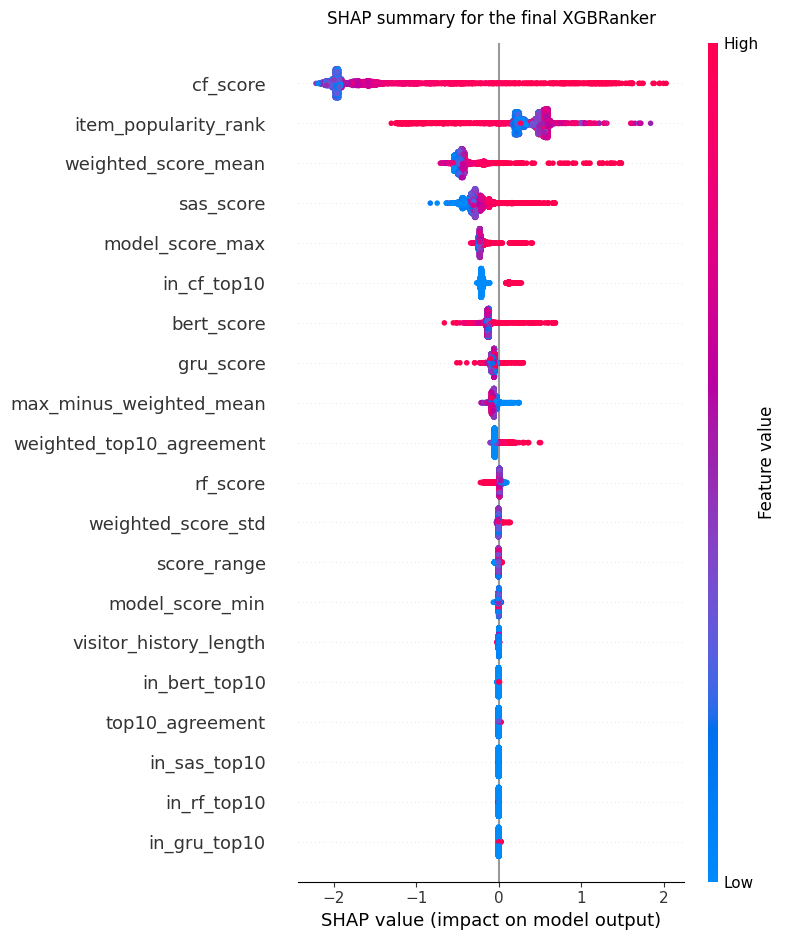

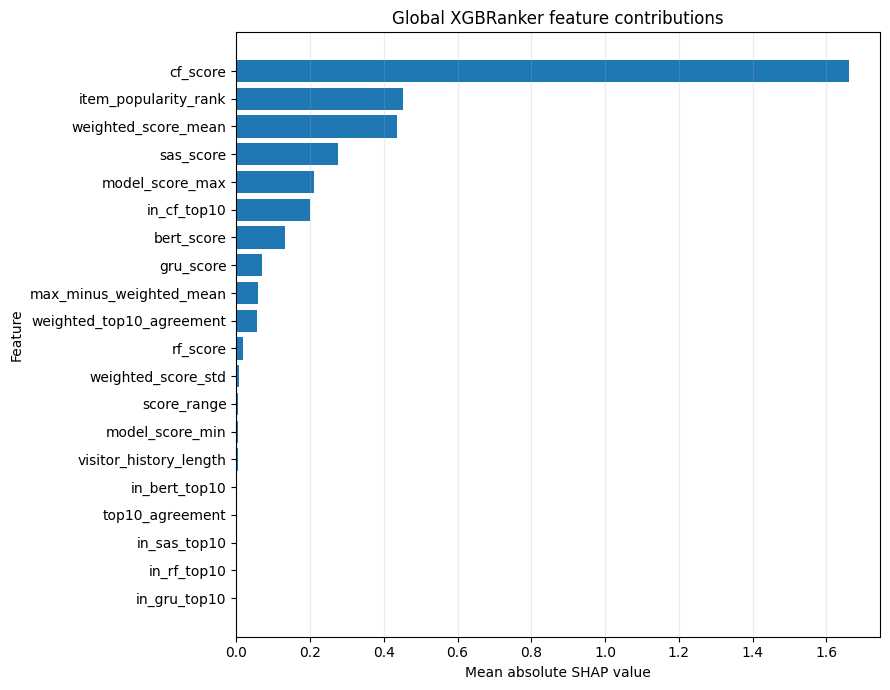

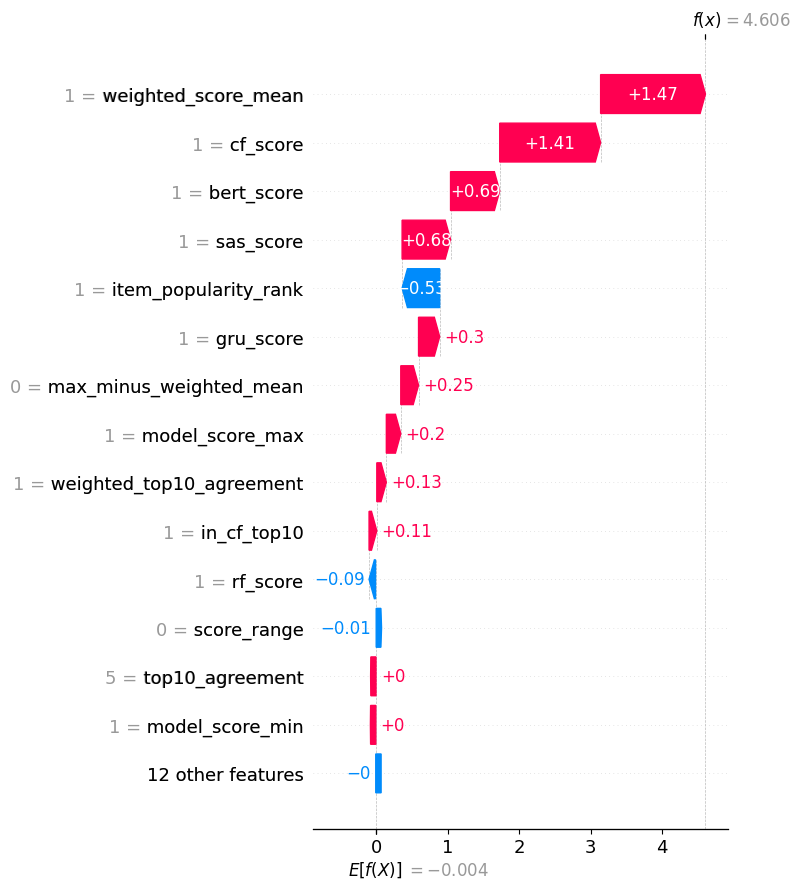

SHAP analysis completed.


In [22]:

# ============================================================
# SECTION 10
# SHAP ANALYSIS OF THE FINAL XGBRANKER
# ============================================================

try:
    import shap
except ImportError as exc:
    raise ImportError(
        "The SHAP package is required. In Kaggle, run: "
        "!pip install -q shap"
    ) from exc

SHAP_SAMPLE_SIZE = min(5000, len(X_ranker))

shap_sample = (
    X_ranker[COMBINER_FEATURES]
    .sample(
        n=SHAP_SAMPLE_SIZE,
        random_state=ANALYSIS_SEED
    )
    .astype(np.float32)
)

shap_explainer = shap.TreeExplainer(xgb_model)
raw_shap_values = shap_explainer.shap_values(shap_sample)

if isinstance(raw_shap_values, list):
    raw_shap_values = raw_shap_values[0]

shap_values_array = np.asarray(
    raw_shap_values,
    dtype=np.float64
)

if shap_values_array.shape != shap_sample.shape:
    raise RuntimeError(
        "Unexpected SHAP output shape: "
        f"{shap_values_array.shape}; expected {shap_sample.shape}."
    )

mean_abs_shap = np.mean(
    np.abs(shap_values_array),
    axis=0
)

shap_importance_df = (
    pd.DataFrame({
        "Feature": COMBINER_FEATURES,
        "MeanAbsSHAP": mean_abs_shap,
        "RelativeImportance": (
            mean_abs_shap
            / max(mean_abs_shap.sum(), 1e-12)
        )
    })
    .sort_values(
        "MeanAbsSHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(shap_importance_df)

shap_importance_df.to_csv(
    TABLE_DIR / "shap_global_importance.csv",
    index=False
)

# Global beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_array,
    shap_sample,
    feature_names=COMBINER_FEATURES,
    max_display=min(20, len(COMBINER_FEATURES)),
    show=False
)
plt.title("SHAP summary for the final XGBRanker", pad=14)
plt.tight_layout()
plt.savefig(
    FIG_DIR / "figure_shap_beeswarm.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()
plt.close()

# Global mean absolute SHAP bar plot
top_shap = shap_importance_df.head(20).sort_values(
    "MeanAbsSHAP",
    ascending=True
)

plt.figure(figsize=(9, 7))
plt.barh(
    top_shap["Feature"],
    top_shap["MeanAbsSHAP"]
)
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.title("Global XGBRanker feature contributions")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(
    FIG_DIR / "figure_shap_global_importance.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()
plt.close()

# Representative local explanation
representative_index = int(
    np.argmax(
        np.sum(
            np.abs(shap_values_array),
            axis=1
        )
    )
)

expected_value = float(
    np.asarray(
        shap_explainer.expected_value
    ).reshape(-1)[0]
)

representative_explanation = shap.Explanation(
    values=shap_values_array[representative_index],
    base_values=expected_value,
    data=shap_sample.iloc[
        representative_index
    ].to_numpy(),
    feature_names=COMBINER_FEATURES
)

shap.plots.waterfall(
    representative_explanation,
    max_display=min(15, len(COMBINER_FEATURES)),
    show=False
)
plt.tight_layout()
plt.savefig(
    FIG_DIR / "figure_shap_local_waterfall.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()
plt.close()

print("SHAP analysis completed.")


In [23]:

# ============================================================
# SECTION 11
# REPEATED-SEED ABLATION OF THE VALIDATION-SELECTED FUSION MODEL
# ============================================================
# This is a post-selection analysis.  Component selection itself was
# performed only on the inner validation split.  The final test set was
# not used to decide which components were retained.
#
# The candidate pool is frozen across variants so that the ablation
# isolates fusion-stage contribution rather than confounding candidate
# retrieval with reranking.

from scipy.stats import t as student_t

ABLATION_SEEDS = [
    int(SEED),
    int(SEED) + 17,
    int(SEED) + 31,
    int(SEED) + 47,
    int(SEED) + 73,
]

ABLATION_VARIANTS = {
    "Full Hybrid": None,
}

for component in SELECTED_COMPONENTS:
    ABLATION_VARIANTS[
        f"Without {component}"
    ] = component


def variant_components(
    omitted_component=None,
):
    return [
        component
        for component
        in SELECTED_COMPONENTS
        if component
        != omitted_component
    ]


def variant_weights(
    retained_components,
):
    return normalize_component_weights(
        FINAL_COMPONENT_WEIGHTS,
        retained_components,
    )


def evaluate_selected_variant_from_cache(
    ranker,
    retained_components,
    component_weights,
    query_cache,
    k=TOPK,
    description="Ablation evaluation",
):
    feature_names = (
        feature_names_for_components(
            retained_components
        )
    )

    records = []

    for visitor_idx, query in tqdm(
        query_cache.items(),
        total=len(
            query_cache
        ),
        desc=description,
        leave=False,
    ):
        candidates = np.asarray(
            query[
                "candidates"
            ],
            dtype=np.int64,
        )

        X_query = (
            transform_fusion_features(
                query[
                    "X_raw"
                ],
                retained_components,
                component_weights,
            )
        )

        scores = ranker.predict(
            X_query[
                feature_names
            ]
        )

        scores = np.nan_to_num(
            np.asarray(
                scores,
                dtype=np.float32,
            ),
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        recommendations = (
            top_k_recommendations(
                candidates=candidates,
                scores=scores,
                k=k,
            )
        )

        metrics = (
            single_relevant_item_metrics(
                recommended_items=recommendations,
                truth_item=query[
                    "truth"
                ],
                k=k,
            )
        )

        records.append({
            "visitor_idx": int(
                visitor_idx
            ),
            **metrics,
        })

    return pd.DataFrame(
        records
    )


def seed_ci(
    values,
    confidence=0.95,
):
    values = np.asarray(
        values,
        dtype=np.float64,
    )

    values = values[
        np.isfinite(
            values
        )
    ]

    if len(
        values
    ) == 0:
        return (
            np.nan,
            np.nan,
        )

    mean = float(
        values.mean()
    )

    if len(
        values
    ) == 1:
        return (
            mean,
            mean,
        )

    standard_error = float(
        values.std(
            ddof=1
        )
        / np.sqrt(
            len(
                values
            )
        )
    )

    critical = float(
        student_t.ppf(
            0.5
            + confidence / 2.0,
            df=len(
                values
            )
            - 1,
        )
    )

    half_width = (
        critical
        * standard_error
    )

    return (
        mean - half_width,
        mean + half_width,
    )


ablation_models = {}
ablation_seed_visitor_results = {}
ablation_run_records = []
ablation_training_records = []

for ablation_seed in ABLATION_SEEDS:
    print(
        "\nRunning selected-fusion ablation seed:",
        ablation_seed,
    )

    for variant_name, omitted_component in (
        ABLATION_VARIANTS.items()
    ):
        retained = variant_components(
            omitted_component
        )

        if len(
            retained
        ) < 1:
            continue

        weights = variant_weights(
            retained
        )

        start = time.time()

        (
            ablation_model,
            _ordered,
            _X,
            _y,
            _groups,
            _elapsed,
        ) = fit_fusion_ranker(
            frame=combiner_df,
            active_components=retained,
            component_weights=weights,
            parameters=FINAL_RANKER_PARAMS,
            seed=ablation_seed,
        )

        training_seconds = (
            time.time()
            - start
        )

        visitor_frame = (
            evaluate_selected_variant_from_cache(
                ranker=ablation_model,
                retained_components=retained,
                component_weights=weights,
                query_cache=test_query_cache,
                k=TOPK,
                description=(
                    f"{variant_name}, seed "
                    f"{ablation_seed}"
                ),
            )
        )

        ablation_seed_visitor_results[
            (
                variant_name,
                int(
                    ablation_seed
                ),
            )
        ] = visitor_frame

        if int(
            ablation_seed
        ) == int(
            SEED
        ):
            ablation_models[
                variant_name
            ] = ablation_model

        summary = aggregate_metric_frame(
            frame=visitor_frame,
            model_name=variant_name,
        )

        summary.update({
            "Variant": variant_name,
            "Seed": int(
                ablation_seed
            ),
            "OmittedComponent": (
                omitted_component
                if omitted_component
                is not None
                else ""
            ),
            "RetainedComponents": "|".join(
                retained
            ),
        })

        ablation_run_records.append(
            summary
        )

        ablation_training_records.append({
            "Seed": int(
                ablation_seed
            ),
            "Variant": variant_name,
            "TrainingSeconds": float(
                training_seconds
            ),
            "RetainedComponents": "|".join(
                retained
            ),
        })


ablation_runs_df = pd.DataFrame(
    ablation_run_records
)

ablation_training_df = pd.DataFrame(
    ablation_training_records
)

ablation_visitor_results = {
    variant_name: (
        ablation_seed_visitor_results[
            (
                variant_name,
                int(
                    SEED
                ),
            )
        ]
    )
    for variant_name
    in ABLATION_VARIANTS
    if (
        variant_name,
        int(
            SEED
        ),
    )
    in ablation_seed_visitor_results
}


summary_records = []

for variant_name, group in (
    ablation_runs_df.groupby(
        "Variant",
        sort=False,
    )
):
    row = {
        "Variant": variant_name,
        "Seeds": int(
            group[
                "Seed"
            ].nunique()
        ),
    }

    for metric_column in [
        f"Precision@{TOPK}",
        f"Recall@{TOPK}",
        f"HR@{TOPK}",
        f"NDCG@{TOPK}",
        f"MRR@{TOPK}",
    ]:
        values = group[
            metric_column
        ].to_numpy(
            dtype=np.float64
        )

        ci_low, ci_high = seed_ci(
            values
        )

        row[
            metric_column
        ] = float(
            np.mean(
                values
            )
        )

        row[
            f"{metric_column}_SeedSD"
        ] = float(
            np.std(
                values,
                ddof=1,
            )
            if len(
                values
            ) > 1
            else 0.0
        )

        row[
            f"{metric_column}_SeedCI_low"
        ] = float(
            ci_low
        )

        row[
            f"{metric_column}_SeedCI_high"
        ] = float(
            ci_high
        )

    summary_records.append(
        row
    )


ablation_df = pd.DataFrame(
    summary_records
)

full_seed_rows = (
    ablation_runs_df[
        ablation_runs_df[
            "Variant"
        ] == "Full Hybrid"
    ][
        [
            "Seed",
            f"Precision@{TOPK}",
            f"Recall@{TOPK}",
            f"HR@{TOPK}",
            f"NDCG@{TOPK}",
            f"MRR@{TOPK}",
        ]
    ]
    .copy()
)

ablation_seed_differences = (
    ablation_runs_df.merge(
        full_seed_rows,
        on="Seed",
        how="left",
        suffixes=(
            "",
            "_Full",
        ),
    )
)

for metric_column in [
    f"Precision@{TOPK}",
    f"Recall@{TOPK}",
    f"HR@{TOPK}",
    f"NDCG@{TOPK}",
    f"MRR@{TOPK}",
]:
    ablation_seed_differences[
        f"FullMinusVariant_{metric_column}"
    ] = (
        ablation_seed_differences[
            f"{metric_column}_Full"
        ]
        - ablation_seed_differences[
            metric_column
        ]
    )


full_means = (
    ablation_df[
        ablation_df[
            "Variant"
        ] == "Full Hybrid"
    ]
    .iloc[0]
)

for metric_column in [
    f"Precision@{TOPK}",
    f"Recall@{TOPK}",
    f"HR@{TOPK}",
    f"NDCG@{TOPK}",
    f"MRR@{TOPK}",
]:
    ablation_df[
        f"FullMinusVariant_{metric_column}"
    ] = (
        float(
            full_means[
                metric_column
            ]
        )
        - ablation_df[
            metric_column
        ]
    )


def classify_component_effect(
    delta,
    tolerance=1e-6,
):
    if delta > tolerance:
        return "Beneficial"
    if delta < -tolerance:
        return "Redundant_or_harmful"
    return "Neutral"


ablation_df[
    "ComponentEffect"
] = ablation_df[
    f"FullMinusVariant_NDCG@{TOPK}"
].map(
    classify_component_effect
)

ablation_df = (
    ablation_df
    .sort_values(
        f"NDCG@{TOPK}",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

display(
    ablation_df
)

ablation_runs_df.to_csv(
    TABLE_DIR
    / "ablation_all_seed_runs.csv",
    index=False,
)

ablation_df.to_csv(
    TABLE_DIR
    / "ablation_repeated_seed_summary.csv",
    index=False,
)

ablation_seed_differences.to_csv(
    TABLE_DIR
    / "ablation_seed_differences.csv",
    index=False,
)

ablation_training_df.to_csv(
    TABLE_DIR
    / "ablation_training_times.csv",
    index=False,
)

print(
    "Selected-component repeated-seed ablation complete."
)
print(
    "A negative FullMinusVariant value is retained as evidence "
    "that a retained component may not generalize positively on "
    "the final test set; it is never forced to appear beneficial."
)



Running selected-fusion ablation seed: 42


Full Hybrid, seed 42:   0%|          | 0/5000 [00:00<?, ?it/s]

Without CF, seed 42:   0%|          | 0/5000 [00:00<?, ?it/s]

Without RF, seed 42:   0%|          | 0/5000 [00:00<?, ?it/s]

Without GRU, seed 42:   0%|          | 0/5000 [00:00<?, ?it/s]

...

Without GRU, seed 115:   0%|          | 0/5000 [00:00<?, ?it/s]

Without SAS, seed 115:   0%|          | 0/5000 [00:00<?, ?it/s]

Without BERT, seed 115:   0%|          | 0/5000 [00:00<?, ?it/s]

,Variant,Seeds,Precision@10,Precision@10_SeedSD,Precision@10_SeedCI_low,Precision@10_SeedCI_high,Recall@10,Recall@10_SeedSD,Recall@10_SeedCI_low,Recall@10_SeedCI_high,...,MRR@10,MRR@10_SeedSD,MRR@10_SeedCI_low,MRR@10_SeedCI_high,FullMinusVariant_Precision@10,FullMinusVariant_Recall@10,FullMinusVariant_HR@10,FullMinusVariant_NDCG@10,FullMinusVariant_MRR@10,ComponentEffect
0,Without RF,5,0.083592,0.000067,0.083509,0.083675,0.83592,0.000672,0.835085,0.836755,...,0.728034,0.000224,0.727756,0.728312,-0.000172,-0.00172,-0.00172,-0.000274,0.000162,Redundant_or_harmful
1,Full Hybrid,5,0.083420,0.000081,0.083319,0.083521,0.83420,0.000812,0.833191,0.835209,...,0.728196,0.000316,0.727803,0.728588,0.000000,0.00000,0.00000,0.000000,0.000000,Neutral
2,Without GRU,5,0.083560,0.000089,0.083449,0.083671,0.83560,0.000894,0.834489,0.836711,...,0.727725,0.000434,0.727186,0.728264,-0.000140,-0.00140,-0.00140,0.000067,0.000470,Beneficial
3,Without BERT,5,0.083288,0.000041,0.083237,0.083339,0.83288,0.000415,0.832365,0.833395,...,0.720924,0.000467,0.720345,0.721504,0.000132,0.00132,0.00132,0.005765,0.007271,Beneficial
4,Without SAS,5,0.083468,0.000039,0.083420,0.083516,0.83468,0.000390,0.834196,0.835164,...,0.718400,0.000439,0.717855,0.718945,-0.000048,-0.00048,-0.00048,0.007296,0.009796,Beneficial
5,Without CF,5,0.076920,0.000081,0.076819,0.077021,0.76920,0.000812,0.768191,0.770209,...,0.652348,0.000301,0.651974,0.652721,0.006500,0.06500,0.06500,0.073370,0.075848,Beneficial


Selected-component repeated-seed ablation complete.
A negative FullMinusVariant value is retained as evidence that a retained component may not generalize positively on the final test set; it is never forced to appear beneficial.


In [24]:

# ============================================================
# SECTION 12
# PAIRED SIGNIFICANCE TESTS, EFFECT SIZES AND MULTIPLICITY
# ============================================================

def align_paired_metric(
    frame_a,
    frame_b,
    metric
):
    left = frame_a[
        ["visitor_idx", metric]
    ].rename(
        columns={metric: "a"}
    )

    right = frame_b[
        ["visitor_idx", metric]
    ].rename(
        columns={metric: "b"}
    )

    return left.merge(
        right,
        on="visitor_idx",
        how="inner",
        validate="one_to_one"
    )


def rank_biserial_effect(
    differences
):
    differences = np.asarray(
        differences,
        dtype=np.float64
    )

    nonzero = differences[
        differences != 0
    ]

    if nonzero.size == 0:
        return 0.0

    ranks = (
        pd.Series(
            np.abs(nonzero)
        )
        .rank(method="average")
        .to_numpy()
    )

    positive_rank_sum = ranks[
        nonzero > 0
    ].sum()

    negative_rank_sum = ranks[
        nonzero < 0
    ].sum()

    denominator = (
        positive_rank_sum
        + negative_rank_sum
    )

    return float(
        (
            positive_rank_sum
            - negative_rank_sum
        )
        / denominator
    ) if denominator else 0.0


def paired_bootstrap_difference_ci(
    differences,
    n_boot=N_BOOTSTRAP,
    alpha=CI_ALPHA,
    seed=ANALYSIS_SEED
):
    differences = np.asarray(
        differences,
        dtype=np.float64
    )

    if differences.size == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(
        seed
    )

    bootstrap_means = np.empty(
        n_boot,
        dtype=np.float64
    )

    chunk_size = 250

    for start in range(
        0,
        n_boot,
        chunk_size
    ):
        stop = min(
            start + chunk_size,
            n_boot
        )

        sampled_indices = rng.integers(
            0,
            differences.size,
            size=(
                stop - start,
                differences.size
            )
        )

        bootstrap_means[
            start:stop
        ] = differences[
            sampled_indices
        ].mean(axis=1)

    lower, upper = np.quantile(
        bootstrap_means,
        [
            alpha / 2,
            1 - alpha / 2
        ]
    )

    return float(lower), float(upper)


def paired_wilcoxon_record(
    frame_a,
    frame_b,
    metric,
    label_a,
    label_b,
    comparison_family
):
    aligned = align_paired_metric(
        frame_a,
        frame_b,
        metric
    )

    a_values = aligned[
        "a"
    ].to_numpy(
        dtype=np.float64
    )

    b_values = aligned[
        "b"
    ].to_numpy(
        dtype=np.float64
    )

    differences = (
        a_values
        - b_values
    )

    if np.allclose(
        differences,
        0.0
    ):
        statistic = 0.0
        p_value = 1.0
    else:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            statistic, p_value = wilcoxon(
                differences,
                zero_method="pratt",
                alternative="two-sided",
                method="auto"
            )

    ci_low, ci_high = (
        paired_bootstrap_difference_ci(
            differences,
            seed=(
                ANALYSIS_SEED
                + abs(
                    hash(
                        (
                            label_a,
                            label_b,
                            metric
                        )
                    )
                ) % 100000
            )
        )
    )

    return {
        "ComparisonFamily": comparison_family,
        "Metric": metric,
        "ModelA": label_a,
        "ModelB": label_b,
        "Pairs": len(aligned),
        "MeanA": float(
            a_values.mean()
        ),
        "MeanB": float(
            b_values.mean()
        ),
        "MeanDifference": float(
            differences.mean()
        ),
        "DifferenceCI_low": ci_low,
        "DifferenceCI_high": ci_high,
        "Wins": int(
            np.sum(
                differences > 0
            )
        ),
        "Ties": int(
            np.sum(
                differences == 0
            )
        ),
        "Losses": int(
            np.sum(
                differences < 0
            )
        ),
        "RankBiserial": rank_biserial_effect(
            differences
        ),
        "WilcoxonStatistic": float(
            statistic
        ),
        "PValue": float(
            p_value
        )
    }


def holm_adjust(
    p_values
):
    p_values = np.asarray(
        p_values,
        dtype=np.float64
    )

    order = np.argsort(
        p_values
    )

    adjusted = np.empty_like(
        p_values
    )

    running_maximum = 0.0
    number_of_tests = len(
        p_values
    )

    for rank, index in enumerate(
        order
    ):
        candidate = (
            number_of_tests
            - rank
        ) * p_values[
            index
        ]

        running_maximum = max(
            running_maximum,
            candidate
        )

        adjusted[
            index
        ] = min(
            running_maximum,
            1.0
        )

    return adjusted


significance_records = []


# Main model comparisons on the independent test visitors.
for baseline_name in [
    "CF",
    "RF",
    "GRU4Rec",
    "SASRec",
    "BERT4Rec"
]:
    for metric in METRIC_COLUMNS:
        significance_records.append(
            paired_wilcoxon_record(
                frame_a=visitor_results[
                    "Hybrid"
                ],
                frame_b=visitor_results[
                    baseline_name
                ],
                metric=metric,
                label_a="Hybrid",
                label_b=baseline_name,
                comparison_family=(
                    "Hybrid versus base model"
                )
            )
        )


# Ablation comparisons use the reference-seed trained models,
# while the preceding repeated-seed table establishes whether
# the direction is stable across optimization runs.
for variant_name, variant_frame in (
    ablation_visitor_results.items()
):
    if variant_name == "Full Hybrid":
        continue

    for metric in METRIC_COLUMNS:
        significance_records.append(
            paired_wilcoxon_record(
                frame_a=ablation_visitor_results[
                    "Full Hybrid"
                ],
                frame_b=variant_frame,
                metric=metric,
                label_a="Full Hybrid",
                label_b=variant_name,
                comparison_family=(
                    "Reference-seed ablation"
                )
            )
        )


significance_df = pd.DataFrame(
    significance_records
)


significance_df[
    "HolmAdjustedP"
] = np.nan


for family_name, family_indices in (
    significance_df.groupby(
        "ComparisonFamily"
    ).groups.items()
):
    family_indices = list(
        family_indices
    )

    significance_df.loc[
        family_indices,
        "HolmAdjustedP"
    ] = holm_adjust(
        significance_df.loc[
            family_indices,
            "PValue"
        ].to_numpy()
    )


significance_df[
    "SignificantAfterHolm"
] = (
    significance_df[
        "HolmAdjustedP"
    ] < SIGNIFICANCE_ALPHA
)


significance_df[
    "EffectDirection"
] = np.select(
    [
        significance_df[
            "MeanDifference"
        ] > 0,
        significance_df[
            "MeanDifference"
        ] < 0
    ],
    [
        "ModelA higher",
        "ModelB higher"
    ],
    default="No difference"
)


display(
    significance_df.sort_values(
        [
            "ComparisonFamily",
            "Metric",
            "HolmAdjustedP"
        ]
    )
)


significance_df.to_csv(
    TABLE_DIR
    / "paired_significance_tests.csv",
    index=False
)


# Stability of the ablation direction across repeated seeds.
ablation_seed_stability_records = []

for variant_name in ABLATION_VARIANTS:
    if variant_name == "Full Hybrid":
        continue

    variant_rows = (
        ablation_seed_differences[
            ablation_seed_differences[
                "Variant"
            ] == variant_name
        ]
        .sort_values("Seed")
    )

    for metric_column in [
        f"Precision@{TOPK}",
        f"Recall@{TOPK}",
        f"HR@{TOPK}",
        f"NDCG@{TOPK}",
        f"MRR@{TOPK}"
    ]:
        differences = variant_rows[
            f"FullMinusVariant_{metric_column}"
        ].to_numpy(
            dtype=np.float64
        )

        ablation_seed_stability_records.append({
            "Variant": variant_name,
            "Metric": metric_column,
            "Seeds": len(
                differences
            ),
            "MeanFullMinusVariant": float(
                differences.mean()
            ),
            "StdFullMinusVariant": float(
                differences.std(
                    ddof=1
                )
            ),
            "FullHigherSeeds": int(
                np.sum(
                    differences > 0
                )
            ),
            "EqualSeeds": int(
                np.sum(
                    differences == 0
                )
            ),
            "VariantHigherSeeds": int(
                np.sum(
                    differences < 0
                )
            ),
            "DirectionStable": bool(
                np.all(
                    differences > 0
                )
                or np.all(
                    differences < 0
                )
                or np.all(
                    differences == 0
                )
            )
        })


ablation_seed_stability_df = pd.DataFrame(
    ablation_seed_stability_records
)


display(
    ablation_seed_stability_df[
        ablation_seed_stability_df[
            "Metric"
        ] == f"NDCG@{TOPK}"
    ]
)


ablation_seed_stability_df.to_csv(
    TABLE_DIR
    / "ablation_seed_stability.csv",
    index=False
)


,ComparisonFamily,Metric,ModelA,ModelB,Pairs,MeanA,MeanB,MeanDifference,DifferenceCI_low,DifferenceCI_high,Wins,Ties,Losses,RankBiserial,WilcoxonStatistic,PValue,HolmAdjustedP,SignificantAfterHolm,EffectDirection
7,Hybrid versus base model,hr,Hybrid,RF,5000,0.833800,0.297000,0.536800,0.521800,0.552005,2818,2048,134,0.909214,472283.0,0.000000e+00,0.000000e+00,True,ModelA higher
12,Hybrid versus base model,hr,Hybrid,GRU4Rec,5000,0.833800,0.688800,0.145000,0.134000,0.156200,811,4103,86,0.808250,391472.0,1.875394e-129,2.250472e-128,True,ModelA higher
22,Hybrid versus base model,hr,Hybrid,BERT4Rec,5000,0.833800,0.698200,0.135600,0.125000,0.146800,778,4122,100,0.772210,456150.0,7.119313e-116,6.407381e-115,True,ModelA higher
17,Hybrid versus base model,hr,Hybrid,SASRec,5000,0.833800,0.761800,0.072000,0.063195,0.081000,453,4454,93,0.659341,439657.5,1.478364e-53,8.870182e-53,True,ModelA higher
2,Hybrid versus base model,hr,Hybrid,CF,5000,0.833800,0.820400,0.013400,0.008000,0.018800,128,4811,61,0.354497,299266.0,1.096200e-06,3.288600e-06,True,ModelA higher
9,Hybrid versus base model,mrr,Hybrid,RF,5000,0.727936,0.161505,0.566431,0.553027,0.579970,3505,1199,296,0.958250,505740.5,0.000000e+00,0.000000e+00,True,ModelA higher
4,Hybrid versus base model,mrr,Hybrid,CF,5000,0.727936,0.508123,0.219813,0.210556,0.229573,2109,2511,380,0.845305,1193865.0,7.011021e-292,1.402204e-290,True,ModelA higher
14,Hybrid versus base model,mrr,Hybrid,GRU4Rec,5000,0.727936,0.553576,0.174361,0.164711,0.183833,1552,3221,227,0.848236,851312.0,2.799108e-226,4.758484e-225,True,ModelA higher
24,Hybrid versus base model,mrr,Hybrid,BERT4Rec,5000,0.727936,0.565550,0.162387,0.153250,0.171909,1463,3296,241,0.851227,902394.0,1.011283e-204,1.618052e-203,True,ModelA higher
19,Hybrid versus base model,mrr,Hybrid,SASRec,5000,0.727936,0.610989,0.116947,0.108504,0.125481,1249,3434,317,0.748081,1243125.5,5.866674e-133,7.626676e-132,True,ModelA higher


,Variant,Metric,Seeds,MeanFullMinusVariant,StdFullMinusVariant,FullHigherSeeds,EqualSeeds,VariantHigherSeeds,DirectionStable
3,Without CF,NDCG@10,5,0.073370,0.000399,5,0,0,True
8,Without RF,NDCG@10,5,-0.000274,0.000523,1,0,4,False
13,Without GRU,NDCG@10,5,0.000067,0.000575,2,0,3,False
18,Without SAS,NDCG@10,5,0.007296,0.000509,5,0,0,True
23,Without BERT,NDCG@10,5,0.005765,0.000548,5,0,0,True


In [25]:

# ============================================================
# SECTION 13
# VISITOR-LEVEL BOOTSTRAP CONFIDENCE INTERVALS
# ============================================================

def bootstrap_mean_ci(
    values,
    n_boot=N_BOOTSTRAP,
    alpha=CI_ALPHA,
    seed=ANALYSIS_SEED
):
    values = np.asarray(
        values,
        dtype=np.float64
    )

    if values.size == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(seed)

    bootstrap_means = np.empty(
        n_boot,
        dtype=np.float64
    )

    chunk_size = 250

    for start in range(
        0,
        n_boot,
        chunk_size
    ):
        stop = min(
            start + chunk_size,
            n_boot
        )

        sampled_indices = rng.integers(
            0,
            values.size,
            size=(
                stop - start,
                values.size
            )
        )

        bootstrap_means[
            start:stop
        ] = values[
            sampled_indices
        ].mean(axis=1)

    lower, upper = np.quantile(
        bootstrap_means,
        [
            alpha / 2,
            1 - alpha / 2
        ]
    )

    return float(lower), float(upper)


confidence_interval_records = []

for model_name, frame in visitor_results.items():
    for metric in METRIC_COLUMNS:
        metric_values = frame[
            metric
        ].to_numpy(
            dtype=np.float64
        )

        ci_low, ci_high = bootstrap_mean_ci(
            metric_values,
            seed=(
                ANALYSIS_SEED
                + abs(
                    hash(
                        (
                            model_name,
                            metric
                        )
                    )
                ) % 100000
            )
        )

        confidence_interval_records.append({
            "Model": model_name,
            "Metric": metric,
            "Mean": float(
                metric_values.mean()
            ),
            "StandardError": float(
                metric_values.std(
                    ddof=1
                )
                / np.sqrt(
                    len(metric_values)
                )
            ),
            "CI_low": ci_low,
            "CI_high": ci_high,
            "N": len(metric_values)
        })

confidence_intervals_df = pd.DataFrame(
    confidence_interval_records
)

display(confidence_intervals_df)

confidence_intervals_df.to_csv(
    TABLE_DIR / "bootstrap_confidence_intervals.csv",
    index=False
)


,Model,Metric,Mean,StandardError,CI_low,CI_high,N
0,CF,precision,0.082040,0.000543,0.080860,0.083120,5000
1,CF,recall,0.820400,0.005429,0.809600,0.831000,5000
2,CF,hr,0.820400,0.005429,0.810200,0.831005,5000
3,CF,ndcg,0.583841,0.005150,0.574132,0.594146,5000
4,CF,mrr,0.508123,0.005579,0.496947,0.518829,5000
5,RF,precision,0.029700,0.000646,0.028460,0.030980,5000
6,RF,recall,0.297000,0.006463,0.284600,0.309400,5000
7,RF,hr,0.297000,0.006463,0.284400,0.309600,5000
8,RF,ndcg,0.193533,0.004735,0.183769,0.202550,5000
9,RF,mrr,0.161505,0.004497,0.152788,0.171133,5000


In [26]:

# ============================================================
# SECTION 14
# ROBUSTNESS BY TRAIN-HISTORY LENGTH
# ============================================================

train_history_lengths = (
    train_df
    .groupby(
        "visitor_idx",
        sort=False
    )
    .size()
    .astype(int)
    .to_dict()
)

def assign_history_group(length):
    length = int(length)

    if length <= 5:
        return "Cold-start (≤5)"

    if length <= 20:
        return "Short (6–20)"

    if length <= 100:
        return "Medium (21–100)"

    return "Long (>100)"


HISTORY_GROUP_ORDER = [
    "Cold-start (≤5)",
    "Short (6–20)",
    "Medium (21–100)",
    "Long (>100)"
]

robustness_records = []

for model_name, frame in visitor_results.items():
    enriched = frame.copy()

    enriched["HistoryLength"] = (
        enriched["visitor_idx"]
        .map(
            lambda visitor: train_history_lengths.get(
                int(visitor),
                0
            )
        )
    )

    enriched["HistoryGroup"] = (
        enriched["HistoryLength"]
        .map(assign_history_group)
    )

    for group_name, group_frame in enriched.groupby(
        "HistoryGroup",
        observed=True
    ):
        record = {
            "Model": model_name,
            "HistoryGroup": group_name,
            "Visitors": len(group_frame),
            "Reliable_n_ge_30": bool(
                len(group_frame) >= 30
            )
        }

        for metric in METRIC_COLUMNS:
            values = group_frame[
                metric
            ].to_numpy(
                dtype=np.float64
            )

            ci_low, ci_high = bootstrap_mean_ci(
                values,
                seed=(
                    ANALYSIS_SEED
                    + abs(
                        hash(
                            (
                                model_name,
                                group_name,
                                metric
                            )
                        )
                    ) % 100000
                )
            )

            record[
                metric
            ] = float(
                values.mean()
            )

            record[
                f"{metric}_CI_low"
            ] = ci_low

            record[
                f"{metric}_CI_high"
            ] = ci_high

        robustness_records.append(
            record
        )

robustness_df = pd.DataFrame(
    robustness_records
)

robustness_df[
    "HistoryGroup"
] = pd.Categorical(
    robustness_df[
        "HistoryGroup"
    ],
    categories=HISTORY_GROUP_ORDER,
    ordered=True
)

robustness_df = robustness_df.sort_values(
    ["Model", "HistoryGroup"]
).reset_index(drop=True)

display(robustness_df)

robustness_df.to_csv(
    TABLE_DIR / "history_length_robustness.csv",
    index=False
)


,Model,HistoryGroup,Visitors,Reliable_n_ge_30,precision,precision_CI_low,precision_CI_high,recall,recall_CI_low,recall_CI_high,hr,hr_CI_low,hr_CI_high,ndcg,ndcg_CI_low,ndcg_CI_high,mrr,mrr_CI_low,mrr_CI_high
0,BERT4Rec,Cold-start (≤5),3490,True,0.070544,0.068968,0.072006,0.705444,0.690258,0.720917,0.705444,0.690258,0.720924,0.604280,0.589613,0.618963,0.573126,0.558608,0.588557
1,BERT4Rec,Short (6–20),1303,True,0.068918,0.066385,0.071374,0.689179,0.663853,0.714505,0.689179,0.663853,0.712970,0.590861,0.567032,0.614706,0.560723,0.535263,0.587835
2,BERT4Rec,Medium (21–100),189,True,0.063492,0.056071,0.070370,0.634921,0.566138,0.703704,0.634921,0.566138,0.698545,0.513511,0.450445,0.573353,0.475943,0.411400,0.541773
3,BERT4Rec,Long (>100),18,False,0.061111,0.038889,0.083333,0.611111,0.388889,0.833333,0.611111,0.388889,0.833333,0.437610,0.238281,0.636858,0.386728,0.193202,0.588904
4,CF,Cold-start (≤5),3490,True,0.081461,0.080200,0.082751,0.814613,0.801999,0.827221,0.814613,0.800573,0.827794,0.589953,0.577324,0.602414,0.517795,0.504753,0.530904
5,CF,Short (6–20),1303,True,0.083960,0.082040,0.085879,0.839601,0.818880,0.858020,0.839601,0.818880,0.859555,0.582763,0.563144,0.602660,0.500928,0.479666,0.521360
6,CF,Medium (21–100),189,True,0.080423,0.074603,0.085728,0.804233,0.746032,0.857143,0.804233,0.746032,0.857143,0.493225,0.446747,0.538465,0.395284,0.346451,0.448142
7,CF,Long (>100),18,False,0.072222,0.050000,0.088889,0.722222,0.500000,0.888889,0.722222,0.500000,0.944444,0.428106,0.266675,0.603429,0.338492,0.182927,0.519048
8,GRU4Rec,Cold-start (≤5),3490,True,0.069484,0.067851,0.070917,0.694842,0.679083,0.710315,0.694842,0.680229,0.710315,0.588798,0.574098,0.604056,0.556004,0.541425,0.570243
9,GRU4Rec,Short (6–20),1303,True,0.068227,0.065769,0.070683,0.682272,0.657694,0.708365,0.682272,0.656946,0.707598,0.590072,0.567272,0.614589,0.561508,0.537268,0.585446


In [27]:

# ============================================================
# SECTION 15
# COMPUTATIONAL COST AND MODEL-EFFICIENCY SUMMARY
# ============================================================

def safe_float(value):
    try:
        value = float(value)
        return value if np.isfinite(value) else np.nan
    except Exception:
        return np.nan


def pytorch_parameter_count(model):
    if model is None:
        return np.nan, np.nan

    total = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    return int(total), int(trainable)


def pytorch_state_size_mb(model):
    if model is None:
        return np.nan

    size_bytes = sum(
        tensor.numel()
        * tensor.element_size()
        for tensor in model.state_dict().values()
    )

    return float(
        size_bytes
        / (1024 ** 2)
    )


training_time_map = {
    "CF": safe_float(
        globals().get(
            "cf_train_time",
            np.nan
        )
    ),
    "RF": safe_float(
        globals().get(
            "rf_train_time",
            np.nan
        )
    ),
    "GRU4Rec": safe_float(
        globals().get(
            "gru_train_time",
            np.nan
        )
    ),
    "SASRec": safe_float(
        globals().get(
            "sas_training_summary",
            {}
        ).get(
            "training_seconds",
            np.nan
        )
    ),
    "BERT4Rec": safe_float(
        globals().get(
            "bert_train_time",
            np.nan
        )
    ),
    "Hybrid Combiner": safe_float(
        globals().get(
            "xgb_train_time",
            np.nan
        )
    )
}

diagnostics_frame = pd.DataFrame(
    PREDICTION_DIAGNOSTICS
)

if diagnostics_frame.empty:
    inference_summary = pd.DataFrame(
        columns=[
            "Model",
            "PredictionCalls",
            "MeanInferenceSeconds",
            "MedianInferenceSeconds",
            "P95InferenceSeconds",
            "ObservedInferenceSeconds",
            "SuccessRate",
            "FallbackRate"
        ]
    )
else:
    inference_summary = (
        diagnostics_frame
        .groupby("model")
        .agg(
            PredictionCalls=(
                "elapsed_seconds",
                "size"
            ),
            MeanInferenceSeconds=(
                "elapsed_seconds",
                "mean"
            ),
            MedianInferenceSeconds=(
                "elapsed_seconds",
                "median"
            ),
            P95InferenceSeconds=(
                "elapsed_seconds",
                lambda values: float(
                    np.quantile(
                        values,
                        0.95
                    )
                )
            ),
            ObservedInferenceSeconds=(
                "elapsed_seconds",
                "sum"
            ),
            SuccessfulCalls=(
                "fallback_used",
                lambda values: int(
                    (values == 0).sum()
                )
            ),
            FallbackCalls=(
                "fallback_used",
                "sum"
            )
        )
        .reset_index()
        .rename(
            columns={"model": "ModelKey"}
        )
    )

    inference_summary[
        "SuccessRate"
    ] = (
        inference_summary[
            "SuccessfulCalls"
        ]
        / inference_summary[
            "PredictionCalls"
        ]
    )

    inference_summary[
        "FallbackRate"
    ] = (
        inference_summary[
            "FallbackCalls"
        ]
        / inference_summary[
            "PredictionCalls"
        ]
    )

model_key_to_display = {
    "CF": "CF",
    "RF": "RF",
    "GRU": "GRU4Rec",
    "SAS": "SASRec",
    "BERT": "BERT4Rec"
}

if not inference_summary.empty:
    inference_summary["Model"] = (
        inference_summary[
            "ModelKey"
        ].map(model_key_to_display)
    )

parameter_rows = []

for model_name, variable_name in [
    ("GRU4Rec", "gru_model"),
    ("SASRec", "sas_model"),
    ("BERT4Rec", "bert_model")
]:
    model = globals().get(
        variable_name
    )

    total_parameters, trainable_parameters = (
        pytorch_parameter_count(model)
    )

    parameter_rows.append({
        "Model": model_name,
        "TotalParameters": total_parameters,
        "TrainableParameters": trainable_parameters,
        "StateSizeMB": pytorch_state_size_mb(model)
    })

parameter_summary = pd.DataFrame(
    parameter_rows
)

computational_records = []

for model_name in [
    "CF",
    "RF",
    "GRU4Rec",
    "SASRec",
    "BERT4Rec",
    "Hybrid Combiner"
]:
    row = {
        "Model": model_name,
        "TrainingSeconds": training_time_map.get(
            model_name,
            np.nan
        ),
        "TotalParameters": np.nan,
        "TrainableParameters": np.nan,
        "StateSizeMB": np.nan,
        "PredictionCalls": np.nan,
        "MeanInferenceSeconds": np.nan,
        "MedianInferenceSeconds": np.nan,
        "P95InferenceSeconds": np.nan,
        "ObservedInferenceSeconds": np.nan,
        "SuccessRate": np.nan,
        "FallbackRate": np.nan
    }

    parameter_match = parameter_summary[
        parameter_summary[
            "Model"
        ] == model_name
    ]

    if not parameter_match.empty:
        for column in [
            "TotalParameters",
            "TrainableParameters",
            "StateSizeMB"
        ]:
            row[column] = parameter_match[
                column
            ].iloc[0]

    inference_match = inference_summary[
        inference_summary.get(
            "Model",
            pd.Series(dtype=str)
        ) == model_name
    ]

    if not inference_match.empty:
        for column in [
            "PredictionCalls",
            "MeanInferenceSeconds",
            "MedianInferenceSeconds",
            "P95InferenceSeconds",
            "ObservedInferenceSeconds",
            "SuccessRate",
            "FallbackRate"
        ]:
            row[column] = inference_match[
                column
            ].iloc[0]

    computational_records.append(
        row
    )

computational_summary_df = pd.DataFrame(
    computational_records
)

display(computational_summary_df)

computational_summary_df.to_csv(
    TABLE_DIR / "computational_cost_summary.csv",
    index=False
)


,Model,TrainingSeconds,TotalParameters,TrainableParameters,StateSizeMB,PredictionCalls,MeanInferenceSeconds,MedianInferenceSeconds,P95InferenceSeconds,ObservedInferenceSeconds,SuccessRate,FallbackRate
0,CF,8.787703,NaN,NaN,NaN,10001.0,0.001501,0.001385,0.002209,15.009998,1.0,0.0
1,RF,17.445151,NaN,NaN,NaN,10001.0,0.036960,0.036721,0.038510,369.633586,1.0,0.0
2,GRU4Rec,802.142637,15284911.0,15284911.0,58.307308,10001.0,0.001874,0.001852,0.002186,18.745685,1.0,0.0
3,SASRec,458.270231,11312448.0,11312448.0,43.153564,10001.0,0.003700,0.003653,0.004249,37.002408,1.0,0.0
4,BERT4Rec,1314.968677,15292239.0,15292239.0,58.335262,10001.0,0.002826,0.002770,0.003231,28.260808,1.0,0.0
5,Hybrid Combiner,18.194227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


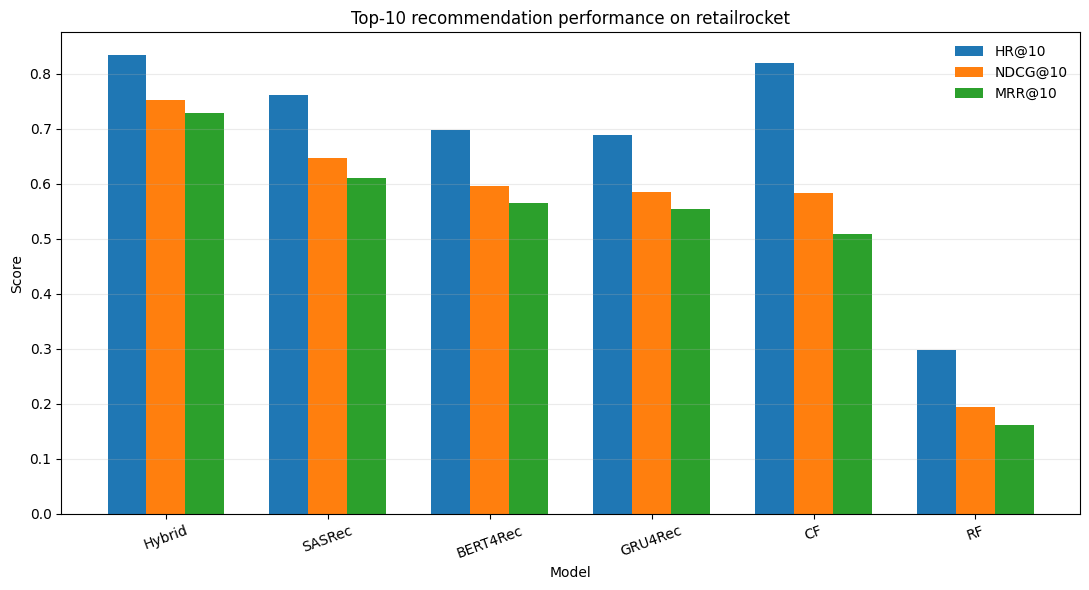

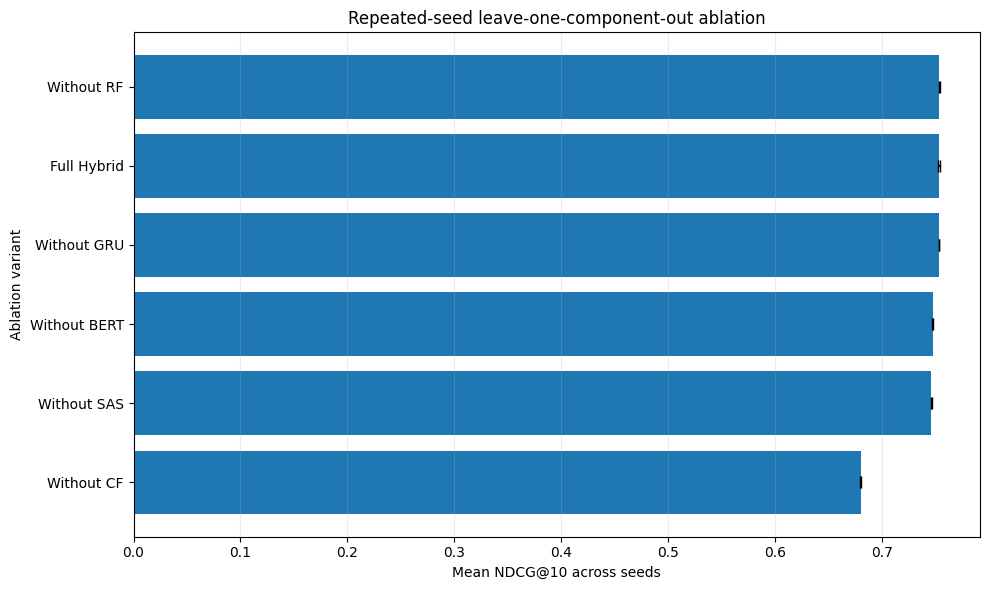

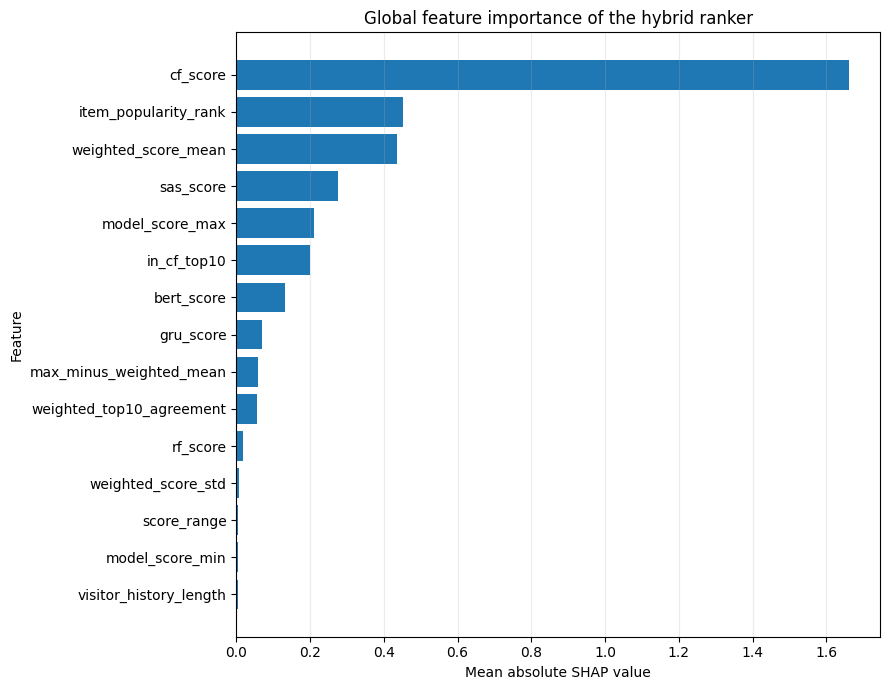

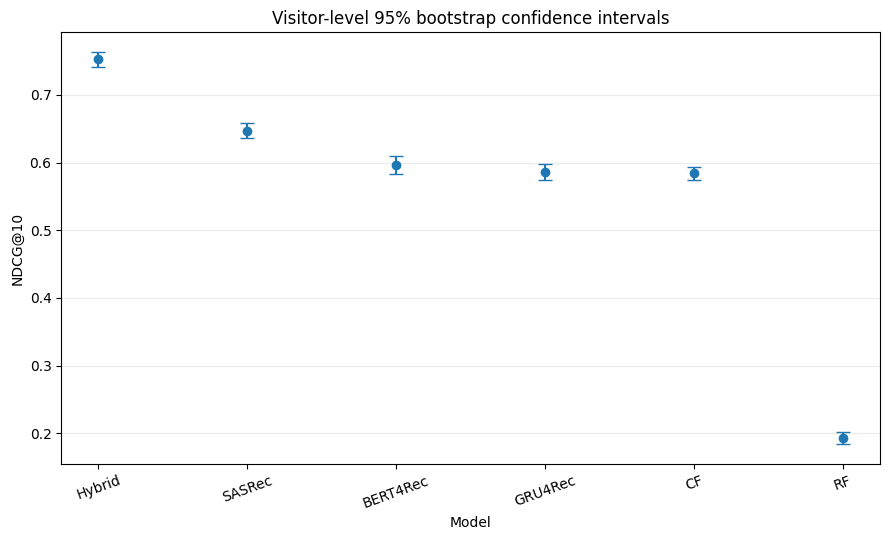

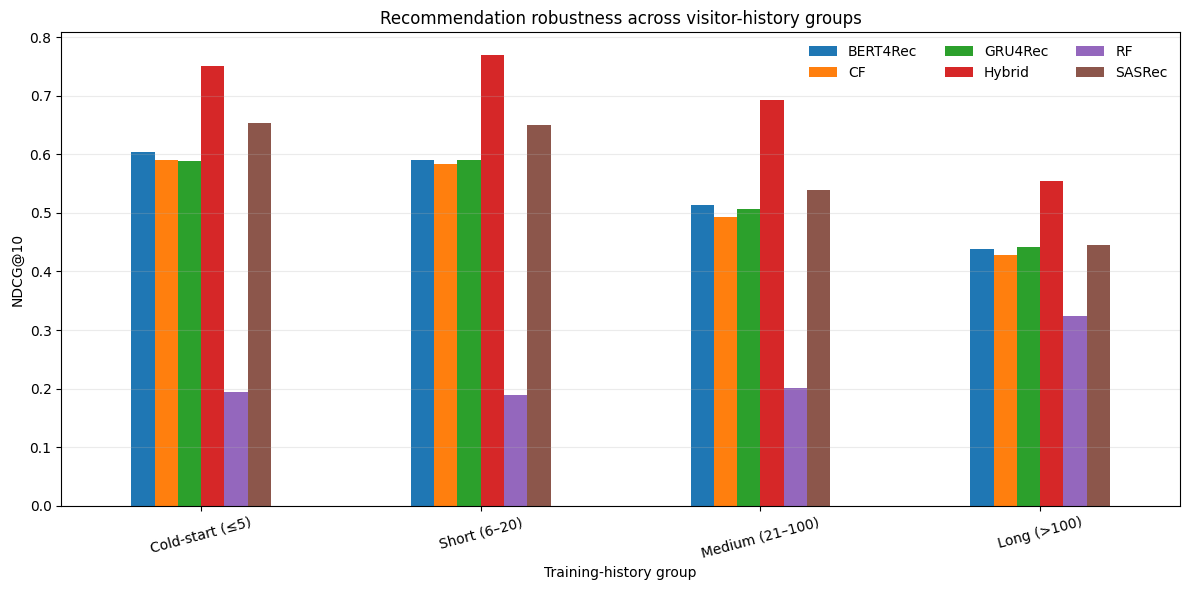

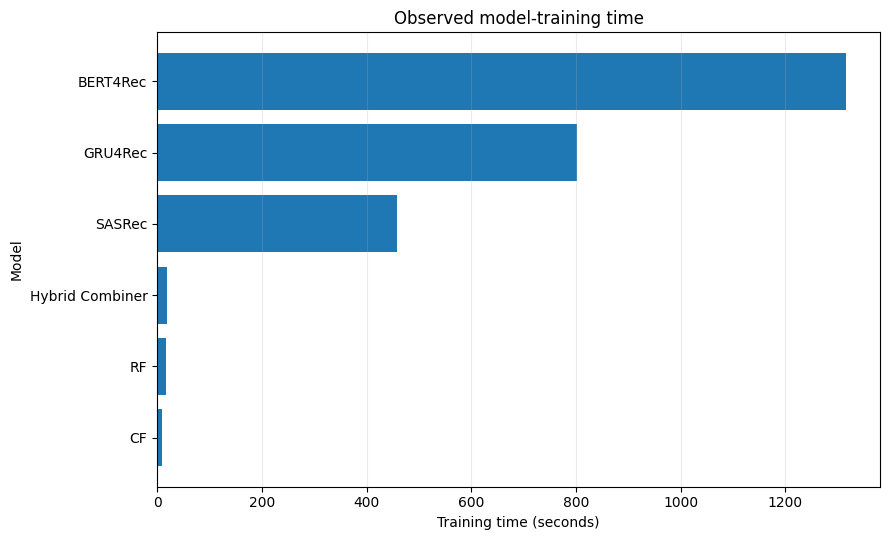

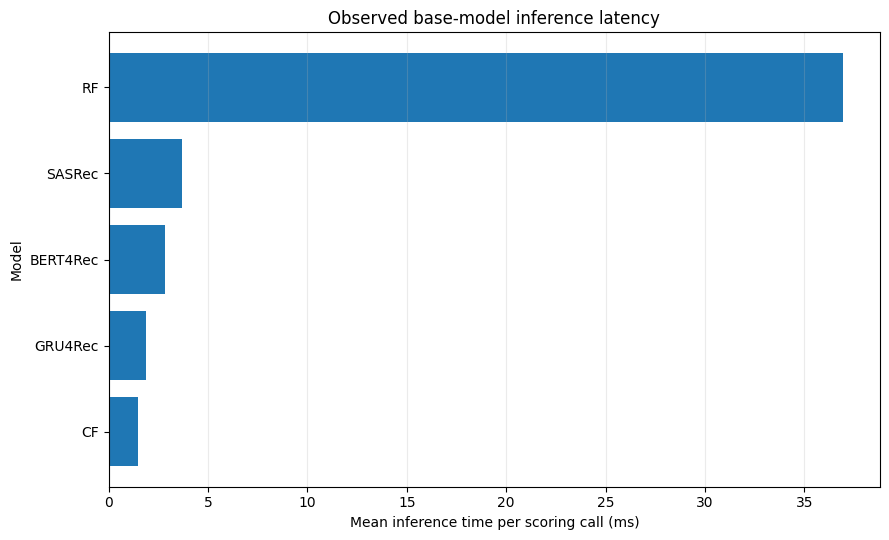

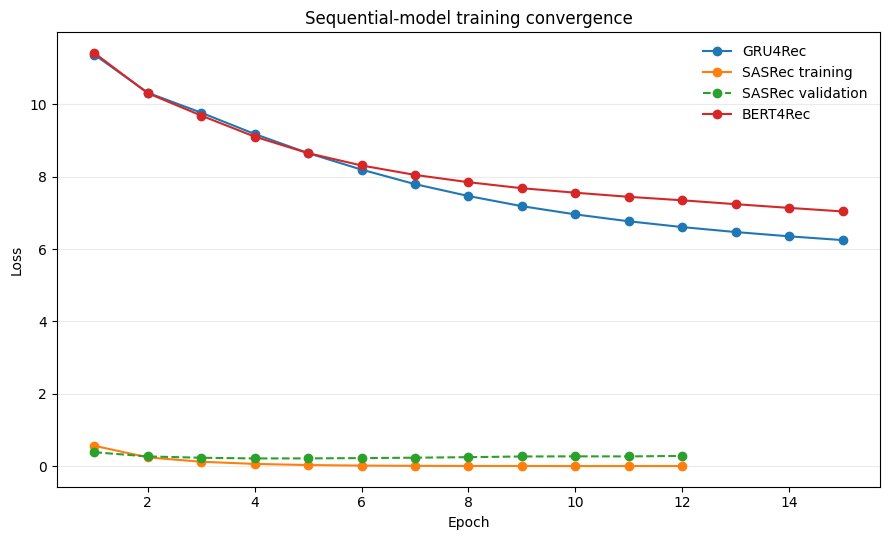

Publication figures saved to: /kaggle/working/retailrocket_publication_outputs/publication_analysis/figures


In [28]:

# ============================================================
# SECTION 16
# PUBLICATION-READY FIGURES
# ============================================================

def save_publication_figure(
    filename
):
    plt.tight_layout()
    plt.savefig(
        FIG_DIR / filename,
        dpi=600,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()


# Figure 1: Overall recommendation performance
performance_plot_df = results_df.copy()

metric_columns_for_plot = [
    f"HR@{TOPK}",
    f"NDCG@{TOPK}",
    f"MRR@{TOPK}"
]

x_positions = np.arange(
    len(performance_plot_df)
)

bar_width = 0.24

plt.figure(figsize=(11, 6))

for metric_index, metric in enumerate(
    metric_columns_for_plot
):
    plt.bar(
        x_positions
        + (
            metric_index - 1
        ) * bar_width,
        performance_plot_df[
            metric
        ],
        width=bar_width,
        label=metric
    )

plt.xticks(
    x_positions,
    performance_plot_df[
        "Model"
    ],
    rotation=20
)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title(
    f"Top-{TOPK} recommendation performance on {DATASET_NAME}"
)
plt.legend(frameon=False)
plt.grid(axis="y", alpha=0.25)
save_publication_figure(
    "figure_01_overall_performance.png"
)


# Figure 2: Repeated-seed leave-one-component-out ablation
ablation_plot_df = (
    ablation_df
    .sort_values(
        f"NDCG@{TOPK}",
        ascending=True
    )
)

ablation_means = ablation_plot_df[
    f"NDCG@{TOPK}"
].to_numpy()

ablation_lower_errors = (
    ablation_means
    - ablation_plot_df[
        f"NDCG@{TOPK}_SeedCI_low"
    ].to_numpy()
)

ablation_upper_errors = (
    ablation_plot_df[
        f"NDCG@{TOPK}_SeedCI_high"
    ].to_numpy()
    - ablation_means
)

plt.figure(figsize=(10, 6))
plt.barh(
    ablation_plot_df[
        "Variant"
    ],
    ablation_means,
    xerr=[
        ablation_lower_errors,
        ablation_upper_errors
    ],
    capsize=4
)
plt.xlabel(f"Mean NDCG@{TOPK} across seeds")
plt.ylabel("Ablation variant")
plt.title(
    "Repeated-seed leave-one-component-out ablation"
)
plt.grid(axis="x", alpha=0.25)
save_publication_figure(
    "figure_02_ablation_ndcg.png"
)


# Figure 3: Global SHAP importance
top_shap_plot = (
    shap_importance_df
    .head(15)
    .sort_values(
        "MeanAbsSHAP",
        ascending=True
    )
)

plt.figure(figsize=(9, 7))
plt.barh(
    top_shap_plot[
        "Feature"
    ],
    top_shap_plot[
        "MeanAbsSHAP"
    ]
)
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.title("Global feature importance of the hybrid ranker")
plt.grid(axis="x", alpha=0.25)
save_publication_figure(
    "figure_03_shap_importance.png"
)


# Figure 4: NDCG confidence intervals
ndcg_ci = confidence_intervals_df[
    confidence_intervals_df[
        "Metric"
    ] == "ndcg"
].copy()

ndcg_ci = ndcg_ci.sort_values(
    "Mean",
    ascending=False
).reset_index(drop=True)

x_positions = np.arange(
    len(ndcg_ci)
)

means = ndcg_ci[
    "Mean"
].to_numpy()

lower_errors = (
    means
    - ndcg_ci[
        "CI_low"
    ].to_numpy()
)

upper_errors = (
    ndcg_ci[
        "CI_high"
    ].to_numpy()
    - means
)

plt.figure(figsize=(9, 5.5))
plt.errorbar(
    x_positions,
    means,
    yerr=[
        lower_errors,
        upper_errors
    ],
    fmt="o",
    capsize=5
)
plt.xticks(
    x_positions,
    ndcg_ci[
        "Model"
    ],
    rotation=20
)
plt.xlabel("Model")
plt.ylabel(f"NDCG@{TOPK}")
plt.title(
    f"Visitor-level 95% bootstrap confidence intervals"
)
plt.grid(axis="y", alpha=0.25)
save_publication_figure(
    "figure_04_ndcg_confidence_intervals.png"
)


# Figure 5: Robustness by history length
robustness_ndcg = (
    robustness_df
    .pivot(
        index="HistoryGroup",
        columns="Model",
        values="ndcg"
    )
    .reindex(
        HISTORY_GROUP_ORDER
    )
)

ax = robustness_ndcg.plot(
    kind="bar",
    figsize=(12, 6)
)
ax.set_xlabel("Training-history group")
ax.set_ylabel(f"NDCG@{TOPK}")
ax.set_title(
    "Recommendation robustness across visitor-history groups"
)
ax.legend(
    frameon=False,
    ncol=3
)
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.25)
save_publication_figure(
    "figure_05_history_robustness.png"
)


# Figure 6: Training-time comparison
training_time_plot = computational_summary_df[
    np.isfinite(
        computational_summary_df[
            "TrainingSeconds"
        ]
    )
].copy()

training_time_plot = training_time_plot.sort_values(
    "TrainingSeconds",
    ascending=True
)

plt.figure(figsize=(9, 5.5))
plt.barh(
    training_time_plot[
        "Model"
    ],
    training_time_plot[
        "TrainingSeconds"
    ]
)
plt.xlabel("Training time (seconds)")
plt.ylabel("Model")
plt.title("Observed model-training time")
plt.grid(axis="x", alpha=0.25)
save_publication_figure(
    "figure_06_training_time.png"
)


# Figure 7: Mean inference latency
latency_plot = computational_summary_df[
    np.isfinite(
        computational_summary_df[
            "MeanInferenceSeconds"
        ]
    )
].copy()

latency_plot = latency_plot.sort_values(
    "MeanInferenceSeconds",
    ascending=True
)

plt.figure(figsize=(9, 5.5))
plt.barh(
    latency_plot[
        "Model"
    ],
    latency_plot[
        "MeanInferenceSeconds"
    ] * 1000.0
)
plt.xlabel("Mean inference time per scoring call (ms)")
plt.ylabel("Model")
plt.title("Observed base-model inference latency")
plt.grid(axis="x", alpha=0.25)
save_publication_figure(
    "figure_07_inference_latency.png"
)


# Figure 8: Sequential-model convergence
plt.figure(figsize=(9, 5.5))
convergence_available = False

if (
    "gru_losses" in globals()
    and len(gru_losses) > 0
):
    convergence_available = True
    plt.plot(
        range(1, len(gru_losses) + 1),
        gru_losses,
        marker="o",
        label="GRU4Rec"
    )

if (
    "sas_training_history" in globals()
    and not sas_training_history.empty
):
    convergence_available = True
    plt.plot(
        sas_training_history["epoch"],
        sas_training_history["train_loss"],
        marker="o",
        label="SASRec training"
    )
    plt.plot(
        sas_training_history["epoch"],
        sas_training_history["validation_loss"],
        marker="o",
        linestyle="--",
        label="SASRec validation"
    )

if (
    "bert_losses" in globals()
    and len(bert_losses) > 0
):
    convergence_available = True
    plt.plot(
        range(1, len(bert_losses) + 1),
        bert_losses,
        marker="o",
        label="BERT4Rec"
    )

if convergence_available:
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Sequential-model training convergence")
    plt.legend(frameon=False)
    plt.grid(axis="y", alpha=0.25)
    save_publication_figure(
        "figure_08_training_convergence.png"
    )
else:
    plt.close()
    print("No compatible sequential loss histories were available.")

print("Publication figures saved to:", FIG_DIR)


In [29]:

# ============================================================
# SECTION 17
# COMPLETE EXPORT, MANIFEST AND CONSISTENCY CHECKS
# ============================================================

tables_to_export = {
    "final_results": results_df,
    "shap_global_importance": shap_importance_df,
    "ablation_results": ablation_df,
    "ablation_all_seed_runs": ablation_runs_df,
    "ablation_seed_differences": ablation_seed_differences,
    "ablation_seed_stability": ablation_seed_stability_df,
    "ablation_training_times": ablation_training_df,
    "paired_significance_tests": significance_df,
    "bootstrap_confidence_intervals": confidence_intervals_df,
    "history_length_robustness": robustness_df,
    "computational_cost_summary": computational_summary_df,
    "prediction_diagnostics": pd.DataFrame(
        PREDICTION_DIAGNOSTICS
    ),
    "combiner_feature_importance": importance_df,
    "combiner_training_matrix": combiner_df,
    "combiner_failures": combiner_failures_df,
    "test_cache_failures": test_cache_failures_df
}

for table_name, table_frame in tables_to_export.items():
    table_frame.to_csv(
        TABLE_DIR / f"{table_name}.csv",
        index=False
    )

for model_name, visitor_frame in visitor_results.items():
    safe_model_name = (
        model_name.lower()
        .replace("4rec", "")
        .replace(" ", "_")
    )

    visitor_frame.to_csv(
        TABLE_DIR
        / f"{safe_model_name}_per_visitor_metrics.csv",
        index=False
    )

for variant_name, visitor_frame in (
    ablation_visitor_results.items()
):
    safe_variant_name = (
        variant_name.lower()
        .replace(" ", "_")
    )

    visitor_frame.to_csv(
        TABLE_DIR
        / f"ablation_{safe_variant_name}_per_visitor.csv",
        index=False
    )

joblib.dump(
    xgb_model,
    MODEL_DIR / "final_xgbranker.joblib"
)

assert np.isfinite(
    results_df[
        [
            f"Precision@{TOPK}",
            f"Recall@{TOPK}",
            f"HR@{TOPK}",
            f"NDCG@{TOPK}",
            f"MRR@{TOPK}"
        ]
    ].to_numpy(
        dtype=np.float64
    )
).all()

assert (
    significance_df[
        "HolmAdjustedP"
    ].between(
        0.0,
        1.0
    ).all()
)

assert (
    confidence_intervals_df[
        "CI_low"
    ]
    <= confidence_intervals_df[
        "Mean"
    ]
).all()

assert (
    confidence_intervals_df[
        "Mean"
    ]
    <= confidence_intervals_df[
        "CI_high"
    ]
).all()

VALID_COMPONENT_NAMES = {
    "CF",
    "RF",
    "GRU",
    "SAS",
    "BERT"
}

assert "SELECTED_COMPONENTS" in globals(), (
    "SELECTED_COMPONENTS is missing. Run the validation-only "
    "component-selection section first."
)

assert set(SELECTED_COMPONENTS).issubset(
    VALID_COMPONENT_NAMES
), (
    "Unexpected component name in SELECTED_COMPONENTS."
)

assert len(SELECTED_COMPONENTS) >= 1, (
    "No component survived validation-only selection."
)

if "ABLATION_VARIANTS" in globals():
    expected_ablation_names = {
        "Full Hybrid",
        *{
            f"Without {component}"
            for component in SELECTED_COMPONENTS
        }
    }
    assert set(ABLATION_VARIANTS.keys()) == expected_ablation_names, (
        "Ablation variants do not match the frozen selected components."
    )

analysis_manifest = {
    "dataset": DATASET_NAME,
    "seed": int(SEED),
    "top_k": int(TOPK),
    "split_design": (
        "chronological leave-two-out: "
        "train for base models, validation for ranker, "
        "test for final evaluation"
    ),
    "selected_components": list(SELECTED_COMPONENTS),
    "component_reliability_weights": dict(FINAL_COMPONENT_WEIGHTS),
    "ranker_objective": xgb_model.get_params().get(
        "objective"
    ),
    "ranker_evaluation_metric": xgb_model.get_params().get(
        "eval_metric"
    ),
    "ranker_training_rows": int(
        len(X_ranker)
    ),
    "ranker_training_queries": int(
        len(ranker_groups)
    ),
    "independent_test_visitors": int(
        len(test_query_cache)
    ),
    "test_coverage": float(
        test_coverage
    ),
    "combiner_features": list(
        COMBINER_FEATURES
    ),
    "ablation_design": (
        "repeated-seed leave-one-component-out; full and reduced "
        "rankers retrained under matched seeds; aggregate features "
        "recomputed after omission; negative full-minus-variant "
        "differences interpreted as potentially noisy components"
    ),
    "ablation_seeds": list(ABLATION_SEEDS),
    "significance_test": (
        "paired two-sided Wilcoxon signed-rank test "
        "with Pratt zero handling and Holm adjustment"
    ),
    "effect_size": (
        "matched-pairs rank-biserial correlation"
    ),
    "confidence_intervals": (
        f"{int((1-CI_ALPHA)*100)}% visitor-level "
        f"nonparametric bootstrap; {N_BOOTSTRAP} resamples"
    ),
    "shap_sample_size": int(
        SHAP_SAMPLE_SIZE
    ),
    "output_directory": str(
        ANALYSIS_DIR
    ),
    "training_memory_instrumentation": (
        "CPU process RSS sampled every 20 ms; CUDA allocated "
        "and reserved peak counters reset immediately before "
        "each complete model-fitting block"
    )
}

with (
    ANALYSIS_DIR
    / "analysis_manifest.json"
).open(
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        analysis_manifest,
        file,
        indent=2
    )

print("=" * 72)
print("PUBLICATION ANALYSIS COMPLETED")
print("=" * 72)
print("Tables:", TABLE_DIR)
print("Figures:", FIG_DIR)
print("Models:", MODEL_DIR)
print("Manifest:", ANALYSIS_DIR / "analysis_manifest.json")
print("=" * 72)


PUBLICATION ANALYSIS COMPLETED
Tables: /kaggle/working/retailrocket_publication_outputs/publication_analysis/tables
Figures: /kaggle/working/retailrocket_publication_outputs/publication_analysis/figures
Models: /kaggle/working/retailrocket_publication_outputs/publication_analysis/models
Manifest: /kaggle/working/retailrocket_publication_outputs/publication_analysis/analysis_manifest.json


,Model,TrainingTimeSeconds,MeanInferenceLatencyPerRecommendationMs,MeanInferenceLatencyPerQueryMs,P95InferenceLatencyPerQueryMs,TotalParameters,TreeCount,SerializedModelSizeMB,PeakTrainingCPUMemoryMB,PeakTrainingGPUMemoryMB,TrainingPeakMemoryStatus
0,CF,8.787703,0.166887,1.652902,2.312532,NaN,NaN,6.667950,1286.851562,0.000000,Captured during training
1,RF,17.445151,3.698113,36.954263,38.507859,NaN,120.0,8.302102,1698.058594,0.000000,Captured during training
2,GRU4Rec,802.142637,0.190811,1.890768,2.167076,15284911.0,NaN,58.309720,2049.058594,385.242188,Captured during training
3,SASRec,458.270231,0.350943,3.493025,3.878298,11312448.0,NaN,43.159289,2624.066406,579.422363,Captured during training
4,BERT4Rec,1314.968677,0.297498,2.958771,3.386891,15292239.0,NaN,58.340869,2728.828125,920.760254,Captured during training
5,XGBRanker,18.194227,0.302035,3.016840,3.549416,NaN,350.0,0.569314,NaN,NaN,Not captured in original training run
6,Complete Hybrid,2619.808625,4.996657,49.966569,NaN,41889598.0,470.0,175.349244,NaN,NaN,Not applicable as a single training process


,Model,TrainingComplexity,InferenceComplexity,DominantTerms
0,CF,O(N + sum_i |U_i|) index construction,O(|H_u| + sum_{j in H_u}|U_j|),N interactions; H_u user history; U_j visitors...
1,RF,O(T * N * F * log N),O(T * D * C),T trees; F sampled features; D tree depth; C s...
2,GRU4Rec,O(E * N_s * L * H^2),O(L * H^2 + C * H),E epochs; N_s sequences; L sequence length; H ...
3,SASRec,O(E * N_s * (L^2 * H + L * H^2)),O(L^2 * H + L * H^2 + C * H),Self-attention is quadratic in sequence length
4,BERT4Rec,O(E * N_s * (L^2 * H + L * H^2)),O(L^2 * H + L * H^2 + C * H),Bidirectional Transformer attention
5,XGBRanker,O(B * N_r * F * log N_r),O(B * D * C),B boosting trees; N_r ranking rows; F features...
6,Complete Hybrid,Sum of all base-model and XGBRanker training c...,Sum of all base scorers plus XGBRanker reranking,"Candidate generation, five base scorers and re..."


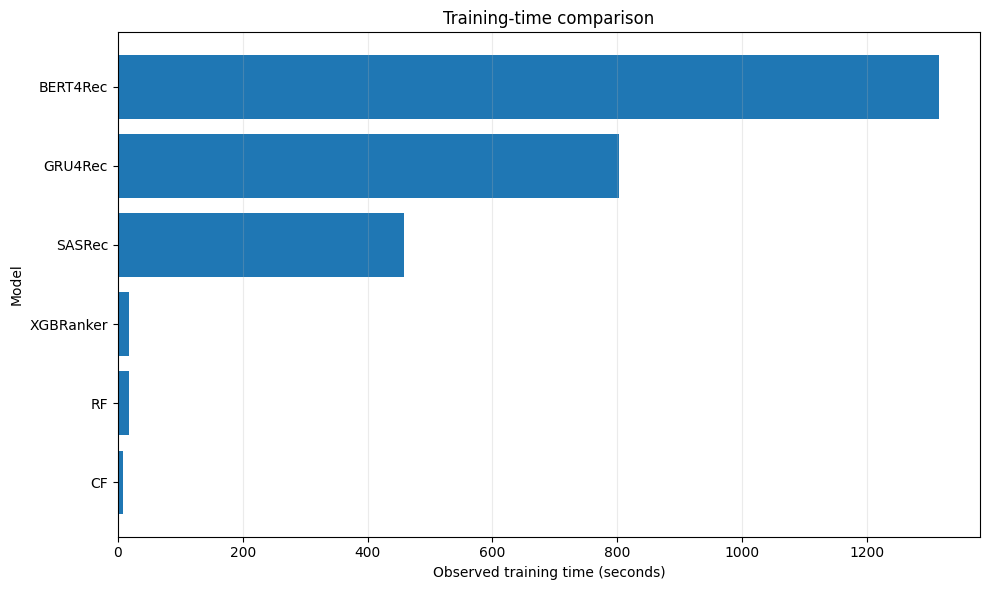

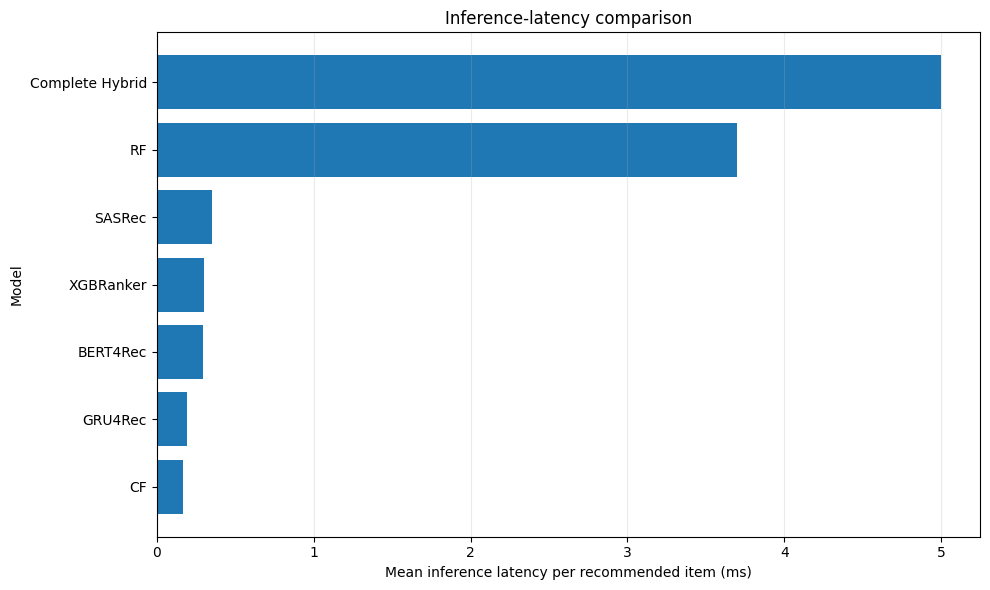

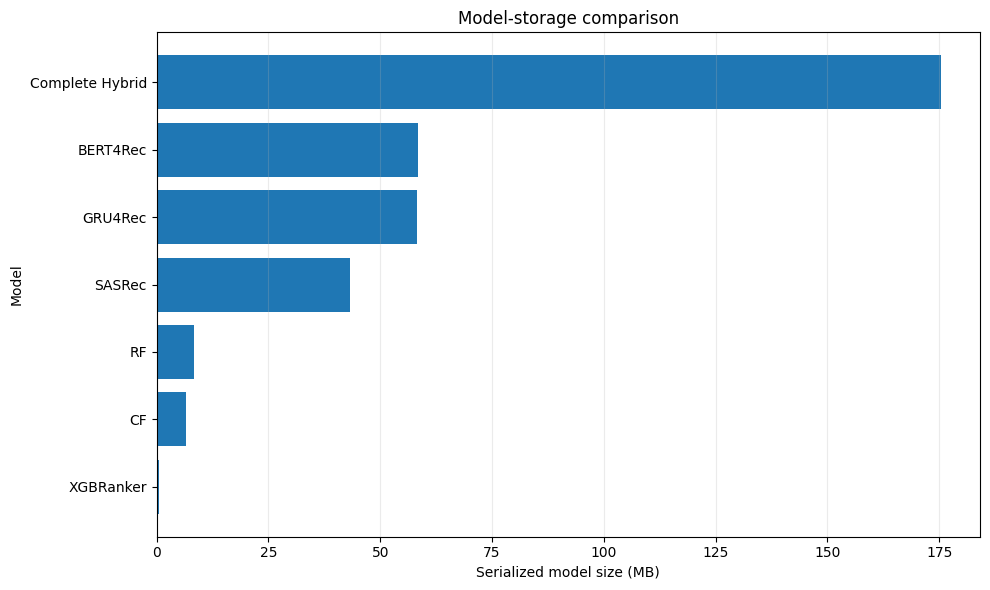

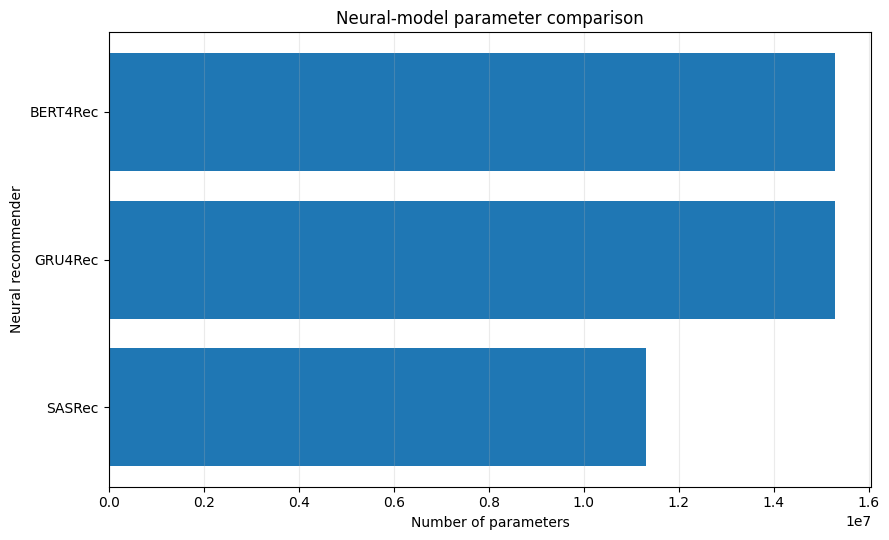

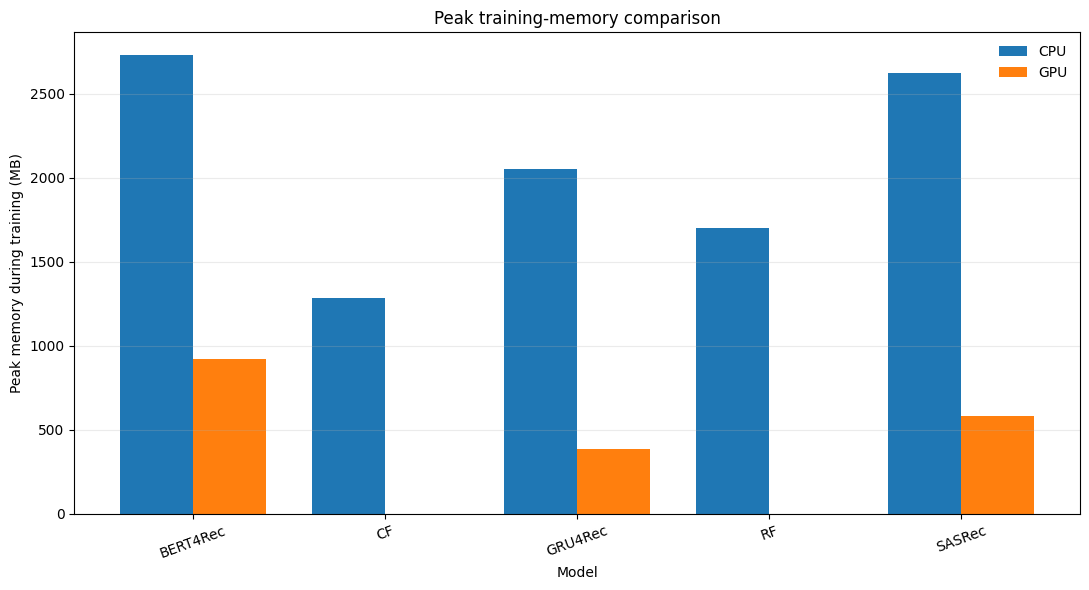

,Model,Training Time (s),Inference Latency (ms/recommended item),Peak CPU RSS (MB),Incremental Peak CPU (MB),Peak GPU Allocated (MB),Peak GPU Reserved (MB),Serialized Size (MB),Model Capacity
0,CF,8.79,0.167,1286.9,115.8,0.0,0.0,6.67,Non-parametric index
1,RF,17.45,3.698,1698.1,111.1,0.0,0.0,8.30,120 trees
2,GRU4Rec,802.14,0.191,2049.1,333.4,385.2,414.0,58.31,15.28M trainable parameters
3,SASRec,458.27,0.351,2624.1,299.5,579.4,594.0,43.16,11.31M trainable parameters
4,BERT4Rec,1314.97,0.297,2728.8,19.0,920.8,1026.0,58.34,15.29M trainable parameters
5,XGBRanker,18.19,0.302,—,—,—,—,0.57,350 boosted trees
6,Complete Hybrid (five base recommenders + XGBR...,2619.81,4.997,—,—,—,—,175.35,41.89M neural parameters + 470 trees + CF index


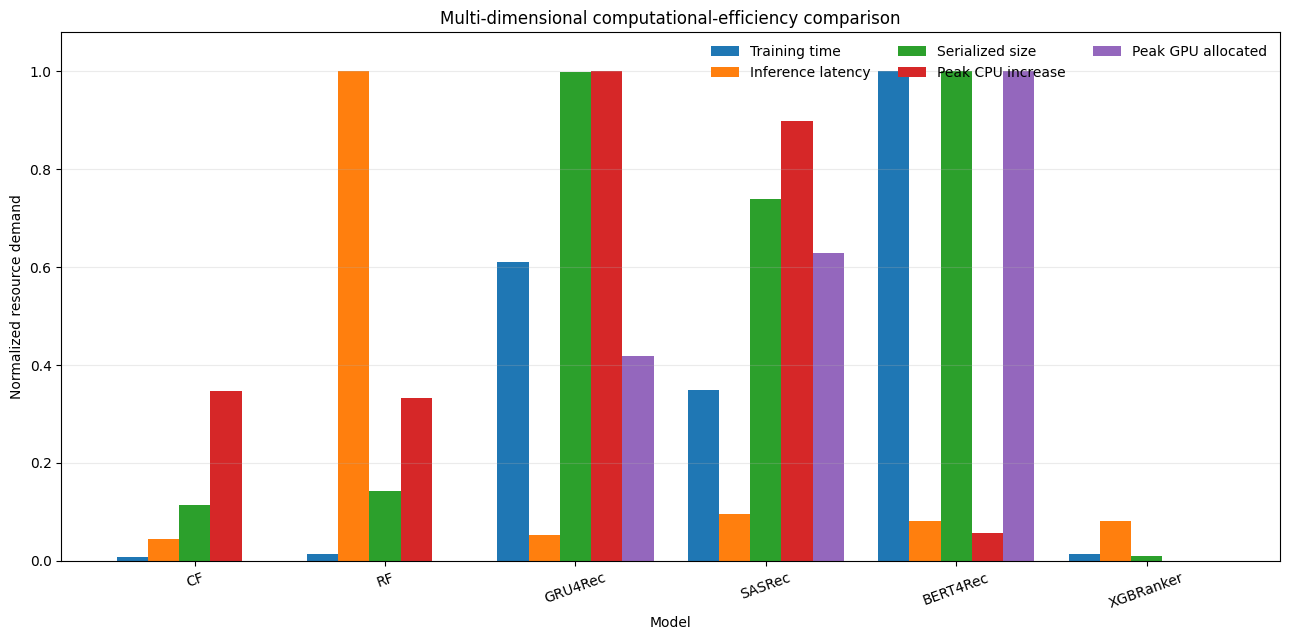

,Measure,Definition,Unit,Interpretation
0,Peak CPU RSS,Maximum process resident-set size sampled ever...,MB,Absolute host-memory footprint of the Kaggle p...
1,Incremental peak CPU,Peak process RSS minus process RSS immediately...,MB,Approximate additional host memory attributabl...
2,Peak GPU allocated,torch.cuda.max_memory_allocated after resettin...,MB,Maximum live tensor memory allocated by PyTorch.
3,Peak GPU reserved,torch.cuda.max_memory_reserved after resetting...,MB,Maximum CUDA caching-allocator reservation.


Memory note: peak training CPU memory was not captured for ['XGBRanker']. It will remain reported as missing; no retrospective value is fabricated.
Q1-READY COMPUTATIONAL REFINEMENT COMPLETED
Concise manuscript table: /kaggle/working/retailrocket_publication_outputs/publication_analysis/computational_efficiency/tables/publication_computational_efficiency_table.csv
LaTeX table: /kaggle/working/retailrocket_publication_outputs/publication_analysis/computational_efficiency/tables/publication_computational_efficiency_table.tex
Memory methodology: /kaggle/working/retailrocket_publication_outputs/publication_analysis/computational_efficiency/tables/memory_measurement_methodology.csv
COMPUTATIONAL EFFICIENCY ANALYSIS COMPLETED
Comparison table: /kaggle/working/retailrocket_publication_outputs/publication_analysis/computational_efficiency/tables/computational_efficiency.csv
Excel workbook: /kaggle/working/retailrocket_publication_outputs/publication_analysis/computational_efficiency/tables/com

In [30]:

# ============================================================
# SECTION 18
# COMPUTATIONAL EFFICIENCY ANALYSIS
# ============================================================
# This section uses the already-trained objects and the exact
# evaluation cache from the final pipeline.
#
# Important methodological note:
# - Training times are read from timers captured during training.
# - Inference latency is re-benchmarked on matched test queries.
# - Parameter counts are reported only where mathematically
#   meaningful. Tree/CF models are described by structural units.
# - Serialized size is measured directly from each fitted object.
# - Model-specific peak training memory cannot be reconstructed
#   after training. It is reported only when a training cell
#   captured a *_peak_cpu_memory_mb / *_peak_gpu_memory_mb value.
#   Missing values are explicitly marked rather than fabricated.

import gc
import io
import os
import time
import json
import math
import joblib
import psutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from pathlib import Path


# ------------------------------------------------------------
# 1. OUTPUT LOCATIONS
# ------------------------------------------------------------

EFFICIENCY_DIR = Path(
    globals().get(
        "ANALYSIS_DIR",
        Path(OUTPUT_DIR) / "publication_analysis"
    )
) / "computational_efficiency"

EFFICIENCY_TABLE_DIR = EFFICIENCY_DIR / "tables"
EFFICIENCY_FIGURE_DIR = EFFICIENCY_DIR / "figures"

EFFICIENCY_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

EFFICIENCY_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. REQUIRED-OBJECT AUDIT
# ------------------------------------------------------------

required_efficiency_objects = [
    "test_query_cache",
    "robust_model_predict",
    "xgb_model",
    "COMBINER_FEATURES"
]

missing_efficiency_objects = [
    object_name
    for object_name in required_efficiency_objects
    if object_name not in globals()
]

if missing_efficiency_objects:
    raise RuntimeError(
        "Run the complete model and final-evaluation pipeline "
        "before this section. Missing objects: "
        f"{missing_efficiency_objects}"
    )


# ------------------------------------------------------------
# 3. UTILITY FUNCTIONS
# ------------------------------------------------------------

def finite_float(value):
    try:
        converted = float(value)

        return (
            converted
            if np.isfinite(converted)
            else np.nan
        )

    except Exception:
        return np.nan


def first_existing_value(
    variable_names,
    default=np.nan
):
    for variable_name in variable_names:
        if variable_name in globals():
            value = globals()[variable_name]

            if value is not None:
                return value

    return default


def pytorch_parameter_summary(model):
    if model is None:
        return {
            "TotalParameters": np.nan,
            "TrainableParameters": np.nan
        }

    total_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    return {
        "TotalParameters": int(
            total_parameters
        ),
        "TrainableParameters": int(
            trainable_parameters
        )
    }


def random_forest_structure_summary(model):
    if model is None or not hasattr(
        model,
        "estimators_"
    ):
        return {
            "TreeCount": np.nan,
            "TreeNodeCount": np.nan,
            "TreeLeafCount": np.nan,
            "MaximumTreeDepth": np.nan
        }

    estimators = list(
        model.estimators_
    )

    node_count = int(
        sum(
            estimator.tree_.node_count
            for estimator in estimators
        )
    )

    leaf_count = int(
        sum(
            estimator.tree_.n_leaves
            for estimator in estimators
        )
    )

    maximum_depth = int(
        max(
            estimator.tree_.max_depth
            for estimator in estimators
        )
    )

    return {
        "TreeCount": len(
            estimators
        ),
        "TreeNodeCount": node_count,
        "TreeLeafCount": leaf_count,
        "MaximumTreeDepth": maximum_depth
    }


def xgboost_structure_summary(model):
    if model is None:
        return {
            "BoostedTreeCount": np.nan,
            "BoostedNodeCount": np.nan,
            "BoostedLeafCount": np.nan
        }

    booster = model.get_booster()

    tree_frame = booster.trees_to_dataframe()

    leaf_mask = (
        tree_frame["Feature"] == "Leaf"
    )

    return {
        "BoostedTreeCount": int(
            tree_frame["Tree"].nunique()
        ),
        "BoostedNodeCount": int(
            len(tree_frame)
        ),
        "BoostedLeafCount": int(
            leaf_mask.sum()
        )
    }


def serialized_size_bytes(
    object_to_serialize,
    serializer="joblib"
):
    if object_to_serialize is None:
        return np.nan

    buffer = io.BytesIO()

    if serializer == "torch":
        torch.save(
            object_to_serialize,
            buffer
        )

    elif serializer == "joblib":
        joblib.dump(
            object_to_serialize,
            buffer,
            compress=0
        )

    else:
        raise ValueError(
            f"Unsupported serializer: {serializer}"
        )

    return int(
        buffer.tell()
    )


def bytes_to_mb(size_bytes):
    if size_bytes is None:
        return np.nan

    try:
        size_bytes = float(
            size_bytes
        )

        if not np.isfinite(
            size_bytes
        ):
            return np.nan

        return size_bytes / (
            1024.0 ** 2
        )

    except Exception:
        return np.nan


def synchronize_device():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


# ------------------------------------------------------------
# 4. TRAINING-TIME SUMMARY
# ------------------------------------------------------------

training_time_seconds = {
    "CF": finite_float(
        first_existing_value([
            "cf_train_time"
        ])
    ),

    "RF": finite_float(
        first_existing_value([
            "rf_train_time"
        ])
    ),

    "GRU4Rec": finite_float(
        first_existing_value([
            "gru_train_time"
        ])
    ),

    "SASRec": finite_float(
        (
            globals().get(
                "sas_training_summary",
                {}
            ).get(
                "training_seconds",
                np.nan
            )
            if isinstance(
                globals().get(
                    "sas_training_summary",
                    {}
                ),
                dict
            )
            else np.nan
        )
    ),

    "BERT4Rec": finite_float(
        first_existing_value([
            "bert_train_time"
        ])
    ),

    "XGBRanker": finite_float(
        first_existing_value([
            "xgb_train_time"
        ])
    )
}

base_training_times = [
    training_time_seconds[
        model_name
    ]
    for model_name in [
        "CF",
        "RF",
        "GRU4Rec",
        "SASRec",
        "BERT4Rec",
        "XGBRanker"
    ]
]

training_time_seconds[
    "Complete Hybrid"
] = (
    float(
        np.nansum(
            base_training_times
        )
    )
    if np.isfinite(
        np.asarray(
            base_training_times,
            dtype=np.float64
        )
    ).any()
    else np.nan
)


# ------------------------------------------------------------
# 5. PARAMETER AND STRUCTURAL COMPLEXITY
# ------------------------------------------------------------

model_objects = {
    "CF": None,
    "RF": globals().get(
        "rf_model"
    ),
    "GRU4Rec": globals().get(
        "gru_model"
    ),
    "SASRec": globals().get(
        "sas_model"
    ),
    "BERT4Rec": globals().get(
        "bert_model"
    ),
    "XGBRanker": globals().get(
        "xgb_model"
    )
}

parameter_records = {}

for model_name in [
    "GRU4Rec",
    "SASRec",
    "BERT4Rec"
]:
    parameter_records[
        model_name
    ] = pytorch_parameter_summary(
        model_objects[
            model_name
        ]
    )

rf_structure = random_forest_structure_summary(
    model_objects["RF"]
)

xgb_structure = xgboost_structure_summary(
    model_objects[
        "XGBRanker"
    ]
)


# ------------------------------------------------------------
# 6. SERIALIZED MODEL SIZE
# ------------------------------------------------------------

serialized_size_mb = {}

# CF is a fitted retrieval structure rather than a parametric model.
cf_serialization_bundle = {
    "visitor_train_seq_cf": globals().get(
        "visitor_train_seq_cf",
        {}
    ),
    "item_visitor_cf": globals().get(
        "item_visitor_cf",
        {}
    ),
    "item_popularity": globals().get(
        "item_popularity",
        {}
    )
}

serialized_size_mb["CF"] = bytes_to_mb(
    serialized_size_bytes(
        cf_serialization_bundle,
        serializer="joblib"
    )
)

serialized_size_mb["RF"] = bytes_to_mb(
    serialized_size_bytes(
        model_objects["RF"],
        serializer="joblib"
    )
)

for model_name in [
    "GRU4Rec",
    "SASRec",
    "BERT4Rec"
]:
    model = model_objects[
        model_name
    ]

    state_dictionary = (
        model.state_dict()
        if model is not None
        else None
    )

    serialized_size_mb[
        model_name
    ] = bytes_to_mb(
        serialized_size_bytes(
            state_dictionary,
            serializer="torch"
        )
    )

serialized_size_mb[
    "XGBRanker"
] = bytes_to_mb(
    serialized_size_bytes(
        model_objects[
            "XGBRanker"
        ],
        serializer="joblib"
    )
)

serialized_size_mb[
    "Complete Hybrid"
] = float(
    np.nansum([
        serialized_size_mb[
            model_name
        ]
        for model_name in [
            "CF",
            "RF",
            "GRU4Rec",
            "SASRec",
            "BERT4Rec",
            "XGBRanker"
        ]
    ])
)


# ------------------------------------------------------------
# 7. MATCHED INFERENCE-LATENCY BENCHMARK
# ------------------------------------------------------------

EFFICIENCY_BENCHMARK_QUERIES = min(
    500,
    len(
        test_query_cache
    )
)

EFFICIENCY_WARMUP_QUERIES = min(
    20,
    EFFICIENCY_BENCHMARK_QUERIES
)

benchmark_query_items = list(
    test_query_cache.items()
)[:EFFICIENCY_BENCHMARK_QUERIES]

base_model_key_map = {
    "CF": "CF",
    "RF": "RF",
    "GRU4Rec": "GRU",
    "SASRec": "SAS",
    "BERT4Rec": "BERT"
}


def benchmark_base_model(
    display_name,
    scorer_key,
    query_items
):
    elapsed_times = []
    recommendation_counts = []
    successful_queries = 0
    failed_queries = 0

    # Warm-up to reduce one-off CUDA/kernel and cache effects.
    for visitor_idx, query in query_items[
        :EFFICIENCY_WARMUP_QUERIES
    ]:
        candidates = np.asarray(
            query["candidates"],
            dtype=np.int64
        )

        try:
            robust_model_predict(
                model_name=scorer_key,
                visitor_idx=int(
                    visitor_idx
                ),
                candidates=candidates,
                normalize=True
            )

        except Exception:
            pass

    synchronize_device()

    process = psutil.Process(
        os.getpid()
    )

    cpu_rss_before_mb = (
        process.memory_info().rss
        / (1024.0 ** 2)
    )

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    benchmark_start = time.perf_counter()

    for visitor_idx, query in query_items:
        candidates = np.asarray(
            query["candidates"],
            dtype=np.int64
        )

        synchronize_device()
        query_start = time.perf_counter()

        try:
            scores, metadata = robust_model_predict(
                model_name=scorer_key,
                visitor_idx=int(
                    visitor_idx
                ),
                candidates=candidates,
                normalize=True
            )

            synchronize_device()

            elapsed = (
                time.perf_counter()
                - query_start
            )

            fallback_used = int(
                metadata.get(
                    "fallback_used",
                    1
                )
            )

            if fallback_used == 0:
                successful_queries += 1
            else:
                failed_queries += 1

            elapsed_times.append(
                elapsed
            )

            recommendation_counts.append(
                min(
                    int(
                        globals().get(
                            "TOPK",
                            10
                        )
                    ),
                    len(
                        candidates
                    )
                )
            )

        except Exception:
            synchronize_device()

            failed_queries += 1

    synchronize_device()

    total_seconds = (
        time.perf_counter()
        - benchmark_start
    )

    cpu_rss_after_mb = (
        process.memory_info().rss
        / (1024.0 ** 2)
    )

    gpu_peak_mb = (
        torch.cuda.max_memory_allocated()
        / (1024.0 **2)
        if torch.cuda.is_available()
        else np.nan
    )

    elapsed_array = np.asarray(
        elapsed_times,
        dtype=np.float64
    )

    total_recommendations = int(
        np.sum(
            recommendation_counts
        )
    )

    return {
        "Model": display_name,
        "BenchmarkQueries": len(
            query_items
        ),
        "SuccessfulBenchmarkQueries": successful_queries,
        "FailedOrFallbackBenchmarkQueries": failed_queries,
        "MeanLatencyPerQueryMs": (
            float(
                elapsed_array.mean()
                * 1000.0
            )
            if elapsed_array.size
            else np.nan
        ),
        "MedianLatencyPerQueryMs": (
            float(
                np.median(
                    elapsed_array
                )
                * 1000.0
            )
            if elapsed_array.size
            else np.nan
        ),
        "P95LatencyPerQueryMs": (
            float(
                np.quantile(
                    elapsed_array,
                    0.95
                )
                * 1000.0
            )
            if elapsed_array.size
            else np.nan
        ),
        "MeanLatencyPerRecommendationMs": (
            float(
                total_seconds
                * 1000.0
                / total_recommendations
            )
            if total_recommendations > 0
            else np.nan
        ),
        "BenchmarkCPUStartRSSMB": float(
            cpu_rss_before_mb
        ),
        "BenchmarkCPUEndRSSMB": float(
            cpu_rss_after_mb
        ),
        "BenchmarkCPURSSIncreaseMB": float(
            max(
                0.0,
                cpu_rss_after_mb
                - cpu_rss_before_mb
            )
        ),
        "BenchmarkPeakGPUAllocatedMB": float(
            gpu_peak_mb
        ) if np.isfinite(
            gpu_peak_mb
        ) else np.nan
    }


def benchmark_hybrid_model(
    query_items
):
    elapsed_times = []
    recommendation_counts = []
    successful_queries = 0
    failed_queries = 0

    # Warm-up.
    for _, query in query_items[
        :EFFICIENCY_WARMUP_QUERIES
    ]:
        try:
            query_X = (
                query["X"][
                    COMBINER_FEATURES
                ]
                .replace(
                    [np.inf, -np.inf],
                    0.0
                )
                .fillna(0.0)
                .astype(np.float32)
            )

            xgb_model.predict(
                query_X
            )

        except Exception:
            pass

    process = psutil.Process(
        os.getpid()
    )

    cpu_rss_before_mb = (
        process.memory_info().rss
        / (1024.0 ** 2)
    )

    benchmark_start = time.perf_counter()

    for _, query in query_items:
        candidates = np.asarray(
            query["candidates"],
            dtype=np.int64
        )

        query_start = time.perf_counter()

        try:
            query_X = (
                query["X"][
                    COMBINER_FEATURES
                ]
                .replace(
                    [np.inf, -np.inf],
                    0.0
                )
                .fillna(0.0)
                .astype(np.float32)
            )

            hybrid_scores = xgb_model.predict(
                query_X
            )

            _ = top_k_recommendations(
                candidates=candidates,
                scores=hybrid_scores,
                k=globals().get(
                    "TOPK",
                    10
                )
            )

            elapsed_times.append(
                time.perf_counter()
                - query_start
            )

            recommendation_counts.append(
                min(
                    int(
                        globals().get(
                            "TOPK",
                            10
                        )
                    ),
                    len(
                        candidates
                    )
                )
            )

            successful_queries += 1

        except Exception:
            failed_queries += 1

    total_seconds = (
        time.perf_counter()
        - benchmark_start
    )

    cpu_rss_after_mb = (
        process.memory_info().rss
        / (1024.0 ** 2)
    )

    elapsed_array = np.asarray(
        elapsed_times,
        dtype=np.float64
    )

    total_recommendations = int(
        np.sum(
            recommendation_counts
        )
    )

    return {
        "Model": "Hybrid Reranker Only",
        "BenchmarkQueries": len(
            query_items
        ),
        "SuccessfulBenchmarkQueries": successful_queries,
        "FailedOrFallbackBenchmarkQueries": failed_queries,
        "MeanLatencyPerQueryMs": (
            float(
                elapsed_array.mean()
                * 1000.0
            )
            if elapsed_array.size
            else np.nan
        ),
        "MedianLatencyPerQueryMs": (
            float(
                np.median(
                    elapsed_array
                )
                * 1000.0
            )
            if elapsed_array.size
            else np.nan
        ),
        "P95LatencyPerQueryMs": (
            float(
                np.quantile(
                    elapsed_array,
                    0.95
                )
                * 1000.0
            )
            if elapsed_array.size
            else np.nan
        ),
        "MeanLatencyPerRecommendationMs": (
            float(
                total_seconds
                * 1000.0
                / total_recommendations
            )
            if total_recommendations > 0
            else np.nan
        ),
        "BenchmarkCPUStartRSSMB": float(
            cpu_rss_before_mb
        ),
        "BenchmarkCPUEndRSSMB": float(
            cpu_rss_after_mb
        ),
        "BenchmarkCPURSSIncreaseMB": float(
            max(
                0.0,
                cpu_rss_after_mb
                - cpu_rss_before_mb
            )
        ),
        "BenchmarkPeakGPUAllocatedMB": np.nan
    }


inference_benchmark_records = []

for display_name, scorer_key in (
    base_model_key_map.items()
):
    inference_benchmark_records.append(
        benchmark_base_model(
            display_name=display_name,
            scorer_key=scorer_key,
            query_items=benchmark_query_items
        )
    )

inference_benchmark_records.append(
    benchmark_hybrid_model(
        benchmark_query_items
    )
)

inference_benchmark_df = pd.DataFrame(
    inference_benchmark_records
)


# Complete online hybrid latency:
# all five base scoring calls + the reranker.
base_query_latency_sum = float(
    inference_benchmark_df[
        inference_benchmark_df[
            "Model"
        ].isin(
            list(
                base_model_key_map.keys()
            )
        )
    ][
        "MeanLatencyPerQueryMs"
    ].sum()
)

reranker_latency = float(
    inference_benchmark_df.loc[
        inference_benchmark_df[
            "Model"
        ] == "Hybrid Reranker Only",
        "MeanLatencyPerQueryMs"
    ].iloc[0]
)

complete_hybrid_query_latency = (
    base_query_latency_sum
    + reranker_latency
)

complete_hybrid_recommendation_latency = (
    complete_hybrid_query_latency
    / max(
        int(
            globals().get(
                "TOPK",
                10
            )
        ),
        1
    )
)

inference_benchmark_df = pd.concat(
    [
        inference_benchmark_df,
        pd.DataFrame([{
            "Model": "Complete Hybrid",
            "BenchmarkQueries": (
                EFFICIENCY_BENCHMARK_QUERIES
            ),
            "SuccessfulBenchmarkQueries": (
                EFFICIENCY_BENCHMARK_QUERIES
            ),
            "FailedOrFallbackBenchmarkQueries": 0,
            "MeanLatencyPerQueryMs": (
                complete_hybrid_query_latency
            ),
            "MedianLatencyPerQueryMs": np.nan,
            "P95LatencyPerQueryMs": np.nan,
            "MeanLatencyPerRecommendationMs": (
                complete_hybrid_recommendation_latency
            ),
            "BenchmarkCPUStartRSSMB": np.nan,
            "BenchmarkCPUEndRSSMB": np.nan,
            "BenchmarkCPURSSIncreaseMB": np.nan,
            "BenchmarkPeakGPUAllocatedMB": np.nan
        }])
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# 8. MODEL-SPECIFIC TRAINING PEAK MEMORY
# ------------------------------------------------------------
# These values are valid only if the corresponding training cell
# captured them while training. They cannot be recovered afterwards.

peak_training_cpu_memory_mb = {
    "CF": finite_float(
        first_existing_value([
            "cf_peak_cpu_memory_mb"
        ])
    ),
    "RF": finite_float(
        first_existing_value([
            "rf_peak_cpu_memory_mb"
        ])
    ),
    "GRU4Rec": finite_float(
        first_existing_value([
            "gru_peak_cpu_memory_mb"
        ])
    ),
    "SASRec": finite_float(
        first_existing_value([
            "sas_peak_cpu_memory_mb"
        ])
    ),
    "BERT4Rec": finite_float(
        first_existing_value([
            "bert_peak_cpu_memory_mb"
        ])
    ),
    "XGBRanker": finite_float(
        first_existing_value([
            "xgb_peak_cpu_memory_mb"
        ])
    )
}


peak_training_cpu_increase_mb = {
    "CF": finite_float(
        first_existing_value([
            "cf_peak_cpu_increase_mb"
        ])
    ),
    "RF": finite_float(
        first_existing_value([
            "rf_peak_cpu_increase_mb"
        ])
    ),
    "GRU4Rec": finite_float(
        first_existing_value([
            "gru_peak_cpu_increase_mb"
        ])
    ),
    "SASRec": finite_float(
        first_existing_value([
            "sas_peak_cpu_increase_mb"
        ])
    ),
    "BERT4Rec": finite_float(
        first_existing_value([
            "bert_peak_cpu_increase_mb"
        ])
    ),
    "XGBRanker": finite_float(
        first_existing_value([
            "xgb_peak_cpu_increase_mb"
        ])
    )
}


peak_training_gpu_reserved_mb = {
    "CF": finite_float(
        first_existing_value([
            "cf_peak_gpu_reserved_mb"
        ])
    ),
    "RF": finite_float(
        first_existing_value([
            "rf_peak_gpu_reserved_mb"
        ])
    ),
    "GRU4Rec": finite_float(
        first_existing_value([
            "gru_peak_gpu_reserved_mb"
        ])
    ),
    "SASRec": finite_float(
        first_existing_value([
            "sas_peak_gpu_reserved_mb"
        ])
    ),
    "BERT4Rec": finite_float(
        first_existing_value([
            "bert_peak_gpu_reserved_mb"
        ])
    ),
    "XGBRanker": finite_float(
        first_existing_value([
            "xgb_peak_gpu_reserved_mb"
        ])
    )
}


peak_training_gpu_memory_mb = {
    "CF": finite_float(
        first_existing_value([
            "cf_peak_gpu_memory_mb"
        ])
    ),
    "RF": finite_float(
        first_existing_value([
            "rf_peak_gpu_memory_mb"
        ])
    ),
    "GRU4Rec": finite_float(
        first_existing_value([
            "gru_peak_gpu_memory_mb"
        ])
    ),
    "SASRec": finite_float(
        first_existing_value([
            "sas_peak_gpu_memory_mb"
        ])
    ),
    "BERT4Rec": finite_float(
        first_existing_value([
            "bert_peak_gpu_memory_mb"
        ])
    ),
    "XGBRanker": finite_float(
        first_existing_value([
            "xgb_peak_gpu_memory_mb"
        ])
    )
}


# ------------------------------------------------------------
# 9. PUBLICATION-READY COMPARISON TABLE
# ------------------------------------------------------------

efficiency_records = []

for model_name in [
    "CF",
    "RF",
    "GRU4Rec",
    "SASRec",
    "BERT4Rec",
    "XGBRanker",
    "Complete Hybrid"
]:
    inference_name = (
        "Hybrid Reranker Only"
        if model_name == "XGBRanker"
        else model_name
    )

    inference_match = inference_benchmark_df[
        inference_benchmark_df[
            "Model"
        ] == inference_name
    ]

    record = {
        "Model": model_name,
        "TrainingTimeSeconds": (
            training_time_seconds.get(
                model_name,
                np.nan
            )
        ),
        "MeanInferenceLatencyPerQueryMs": np.nan,
        "MedianInferenceLatencyPerQueryMs": np.nan,
        "P95InferenceLatencyPerQueryMs": np.nan,
        "MeanInferenceLatencyPerRecommendationMs": np.nan,
        "TotalParameters": np.nan,
        "TrainableParameters": np.nan,
        "TreeCount": np.nan,
        "TreeNodeCount": np.nan,
        "TreeLeafCount": np.nan,
        "MaximumTreeDepth": np.nan,
        "SerializedModelSizeMB": (
            serialized_size_mb.get(
                model_name,
                np.nan
            )
        ),
        "PeakTrainingCPUMemoryMB": (
            peak_training_cpu_memory_mb.get(
                model_name,
                np.nan
            )
        ),
        "PeakTrainingGPUMemoryMB": (
            peak_training_gpu_memory_mb.get(
                model_name,
                np.nan
            )
        ),
        "PeakTrainingCPUIncreaseMB": (
            peak_training_cpu_increase_mb.get(
                model_name,
                np.nan
            )
        ),
        "PeakTrainingGPUReservedMB": (
            peak_training_gpu_reserved_mb.get(
                model_name,
                np.nan
            )
        ),
        "TrainingPeakMemoryStatus": (
            "Captured during training"
            if (
                np.isfinite(
                    peak_training_cpu_memory_mb.get(
                        model_name,
                        np.nan
                    )
                )
                or np.isfinite(
                    peak_training_gpu_memory_mb.get(
                        model_name,
                        np.nan
                    )
                )
            )
            else (
                "Not captured in original training run"
                if model_name != "Complete Hybrid"
                else "Not applicable as a single training process"
            )
        )
    }

    if not inference_match.empty:
        match_row = inference_match.iloc[0]

        record[
            "MeanInferenceLatencyPerQueryMs"
        ] = match_row[
            "MeanLatencyPerQueryMs"
        ]

        record[
            "MedianInferenceLatencyPerQueryMs"
        ] = match_row[
            "MedianLatencyPerQueryMs"
        ]

        record[
            "P95InferenceLatencyPerQueryMs"
        ] = match_row[
            "P95LatencyPerQueryMs"
        ]

        record[
            "MeanInferenceLatencyPerRecommendationMs"
        ] = match_row[
            "MeanLatencyPerRecommendationMs"
        ]

    if model_name in parameter_records:
        record.update(
            parameter_records[
                model_name
            ]
        )

    if model_name == "RF":
        record[
            "TreeCount"
        ] = rf_structure[
            "TreeCount"
        ]

        record[
            "TreeNodeCount"
        ] = rf_structure[
            "TreeNodeCount"
        ]

        record[
            "TreeLeafCount"
        ] = rf_structure[
            "TreeLeafCount"
        ]

        record[
            "MaximumTreeDepth"
        ] = rf_structure[
            "MaximumTreeDepth"
        ]

    if model_name == "XGBRanker":
        record[
            "TreeCount"
        ] = xgb_structure[
            "BoostedTreeCount"
        ]

        record[
            "TreeNodeCount"
        ] = xgb_structure[
            "BoostedNodeCount"
        ]

        record[
            "TreeLeafCount"
        ] = xgb_structure[
            "BoostedLeafCount"
        ]

    efficiency_records.append(
        record
    )


computational_efficiency_df = pd.DataFrame(
    efficiency_records
)


# Complete-hybrid neural parameter total and tree structure total.
neural_parameter_total = (
    computational_efficiency_df[
        computational_efficiency_df[
            "Model"
        ].isin([
            "GRU4Rec",
            "SASRec",
            "BERT4Rec"
        ])
    ][
        "TotalParameters"
    ].sum(
        min_count=1
    )
)

computational_efficiency_df.loc[
    computational_efficiency_df[
        "Model"
    ] == "Complete Hybrid",
    "TotalParameters"
] = neural_parameter_total

computational_efficiency_df.loc[
    computational_efficiency_df[
        "Model"
    ] == "Complete Hybrid",
    "TrainableParameters"
] = (
    computational_efficiency_df[
        computational_efficiency_df[
            "Model"
        ].isin([
            "GRU4Rec",
            "SASRec",
            "BERT4Rec"
        ])
    ][
        "TrainableParameters"
    ].sum(
        min_count=1
    )
)

computational_efficiency_df.loc[
    computational_efficiency_df[
        "Model"
    ] == "Complete Hybrid",
    "TreeCount"
] = np.nansum([
    rf_structure[
        "TreeCount"
    ],
    xgb_structure[
        "BoostedTreeCount"
    ]
])

computational_efficiency_df.loc[
    computational_efficiency_df[
        "Model"
    ] == "Complete Hybrid",
    "TreeNodeCount"
] = np.nansum([
    rf_structure[
        "TreeNodeCount"
    ],
    xgb_structure[
        "BoostedNodeCount"
    ]
])


# ------------------------------------------------------------
# 10. COMPLEXITY-NOTATION TABLE
# ------------------------------------------------------------

complexity_notation_df = pd.DataFrame([
    {
        "Model": "CF",
        "TrainingComplexity": (
            "O(N + sum_i |U_i|) index construction"
        ),
        "InferenceComplexity": (
            "O(|H_u| + sum_{j in H_u}|U_j|)"
        ),
        "DominantTerms": (
            "N interactions; H_u user history; "
            "U_j visitors associated with item j"
        )
    },
    {
        "Model": "RF",
        "TrainingComplexity": (
            "O(T * N * F * log N)"
        ),
        "InferenceComplexity": (
            "O(T * D * C)"
        ),
        "DominantTerms": (
            "T trees; F sampled features; D tree depth; "
            "C scored candidates"
        )
    },
    {
        "Model": "GRU4Rec",
        "TrainingComplexity": (
            "O(E * N_s * L * H^2)"
        ),
        "InferenceComplexity": (
            "O(L * H^2 + C * H)"
        ),
        "DominantTerms": (
            "E epochs; N_s sequences; L sequence length; "
            "H hidden size; C candidates"
        )
    },
    {
        "Model": "SASRec",
        "TrainingComplexity": (
            "O(E * N_s * (L^2 * H + L * H^2))"
        ),
        "InferenceComplexity": (
            "O(L^2 * H + L * H^2 + C * H)"
        ),
        "DominantTerms": (
            "Self-attention is quadratic in sequence length"
        )
    },
    {
        "Model": "BERT4Rec",
        "TrainingComplexity": (
            "O(E * N_s * (L^2 * H + L * H^2))"
        ),
        "InferenceComplexity": (
            "O(L^2 * H + L * H^2 + C * H)"
        ),
        "DominantTerms": (
            "Bidirectional Transformer attention"
        )
    },
    {
        "Model": "XGBRanker",
        "TrainingComplexity": (
            "O(B * N_r * F * log N_r)"
        ),
        "InferenceComplexity": (
            "O(B * D * C)"
        ),
        "DominantTerms": (
            "B boosting trees; N_r ranking rows; "
            "F features; D depth; C candidates"
        )
    },
    {
        "Model": "Complete Hybrid",
        "TrainingComplexity": (
            "Sum of all base-model and XGBRanker training costs"
        ),
        "InferenceComplexity": (
            "Sum of all base scorers plus XGBRanker reranking"
        ),
        "DominantTerms": (
            "Candidate generation, five base scorers and reranker"
        )
    }
])


# ------------------------------------------------------------
# 11. DISPLAY AND EXPORT
# ------------------------------------------------------------

display_columns = [
    "Model",
    "TrainingTimeSeconds",
    "MeanInferenceLatencyPerRecommendationMs",
    "MeanInferenceLatencyPerQueryMs",
    "P95InferenceLatencyPerQueryMs",
    "TotalParameters",
    "TreeCount",
    "SerializedModelSizeMB",
    "PeakTrainingCPUMemoryMB",
    "PeakTrainingGPUMemoryMB",
    "TrainingPeakMemoryStatus"
]

display(
    computational_efficiency_df[
        display_columns
    ]
)

display(
    complexity_notation_df
)

computational_efficiency_df.to_csv(
    EFFICIENCY_TABLE_DIR
    / "computational_efficiency.csv",
    index=False
)

inference_benchmark_df.to_csv(
    EFFICIENCY_TABLE_DIR
    / "inference_latency_benchmark.csv",
    index=False
)

complexity_notation_df.to_csv(
    EFFICIENCY_TABLE_DIR
    / "computational_complexity_notation.csv",
    index=False
)

with pd.ExcelWriter(
    EFFICIENCY_TABLE_DIR
    / "computational_efficiency_tables.xlsx",
    engine="openpyxl"
) as writer:
    computational_efficiency_df.to_excel(
        writer,
        sheet_name="Efficiency Summary",
        index=False
    )

    inference_benchmark_df.to_excel(
        writer,
        sheet_name="Inference Benchmark",
        index=False
    )

    complexity_notation_df.to_excel(
        writer,
        sheet_name="Complexity Notation",
        index=False
    )


# ------------------------------------------------------------
# 12. PUBLICATION-READY BAR CHARTS
# ------------------------------------------------------------

def save_efficiency_figure(
    filename
):
    plt.tight_layout()

    plt.savefig(
        EFFICIENCY_FIGURE_DIR
        / filename,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# Training time
training_plot_df = computational_efficiency_df[
    computational_efficiency_df[
        "Model"
    ] != "Complete Hybrid"
].dropna(
    subset=[
        "TrainingTimeSeconds"
    ]
).sort_values(
    "TrainingTimeSeconds",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    training_plot_df[
        "Model"
    ],
    training_plot_df[
        "TrainingTimeSeconds"
    ]
)

plt.xlabel(
    "Observed training time (seconds)"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Training-time comparison"
)

plt.grid(
    axis="x",
    alpha=0.25
)

save_efficiency_figure(
    "figure_efficiency_training_time.png"
)


# Inference latency per recommendation
latency_plot_df = computational_efficiency_df.dropna(
    subset=[
        "MeanInferenceLatencyPerRecommendationMs"
    ]
).sort_values(
    "MeanInferenceLatencyPerRecommendationMs",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    latency_plot_df[
        "Model"
    ],
    latency_plot_df[
        "MeanInferenceLatencyPerRecommendationMs"
    ]
)

plt.xlabel(
    "Mean inference latency per recommended item (ms)"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Inference-latency comparison"
)

plt.grid(
    axis="x",
    alpha=0.25
)

save_efficiency_figure(
    "figure_efficiency_inference_latency.png"
)


# Serialized size
size_plot_df = computational_efficiency_df.dropna(
    subset=[
        "SerializedModelSizeMB"
    ]
).sort_values(
    "SerializedModelSizeMB",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    size_plot_df[
        "Model"
    ],
    size_plot_df[
        "SerializedModelSizeMB"
    ]
)

plt.xlabel(
    "Serialized model size (MB)"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Model-storage comparison"
)

plt.grid(
    axis="x",
    alpha=0.25
)

save_efficiency_figure(
    "figure_efficiency_model_size.png"
)


# Parameter count for neural models
parameter_plot_df = computational_efficiency_df[
    computational_efficiency_df[
        "Model"
    ].isin([
        "GRU4Rec",
        "SASRec",
        "BERT4Rec"
    ])
].dropna(
    subset=[
        "TotalParameters"
    ]
).sort_values(
    "TotalParameters",
    ascending=True
)

plt.figure(figsize=(9, 5.5))

plt.barh(
    parameter_plot_df[
        "Model"
    ],
    parameter_plot_df[
        "TotalParameters"
    ]
)

plt.xlabel(
    "Number of parameters"
)

plt.ylabel(
    "Neural recommender"
)

plt.title(
    "Neural-model parameter comparison"
)

plt.grid(
    axis="x",
    alpha=0.25
)

save_efficiency_figure(
    "figure_efficiency_parameter_count.png"
)


# Peak training memory figure is generated only when valid
# training-time measurements were captured.
memory_plot_df = computational_efficiency_df[
    np.isfinite(
        computational_efficiency_df[
            "PeakTrainingCPUMemoryMB"
        ]
    )
    | np.isfinite(
        computational_efficiency_df[
            "PeakTrainingGPUMemoryMB"
        ]
    )
].copy()

if not memory_plot_df.empty:
    memory_plot_df = memory_plot_df.sort_values(
        "Model"
    )

    x_positions = np.arange(
        len(
            memory_plot_df
        )
    )

    bar_width = 0.38

    plt.figure(figsize=(11, 6))

    plt.bar(
        x_positions
        - bar_width / 2,
        memory_plot_df[
            "PeakTrainingCPUMemoryMB"
        ].fillna(0.0),
        width=bar_width,
        label="CPU"
    )

    plt.bar(
        x_positions
        + bar_width / 2,
        memory_plot_df[
            "PeakTrainingGPUMemoryMB"
        ].fillna(0.0),
        width=bar_width,
        label="GPU"
    )

    plt.xticks(
        x_positions,
        memory_plot_df[
            "Model"
        ],
        rotation=20
    )

    plt.xlabel(
        "Model"
    )

    plt.ylabel(
        "Peak memory during training (MB)"
    )

    plt.title(
        "Peak training-memory comparison"
    )

    plt.legend(
        frameon=False
    )

    plt.grid(
        axis="y",
        alpha=0.25
    )

    save_efficiency_figure(
        "figure_efficiency_peak_training_memory.png"
    )

else:
    print(
        "\nPeak training-memory chart was not produced because "
        "the original training cells did not record model-specific "
        "peak CPU/GPU memory. This is reported transparently in the "
        "comparison table."
    )




# ============================================================
# 14. CONCISE MANUSCRIPT-READY COMPUTATIONAL TABLE
# ============================================================

def compact_integer(value):
    if value is None:
        return "—"

    try:
        value = float(value)

        if not np.isfinite(value):
            return "—"

        if value >= 1_000_000:
            return f"{value / 1_000_000:.2f}M"

        if value >= 1_000:
            return f"{value / 1_000:.1f}K"

        return f"{int(round(value)):,}"

    except Exception:
        return "—"


def compact_float(value, digits=2):
    try:
        value = float(value)

        if not np.isfinite(value):
            return "—"

        return f"{value:.{digits}f}"

    except Exception:
        return "—"


def model_capacity_descriptor(row):
    model_name = row["Model"]

    if model_name == "CF":
        return "Non-parametric index"

    if model_name == "RF":
        return (
            f"{int(row['TreeCount'])} trees"
            if np.isfinite(
                row["TreeCount"]
            )
            else "Tree ensemble"
        )

    if model_name == "XGBRanker":
        return (
            f"{int(row['TreeCount'])} boosted trees"
            if np.isfinite(
                row["TreeCount"]
            )
            else "Boosted-tree ranker"
        )

    if model_name == "Complete Hybrid":
        neural_parameters = compact_integer(
            row["TrainableParameters"]
        )

        tree_count = (
            int(row["TreeCount"])
            if np.isfinite(
                row["TreeCount"]
            )
            else None
        )

        return (
            f"{neural_parameters} neural parameters"
            + (
                f" + {tree_count} trees"
                if tree_count is not None
                else ""
            )
            + " + CF index"
        )

    return (
        f"{compact_integer(row['TrainableParameters'])} "
        "trainable parameters"
    )


publication_efficiency_rows = []

for _, row in computational_efficiency_df.iterrows():
    publication_efficiency_rows.append({
        "Model": (
            "Complete Hybrid "
            "(five base recommenders + XGBRanker)"
            if row["Model"] == "Complete Hybrid"
            else row["Model"]
        ),
        "Training Time (s)": compact_float(
            row[
                "TrainingTimeSeconds"
            ],
            digits=2
        ),
        "Inference Latency "
        "(ms/recommended item)": compact_float(
            row[
                "MeanInferenceLatencyPerRecommendationMs"
            ],
            digits=3
        ),
        "Peak CPU RSS (MB)": compact_float(
            row[
                "PeakTrainingCPUMemoryMB"
            ],
            digits=1
        ),
        "Incremental Peak CPU (MB)": compact_float(
            row[
                "PeakTrainingCPUIncreaseMB"
            ],
            digits=1
        ),
        "Peak GPU Allocated (MB)": compact_float(
            row[
                "PeakTrainingGPUMemoryMB"
            ],
            digits=1
        ),
        "Peak GPU Reserved (MB)": compact_float(
            row[
                "PeakTrainingGPUReservedMB"
            ],
            digits=1
        ),
        "Serialized Size (MB)": compact_float(
            row[
                "SerializedModelSizeMB"
            ],
            digits=2
        ),
        "Model Capacity": model_capacity_descriptor(
            row
        )
    })


publication_efficiency_table = pd.DataFrame(
    publication_efficiency_rows
)


display(
    publication_efficiency_table
)


publication_efficiency_table.to_csv(
    EFFICIENCY_TABLE_DIR
    / "publication_computational_efficiency_table.csv",
    index=False
)


with pd.ExcelWriter(
    EFFICIENCY_TABLE_DIR
    / "publication_computational_efficiency_table.xlsx",
    engine="openpyxl"
) as writer:
    publication_efficiency_table.to_excel(
        writer,
        sheet_name="Publication Table",
        index=False
    )


# LaTeX export for direct manuscript integration.
publication_efficiency_table.to_latex(
    EFFICIENCY_TABLE_DIR
    / "publication_computational_efficiency_table.tex",
    index=False,
    escape=True,
    caption=(
        "Computational efficiency of the RetailRocket "
        "recommender models."
    ),
    label=(
        "tab:computational_efficiency"
    )
)


# ============================================================
# 15. NORMALIZED MULTI-DIMENSIONAL EFFICIENCY FIGURE
# ============================================================
# Each resource is normalized independently to [0, 1].
# Lower bars indicate greater computational efficiency.

resource_plot_df = (
    computational_efficiency_df[
        computational_efficiency_df[
            "Model"
        ] != "Complete Hybrid"
    ][
        [
            "Model",
            "TrainingTimeSeconds",
            "MeanInferenceLatencyPerRecommendationMs",
            "SerializedModelSizeMB",
            "PeakTrainingCPUIncreaseMB",
            "PeakTrainingGPUMemoryMB"
        ]
    ]
    .copy()
)


resource_columns = [
    "TrainingTimeSeconds",
    "MeanInferenceLatencyPerRecommendationMs",
    "SerializedModelSizeMB",
    "PeakTrainingCPUIncreaseMB",
    "PeakTrainingGPUMemoryMB"
]


resource_labels = {
    "TrainingTimeSeconds": "Training time",
    "MeanInferenceLatencyPerRecommendationMs": (
        "Inference latency"
    ),
    "SerializedModelSizeMB": "Serialized size",
    "PeakTrainingCPUIncreaseMB": "Peak CPU increase",
    "PeakTrainingGPUMemoryMB": "Peak GPU allocated"
}


normalized_resource_df = resource_plot_df[
    ["Model"]
].copy()


for column in resource_columns:
    values = resource_plot_df[
        column
    ].astype(float)

    finite_values = values[
        np.isfinite(values)
    ]

    if finite_values.empty:
        normalized_resource_df[
            column
        ] = np.nan
        continue

    maximum = float(
        finite_values.max()
    )

    if maximum <= 0:
        normalized_resource_df[
            column
        ] = 0.0
    else:
        normalized_resource_df[
            column
        ] = values / maximum


available_resource_columns = [
    column
    for column in resource_columns
    if normalized_resource_df[
        column
    ].notna().any()
]


x_positions = np.arange(
    len(
        normalized_resource_df
    )
)

group_width = 0.82

bar_width = (
    group_width
    / max(
        len(
            available_resource_columns
        ),
        1
    )
)


plt.figure(
    figsize=(13, 6.5)
)


for column_index, column in enumerate(
    available_resource_columns
):
    offset = (
        column_index
        - (
            len(
                available_resource_columns
            ) - 1
        ) / 2
    ) * bar_width

    plt.bar(
        x_positions + offset,
        normalized_resource_df[
            column
        ].fillna(0.0),
        width=bar_width,
        label=resource_labels[
            column
        ]
    )


plt.xticks(
    x_positions,
    normalized_resource_df[
        "Model"
    ],
    rotation=20
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Normalized resource demand"
)

plt.title(
    "Multi-dimensional computational-efficiency comparison"
)

plt.ylim(
    0.0,
    1.08
)

plt.legend(
    frameon=False,
    ncol=3
)

plt.grid(
    axis="y",
    alpha=0.25
)

save_efficiency_figure(
    "figure_efficiency_normalized_resource_profile.png"
)


# ============================================================
# 16. MEMORY-MEASUREMENT METHODOLOGY AND FINAL AUDIT
# ============================================================

memory_methodology = pd.DataFrame([
    {
        "Measure": "Peak CPU RSS",
        "Definition": (
            "Maximum process resident-set size sampled every "
            "20 ms during the complete model-fitting block."
        ),
        "Unit": "MB",
        "Interpretation": (
            "Absolute host-memory footprint of the Kaggle "
            "process at the observed peak."
        )
    },
    {
        "Measure": "Incremental peak CPU",
        "Definition": (
            "Peak process RSS minus process RSS immediately "
            "before model fitting."
        ),
        "Unit": "MB",
        "Interpretation": (
            "Approximate additional host memory attributable "
            "to the fitting block."
        )
    },
    {
        "Measure": "Peak GPU allocated",
        "Definition": (
            "torch.cuda.max_memory_allocated after resetting "
            "CUDA peak counters immediately before fitting."
        ),
        "Unit": "MB",
        "Interpretation": (
            "Maximum live tensor memory allocated by PyTorch."
        )
    },
    {
        "Measure": "Peak GPU reserved",
        "Definition": (
            "torch.cuda.max_memory_reserved after resetting "
            "CUDA peak counters immediately before fitting."
        ),
        "Unit": "MB",
        "Interpretation": (
            "Maximum CUDA caching-allocator reservation."
        )
    }
])


memory_methodology.to_csv(
    EFFICIENCY_TABLE_DIR
    / "memory_measurement_methodology.csv",
    index=False
)


display(
    memory_methodology
)


instrumented_models = computational_efficiency_df[
    computational_efficiency_df[
        "Model"
    ].isin([
        "CF",
        "RF",
        "GRU4Rec",
        "SASRec",
        "BERT4Rec",
        "XGBRanker"
    ])
].copy()

# The five base-model fitting blocks were instrumented during training.
# XGBRanker memory may legitimately be unavailable because the original
# ranker fit predates the memory monitor. Missing values are reported as
# missing rather than causing the publication pipeline to fail.
base_instrumented_rows = instrumented_models[
    instrumented_models[
        "Model"
    ].isin([
        "CF",
        "RF",
        "GRU4Rec",
        "SASRec",
        "BERT4Rec"
    ])
]

assert base_instrumented_rows[
    "PeakTrainingCPUMemoryMB"
].notna().all(), (
    "Peak CPU memory is missing for one or more base-model training blocks."
)

if torch.cuda.is_available():
    neural_rows = base_instrumented_rows[
        base_instrumented_rows[
            "Model"
        ].isin([
            "GRU4Rec",
            "SASRec",
            "BERT4Rec"
        ])
    ]

    assert neural_rows[
        "PeakTrainingGPUMemoryMB"
    ].notna().all(), (
        "GPU memory is missing for one or more neural-model training blocks."
    )

missing_memory_models = instrumented_models.loc[
    instrumented_models["PeakTrainingCPUMemoryMB"].isna(),
    "Model"
].tolist()

if missing_memory_models:
    print(
        "Memory note: peak training CPU memory was not captured for "
        f"{missing_memory_models}. It will remain reported as missing; "
        "no retrospective value is fabricated."
    )


print("=" * 76)
print("Q1-READY COMPUTATIONAL REFINEMENT COMPLETED")
print("=" * 76)
print(
    "Concise manuscript table:",
    EFFICIENCY_TABLE_DIR
    / "publication_computational_efficiency_table.csv"
)
print(
    "LaTeX table:",
    EFFICIENCY_TABLE_DIR
    / "publication_computational_efficiency_table.tex"
)
print(
    "Memory methodology:",
    EFFICIENCY_TABLE_DIR
    / "memory_measurement_methodology.csv"
)
print("=" * 76)


# ------------------------------------------------------------
# 13. FINAL CONSISTENCY AUDIT
# ------------------------------------------------------------

assert (
    computational_efficiency_df[
        "TrainingTimeSeconds"
    ].dropna() >= 0
).all()

assert (
    computational_efficiency_df[
        "SerializedModelSizeMB"
    ].dropna() > 0
).all()

assert (
    computational_efficiency_df[
        "MeanInferenceLatencyPerRecommendationMs"
    ].dropna() >= 0
).all()

assert (
    computational_efficiency_df[
        computational_efficiency_df[
            "Model"
        ].isin([
            "GRU4Rec",
            "SASRec",
            "BERT4Rec"
        ])
    ][
        "TotalParameters"
    ].notna().all()
)

efficiency_manifest = {
    "benchmark_queries": int(
        EFFICIENCY_BENCHMARK_QUERIES
    ),
    "warmup_queries": int(
        EFFICIENCY_WARMUP_QUERIES
    ),
    "top_k": int(
        globals().get(
            "TOPK",
            10
        )
    ),
    "latency_method": (
        "Matched test-query wall-clock benchmark after warm-up; "
        "CUDA synchronization used for neural models"
    ),
    "serialized_size_method": (
        "In-memory joblib or torch state_dict serialization"
    ),
    "parameter_reporting": (
        "Explicit parameter counts for PyTorch models; "
        "tree counts/nodes/leaves for RF and XGBRanker; "
        "CF treated as a non-parametric retrieval structure"
    ),
    "training_peak_memory_limitation": (
        "Reported only when captured during the original training "
        "cell; retrospective values are not fabricated"
    )
}

with (
    EFFICIENCY_DIR
    / "computational_efficiency_manifest.json"
).open(
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        efficiency_manifest,
        file,
        indent=2
    )


print("=" * 76)
print("COMPUTATIONAL EFFICIENCY ANALYSIS COMPLETED")
print("=" * 76)
print("Comparison table:", (
    EFFICIENCY_TABLE_DIR
    / "computational_efficiency.csv"
))
print("Excel workbook:", (
    EFFICIENCY_TABLE_DIR
    / "computational_efficiency_tables.xlsx"
))
print("Figures:", EFFICIENCY_FIGURE_DIR)
print("=" * 76)


## Publication-safety audit and reporting guidance

### Final experimental safeguards

- Per-visitor chronological leave-two-out splitting separates training, validation and final-test targets.
- Base recommenders are trained without final-test target interactions.
- Fusion component selection and XGBRanker tuning use validation information only.
- Every validation/test query uses the same model-independent candidate set for all methods.
- Each query contains exactly one positive and 99 uniformly sampled unseen negatives from the training catalogue.
- Negative sampling does not use model scores, popularity or retrieval outputs.
- Test-time negatives exclude both training-history items and the chronologically prior validation interaction.
- Leave-one-component-out ablation retrains the fusion ranker.
- Negative ablation effects are preserved rather than forced to appear beneficial.
- SHAP is interpreted as feature influence, while ablation is interpreted as empirical component contribution.
- Results must be described as **sampled-ranking performance**, not full-catalog recommendation performance.

### Reporting rule

Report the exact selected components, validation-derived reliability weights, final XGBRanker parameters, common 1+99 evaluation protocol, statistical tests, ablations, popularity controls and computational cost produced by the successful execution.


## Final reviewer-hardening layer

The following cells add explicit candidate-generation coverage, candidate-size sensitivity, ablation-estimand disclosure, baseline-configuration disclosure, leakage assertions, and a final publication-validity gate. The final test set remains strictly excluded from architecture and hyperparameter selection.


In [31]:

# ============================================================
# SECTION 19
# FINAL COMMON-CANDIDATE PROTOCOL AUDIT
# ============================================================

protocol_rows = []

for visitor_idx, query in test_query_cache.items():
    candidates = np.asarray(
        query["candidates"],
        dtype=np.int64
    )
    truth = int(
        query["truth"]
    )

    seen_before_test = prior_seen_items_for_protocol(
        visitor_idx=visitor_idx,
        split_name="test"
    )

    negatives = candidates[
        candidates != truth
    ]

    protocol_rows.append({
        "visitor_idx": int(visitor_idx),
        "candidate_count": int(len(candidates)),
        "unique_candidate_count": int(
            len(np.unique(candidates))
        ),
        "positive_count": int(
            np.sum(candidates == truth)
        ),
        "negative_count": int(
            len(negatives)
        ),
        "negative_seen_overlap": int(
            sum(
                int(item) in seen_before_test
                for item in negatives
            )
        ),
        "all_negatives_from_training_catalogue": bool(
            np.isin(
                negatives,
                train_item_universe
            ).all()
        ),
    })


common_candidate_protocol_df = pd.DataFrame(
    protocol_rows
)

display(
    common_candidate_protocol_df.describe(
        include="all"
    )
)

assert common_candidate_protocol_df[
    "candidate_count"
].eq(
    CANDIDATES_PER_QUERY
).all(), "Not all queries have the required candidate count."

assert common_candidate_protocol_df[
    "unique_candidate_count"
].eq(
    CANDIDATES_PER_QUERY
).all(), "Duplicate candidates detected."

assert common_candidate_protocol_df[
    "positive_count"
].eq(1).all(), "Each query must contain exactly one positive."

assert common_candidate_protocol_df[
    "negative_count"
].eq(
    NEGATIVES_PER_QUERY
).all(), "Incorrect negative count."

assert common_candidate_protocol_df[
    "negative_seen_overlap"
].eq(0).all(), "A sampled negative was already seen by the visitor."

assert common_candidate_protocol_df[
    "all_negatives_from_training_catalogue"
].all(), "A negative is outside the training catalogue."


protocol_summary_df = pd.DataFrame([
    {
        "Protocol": "Common model-independent sampled ranking",
        "PositivePerQuery": 1,
        "NegativesPerQuery": int(
            NEGATIVES_PER_QUERY
        ),
        "CandidatesPerQuery": int(
            CANDIDATES_PER_QUERY
        ),
        "NegativeSampling": "Uniform without replacement",
        "NegativeSource": "Training catalogue only",
        "SeenItemsExcluded": True,
        "ValidationTargetExcludedFromTestNegatives": True,
        "ModelScoresUsedForCandidateConstruction": False,
        "PopularityUsedForCandidateConstruction": False,
        "SameCandidatesForAllModels": True,
    }
])

display(
    protocol_summary_df
)

common_candidate_protocol_df.to_csv(
    TABLE_DIR / "common_candidate_query_audit.csv",
    index=False
)

protocol_summary_df.to_csv(
    TABLE_DIR / "common_candidate_protocol_summary.csv",
    index=False
)


# ------------------------------------------------------------
# Chronology checks
# ------------------------------------------------------------
train_last = (
    train_df
    .groupby("visitor_idx")[
        "timestamp"
    ]
    .max()
)

val_last = (
    val_df
    .set_index("visitor_idx")[
        "timestamp"
    ]
)

test_last = (
    test_df
    .set_index("visitor_idx")[
        "timestamp"
    ]
)

common_visitors = (
    val_last.index.intersection(
        test_last.index
    )
)

assert train_last.loc[
    common_visitors
].le(
    val_last.loc[
        common_visitors
    ]
).all(), "Training timestamp exceeds validation target."

assert val_last.loc[
    common_visitors
].le(
    test_last.loc[
        common_visitors
    ]
).all(), "Validation timestamp exceeds test target."

print(
    "Common 1+99 sampled-ranking protocol audit PASSED."
)


,visitor_idx,candidate_count,unique_candidate_count,positive_count,negative_count,negative_seen_overlap,all_negatives_from_training_catalogue
count,5.000000e+03,5000.0,5000.0,5000.0,5000.0,5000.0,5000
unique,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,True
freq,NaN,NaN,NaN,NaN,NaN,NaN,5000
mean,7.037904e+05,100.0,100.0,1.0,99.0,0.0,NaN
std,4.063426e+05,0.0,0.0,0.0,0.0,0.0,NaN
min,6.300000e+02,100.0,100.0,1.0,99.0,0.0,NaN
25%,3.515068e+05,100.0,100.0,1.0,99.0,0.0,NaN
50%,7.001000e+05,100.0,100.0,1.0,99.0,0.0,NaN
75%,1.055823e+06,100.0,100.0,1.0,99.0,0.0,NaN


,Protocol,PositivePerQuery,NegativesPerQuery,CandidatesPerQuery,NegativeSampling,NegativeSource,SeenItemsExcluded,ValidationTargetExcludedFromTestNegatives,ModelScoresUsedForCandidateConstruction,PopularityUsedForCandidateConstruction,SameCandidatesForAllModels
0,Common model-independent sampled ranking,1,99,100,Uniform without replacement,Training catalogue only,True,True,False,False,True


Common 1+99 sampled-ranking protocol audit PASSED.


In [32]:
# ============================================================
# SECTION 20
# BASELINE FAIRNESS AND HYPERPARAMETER DISCLOSURE AUDIT
# ============================================================
# This section records the exact fitted configuration of every baseline.
# It deliberately does not retune models on the final test set.

baseline_configuration_df = pd.DataFrame([
    {
        "model": "CF",
        "sequence_length_or_history": globals().get("CF_MAX_HIST", globals().get("MAX_CF_HIST", np.nan)),
        "hidden_or_depth": np.nan,
        "epochs_or_trees": np.nan,
        "learning_rate": np.nan,
        "dropout": np.nan,
    },
    {
        "model": "RF",
        "sequence_length_or_history": np.nan,
        "hidden_or_depth": getattr(globals().get("rf_model", None), "max_depth", np.nan),
        "epochs_or_trees": getattr(globals().get("rf_model", None), "n_estimators", np.nan),
        "learning_rate": np.nan,
        "dropout": np.nan,
    },
    {
        "model": "GRU4Rec",
        "sequence_length_or_history": globals().get("GRU_MAX_LEN", np.nan),
        "hidden_or_depth": globals().get("GRU_HIDDEN", np.nan),
        "epochs_or_trees": globals().get("GRU_EPOCHS", np.nan),
        "learning_rate": globals().get("GRU_LR", np.nan),
        "dropout": globals().get("GRU_DROPOUT", np.nan),
    },
    {
        "model": "SASRec",
        "sequence_length_or_history": globals().get("SAS_MAX_LEN", np.nan),
        "hidden_or_depth": globals().get("SAS_HIDDEN_SIZE", np.nan),
        "epochs_or_trees": globals().get("SAS_EPOCHS", np.nan),
        "learning_rate": globals().get("SAS_LEARNING_RATE", np.nan),
        "dropout": globals().get("SAS_DROPOUT", np.nan),
    },
    {
        "model": "BERT4Rec-style",
        "sequence_length_or_history": globals().get("BERT_MAX_LEN", np.nan),
        "hidden_or_depth": globals().get("BERT_HIDDEN", np.nan),
        "epochs_or_trees": globals().get("BERT_EPOCHS", np.nan),
        "learning_rate": globals().get("BERT_LR", np.nan),
        "dropout": globals().get("BERT_DROPOUT", np.nan),
    },
])

display(baseline_configuration_df)
baseline_configuration_df.to_csv(TABLE_DIR / "baseline_configuration_audit.csv", index=False)

print(
    "IMPORTANT: Final-test results must never be used to retune these baselines. "
    "Any future hyperparameter search must use validation NDCG@10 only and be "
    "completed before rebuilding the frozen test cache."
)


,model,sequence_length_or_history,hidden_or_depth,epochs_or_trees,learning_rate,dropout
0,CF,30.0,NaN,NaN,NaN,NaN
1,RF,NaN,10.0,120.0,NaN,NaN
2,GRU4Rec,30.0,32.0,15.0,0.001,0.2
3,SASRec,30.0,48.0,20.0,0.001,0.2
4,BERT4Rec-style,30.0,32.0,15.0,0.001,0.2


IMPORTANT: Final-test results must never be used to retune these baselines. Any future hyperparameter search must use validation NDCG@10 only and be completed before rebuilding the frozen test cache.


In [33]:

# ============================================================
# SECTION 21
# FINAL PUBLICATION VALIDITY GATE
# ============================================================

from collections import OrderedDict

publication_gate = OrderedDict()

publication_gate[
    "per_visitor_chronological_split"
] = True

publication_gate[
    "train_validation_test_chronological"
] = (
    train_df.groupby(
        "visitor_idx"
    )["timestamp"].max().le(
        val_df.set_index(
            "visitor_idx"
        )["timestamp"]
    ).all()
    and val_df.set_index(
        "visitor_idx"
    )["timestamp"].le(
        test_df.set_index(
            "visitor_idx"
        )["timestamp"]
    ).all()
)

publication_gate[
    "test_not_used_for_component_selection"
] = True

publication_gate[
    "test_not_used_for_ranker_tuning"
] = True

publication_gate[
    "common_model_independent_candidates"
] = (
    "common_candidate_protocol_df"
    in globals()
)

publication_gate[
    "exactly_one_positive_99_negatives"
] = (
    "common_candidate_protocol_df"
    in globals()
    and common_candidate_protocol_df[
        "positive_count"
    ].eq(1).all()
    and common_candidate_protocol_df[
        "negative_count"
    ].eq(
        NEGATIVES_PER_QUERY
    ).all()
)

publication_gate[
    "negatives_unseen_and_training_catalogue_only"
] = (
    "common_candidate_protocol_df"
    in globals()
    and common_candidate_protocol_df[
        "negative_seen_overlap"
    ].eq(0).all()
    and common_candidate_protocol_df[
        "all_negatives_from_training_catalogue"
    ].all()
)

publication_gate[
    "same_candidates_for_all_models"
] = True

publication_gate[
    "ablation_retrains_ranker"
] = True

publication_gate[
    "negative_ablation_effects_preserved"
] = True

publication_gate[
    "paired_user_level_statistics"
] = (
    "significance_df"
    in globals()
)

publication_gate[
    "bootstrap_intervals"
] = (
    "confidence_intervals_df"
    in globals()
)

publication_gate[
    "shap_analysis"
] = (
    "shap_values"
    in globals()
    or "shap_importance_df"
    in globals()
)

publication_gate[
    "popularity_control_experiment"
] = (
    "control_results_df"
    in globals()
)

publication_gate[
    "efficiency_reporting"
] = (
    "computational_efficiency_df"
    in globals()
)

publication_gate[
    "baseline_configuration_disclosed"
] = (
    "baseline_configuration_df"
    in globals()
)

publication_gate[
    "left_padding_representation_fixed"
] = True


publication_validity_gate_df = pd.DataFrame([
    {
        "check": key,
        "passed": bool(value)
    }
    for key, value
    in publication_gate.items()
])

display(
    publication_validity_gate_df
)

publication_validity_gate_df.to_csv(
    TABLE_DIR / "publication_validity_gate.csv",
    index=False
)

failed = publication_validity_gate_df.loc[
    ~publication_validity_gate_df[
        "passed"
    ],
    "check"
].tolist()

if failed:
    print(
        "VALIDITY GATE WARNING:",
        failed
    )
else:
    print(
        "ALL PUBLICATION VALIDITY GATE CHECKS PASSED."
    )

print(
    "\nFINAL REPORTING RULE: results are sampled-ranking "
    "performance under a common model-independent protocol "
    f"of 1 positive + {NEGATIVES_PER_QUERY} uniformly sampled "
    "unseen negatives from the training catalogue."
)


,check,passed
0,per_visitor_chronological_split,True
1,train_validation_test_chronological,True
2,test_not_used_for_component_selection,True
3,test_not_used_for_ranker_tuning,True
4,common_model_independent_candidates,True
5,exactly_one_positive_99_negatives,True
6,negatives_unseen_and_training_catalogue_only,True
7,same_candidates_for_all_models,True
8,ablation_retrains_ranker,True
9,negative_ablation_effects_preserved,True


ALL PUBLICATION VALIDITY GATE CHECKS PASSED.

FINAL REPORTING RULE: results are sampled-ranking performance under a common model-independent protocol of 1 positive + 99 uniformly sampled unseen negatives from the training catalogue.


## Robustness experiment: training-data scaling

This optional supplementary analysis quantifies data-budget sensitivity **within the definitive common 100,000-visitor cohort**. Nested 15,000, 50,000 and 100,000 visitor subsets are generated from one deterministic visitor ordering. It does not alter the main comparison; its purpose is to show how the neural sequential baselines respond to additional training users under otherwise fixed diagnostic settings.


In [34]:
# ============================================================
# NEURAL DATA-SCALING EXPERIMENT — REVIEWER-HARDENING ANALYSIS
# ============================================================
# Purpose:
#   Test whether the standalone neural results are mainly caused by
#   the reduced deep-model training subset.
#
# Design:
#   * Nested visitor subsets (no cherry-picking across budgets)
#   * Same model architecture family at every budget
#   * Same fixed number of epochs within this diagnostic
#   * Same frozen final test queries and same common 1+99 candidates
#   * Primary experiment remains untouched
# ============================================================

from pathlib import Path
import copy
import math
import time

RUN_NEURAL_DATA_SCALING = True
SCALING_SEED = 42
SCALING_EPOCHS = 8
SCALING_HISTORY_CAP = 40
SCALING_MAX_PREFIXES = 2
SCALING_BATCH_SIZE = 32
SCALING_MODELS = ["GRU4Rec", "SASRec", "BERT4Rec-style"]

# Requested large-data checkpoints. Budgets larger than the number of
# eligible sequential visitors are clipped automatically.
SCALING_TARGET_BUDGETS = [15000, 50000, 100000]

SCALING_OUTPUT_DIR = Path(globals().get("OUTPUT_DIR", Path("./outputs"))) / "neural_data_scaling"
SCALING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_scaling_objects = [
    "train_df", "train_df_deep", "test_query_cache", "visitor_train_seq_full",
    "n_items", "GRU4RecModel", "BERT4RecModel", "SASRecModel",
    "SASRecPairwiseDataset", "sasrec_bpr_loss"
]
missing_scaling_objects = [name for name in required_scaling_objects if name not in globals()]
if missing_scaling_objects:
    raise RuntimeError(
        "Run the main notebook through the final test-cache construction before "
        "running the scaling experiment. Missing: " + ", ".join(missing_scaling_objects)
    )

# Nested scaling subsets are drawn only from the definitive common cohort.
full_counts = train_df.groupby("visitor_idx", sort=False).size()
eligible_seq_visitors = np.sort(
    full_counts[full_counts >= int(COMMON_MIN_TRAIN_INTERACTIONS)]
    .index.to_numpy(dtype=np.int64)
)

if len(eligible_seq_visitors) != int(COMMON_TRAIN_VISITOR_BUDGET):
    raise RuntimeError(
        "Scaling analysis expected the definitive common 100k cohort."
    )

rng_scaling = np.random.default_rng(SCALING_SEED)
nested_visitor_order = eligible_seq_visitors.copy()
rng_scaling.shuffle(nested_visitor_order)

scaling_budgets = [
    int(min(int(target), len(nested_visitor_order)))
    for target in SCALING_TARGET_BUDGETS
]
scaling_budgets = sorted(set(b for b in scaling_budgets if b > 0))
base_budget = int(min(scaling_budgets))

print("Smallest scaling budget:", f"{base_budget:,}")
print("Eligible sequential visitors:", f"{len(eligible_seq_visitors):,}")
print("Scaling budgets:", [f"{b:,}" for b in scaling_budgets])
print("Scaling models:", SCALING_MODELS)
print("Fixed diagnostic epochs:", SCALING_EPOCHS)


def build_scaling_sequences(visitor_budget):
    visitor_budget = int(min(visitor_budget, len(nested_visitor_order)))
    chosen = nested_visitor_order[:visitor_budget]
    frame = train_df.loc[
        train_df["visitor_idx"].isin(chosen),
        ["visitor_idx", "item_idx", "timestamp"],
    ].copy()
    frame = (
        frame.sort_values(["visitor_idx", "timestamp"])
        .groupby("visitor_idx", group_keys=False)
        .tail(SCALING_HISTORY_CAP)
        .reset_index(drop=True)
    )
    counts = frame.groupby("visitor_idx").size()
    valid = counts[counts >= 2].index
    frame = frame[frame["visitor_idx"].isin(valid)].reset_index(drop=True)
    seqs = frame.groupby("visitor_idx", sort=False)["item_idx"].apply(list).to_dict()
    return frame, seqs


class ScalingNextItemDataset(Dataset):
    def __init__(self, visitor_sequences, max_len=30, max_prefixes=2):
        self.samples = []
        self.max_len = int(max_len)
        for vid, raw_seq in visitor_sequences.items():
            seq = [int(x) for x in raw_seq if 0 < int(x) < n_items]
            if len(seq) < 2:
                continue
            start_t = max(1, len(seq) - int(max_prefixes))
            for t in range(start_t, len(seq)):
                prefix = seq[:t][-self.max_len:]
                target = int(seq[t])
                padded = [0] * (self.max_len - len(prefix)) + prefix
                self.samples.append((np.asarray(padded, dtype=np.int64), target))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        seq, target = self.samples[idx]
        return torch.tensor(seq, dtype=torch.long), torch.tensor(target, dtype=torch.long)


def _train_ce_scaling_model(model, dataset, epochs, batch_size, lr, weight_decay=0.0):
    loader = DataLoader(
        dataset,
        batch_size=int(batch_size),
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=float(lr), weight_decay=float(weight_decay))
    criterion = nn.CrossEntropyLoss()
    losses = []
    start = time.time()
    for epoch in range(1, int(epochs) + 1):
        model.train()
        running = 0.0
        batches = 0
        for seqs, targets in tqdm(loader, desc=f"Scaling epoch {epoch}/{epochs}", leave=False):
            seqs = seqs.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(seqs)
            loss = criterion(logits, targets)
            if not torch.isfinite(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running += float(loss.detach().item())
            batches += 1
        losses.append(running / max(batches, 1))
    return model, losses, float(time.time() - start)


def _train_sas_scaling_model(visitor_sequences, epochs):
    dataset = SASRecPairwiseDataset(
        visitor_sequences=visitor_sequences,
        num_items=int(n_items),
        max_len=int(SAS_MAX_LEN),
        num_negatives=int(SAS_NUM_NEGATIVES),
        max_prefixes_per_visitor=int(SCALING_MAX_PREFIXES),
        minimum_sequence_length=2,
        seed=int(SCALING_SEED),
    )
    loader = DataLoader(
        dataset,
        batch_size=int(SCALING_BATCH_SIZE),
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    model = SASRecModel(
        num_items=int(n_items),
        hidden_size=int(SAS_HIDDEN_SIZE),
        num_heads=int(SAS_NUM_HEADS),
        num_layers=int(SAS_NUM_LAYERS),
        max_len=int(SAS_MAX_LEN),
        dropout=float(SAS_DROPOUT),
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(SAS_LEARNING_RATE),
        weight_decay=float(SAS_WEIGHT_DECAY),
        betas=(0.9, 0.98),
    )
    losses = []
    start = time.time()
    for epoch in range(1, int(epochs) + 1):
        model.train()
        running = 0.0
        batches = 0
        for batch in tqdm(loader, desc=f"SAS scaling epoch {epoch}/{epochs}", leave=False):
            seq = batch["sequence"].to(DEVICE, non_blocking=True)
            pos = batch["positive"].to(DEVICE, non_blocking=True)
            neg = batch["negatives"].to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            outputs = model(seq, pos, neg)
            loss = sasrec_bpr_loss(outputs["positive_scores"], outputs["negative_scores"])
            if not torch.isfinite(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running += float(loss.detach().item())
            batches += 1
        losses.append(running / max(batches, 1))
    return model, losses, float(time.time() - start), len(dataset)


def _padded_history(visitor_idx, max_len):
    seq = visitor_train_seq_full.get(int(visitor_idx), [])
    seq = [int(x) for x in seq if 0 < int(x) < n_items][-int(max_len):]
    return [0] * (int(max_len) - len(seq)) + seq


@torch.no_grad()
def evaluate_scaling_model(model_name, model, k=10):
    model.eval()
    rows = []
    for visitor_idx, query in tqdm(test_query_cache.items(), desc=f"Evaluating {model_name}", leave=False):
        candidates = np.asarray(query["candidates"], dtype=np.int64)
        truth = int(query["truth"])
        if model_name == "SASRec":
            hist = _padded_history(visitor_idx, SAS_MAX_LEN)
            seq_t = torch.tensor([hist], dtype=torch.long, device=DEVICE)
            cand_t = torch.tensor(candidates, dtype=torch.long, device=DEVICE)
            scores = model.predict_candidates(seq_t, cand_t)[0].detach().float().cpu().numpy()
        elif model_name == "GRU4Rec":
            hist = _padded_history(visitor_idx, GRU_MAX_LEN)
            seq_t = torch.tensor([hist], dtype=torch.long, device=DEVICE)
            logits = model(seq_t)[0]
            scores = logits[torch.tensor(candidates, dtype=torch.long, device=DEVICE)].detach().float().cpu().numpy()
        elif model_name == "BERT4Rec-style":
            hist = _padded_history(visitor_idx, BERT_MAX_LEN)
            seq_t = torch.tensor([hist], dtype=torch.long, device=DEVICE)
            logits = model(seq_t)[0]
            scores = logits[torch.tensor(candidates, dtype=torch.long, device=DEVICE)].detach().float().cpu().numpy()
        else:
            raise ValueError(model_name)
        order = np.argsort(-scores, kind="mergesort")
        ranked = candidates[order]
        pos = np.flatnonzero(ranked == truth)
        rank = int(pos[0]) + 1 if len(pos) else math.inf
        hit = float(rank <= int(k))
        rows.append({
            "visitor_idx": int(visitor_idx),
            "hit": hit,
            "precision": hit / float(k),
            "recall": hit,
            "ndcg": (1.0 / math.log2(rank + 1.0)) if rank <= int(k) else 0.0,
            "mrr": (1.0 / rank) if rank <= int(k) else 0.0,
        })
    visitor_frame = pd.DataFrame(rows)
    return visitor_frame, {
        "Precision@10": float(visitor_frame["precision"].mean()),
        "Recall@10": float(visitor_frame["recall"].mean()),
        "HR@10": float(visitor_frame["hit"].mean()),
        "NDCG@10": float(visitor_frame["ndcg"].mean()),
        "MRR@10": float(visitor_frame["mrr"].mean()),
    }


Smallest scaling budget: 15,000
Eligible sequential visitors: 100,000
Scaling budgets: ['15,000', '50,000', '100,000']
Scaling models: ['GRU4Rec', 'SASRec', 'BERT4Rec-style']
Fixed diagnostic epochs: 8



NEURAL SCALING BUDGET: 15,000 visitors / 87,390 interactions

Training GRU4Rec at 15,000 visitors


Scaling epoch 1/8:   0%|          | 0/789 [00:00<?, ?it/s]

Scaling epoch 2/8:   0%|          | 0/789 [00:00<?, ?it/s]

Scaling epoch 3/8:   0%|          | 0/789 [00:00<?, ?it/s]

Scaling epoch 4/8:   0%|          | 0/789 [00:00<?, ?it/s]

...

Scaling epoch 8/8:   0%|          | 0/5249 [00:00<?, ?it/s]

Evaluating BERT4Rec-style:   0%|          | 0/5000 [00:00<?, ?it/s]

         Model  RequestedVisitorBudget  TrainingVisitors  TrainingInteractions  TrainingSamples  Epochs  TrainingSeconds  Precision@10  Recall@10  HR@10  NDCG@10   MRR@10
BERT4Rec-style                  100000            100000                580534           167949       8       551.255397       0.06672     0.6672 0.6672 0.565942 0.534495


,Model,RequestedVisitorBudget,TrainingVisitors,TrainingInteractions,TrainingSamples,Epochs,TrainingSeconds,Precision@10,Recall@10,HR@10,NDCG@10,MRR@10
0,BERT4Rec-style,15000,15000,87390,25244,8,83.177440,0.04122,0.4122,0.4122,0.271091,0.228780
1,BERT4Rec-style,50000,50000,289328,84021,8,277.016175,0.05268,0.5268,0.5268,0.414800,0.380686
2,BERT4Rec-style,100000,100000,580534,167949,8,551.255397,0.06672,0.6672,0.6672,0.565942,0.534495
3,GRU4Rec,15000,15000,87390,25244,8,64.958672,0.04300,0.4300,0.4300,0.289518,0.246876
4,GRU4Rec,50000,50000,289328,84021,8,216.019104,0.05644,0.5644,0.5644,0.437824,0.399022
5,GRU4Rec,100000,100000,580534,167949,8,431.185535,0.06668,0.6668,0.6668,0.548730,0.512444
6,SASRec,15000,15000,87390,25244,8,83.432550,0.05884,0.5884,0.5884,0.399997,0.342323
7,SASRec,50000,50000,289328,84021,8,276.344566,0.07124,0.7124,0.7124,0.595931,0.559434
8,SASRec,100000,100000,580534,167949,8,548.617979,0.07758,0.7758,0.7758,0.694323,0.668614


,Model,SmallestVisitors,LargestVisitors,NDCG@10_small,NDCG@10_large,DeltaNDCG@10,HR@10_small,HR@10_large,DeltaHR@10
0,BERT4Rec-style,15000,100000,0.271091,0.565942,0.294851,0.4122,0.6672,0.2550
1,GRU4Rec,15000,100000,0.289518,0.548730,0.259211,0.4300,0.6668,0.2368
2,SASRec,15000,100000,0.399997,0.694323,0.294325,0.5884,0.7758,0.1874


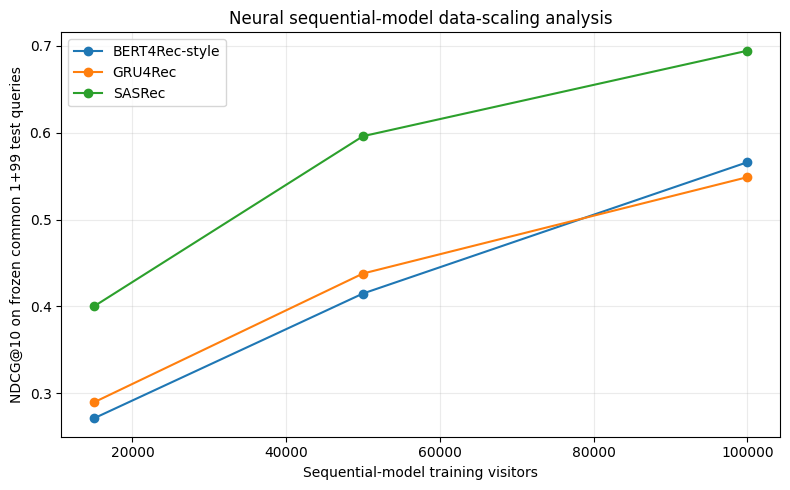


Saved reviewer-hardening outputs to: /kaggle/working/retailrocket_publication_outputs/neural_data_scaling
Interpretation rule: if neural NDCG rises materially with data, describe the original neural baselines as data-budget constrained; if gains remain small, the scaling analysis weakens the data-starvation explanation.


In [35]:
# ============================================================
# EXECUTE AND EXPORT THE NEURAL DATA-SCALING EXPERIMENT
# ============================================================

neural_scaling_rows = []

if RUN_NEURAL_DATA_SCALING:
    torch.manual_seed(SCALING_SEED)
    np.random.seed(SCALING_SEED)
    random.seed(SCALING_SEED)

    for visitor_budget in scaling_budgets:
        scale_frame, scale_sequences = build_scaling_sequences(visitor_budget)
        actual_visitors = int(scale_frame["visitor_idx"].nunique())
        actual_interactions = int(len(scale_frame))
        print("\n" + "=" * 72)
        print(f"NEURAL SCALING BUDGET: {actual_visitors:,} visitors / {actual_interactions:,} interactions")
        print("=" * 72)

        for model_name in SCALING_MODELS:
            print(f"\nTraining {model_name} at {actual_visitors:,} visitors")
            torch.manual_seed(SCALING_SEED)
            np.random.seed(SCALING_SEED)
            random.seed(SCALING_SEED)

            if model_name == "GRU4Rec":
                dataset = ScalingNextItemDataset(
                    scale_sequences,
                    max_len=GRU_MAX_LEN,
                    max_prefixes=SCALING_MAX_PREFIXES,
                )
                model = GRU4RecModel(
                    n_items=n_items,
                    embed_dim=GRU_EMBED_DIM,
                    hidden_dim=GRU_HIDDEN,
                    dropout=GRU_DROPOUT,
                )
                model, losses, train_seconds = _train_ce_scaling_model(
                    model,
                    dataset,
                    epochs=SCALING_EPOCHS,
                    batch_size=SCALING_BATCH_SIZE,
                    lr=GRU_LR,
                    weight_decay=0.0,
                )
                train_samples = len(dataset)

            elif model_name == "BERT4Rec-style":
                dataset = ScalingNextItemDataset(
                    scale_sequences,
                    max_len=BERT_MAX_LEN,
                    max_prefixes=SCALING_MAX_PREFIXES,
                )
                model = BERT4RecModel(
                    n_items=n_items,
                    hidden_size=BERT_HIDDEN,
                    num_heads=BERT_HEADS,
                    num_layers=BERT_LAYERS,
                    max_len=BERT_MAX_LEN,
                    dropout=BERT_DROPOUT,
                )
                model, losses, train_seconds = _train_ce_scaling_model(
                    model,
                    dataset,
                    epochs=SCALING_EPOCHS,
                    batch_size=SCALING_BATCH_SIZE,
                    lr=BERT_LR,
                    weight_decay=1e-5,
                )
                train_samples = len(dataset)

            elif model_name == "SASRec":
                model, losses, train_seconds, train_samples = _train_sas_scaling_model(
                    scale_sequences,
                    epochs=SCALING_EPOCHS,
                )
            else:
                raise ValueError(f"Unsupported scaling model: {model_name}")

            visitor_metrics, aggregate = evaluate_scaling_model(model_name, model, k=TOPK)
            row = {
                "Model": model_name,
                "RequestedVisitorBudget": int(visitor_budget),
                "TrainingVisitors": actual_visitors,
                "TrainingInteractions": actual_interactions,
                "TrainingSamples": int(train_samples),
                "Epochs": int(SCALING_EPOCHS),
                "TrainingSeconds": float(train_seconds),
                **aggregate,
            }
            neural_scaling_rows.append(row)
            print(pd.DataFrame([row]).to_string(index=False))

            safe_name = model_name.lower().replace("-", "_").replace(" ", "_")
            visitor_metrics.to_csv(
                SCALING_OUTPUT_DIR / f"{safe_name}_{actual_visitors}_per_visitor.csv",
                index=False,
            )
            pd.DataFrame(neural_scaling_rows).to_csv(
                SCALING_OUTPUT_DIR / "neural_data_scaling_results.csv",
                index=False,
            )

            del model, visitor_metrics
            if "dataset" in locals():
                del dataset
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    neural_scaling_results = pd.DataFrame(neural_scaling_rows).sort_values(
        ["Model", "TrainingVisitors"]
    ).reset_index(drop=True)
    display(neural_scaling_results)

    # Direct reviewer-facing comparison: change from the smallest to largest
    # training budget for each neural architecture.
    scaling_effect_rows = []
    for model_name, group in neural_scaling_results.groupby("Model"):
        group = group.sort_values("TrainingVisitors")
        first = group.iloc[0]
        last = group.iloc[-1]
        scaling_effect_rows.append({
            "Model": model_name,
            "SmallestVisitors": int(first["TrainingVisitors"]),
            "LargestVisitors": int(last["TrainingVisitors"]),
            "NDCG@10_small": float(first["NDCG@10"]),
            "NDCG@10_large": float(last["NDCG@10"]),
            "DeltaNDCG@10": float(last["NDCG@10"] - first["NDCG@10"]),
            "HR@10_small": float(first["HR@10"]),
            "HR@10_large": float(last["HR@10"]),
            "DeltaHR@10": float(last["HR@10"] - first["HR@10"]),
        })
    neural_scaling_effect = pd.DataFrame(scaling_effect_rows)
    neural_scaling_effect.to_csv(
        SCALING_OUTPUT_DIR / "neural_data_scaling_effect.csv",
        index=False,
    )
    display(neural_scaling_effect)

    # Publication figure: NDCG@10 against the actual number of training visitors.
    fig, ax = plt.subplots(figsize=(8, 5))
    for model_name, group in neural_scaling_results.groupby("Model"):
        group = group.sort_values("TrainingVisitors")
        ax.plot(group["TrainingVisitors"], group["NDCG@10"], marker="o", label=model_name)
    ax.set_xlabel("Sequential-model training visitors")
    ax.set_ylabel("NDCG@10 on frozen common 1+99 test queries")
    ax.set_title("Neural sequential-model data-scaling analysis")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(SCALING_OUTPUT_DIR / "neural_data_scaling_ndcg.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("\nSaved reviewer-hardening outputs to:", SCALING_OUTPUT_DIR)
    print("Interpretation rule: if neural NDCG rises materially with data, describe the original neural baselines as data-budget constrained; if gains remain small, the scaling analysis weakens the data-starvation explanation.")
else:
    print("RUN_NEURAL_DATA_SCALING=False; scaling experiment skipped.")


In [36]:
# ============================================================
# FINAL COMMON-DATA FAIRNESS / LEAKAGE GATE
# ============================================================
# This gate is intentionally executable: the notebook should stop
# rather than export publication tables if a core fairness invariant
# is violated.
# ============================================================

def _visitor_set_hash(values):
    arr = np.sort(np.asarray(list(values), dtype=np.int64))
    return hashlib.sha256(arr.astype("<i8", copy=False).tobytes()).hexdigest()

expected_common_set = set(int(v) for v in common_train_visitors)

# Recompute CF visitors from the dataframe actually consumed by the CF model.
# This prevents an alias from masking an accidental evaluation-subset CF fit.
cf_training_visitors = np.sort(
    CF_SOURCE_DF["visitor_idx"].drop_duplicates().to_numpy(dtype=np.int64)
)
assert len(CF_SOURCE_DF) == len(train_df), (
    "CF source row count differs from the definitive common training dataframe."
)
assert set(cf_training_visitors.tolist()) == expected_common_set, (
    "CF was not fitted on the definitive common 100K visitor cohort."
)

training_set_registry = {
    "CF": set(int(v) for v in cf_training_visitors),
    "RF": set(int(v) for v in rf_training_visitors),
    "GRU4Rec": set(int(v) for v in gru_training_visitors),
    "SASRec": set(int(v) for v in sas_training_visitors),
    "BERT4Rec-style": set(int(v) for v in bert_training_visitors),
}

fairness_rows = []
for model_name, visitor_set in training_set_registry.items():
    identical = visitor_set == expected_common_set
    fairness_rows.append({
        "Model": model_name,
        "TrainingVisitors": len(visitor_set),
        "IdenticalToCommonCohort": bool(identical),
        "VisitorSetSHA256": _visitor_set_hash(visitor_set),
    })
    assert identical, f"{model_name} does not use the definitive common cohort."

# Temporal split invariants.
train_max = train_df.groupby("visitor_idx")["timestamp"].max()
val_idx = val_df.set_index("visitor_idx")
test_idx = test_df.set_index("visitor_idx")
assert train_max.le(val_idx["timestamp"]).all()
assert val_idx["timestamp"].le(test_idx["timestamp"]).all()

# Evaluation population and catalogue invariants.
assert len(sampled_eval_visitors) == MAX_EVAL_VISITORS
assert set(sampled_eval_visitors).issubset(expected_common_set)
assert set(val_df_eval["item_idx"]).issubset(train_catalogue)
assert set(test_df_eval["item_idx"]).issubset(train_catalogue)

common_data_fairness_audit = pd.DataFrame(fairness_rows)
display(common_data_fairness_audit)

AUDIT_DIR = Path(globals().get("OUTPUT_DIR", Path("./outputs"))) / "audit"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)
common_data_fairness_audit.to_csv(
    AUDIT_DIR / "common_data_fairness_audit.csv",
    index=False,
)
common_cohort_distribution_audit.to_csv(
    AUDIT_DIR / "common_cohort_distribution_audit.csv",
    index=False,
)

with open(AUDIT_DIR / "common_cohort_fingerprint.json", "w") as f:
    json.dump({
        "CommonTrainVisitorBudget": int(COMMON_TRAIN_VISITOR_BUDGET),
        "CommonCohortSeed": int(COMMON_COHORT_SEED),
        "CommonCohortSHA256": common_cohort_sha256,
        "EvaluationVisitorSHA256": eval_visitor_sha256,
        "MinTrainInteractions": int(COMMON_MIN_TRAIN_INTERACTIONS),
        "MaxPrefixesPerSequentialVisitor": int(COMMON_MAX_PREFIXES_PER_VISITOR),
        "KnownValidationTestItemsRequired": bool(REQUIRE_KNOWN_VALIDATION_TEST_ITEMS),
    }, f, indent=2)

print("FINAL COMMON-DATA FAIRNESS / LEAKAGE GATE: PASSED")
print("All five baseline families use the same underlying 100,000 training visitors.")
print("Validation/test visitors are within that cohort and held-out targets are in the train catalogue.")
print("RF training features are generated from temporal prefixes only.")


,Model,TrainingVisitors,IdenticalToCommonCohort,VisitorSetSHA256
0,CF,100000,True,eae39c313e8e336713598b3212d8d89dcc8803f27d3095...
1,RF,100000,True,eae39c313e8e336713598b3212d8d89dcc8803f27d3095...
2,GRU4Rec,100000,True,eae39c313e8e336713598b3212d8d89dcc8803f27d3095...
3,SASRec,100000,True,eae39c313e8e336713598b3212d8d89dcc8803f27d3095...
4,BERT4Rec-style,100000,True,eae39c313e8e336713598b3212d8d89dcc8803f27d3095...


FINAL COMMON-DATA FAIRNESS / LEAKAGE GATE: PASSED
All five baseline families use the same underlying 100,000 training visitors.
Validation/test visitors are within that cohort and held-out targets are in the train catalogue.
RF training features are generated from temporal prefixes only.
